<a href="https://colab.research.google.com/github/tiagoeletro-bot/Ar-Condicionado-HVAC---notebookLM-/blob/main/Projeto_An%C3%A1lise_VAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# NÚCLEO CONSOLIDADO - MÓDULOS 1 + 2 + 3.1
#
# OBJETIVO:
# Construir a base oficial de tratamento, qualidade, cobertura, gaps,
# cadastro técnico e integração temporal VAV x FANCOIL.
#
# A PARTIR DO MÓDULO 4, OS CÓDIGOS PODERÃO SER EXECUTADOS
# INDIVIDUALMENTE SOBRE A BASE ANALÍTICA GERADA AQUI.
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 120)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("NÚCLEO CONSOLIDADO - MÓDULOS 1 + 2 + 3.1")
print("=" * 120)


# ==================================================================================================
# 2. PARÂMETROS OFICIAIS DO PROJETO
# ==================================================================================================

HORA_INICIO = "07:00"
HORA_FIM = "19:00"

DIAS_SEMANA_VALIDOS = [0, 1, 2, 3, 4]

INTERVALO_MINUTOS = 10

TOLERANCIA_GRADE_MINUTOS = 2


# --------------------------------------------------------------------------------------------------
# LIMITES INICIAIS PARA QUALIDADE
# --------------------------------------------------------------------------------------------------

LIMITE_COBERTURA_EXCELENTE = 98
LIMITE_COBERTURA_BOA = 95
LIMITE_COBERTURA_ATENCAO = 90
LIMITE_COBERTURA_BAIXA = 80


# ==================================================================================================
# 3. CLASSIFICAÇÃO FUNCIONAL DOS PONTOS
# ==================================================================================================

PONTOS_PERIODICOS_VAV = [
    "ZN-TEM",
    "SUPFLO",
    "SA-VPI"
]

PONTOS_PERIODICOS_FAC = [
    "DA-TEM",
    "RL-FLO",
    "RL-POS",
    "SF-OUT"
]

PONTOS_COV_VAV = [
    "ZNT-SP",
    "DPRPOS"
]

PONTOS_COV_FAC = [
    "DAT-SP",
    "DAP-SP"
]

PONTOS_EVENTOS_VAV = [
    "BOXMOD",
    "STVBOX",
    "NOCOOL",
    "OCCUNO",
    "OCCUND",
    "UNOCCA"
]


# ==================================================================================================
# 4. UPLOAD DO ARQUIVO
# ==================================================================================================

print()
print("=" * 120)
print("UPLOAD DA BASE")
print("=" * 120)

uploaded = files.upload()

arquivos_excel = [
    nome
    for nome in uploaded.keys()
    if nome.lower().endswith((".xlsx", ".xls"))
]

if len(arquivos_excel) == 0:
    raise FileNotFoundError(
        "Nenhum arquivo Excel foi carregado."
    )

ARQUIVO = arquivos_excel[0]

print()
print(f"✅ Arquivo selecionado: {ARQUIVO}")


# ==================================================================================================
# 5. IDENTIFICAÇÃO AUTOMÁTICA DAS ABAS
# ==================================================================================================

xls = pd.ExcelFile(ARQUIVO)


def localizar_aba(lista_abas, palavras):

    for aba in lista_abas:

        nome = (
            str(aba)
            .upper()
            .replace("-", " ")
            .replace("_", " ")
        )

        if all(
            palavra.upper() in nome
            for palavra in palavras
        ):
            return aba

    return None


ABA_VAV = localizar_aba(
    xls.sheet_names,
    ["PONTOS", "VAV"]
)

ABA_FAC = localizar_aba(
    xls.sheet_names,
    ["PONTOS", "FAC"]
)

ABA_DEPARA = localizar_aba(
    xls.sheet_names,
    ["DE", "PARA"]
)

ABA_LEGENDA = localizar_aba(
    xls.sheet_names,
    ["LEGENDA"]
)

ABA_MAXFLO = localizar_aba(
    xls.sheet_names,
    ["MAXFLO"]
)


abas_obrigatorias = {
    "Pontos VAV": ABA_VAV,
    "Pontos FAC": ABA_FAC,
    "DE-PARA": ABA_DEPARA,
    "Legenda": ABA_LEGENDA,
    "Dados MAXFLO": ABA_MAXFLO
}


print()
print("ABAS IDENTIFICADAS")
print("-" * 120)

for nome, aba in abas_obrigatorias.items():
    print(f"{nome:<25}: {aba}")


if any(
    aba is None
    for aba in abas_obrigatorias.values()
):
    raise ValueError(
        "Não foi possível identificar todas as abas obrigatórias."
    )


# ==================================================================================================
# 6. IMPORTAÇÃO
# ==================================================================================================

df_vav = pd.read_excel(
    ARQUIVO,
    sheet_name=ABA_VAV
)

df_fac = pd.read_excel(
    ARQUIVO,
    sheet_name=ABA_FAC
)

df_depara_original = pd.read_excel(
    ARQUIVO,
    sheet_name=ABA_DEPARA
)

df_legenda = pd.read_excel(
    ARQUIVO,
    sheet_name=ABA_LEGENDA
)

df_maxflo = pd.read_excel(
    ARQUIVO,
    sheet_name=ABA_MAXFLO
)


print()
print("BASES IMPORTADAS")
print("-" * 120)

print(f"Pontos VAV............. {len(df_vav):,}")
print(f"Pontos FAC............. {len(df_fac):,}")
print(f"DE-PARA................ {len(df_depara_original):,}")
print(f"Legenda................ {len(df_legenda):,}")
print(f"Dados MAXFLO........... {len(df_maxflo):,}")


# ==================================================================================================
# 7. PADRONIZAÇÃO DAS COLUNAS
# ==================================================================================================

for df in [
    df_vav,
    df_fac,
    df_depara_original,
    df_legenda,
    df_maxflo
]:

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )


COLUNAS_OBRIGATORIAS = [
    "PointName",
    "DataHora",
    "ActualValue",
    "Ref Ponto",
    "Equipamento"
]


for nome_base, df in [
    ("VAV", df_vav),
    ("FAC", df_fac)
]:

    faltantes = [
        coluna
        for coluna in COLUNAS_OBRIGATORIAS
        if coluna not in df.columns
    ]

    if faltantes:

        raise ValueError(
            f"Base {nome_base}: faltam colunas {faltantes}"
        )


# ==================================================================================================
# 8. PADRONIZAÇÃO DOS CAMPOS
# ==================================================================================================

for df in [
    df_vav,
    df_fac
]:

    for coluna in [
        "PointName",
        "Ref Ponto",
        "Equipamento"
    ]:

        df[coluna] = (
            df[coluna]
            .astype("string")
            .str.strip()
            .str.upper()
        )


    df["DataHora"] = pd.to_datetime(
        df["DataHora"],
        errors="coerce"
    )


    df["ActualValue"] = pd.to_numeric(
        df["ActualValue"],
        errors="coerce"
    )


if "Ref Ponto" in df_legenda.columns:

    df_legenda["Ref Ponto"] = (
        df_legenda["Ref Ponto"]
        .astype("string")
        .str.strip()
        .str.upper()
    )


# ==================================================================================================
# 9. PADRONIZAÇÃO DA ABA MAXFLO
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# Tenta localizar automaticamente as duas colunas essenciais:
#
# Equipamento
# MAXFLO
# --------------------------------------------------------------------------------------------------

coluna_equipamento_maxflo = None
coluna_valor_maxflo = None


for coluna in df_maxflo.columns:

    nome = str(coluna).upper().strip()

    if (
        "EQUIP" in nome
        or "VAV" == nome
    ):
        coluna_equipamento_maxflo = coluna

    if "MAXFLO" in nome:
        coluna_valor_maxflo = coluna


if coluna_equipamento_maxflo is None:
    raise ValueError(
        "Não foi possível localizar a coluna de Equipamento na aba Dados MAXFLO."
    )


if coluna_valor_maxflo is None:
    raise ValueError(
        "Não foi possível localizar a coluna MAXFLO na aba Dados MAXFLO."
    )


df_maxflo = df_maxflo[
    [
        coluna_equipamento_maxflo,
        coluna_valor_maxflo
    ]
].copy()


df_maxflo.columns = [
    "Equipamento",
    "MAXFLO"
]


df_maxflo["Equipamento"] = (
    df_maxflo["Equipamento"]
    .astype("string")
    .str.strip()
    .str.upper()
)


df_maxflo["MAXFLO"] = pd.to_numeric(
    df_maxflo["MAXFLO"],
    errors="coerce"
)


print()
print("✅ Aba Dados MAXFLO padronizada.")


# ==================================================================================================
# 10. PRESERVAÇÃO DA BASE BRUTA
# ==================================================================================================

df_vav_bruto = df_vav.copy()
df_fac_bruto = df_fac.copy()
df_depara_bruto = df_depara_original.copy()
df_legenda_bruto = df_legenda.copy()
df_maxflo_bruto = df_maxflo.copy()


# ==================================================================================================
# 11. PERÍODO AUTOMÁTICO
# ==================================================================================================

DATA_INICIO = min(
    df_vav["DataHora"].min(),
    df_fac["DataHora"].min()
)

DATA_FIM = max(
    df_vav["DataHora"].max(),
    df_fac["DataHora"].max()
)


print()
print("=" * 120)
print("PERÍODO IDENTIFICADO")
print("=" * 120)

print(f"Início.......... {DATA_INICIO}")
print(f"Fim............. {DATA_FIM}")


# ==================================================================================================
# 12. CONSTRUÇÃO DO DE-PARA
# ==================================================================================================

colunas_fancoil = []


for coluna in df_depara_original.columns:

    nome = str(coluna).upper()

    if "FANC" in nome or "FAC" in nome:

        # tenta extrair o nome do equipamento
        if "FANC01" in nome or "FAC01" in nome:
            fac = "FANC01"

        elif "FANC02" in nome or "FAC02" in nome:
            fac = "FANC02"

        else:
            continue

        colunas_fancoil.append(
            (coluna, fac)
        )


lista_depara = []


for coluna, fac in colunas_fancoil:

    equipamentos = (
        df_depara_original[coluna]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )

    lista_depara.append(
        pd.DataFrame({
            "VAV": equipamentos,
            "Fancoil": fac
        })
    )


if len(lista_depara) == 0:

    raise ValueError(
        "Não foi possível interpretar o DE-PARA."
    )


df_depara = pd.concat(
    lista_depara,
    ignore_index=True
)


# --------------------------------------------------------------------------------------------------
# REGRA DE ENGENHARIA CONFIRMADA
# --------------------------------------------------------------------------------------------------

df_depara = df_depara[
    ~(
        df_depara["VAV"].isin(
            [
                "CVAV21",
                "CVAV26"
            ]
        )
        &
        (
            df_depara["Fancoil"]
            == "FANC02"
        )
    )
].copy()


df_depara = (
    df_depara
    .drop_duplicates()
    .sort_values(
        [
            "Fancoil",
            "VAV"
        ]
    )
    .reset_index(drop=True)
)


# ==================================================================================================
# 13. INVENTÁRIO DE EQUIPAMENTOS
# ==================================================================================================

vavs_historico = set(
    df_vav["Equipamento"]
    .dropna()
    .unique()
)

vavs_depara = set(
    df_depara["VAV"]
    .dropna()
    .unique()
)

vavs_maxflo = set(
    df_maxflo["Equipamento"]
    .dropna()
    .unique()
)


# --------------------------------------------------------------------------------------------------
# União dos três cadastros
# --------------------------------------------------------------------------------------------------

TODAS_VAVS = sorted(
    vavs_historico
    .union(vavs_depara)
    .union(vavs_maxflo)
)


TODOS_FACS = sorted(
    df_fac["Equipamento"]
    .dropna()
    .unique()
)


print()
print("=" * 120)
print("INVENTÁRIO")
print("=" * 120)

print(f"VAVs no histórico......... {len(vavs_historico)}")
print(f"VAVs no DE-PARA........... {len(vavs_depara)}")
print(f"VAVs com MAXFLO........... {len(vavs_maxflo)}")
print(f"VAVs consolidadas......... {len(TODAS_VAVS)}")
print(f"Fancoils.................. {len(TODOS_FACS)}")


# ==================================================================================================
# 14. AUDITORIA DO MAXFLO
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# Verificar duplicidades cadastrais
# --------------------------------------------------------------------------------------------------

duplicados_maxflo = (
    df_maxflo
    .duplicated(
        subset=["Equipamento"],
        keep=False
    )
)


df_duplicados_maxflo = (
    df_maxflo[
        duplicados_maxflo
    ]
    .sort_values(
        "Equipamento"
    )
)


# --------------------------------------------------------------------------------------------------
# Consolidar um valor por equipamento
# --------------------------------------------------------------------------------------------------

df_maxflo_tratado = (
    df_maxflo
    .drop_duplicates(
        subset=["Equipamento"],
        keep="last"
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------------------------------------------
# Status cadastral
# --------------------------------------------------------------------------------------------------

auditoria_maxflo = pd.DataFrame({
    "Equipamento": TODAS_VAVS
})


auditoria_maxflo = auditoria_maxflo.merge(
    df_maxflo_tratado,
    on="Equipamento",
    how="left"
)


auditoria_maxflo["Tem_Historico"] = (
    auditoria_maxflo["Equipamento"]
    .isin(vavs_historico)
)


auditoria_maxflo["Tem_DEPARA"] = (
    auditoria_maxflo["Equipamento"]
    .isin(vavs_depara)
)


def classificar_status_maxflo(row):

    if pd.isna(row["MAXFLO"]):
        return "MAXFLO NÃO CADASTRADO"

    if row["MAXFLO"] <= 0:
        return "MAXFLO INVÁLIDO"

    if not row["Tem_Historico"]:
        return "MAXFLO OK / SEM DADOS NO PERÍODO"

    return "OK"


auditoria_maxflo["Status_MAXFLO"] = (
    auditoria_maxflo
    .apply(
        classificar_status_maxflo,
        axis=1
    )
)


print()
print("=" * 120)
print("AUDITORIA MAXFLO")
print("=" * 120)

display(
    auditoria_maxflo
)


if len(df_duplicados_maxflo) > 0:

    print()
    print("⚠️ Duplicidades encontradas na aba Dados MAXFLO:")

    display(
        df_duplicados_maxflo
    )


# ==================================================================================================
# 15. PENDÊNCIAS CADASTRAIS
# ==================================================================================================

pendencias = []


for vav in sorted(
    vavs_historico - vavs_depara
):

    pendencias.append({
        "Equipamento": vav,
        "Tipo": "SEM_DEPARA",
        "Descrição": (
            "VAV possui dados históricos, mas não possui associação com fancoil."
        )
    })


for vav in sorted(
    vavs_depara - vavs_historico
):

    pendencias.append({
        "Equipamento": vav,
        "Tipo": "SEM_DADOS",
        "Descrição": (
            "VAV está cadastrada no DE-PARA, mas não possui dados no período."
        )
    })


for vav in sorted(
    set(TODAS_VAVS) - vavs_maxflo
):

    pendencias.append({
        "Equipamento": vav,
        "Tipo": "SEM_MAXFLO",
        "Descrição": (
            "VAV não possui MAXFLO cadastrado."
        )
    })


df_pendencias = pd.DataFrame(
    pendencias
)


# ==================================================================================================
# 16. CALENDÁRIO OPERACIONAL
# ==================================================================================================

dias = pd.date_range(
    DATA_INICIO.normalize(),
    DATA_FIM.normalize(),
    freq="D"
)


dias_uteis = dias[
    dias.dayofweek.isin(
        DIAS_SEMANA_VALIDOS
    )
]


grade_temporal = []


for dia in dias_uteis:

    inicio = pd.Timestamp(
        f"{dia.date()} {HORA_INICIO}"
    )

    fim = pd.Timestamp(
        f"{dia.date()} {HORA_FIM}"
    )

    grade_dia = pd.date_range(
        inicio,
        fim,
        freq=f"{INTERVALO_MINUTOS}min"
    )

    grade_temporal.extend(
        grade_dia
    )


df_grade = pd.DataFrame({
    "DataHora": grade_temporal
})


REGISTROS_ESPERADOS = len(
    df_grade
)


REGISTROS_ESPERADOS_DIA = int(
    (
        pd.Timestamp(
            f"2000-01-01 {HORA_FIM}"
        )
        -
        pd.Timestamp(
            f"2000-01-01 {HORA_INICIO}"
        )
    ).total_seconds()
    /
    60
    /
    INTERVALO_MINUTOS
) + 1


print()
print("=" * 120)
print("GRADE TEMPORAL")
print("=" * 120)

print(f"Dias úteis................. {len(dias_uteis)}")
print(f"Registros/dia.............. {REGISTROS_ESPERADOS_DIA}")
print(f"Registros/período.......... {REGISTROS_ESPERADOS:,}")


# ==================================================================================================
# 17. FILTRO OPERACIONAL
# ==================================================================================================

def aplicar_filtro_operacional(df):

    temp = df.copy()

    temp = temp[
        temp["DataHora"]
        .dt.dayofweek
        .isin(
            DIAS_SEMANA_VALIDOS
        )
    ]

    temp = (
        temp
        .set_index(
            "DataHora"
        )
        .between_time(
            HORA_INICIO,
            HORA_FIM,
            inclusive="both"
        )
        .reset_index()
    )

    return temp


df_vav_op = aplicar_filtro_operacional(
    df_vav
)

df_fac_op = aplicar_filtro_operacional(
    df_fac
)


# ==================================================================================================
# 18. TRATAMENTO ESPECIAL CVAV19 / SA-VPI
# ==================================================================================================

mascara_cvav19 = (
    (
        df_vav_op["Equipamento"]
        == "CVAV19"
    )
    &
    (
        df_vav_op["Ref Ponto"]
        == "SA-VPI"
    )
)


df_cvav19_savpi = (
    df_vav_op[
        mascara_cvav19
    ]
    .copy()
)


df_demais_vav = (
    df_vav_op[
        ~mascara_cvav19
    ]
    .copy()
)


qtd_antes_cvav19 = len(
    df_cvav19_savpi
)


if len(df_cvav19_savpi) > 0:

    df_cvav19_savpi = df_cvav19_savpi[
        (
            df_cvav19_savpi["DataHora"]
            .dt.minute
            %
            INTERVALO_MINUTOS
            == 0
        )
        &
        (
            df_cvav19_savpi["DataHora"]
            .dt.second
            == 0
        )
    ].copy()


qtd_depois_cvav19 = len(
    df_cvav19_savpi
)


df_vav_op = pd.concat(
    [
        df_demais_vav,
        df_cvav19_savpi
    ],
    ignore_index=True
)


print()
print("=" * 120)
print("TRATAMENTO CVAV19 / SA-VPI")
print("=" * 120)

print(f"Antes........ {qtd_antes_cvav19:,}")
print(f"Depois....... {qtd_depois_cvav19:,}")


# ==================================================================================================
# 19. FUNÇÃO DE ALINHAMENTO DOS SINAIS PERIÓDICOS
# ==================================================================================================

def alinhar_periodico(
    df,
    pontos_periodicos
):

    dados = df[
        df["Ref Ponto"]
        .isin(
            pontos_periodicos
        )
    ].copy()


    if len(dados) == 0:

        return pd.DataFrame(
            columns=[
                "Equipamento",
                "Ref Ponto",
                "DataHora",
                "ActualValue"
            ]
        )


    dados["DataHoraGrade"] = (
        dados["DataHora"]
        .dt.round(
            f"{INTERVALO_MINUTOS}min"
        )
    )


    dados["DiferencaSegundos"] = (
        (
            dados["DataHora"]
            -
            dados["DataHoraGrade"]
        )
        .abs()
        .dt.total_seconds()
    )


    dados = dados[
        dados["DiferencaSegundos"]
        <=
        TOLERANCIA_GRADE_MINUTOS * 60
    ].copy()


    dados = (
        dados
        .sort_values(
            "DiferencaSegundos"
        )
        .drop_duplicates(
            subset=[
                "Equipamento",
                "Ref Ponto",
                "DataHoraGrade"
            ],
            keep="first"
        )
    )


    dados = dados[
        [
            "Equipamento",
            "Ref Ponto",
            "DataHoraGrade",
            "ActualValue"
        ]
    ].copy()


    dados = dados.rename(
        columns={
            "DataHoraGrade": "DataHora"
        }
    )


    return dados


# ==================================================================================================
# 20. SINAIS PERIÓDICOS VAV
# ==================================================================================================

vav_periodicos = alinhar_periodico(
    df_vav_op,
    PONTOS_PERIODICOS_VAV
)


# ==================================================================================================
# 21. GRADE COMPLETA VAV x TEMPO
# ==================================================================================================

df_vavs = pd.DataFrame({
    "Equipamento": TODAS_VAVS
})


df_vavs["_join"] = 1

df_grade_vav = df_grade.copy()

df_grade_vav["_join"] = 1


base_vav = (
    df_vavs
    .merge(
        df_grade_vav,
        on="_join"
    )
    .drop(
        columns="_join"
    )
)


# ==================================================================================================
# 22. PIVOT DOS SINAIS PERIÓDICOS VAV
# ==================================================================================================

if len(vav_periodicos) > 0:

    pivot_vav = (
        vav_periodicos
        .pivot_table(
            index=[
                "Equipamento",
                "DataHora"
            ],
            columns="Ref Ponto",
            values="ActualValue",
            aggfunc="last"
        )
        .reset_index()
    )


    pivot_vav.columns.name = None


    base_vav = base_vav.merge(
        pivot_vav,
        on=[
            "Equipamento",
            "DataHora"
        ],
        how="left"
    )


# ==================================================================================================
# 23. FUNÇÃO DE RECONSTRUÇÃO COV
# ==================================================================================================

def reconstruir_cov(
    base,
    dados_originais,
    ponto,
    nome_coluna
):

    resultados = []


    for equipamento in base[
        "Equipamento"
    ].unique():

        grade_eq = base[
            base["Equipamento"]
            == equipamento
        ][
            [
                "Equipamento",
                "DataHora"
            ]
        ].copy()


        eventos = dados_originais[
            (
                dados_originais["Equipamento"]
                == equipamento
            )
            &
            (
                dados_originais["Ref Ponto"]
                == ponto
            )
        ][
            [
                "DataHora",
                "ActualValue"
            ]
        ].copy()


        eventos = (
            eventos
            .dropna(
                subset=["DataHora"]
            )
            .sort_values(
                "DataHora"
            )
        )


        if len(eventos) == 0:

            grade_eq[nome_coluna] = np.nan

            grade_eq[
                nome_coluna + "_IdadeMin"
            ] = np.nan

            grade_eq[
                nome_coluna + "_DistEventoMin"
            ] = np.nan

            grade_eq[
                nome_coluna + "_Origem"
            ] = "SEM_HISTORICO"

            resultados.append(
                grade_eq
            )

            continue


        eventos = eventos.rename(
            columns={
                "DataHora": "DataHoraEvento",
                "ActualValue": nome_coluna
            }
        )


        combinado = pd.merge_asof(

            grade_eq.sort_values(
                "DataHora"
            ),

            eventos.sort_values(
                "DataHoraEvento"
            ),

            left_on="DataHora",

            right_on="DataHoraEvento",

            direction="backward"

        )


        combinado[
            nome_coluna + "_Origem"
        ] = "COV_FORWARD_FILL"


        # ------------------------------------------------------------------------------------------
        # BACKFILL INICIAL
        #
        # Se não houver nenhum evento anterior ao primeiro timestamp,
        # utiliza-se o primeiro valor futuro apenas como referência inicial.
        #
        # A idade ficará NaN, evitando valores negativos.
        # A distância até o evento futuro será registrada separadamente.
        # ------------------------------------------------------------------------------------------

        sem_valor = combinado[
            nome_coluna
        ].isna()


        if sem_valor.any():

            futuros = pd.merge_asof(

                combinado.loc[
                    sem_valor,
                    [
                        "Equipamento",
                        "DataHora"
                    ]
                ]
                .sort_values(
                    "DataHora"
                ),

                eventos.sort_values(
                    "DataHoraEvento"
                ),

                left_on="DataHora",

                right_on="DataHoraEvento",

                direction="forward"

            )


            combinado.loc[
                sem_valor,
                nome_coluna
            ] = futuros[
                nome_coluna
            ].values


            combinado.loc[
                sem_valor,
                "DataHoraEvento"
            ] = futuros[
                "DataHoraEvento"
            ].values


            combinado.loc[
                sem_valor,
                nome_coluna + "_Origem"
            ] = "BACKFILL_INICIAL"


        # ------------------------------------------------------------------------------------------
        # IDADE DO DADO
        #
        # Somente válida quando o valor veio do passado.
        # ------------------------------------------------------------------------------------------

        combinado[
            nome_coluna + "_IdadeMin"
        ] = np.nan


        mascara_forward = (
            combinado[
                nome_coluna + "_Origem"
            ]
            ==
            "COV_FORWARD_FILL"
        )


        combinado.loc[
            mascara_forward,
            nome_coluna + "_IdadeMin"
        ] = (
            (
                combinado.loc[
                    mascara_forward,
                    "DataHora"
                ]
                -
                combinado.loc[
                    mascara_forward,
                    "DataHoraEvento"
                ]
            )
            .dt.total_seconds()
            /
            60
        )


        # ------------------------------------------------------------------------------------------
        # DISTÂNCIA ABSOLUTA ATÉ O EVENTO
        #
        # Para BACKFILL inicial, indica quantos minutos faltavam
        # até o primeiro valor conhecido.
        # ------------------------------------------------------------------------------------------

        combinado[
            nome_coluna + "_DistEventoMin"
        ] = (
            (
                combinado[
                    "DataHora"
                ]
                -
                combinado[
                    "DataHoraEvento"
                ]
            )
            .abs()
            .dt.total_seconds()
            /
            60
        )


        resultados.append(
            combinado[
                [
                    "Equipamento",
                    "DataHora",
                    nome_coluna,
                    nome_coluna + "_IdadeMin",
                    nome_coluna + "_DistEventoMin",
                    nome_coluna + "_Origem"
                ]
            ]
        )


    return pd.concat(
        resultados,
        ignore_index=True
    )


# ==================================================================================================
# 24. ZNT-SP
# ==================================================================================================

cov_zntsp = reconstruir_cov(
    base_vav,
    df_vav_bruto,
    "ZNT-SP",
    "ZNT-SP"
)


base_vav = base_vav.merge(
    cov_zntsp,
    on=[
        "Equipamento",
        "DataHora"
    ],
    how="left"
)


# ==================================================================================================
# 25. DPRPOS
# ==================================================================================================

cov_dprpos = reconstruir_cov(
    base_vav[
        [
            "Equipamento",
            "DataHora"
        ]
    ],
    df_vav_bruto,
    "DPRPOS",
    "DPRPOS"
)


base_vav = base_vav.merge(
    cov_dprpos,
    on=[
        "Equipamento",
        "DataHora"
    ],
    how="left"
)


# ==================================================================================================
# 26. MAXFLO OFICIAL DA ABA DADOS MAXFLO
# ==================================================================================================

base_vav = base_vav.merge(
    df_maxflo_tratado,
    on="Equipamento",
    how="left"
)


# ==================================================================================================
# 27. ASSOCIAÇÃO VAV x FANCOIL
# ==================================================================================================

base_vav = base_vav.merge(
    df_depara.rename(
        columns={
            "VAV": "Equipamento",
            "Fancoil": "FAC"
        }
    ),
    on="Equipamento",
    how="left"
)


# ==================================================================================================
# 28. GRADE COMPLETA FAC x TEMPO
# ==================================================================================================

df_facs = pd.DataFrame({
    "Equipamento": TODOS_FACS
})


df_facs["_join"] = 1

df_grade_fac = df_grade.copy()

df_grade_fac["_join"] = 1


base_fac = (
    df_facs
    .merge(
        df_grade_fac,
        on="_join"
    )
    .drop(
        columns="_join"
    )
)


# ==================================================================================================
# 29. SINAIS PERIÓDICOS FAC
# ==================================================================================================

fac_periodicos = alinhar_periodico(
    df_fac_op,
    PONTOS_PERIODICOS_FAC
)


if len(fac_periodicos) > 0:

    pivot_fac = (
        fac_periodicos
        .pivot_table(
            index=[
                "Equipamento",
                "DataHora"
            ],
            columns="Ref Ponto",
            values="ActualValue",
            aggfunc="last"
        )
        .reset_index()
    )


    pivot_fac.columns.name = None


    base_fac = base_fac.merge(
        pivot_fac,
        on=[
            "Equipamento",
            "DataHora"
        ],
        how="left"
    )


# ==================================================================================================
# 30. COV FAC
# ==================================================================================================

for ponto in PONTOS_COV_FAC:

    cov_fac = reconstruir_cov(
        base_fac[
            [
                "Equipamento",
                "DataHora"
            ]
        ],
        df_fac_bruto,
        ponto,
        ponto
    )


    base_fac = base_fac.merge(
        cov_fac,
        on=[
            "Equipamento",
            "DataHora"
        ],
        how="left"
    )


# ==================================================================================================
# 31. RENOMEAR VARIÁVEIS FAC
# ==================================================================================================

base_fac_integracao = base_fac.rename(
    columns={
        "Equipamento": "FAC",

        "DA-TEM": "FAC_DA-TEM",
        "RL-FLO": "FAC_RL-FLO",
        "RL-POS": "FAC_RL-POS",
        "SF-OUT": "FAC_SF-OUT",

        "DAT-SP": "FAC_DAT-SP",
        "DAT-SP_IdadeMin": "FAC_DAT-SP_IdadeMin",
        "DAT-SP_DistEventoMin": "FAC_DAT-SP_DistEventoMin",
        "DAT-SP_Origem": "FAC_DAT-SP_Origem",

        "DAP-SP": "FAC_DAP-SP",
        "DAP-SP_IdadeMin": "FAC_DAP-SP_IdadeMin",
        "DAP-SP_DistEventoMin": "FAC_DAP-SP_DistEventoMin",
        "DAP-SP_Origem": "FAC_DAP-SP_Origem"
    }
)


# ==================================================================================================
# 32. INTEGRAÇÃO VAV x FAC
# ==================================================================================================

base_analitica = base_vav.merge(
    base_fac_integracao,
    on=[
        "FAC",
        "DataHora"
    ],
    how="left"
)


# ==================================================================================================
# 33. VARIÁVEIS TEMPORAIS
# ==================================================================================================

base_analitica["Data"] = (
    base_analitica["DataHora"]
    .dt.date
)

base_analitica["Ano"] = (
    base_analitica["DataHora"]
    .dt.year
)

base_analitica["Mes"] = (
    base_analitica["DataHora"]
    .dt.month
)

base_analitica["AnoMes"] = (
    base_analitica["DataHora"]
    .dt.strftime("%Y-%m")
)

base_analitica["Hora"] = (
    base_analitica["DataHora"]
    .dt.hour
)

base_analitica["Minuto"] = (
    base_analitica["DataHora"]
    .dt.minute
)


mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta"
}


base_analitica["DiaSemana"] = (
    base_analitica["DataHora"]
    .dt.dayofweek
    .map(mapa_dias)
)


# ==================================================================================================
# 34. FLAGS DE DISPONIBILIDADE
# ==================================================================================================

for ponto in PONTOS_PERIODICOS_VAV:

    if ponto in base_analitica.columns:

        base_analitica[
            f"Disponivel_{ponto}"
        ] = (
            base_analitica[ponto]
            .notna()
            .astype(int)
        )


for ponto in PONTOS_PERIODICOS_FAC:

    coluna = f"FAC_{ponto}"

    if coluna in base_analitica.columns:

        base_analitica[
            f"Disponivel_{coluna}"
        ] = (
            base_analitica[coluna]
            .notna()
            .astype(int)
        )


# ==================================================================================================
# 35. FUNÇÃO DE CLASSIFICAÇÃO DE COBERTURA
# ==================================================================================================

def classificar_cobertura(valor):

    if pd.isna(valor):
        return "SEM DADOS"

    if valor >= LIMITE_COBERTURA_EXCELENTE:
        return "EXCELENTE"

    elif valor >= LIMITE_COBERTURA_BOA:
        return "BOA"

    elif valor >= LIMITE_COBERTURA_ATENCAO:
        return "ATENÇÃO"

    elif valor >= LIMITE_COBERTURA_BAIXA:
        return "BAIXA"

    else:
        return "CRÍTICA"


# ==================================================================================================
# 36. QUALIDADE DOS PONTOS VAV
# ==================================================================================================

lista_qualidade_vav = []


for equipamento in TODAS_VAVS:

    dados_eq = base_analitica[
        base_analitica["Equipamento"]
        == equipamento
    ]


    for ponto in PONTOS_PERIODICOS_VAV:

        esperado = len(
            dados_eq
        )


        if ponto in dados_eq.columns:

            disponiveis = (
                dados_eq[ponto]
                .notna()
                .sum()
            )

        else:

            disponiveis = 0


        ausentes = (
            esperado
            -
            disponiveis
        )


        cobertura = (
            disponiveis
            /
            esperado
            *
            100
        ) if esperado > 0 else np.nan


        lista_qualidade_vav.append({
            "Equipamento": equipamento,
            "Ref Ponto": ponto,
            "Registros Esperados": esperado,
            "Registros Disponíveis": disponiveis,
            "Registros Ausentes": ausentes,
            "Cobertura %": cobertura,
            "Classificação": classificar_cobertura(
                cobertura
            )
        })


qualidade_vav = pd.DataFrame(
    lista_qualidade_vav
)


# ==================================================================================================
# 37. QUALIDADE DOS PONTOS FAC
# ==================================================================================================

lista_qualidade_fac = []


for equipamento in TODOS_FACS:

    dados_eq = base_fac[
        base_fac["Equipamento"]
        == equipamento
    ]


    for ponto in PONTOS_PERIODICOS_FAC:

        esperado = len(
            dados_eq
        )


        if ponto in dados_eq.columns:

            disponiveis = (
                dados_eq[ponto]
                .notna()
                .sum()
            )

        else:

            disponiveis = 0


        cobertura = (
            disponiveis
            /
            esperado
            *
            100
        ) if esperado > 0 else np.nan


        lista_qualidade_fac.append({
            "Equipamento": equipamento,
            "Ref Ponto": ponto,
            "Registros Esperados": esperado,
            "Registros Disponíveis": disponiveis,
            "Registros Ausentes": esperado - disponiveis,
            "Cobertura %": cobertura,
            "Classificação": classificar_cobertura(
                cobertura
            )
        })


qualidade_fac = pd.DataFrame(
    lista_qualidade_fac
)


# ==================================================================================================
# 38. DETECÇÃO DE GAPS
# ==================================================================================================

def detectar_gaps(
    df,
    coluna_equipamento,
    pontos
):

    gaps = []


    for equipamento in (
        df[coluna_equipamento]
        .dropna()
        .unique()
    ):

        dados_eq = (
            df[
                df[coluna_equipamento]
                == equipamento
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        for ponto in pontos:

            if ponto not in dados_eq.columns:
                continue


            ausente = (
                dados_eq[ponto]
                .isna()
            )


            grupos = (
                ausente
                !=
                ausente.shift()
            ).cumsum()


            temp = dados_eq[
                ausente
            ].copy()


            if len(temp) == 0:
                continue


            temp["_grupo_gap"] = grupos[
                ausente
            ]


            for _, grupo in temp.groupby(
                "_grupo_gap"
            ):

                inicio = grupo[
                    "DataHora"
                ].min()

                fim = grupo[
                    "DataHora"
                ].max()

                registros = len(
                    grupo
                )


                gaps.append({
                    "Equipamento": equipamento,
                    "Ref Ponto": ponto,
                    "Inicio Gap": inicio,
                    "Fim Gap": fim,
                    "Registros Ausentes": registros,
                    "Duração Gap (min)": (
                        registros
                        *
                        INTERVALO_MINUTOS
                    )
                })


    return pd.DataFrame(
        gaps
    )


# ==================================================================================================
# 39. GAPS VAV
# ==================================================================================================

gaps_vav = detectar_gaps(
    base_analitica,
    "Equipamento",
    PONTOS_PERIODICOS_VAV
)


# ==================================================================================================
# 40. GAPS FAC
# ==================================================================================================

gaps_fac = detectar_gaps(
    base_fac,
    "Equipamento",
    PONTOS_PERIODICOS_FAC
)


# ==================================================================================================
# 41. RESUMO DE GAPS VAV
# ==================================================================================================

if len(gaps_vav) > 0:

    resumo_gaps_vav = (
        gaps_vav
        .groupby(
            [
                "Equipamento",
                "Ref Ponto"
            ]
        )
        .agg(
            Quantidade_Gaps=(
                "Inicio Gap",
                "count"
            ),
            Maior_Gap_Min=(
                "Duração Gap (min)",
                "max"
            ),
            Tempo_Total_Ausente_Min=(
                "Duração Gap (min)",
                "sum"
            )
        )
        .reset_index()
    )


    qualidade_vav = qualidade_vav.merge(
        resumo_gaps_vav,
        on=[
            "Equipamento",
            "Ref Ponto"
        ],
        how="left"
    )


# ==================================================================================================
# 42. RESUMO DE GAPS FAC
# ==================================================================================================

if len(gaps_fac) > 0:

    resumo_gaps_fac = (
        gaps_fac
        .groupby(
            [
                "Equipamento",
                "Ref Ponto"
            ]
        )
        .agg(
            Quantidade_Gaps=(
                "Inicio Gap",
                "count"
            ),
            Maior_Gap_Min=(
                "Duração Gap (min)",
                "max"
            ),
            Tempo_Total_Ausente_Min=(
                "Duração Gap (min)",
                "sum"
            )
        )
        .reset_index()
    )


    qualidade_fac = qualidade_fac.merge(
        resumo_gaps_fac,
        on=[
            "Equipamento",
            "Ref Ponto"
        ],
        how="left"
    )


for df in [
    qualidade_vav,
    qualidade_fac
]:

    for coluna in [
        "Quantidade_Gaps",
        "Maior_Gap_Min",
        "Tempo_Total_Ausente_Min"
    ]:

        if coluna not in df.columns:
            df[coluna] = 0

        df[coluna] = (
            df[coluna]
            .fillna(0)
        )


# ==================================================================================================
# 43. QUALIDADE GLOBAL VAV
# ==================================================================================================

qualidade_global_vav = (
    qualidade_vav
    .groupby(
        "Equipamento"
    )
    .agg(
        Cobertura_Media=(
            "Cobertura %",
            "mean"
        ),
        Cobertura_Minima=(
            "Cobertura %",
            "min"
        ),
        Total_Registros_Ausentes=(
            "Registros Ausentes",
            "sum"
        ),
        Quantidade_Gaps=(
            "Quantidade_Gaps",
            "sum"
        ),
        Maior_Gap_Min=(
            "Maior_Gap_Min",
            "max"
        )
    )
    .reset_index()
)


qualidade_global_vav[
    "Classificação_Qualidade"
] = (
    qualidade_global_vav[
        "Cobertura_Media"
    ]
    .apply(
        classificar_cobertura
    )
)


# ==================================================================================================
# 44. QUALIDADE GLOBAL FAC
# ==================================================================================================

qualidade_global_fac = (
    qualidade_fac
    .groupby(
        "Equipamento"
    )
    .agg(
        Cobertura_Media=(
            "Cobertura %",
            "mean"
        ),
        Cobertura_Minima=(
            "Cobertura %",
            "min"
        ),
        Total_Registros_Ausentes=(
            "Registros Ausentes",
            "sum"
        ),
        Quantidade_Gaps=(
            "Quantidade_Gaps",
            "sum"
        ),
        Maior_Gap_Min=(
            "Maior_Gap_Min",
            "max"
        )
    )
    .reset_index()
)


qualidade_global_fac[
    "Classificação_Qualidade"
] = (
    qualidade_global_fac[
        "Cobertura_Media"
    ]
    .apply(
        classificar_cobertura
    )
)


# ==================================================================================================
# 45. CLASSIFICAÇÃO DOS PONTOS
# ==================================================================================================

todos_pontos = sorted(
    set(
        df_vav[
            "Ref Ponto"
        ]
        .dropna()
        .unique()
    )
    |
    set(
        df_fac[
            "Ref Ponto"
        ]
        .dropna()
        .unique()
    )
)


classificacao_pontos = []


for ponto in todos_pontos:

    if ponto in PONTOS_PERIODICOS_VAV:
        tipo = "PERIÓDICO VAV"
        tratamento = "Grade 10 min / preservar gaps"

    elif ponto in PONTOS_PERIODICOS_FAC:
        tipo = "PERIÓDICO FAC"
        tratamento = "Grade 10 min / preservar gaps"

    elif ponto in PONTOS_COV_VAV:
        tipo = "COV VAV"
        tratamento = "Último valor conhecido"

    elif ponto in PONTOS_COV_FAC:
        tipo = "COV FAC"
        tratamento = "Último valor conhecido"

    elif ponto == "MAXFLO":
        tipo = "CONFIGURAÇÃO"
        tratamento = "Fonte oficial: aba Dados MAXFLO"

    elif ponto in PONTOS_EVENTOS_VAV:
        tipo = "EVENTO / STATUS"
        tratamento = "Análise futura de eventos"

    else:
        tipo = "NÃO CLASSIFICADO"
        tratamento = "Requer avaliação"


    classificacao_pontos.append({
        "Ref Ponto": ponto,
        "Tipo Sinal": tipo,
        "Tratamento": tratamento
    })


df_classificacao_pontos = pd.DataFrame(
    classificacao_pontos
)


# ==================================================================================================
# 46. EVENTOS VAV
# ==================================================================================================

eventos_vav = df_vav_op[
    df_vav_op[
        "Ref Ponto"
    ]
    .isin(
        PONTOS_EVENTOS_VAV
    )
].copy()


# ==================================================================================================
# 47. ORGANIZAÇÃO DA BASE ANALÍTICA
# ==================================================================================================

colunas_inicio = [
    "DataHora",
    "Data",
    "Ano",
    "Mes",
    "AnoMes",
    "DiaSemana",
    "Hora",
    "Minuto",
    "Equipamento",
    "FAC",
    "MAXFLO"
]


colunas_inicio = [
    coluna
    for coluna in colunas_inicio
    if coluna in base_analitica.columns
]


outras_colunas = [
    coluna
    for coluna in base_analitica.columns
    if coluna not in colunas_inicio
]


base_analitica = base_analitica[
    colunas_inicio
    +
    outras_colunas
]


base_analitica = (
    base_analitica
    .sort_values(
        [
            "Equipamento",
            "DataHora"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ==================================================================================================
# 48. VALIDAÇÃO FINAL DO MAXFLO NA BASE ANALÍTICA
# ==================================================================================================

validacao_maxflo_base = (
    base_analitica[
        [
            "Equipamento",
            "MAXFLO"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Equipamento"
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 120)
print("MAXFLO INCORPORADO À BASE ANALÍTICA")
print("=" * 120)

display(
    validacao_maxflo_base
)


# ==================================================================================================
# 49. RELATÓRIOS NA TELA
# ==================================================================================================

print()
print("=" * 120)
print("QUALIDADE GLOBAL VAV")
print("=" * 120)

display(
    qualidade_global_vav
    .sort_values(
        "Cobertura_Media"
    )
)


print()
print("=" * 120)
print("QUALIDADE GLOBAL FAC")
print("=" * 120)

display(
    qualidade_global_fac
    .sort_values(
        "Cobertura_Media"
    )
)


print()
print("=" * 120)
print("PENDÊNCIAS CADASTRAIS")
print("=" * 120)

if len(df_pendencias) > 0:

    display(
        df_pendencias
    )

else:

    print("✅ Nenhuma pendência cadastral.")


print()
print("=" * 120)
print("MAIORES GAPS VAV")
print("=" * 120)

if len(gaps_vav) > 0:

    display(
        gaps_vav
        .sort_values(
            "Duração Gap (min)",
            ascending=False
        )
        .head(30)
    )

else:

    print("✅ Nenhum gap encontrado.")


print()
print("=" * 120)
print("MAIORES GAPS FAC")
print("=" * 120)

if len(gaps_fac) > 0:

    display(
        gaps_fac
        .sort_values(
            "Duração Gap (min)",
            ascending=False
        )
        .head(30)
    )

else:

    print("✅ Nenhum gap encontrado.")


# ==================================================================================================
# 50. AMOSTRA DA BASE ANALÍTICA
# ==================================================================================================

print()
print("=" * 120)
print("AMOSTRA DA BASE ANALÍTICA")
print("=" * 120)

display(
    base_analitica.head(50)
)


# ==================================================================================================
# 51. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "03_1_Base_Consolidada_VAV_FAC.xlsx"
)


print()
print("=" * 120)
print("EXPORTANDO RESULTADOS")
print("=" * 120)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    base_analitica.to_excel(
        writer,
        sheet_name="Base Analitica",
        index=False
    )


    base_fac.to_excel(
        writer,
        sheet_name="Base FAC 10min",
        index=False
    )


    qualidade_vav.to_excel(
        writer,
        sheet_name="Qualidade VAV",
        index=False
    )


    qualidade_global_vav.to_excel(
        writer,
        sheet_name="Resumo Qualidade VAV",
        index=False
    )


    qualidade_fac.to_excel(
        writer,
        sheet_name="Qualidade FAC",
        index=False
    )


    qualidade_global_fac.to_excel(
        writer,
        sheet_name="Resumo Qualidade FAC",
        index=False
    )


    gaps_vav.to_excel(
        writer,
        sheet_name="Gaps VAV",
        index=False
    )


    gaps_fac.to_excel(
        writer,
        sheet_name="Gaps FAC",
        index=False
    )


    df_depara.to_excel(
        writer,
        sheet_name="DE-PARA Tratado",
        index=False
    )


    df_maxflo_tratado.to_excel(
        writer,
        sheet_name="MAXFLO Oficial",
        index=False
    )


    auditoria_maxflo.to_excel(
        writer,
        sheet_name="Auditoria MAXFLO",
        index=False
    )


    df_pendencias.to_excel(
        writer,
        sheet_name="Pendencias Cadastro",
        index=False
    )


    df_classificacao_pontos.to_excel(
        writer,
        sheet_name="Classificacao Pontos",
        index=False
    )


    eventos_vav.to_excel(
        writer,
        sheet_name="Eventos VAV",
        index=False
    )


    df_legenda.to_excel(
        writer,
        sheet_name="Legenda",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 52. RESUMO EXECUTIVO
# ==================================================================================================

print()
print()
print("=" * 120)
print("RESUMO EXECUTIVO - NÚCLEO CONSOLIDADO")
print("=" * 120)


print()
print("PERÍODO")
print("-" * 120)

print(
    f"Primeiro registro................ "
    f"{DATA_INICIO}"
)

print(
    f"Último registro.................. "
    f"{DATA_FIM}"
)

print(
    f"Dias úteis....................... "
    f"{len(dias_uteis)}"
)

print(
    f"Timestamps esperados............. "
    f"{REGISTROS_ESPERADOS:,}"
)


print()
print("EQUIPAMENTOS")
print("-" * 120)

print(
    f"VAVs consolidadas................ "
    f"{len(TODAS_VAVS)}"
)

print(
    f"Fancoils......................... "
    f"{len(TODOS_FACS)}"
)


print()
print("BASE ANALÍTICA")
print("-" * 120)

print(
    f"Linhas criadas................... "
    f"{len(base_analitica):,}"
)

print(
    "Unidade de análise............... "
    "1 VAV x 1 timestamp de 10 minutos"
)


print()
print("MAXFLO")
print("-" * 120)

print(
    f"VAVs com MAXFLO cadastrado....... "
    f"{df_maxflo_tratado['Equipamento'].nunique()}"
)

print(
    f"VAVs sem MAXFLO.................. "
    f"{auditoria_maxflo['MAXFLO'].isna().sum()}"
)


print()
print("DATA QUALITY")
print("-" * 120)

print(
    f"Gaps VAV......................... "
    f"{len(gaps_vav):,}"
)

print(
    f"Gaps FAC......................... "
    f"{len(gaps_fac):,}"
)

print(
    f"Pendências cadastrais............ "
    f"{len(df_pendencias):,}"
)


print()
print("TRATAMENTO DOS SINAIS")
print("-" * 120)

print(
    "ZN-TEM / SUPFLO / SA-VPI........ "
    "PERIÓDICOS / gaps preservados"
)

print(
    "DPRPOS........................... "
    "COV / estado reconstruído"
)

print(
    "ZNT-SP........................... "
    "COV / estado reconstruído"
)

print(
    "MAXFLO........................... "
    "CADASTRO TÉCNICO OFICIAL"
)

print(
    "DA-TEM / RL-FLO / RL-POS / SF-OUT "
    "PERIÓDICOS"
)

print(
    "DAT-SP / DAP-SP.................. "
    "COV"
)

print()
print("=" * 120)
print("✅ NÚCLEO CONSOLIDADO CONCLUÍDO")
print("=" * 120)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "MÓDULO 4 - PERFORMANCE TÉRMICA E CONFORTO"
)

print(
    "ZN-TEM x ZNT-SP | Delta T | tempo dentro/fora da faixa | "
    "persistência | severidade | ranking por VAV"
)


# ==================================================================================================
# 53. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
NÚCLEO CONSOLIDADO - MÓDULOS 1 + 2 + 3.1

UPLOAD DA BASE


Saving 01 - Base Dados VAV-FAC.xlsx to 01 - Base Dados VAV-FAC.xlsx

✅ Arquivo selecionado: 01 - Base Dados VAV-FAC.xlsx

ABAS IDENTIFICADAS
------------------------------------------------------------------------------------------------------------------------
Pontos VAV               : Pontos VAV
Pontos FAC               : Pontos FAC
DE-PARA                  : DE-PARA Equipamento
Legenda                  : LEGENDA
Dados MAXFLO             : Dados MAXFLO

BASES IMPORTADAS
------------------------------------------------------------------------------------------------------------------------
Pontos VAV............. 422,050
Pontos FAC............. 34,977
DE-PARA................ 12
Legenda................ 17
Dados MAXFLO........... 23

✅ Aba Dados MAXFLO padronizada.

PERÍODO IDENTIFICADO
Início.......... 2026-07-01 00:00:00
Fim............. 2026-08-01 00:00:00

INVENTÁRIO
VAVs no histórico......... 22
VAVs no DE-PARA........... 23
VAVs com MAXFLO........... 23
VAVs consolidadas.........

,Equipamento,MAXFLO,Tem_Historico,Tem_DEPARA,Status_MAXFLO
0,CVAV01,600,True,True,OK
1,CVAV03,2739,True,True,OK
2,CVAV04,3570,True,True,OK
3,CVAV05,2940,True,True,OK
4,CVAV06,3145,True,True,OK
5,CVAV07,1260,True,True,OK
6,CVAV08,860,False,True,MAXFLO OK / SEM DADOS NO PERÍODO
7,CVAV09,870,True,True,OK
8,CVAV10,1140,True,True,OK
9,CVAV11,2200,True,True,OK



GRADE TEMPORAL
Dias úteis................. 23
Registros/dia.............. 73
Registros/período.......... 1,679

TRATAMENTO CVAV19 / SA-VPI
Antes........ 16,582
Depois....... 1,679

MAXFLO INCORPORADO À BASE ANALÍTICA


,Equipamento,MAXFLO
0,CVAV01,600
1,CVAV03,2739
2,CVAV04,3570
3,CVAV05,2940
4,CVAV06,3145
5,CVAV07,1260
6,CVAV08,860
7,CVAV09,870
8,CVAV10,1140
9,CVAV11,2200


...


AMOSTRA DA BASE ANALÍTICA


,DataHora,Data,Ano,Mes,AnoMes,DiaSemana,Hora,Minuto,Equipamento,FAC,MAXFLO,SA-VPI,SUPFLO,ZN-TEM,ZNT-SP,ZNT-SP_IdadeMin,ZNT-SP_DistEventoMin,ZNT-SP_Origem,DPRPOS,DPRPOS_IdadeMin,DPRPOS_DistEventoMin,DPRPOS_Origem,FAC_DA-TEM,FAC_RL-FLO,FAC_RL-POS,FAC_SF-OUT,FAC_DAT-SP,FAC_DAT-SP_IdadeMin,FAC_DAT-SP_DistEventoMin,FAC_DAT-SP_Origem,FAC_DAP-SP,FAC_DAP-SP_IdadeMin,FAC_DAP-SP_DistEventoMin,FAC_DAP-SP_Origem,Disponivel_ZN-TEM,Disponivel_SUPFLO,Disponivel_SA-VPI,Disponivel_FAC_DA-TEM,Disponivel_FAC_RL-FLO,Disponivel_FAC_RL-POS,Disponivel_FAC_SF-OUT
0,2026-07-01 07:00:00,2026-07-01,2026,7,2026-07,Quarta,7,0,CVAV01,FANC01,600,0.49,69.35,20.71,22.50,239.53,239.53,COV_FORWARD_FILL,20.56,0.00,0.00,COV_FORWARD_FILL,18.89,0.00,0.00,28.47,17.50,NaN,"1,878.68",BACKFILL_INICIAL,0.70,NaN,"10,325.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
1,2026-07-01 07:10:00,2026-07-01,2026,7,2026-07,Quarta,7,10,CVAV01,FANC01,600,0.56,73.43,20.72,22.50,249.53,249.53,COV_FORWARD_FILL,20.43,0.00,0.00,COV_FORWARD_FILL,18.36,15.70,34.93,22.14,17.50,NaN,"1,868.68",BACKFILL_INICIAL,0.70,NaN,"10,315.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
2,2026-07-01 07:20:00,2026-07-01,2026,7,2026-07,Quarta,7,20,CVAV01,FANC01,600,0.52,66.12,20.72,22.50,259.53,259.53,COV_FORWARD_FILL,20.02,0.00,0.00,COV_FORWARD_FILL,17.19,17.07,34.33,36.47,17.50,NaN,"1,858.68",BACKFILL_INICIAL,0.70,NaN,"10,305.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
3,2026-07-01 07:30:00,2026-07-01,2026,7,2026-07,Quarta,7,30,CVAV01,FANC01,600,0.46,65.01,20.83,22.50,269.53,269.53,COV_FORWARD_FILL,19.90,0.00,0.00,COV_FORWARD_FILL,16.66,8.40,0.00,23.08,17.50,NaN,"1,848.68",BACKFILL_INICIAL,0.70,NaN,"10,295.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
4,2026-07-01 07:40:00,2026-07-01,2026,7,2026-07,Quarta,7,40,CVAV01,FANC01,600,0.51,68.29,21.00,22.50,279.53,279.53,COV_FORWARD_FILL,19.90,0.00,0.00,COV_FORWARD_FILL,16.58,9.27,35.52,31.61,17.50,NaN,"1,838.68",BACKFILL_INICIAL,0.70,NaN,"10,285.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
5,2026-07-01 07:50:00,2026-07-01,2026,7,2026-07,Quarta,7,50,CVAV01,FANC01,600,0.43,68.29,21.26,22.50,289.53,289.53,COV_FORWARD_FILL,19.90,0.00,0.00,COV_FORWARD_FILL,16.66,8.35,27.61,27.48,17.50,NaN,"1,828.68",BACKFILL_INICIAL,0.70,NaN,"10,275.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
6,2026-07-01 08:00:00,2026-07-01,2026,7,2026-07,Quarta,8,0,CVAV01,FANC01,600,0.49,69.35,21.53,22.50,299.53,299.53,COV_FORWARD_FILL,19.77,0.00,0.00,COV_FORWARD_FILL,16.88,0.00,0.00,38.78,17.50,NaN,"1,818.68",BACKFILL_INICIAL,0.70,NaN,"10,265.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
7,2026-07-01 08:10:00,2026-07-01,2026,7,2026-07,Quarta,8,10,CVAV01,FANC01,600,0.54,74.42,21.81,22.50,309.53,309.53,COV_FORWARD_FILL,19.77,0.00,0.00,COV_FORWARD_FILL,17.45,0.00,0.00,32.84,17.50,NaN,"1,808.68",BACKFILL_INICIAL,0.70,NaN,"10,255.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
8,2026-07-01 08:20:00,2026-07-01,2026,7,2026-07,Quarta,8,20,CVAV01,FANC01,600,0.51,70.39,22.15,22.50,319.53,319.53,COV_FORWARD_FILL,19.77,0.00,0.00,COV_FORWARD_FILL,17.52,0.00,0.00,29.44,17.50,NaN,"1,798.68",BACKFILL_INICIAL,0.70,NaN,"10,245.57",BACKFILL_INICIAL,1,1,1,1,1,1,1
9,2026-07-01 08:30:00,2026-07-01,2026,7,2026-07,Quarta,8,30,CVAV01,FANC01,600,0.45,71.42,22.42,22.50,329.53,329.53,COV_FORWARD_FILL,19.64,0.00,0.00,COV_FORWARD_FILL,18.89,4.19,21.79,28.12,17.50,NaN,"1,788.68",BACKFILL_INICIAL,0.70,NaN,"10,235.57",BACKFILL_INICIAL,1,1,1,1,1,1,1



EXPORTANDO RESULTADOS

✅ Arquivo criado: 03_1_Base_Consolidada_VAV_FAC.xlsx


RESUMO EXECUTIVO - NÚCLEO CONSOLIDADO

PERÍODO
------------------------------------------------------------------------------------------------------------------------
Primeiro registro................ 2026-07-01 00:00:00
Último registro.................. 2026-08-01 00:00:00
Dias úteis....................... 23
Timestamps esperados............. 1,679

EQUIPAMENTOS
------------------------------------------------------------------------------------------------------------------------
VAVs consolidadas................ 23
Fancoils......................... 2

BASE ANALÍTICA
------------------------------------------------------------------------------------------------------------------------
Linhas criadas................... 38,617
Unidade de análise............... 1 VAV x 1 timestamp de 10 minutos

MAXFLO
----------------------------------------------------------------------------------------------------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 4 - PERFORMANCE TÉRMICA E CONFORTO

PARÂMETROS TÉRMICOS
------------------------------------------------------------------------------------------------------------------------
Conforto.......................... |Delta T| <= 0.50 °C
Atenção........................... 0.50 < |Delta T| <= 1.00 °C
Crítico........................... |Delta T| > 1.00 °C
Persistência mínima............... 30 minutos
Cobertura mínima para ranking..... 80%

✅ base_analitica encontrada na sessão.
Registros carregados: 38,617

INVENTÁRIO DO MÓDULO 4
VAVs encontradas................. 23


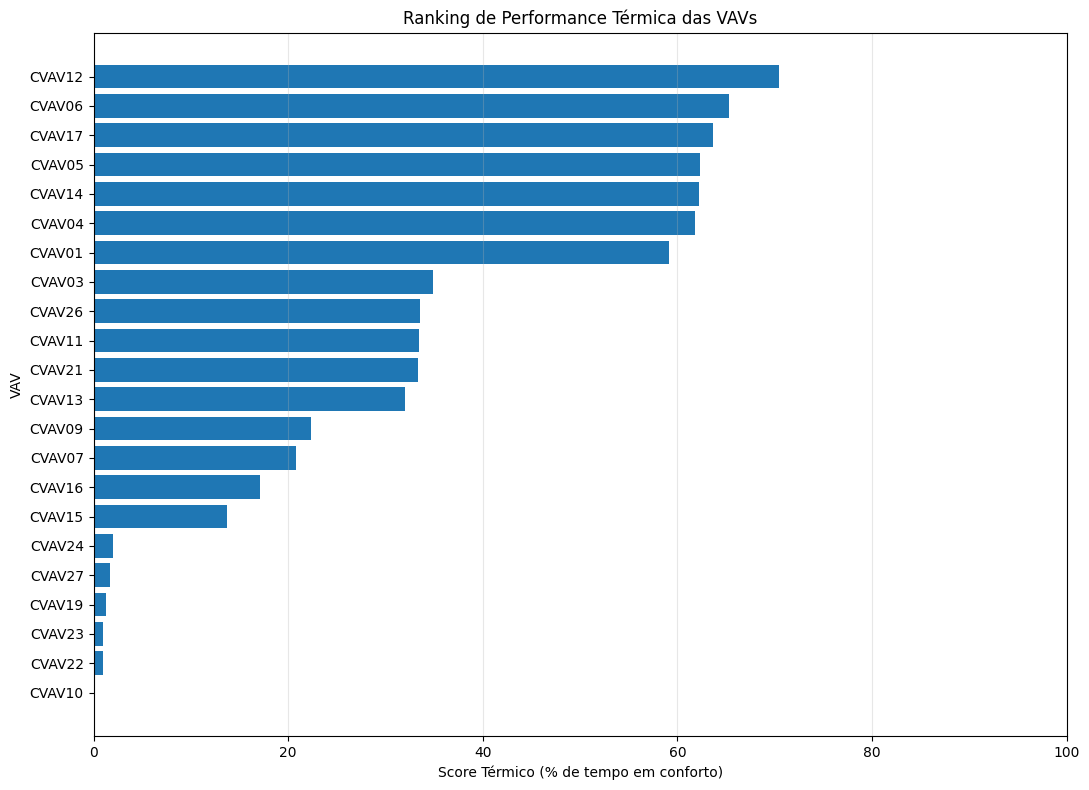

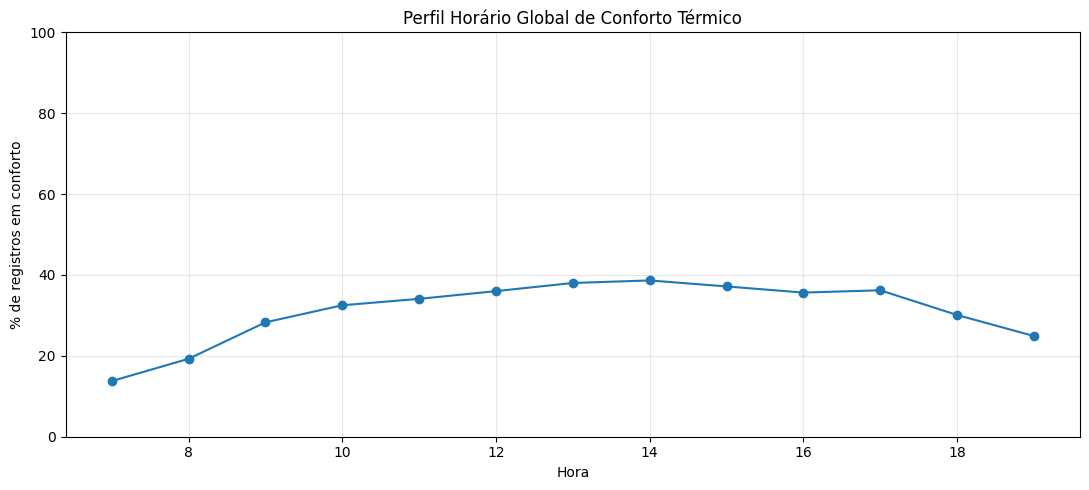

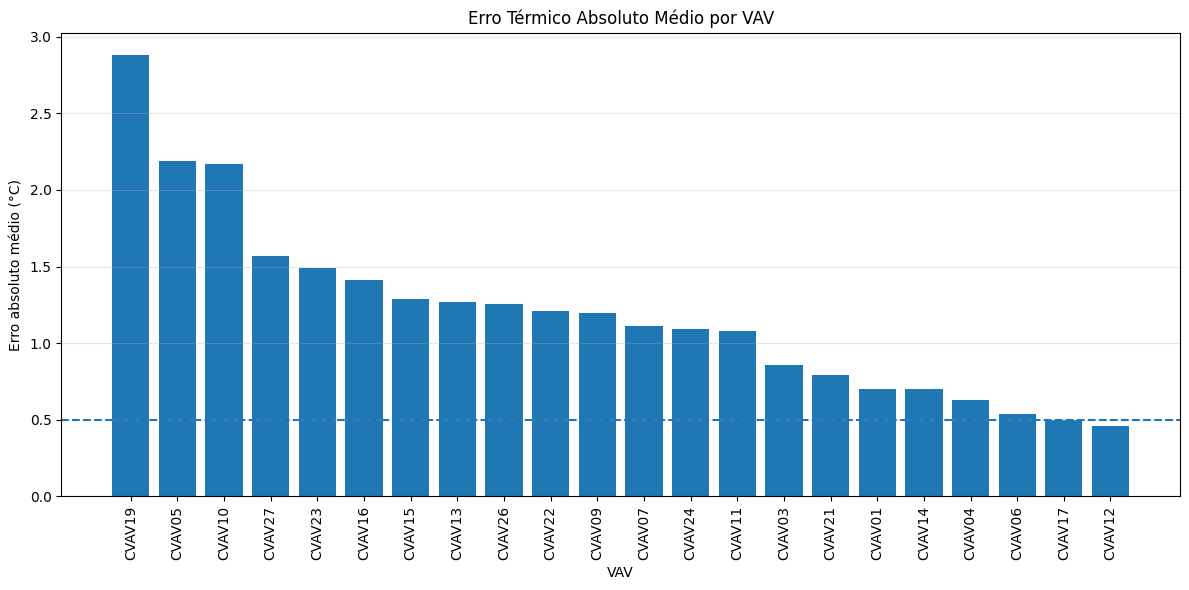


RANKING TÉRMICO


,Posicao_Ranking,Equipamento,FAC,Cobertura_Termica_%,Score_Termico,Classificacao_Termica,Erro_Absoluto_Medio,%_Atencao,%_Critico,%_Quente,%_Frio,Eventos_Persistentes,Maior_Evento_Min
0,1.00,CVAV12,FANC02,100.00,70.46,ATENÇÃO,0.46,18.64,10.90,23.11,6.43,26.00,530.00
1,2.00,CVAV06,FANC01,100.00,65.28,CRÍTICA,0.54,16.44,18.28,14.89,19.83,49.00,500.00
2,3.00,CVAV17,FANC02,100.00,63.61,CRÍTICA,0.50,25.19,11.20,21.32,15.07,17.00,730.00
3,4.00,CVAV05,FANC01,100.00,62.30,CRÍTICA,2.19,2.56,35.14,4.71,33.00,10.00,730.00
4,5.00,CVAV14,FANC02,100.00,62.24,CRÍTICA,0.70,12.86,24.90,34.48,3.28,21.00,730.00
5,6.00,CVAV04,FANC01,100.00,61.76,CRÍTICA,0.63,17.03,21.20,6.25,31.98,52.00,500.00
6,7.00,CVAV01,FANC01,100.00,59.14,CRÍTICA,0.70,16.62,24.24,0.00,40.86,44.00,730.00
7,8.00,CVAV03,FANC01,100.00,34.84,CRÍTICA,0.86,39.73,25.43,0.00,65.16,26.00,730.00
8,9.00,CVAV26,FANC01,100.00,33.53,CRÍTICA,1.25,13.70,52.77,1.91,64.56,44.00,730.00
9,10.00,CVAV11,FANC02,100.00,33.41,CRÍTICA,1.08,21.32,45.27,0.00,66.59,40.00,730.00



RESUMO TÉRMICO POR FANCOIL


,FAC,Registros,Quantidade_VAVs,DeltaT_Medio,Erro_Absoluto_Medio,Conforto,Atencao,Critico,Quente,Frio,%_Conforto,%_Atencao,%_Critico,%_Quente,%_Frio
0,FANC01,20084,12,-0.08,1.12,6324,3634,10126,6186,7574,31.49,18.09,50.42,30.80,37.71
1,FANC02,16790,10,-0.91,1.30,5310,2896,8584,2029,9451,31.63,17.25,51.13,12.08,56.29



PIORES EVENTOS TÉRMICOS


...


PERFIL HORÁRIO GLOBAL


,Hora,Registros,Temperatura_Media,Setpoint_Medio,DeltaT_Medio,Erro_Absoluto_Medio,Conforto,Critico,%_Conforto,%_Critico
0,7,3030,21.27,22.60,-1.34,1.78,417,2310,13.76,76.24
1,8,3030,21.46,22.62,-1.16,1.62,584,2026,19.27,66.86
2,9,3030,21.90,22.67,-0.77,1.33,857,1655,28.28,54.62
3,10,3030,22.14,22.68,-0.54,1.18,985,1519,32.51,50.13
4,11,3030,22.30,22.70,-0.40,1.11,1033,1389,34.09,45.84
5,12,3030,22.45,22.71,-0.26,1.05,1091,1347,36.01,44.46
6,13,3030,22.55,22.72,-0.17,1.00,1152,1299,38.02,42.87
7,14,3030,22.63,22.74,-0.10,0.99,1171,1296,38.65,42.77
8,15,3030,22.70,22.73,-0.03,1.03,1126,1333,37.16,43.99
9,16,3030,22.71,22.75,-0.04,1.04,1080,1337,35.64,44.13



EXPORTANDO MÓDULO 4

✅ Arquivo criado: 04_Performance_Termica_VAV.xlsx


RESUMO EXECUTIVO - MÓDULO 4

COBERTURA
------------------------------------------------------------------------------------------------------------------------
VAVs analisadas.................. 23
VAVs com dados térmicos.......... 22
VAVs sem dados térmicos.......... 1

PERFORMANCE TÉRMICA
------------------------------------------------------------------------------------------------------------------------
Conforto médio das VAVs.......... 31.50%
Erro absoluto médio............... 1.20 °C
Eventos persistentes.............. 702

FAIXAS UTILIZADAS
------------------------------------------------------------------------------------------------------------------------
CONFORTO.......................... |Delta T| <= 0.50 °C
ATENÇÃO........................... 0.50 < |Delta T| <= 1.00 °C
CRÍTICO........................... |Delta T| > 1.00 °C
PERSISTENTE....................... >= 30 minutos consecutivos

✅ MÓDULO 4 CON

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 4 - PERFORMANCE TÉRMICA E CONFORTO
#
# OBJETIVOS:
#
# 1. Utilizar a Base Analítica do núcleo consolidado
# 2. Calcular:
#       - Delta T = ZN-TEM - ZNT-SP
#       - erro absoluto
#       - condição térmica
#       - conforto
#       - atenção
#       - criticidade
#       - tempo quente
#       - tempo frio
#       - persistência dos desvios
#       - severidade
#       - eventos térmicos
#       - indicadores diários
#       - indicadores horários
#       - ranking térmico por VAV
#
# 3. Excluir do KPI oficial:
#       - ausência de ZN-TEM
#       - ausência de ZNT-SP
#       - ZNT-SP com origem BACKFILL_INICIAL
#
# 4. Preservar VAVs sem dados no resultado
# 5. Exportar todos os resultados para Excel
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 120)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 4 - PERFORMANCE TÉRMICA E CONFORTO")
print("=" * 120)


# ==================================================================================================
# 2. PARÂMETROS DO MÓDULO
# ==================================================================================================

INTERVALO_MINUTOS = 10

# --------------------------------------------------------------------------------------------------
# FAIXAS INICIAIS
#
# CONFORTO:
# |Delta T| <= 0,50 °C
#
# ATENÇÃO:
# 0,50 < |Delta T| <= 1,00 °C
#
# CRÍTICO:
# |Delta T| > 1,00 °C
# --------------------------------------------------------------------------------------------------

LIMITE_CONFORTO = 0.50
LIMITE_ATENCAO = 1.00


# --------------------------------------------------------------------------------------------------
# EVENTO PERSISTENTE
#
# Desvio fora da faixa confortável por pelo menos 30 minutos consecutivos.
# --------------------------------------------------------------------------------------------------

MINUTOS_PERSISTENCIA = 30

REGISTROS_MIN_PERSISTENCIA = int(
    MINUTOS_PERSISTENCIA / INTERVALO_MINUTOS
)


# --------------------------------------------------------------------------------------------------
# Cobertura mínima para emitir classificação/ranking oficial
# --------------------------------------------------------------------------------------------------

COBERTURA_MINIMA_KPI = 80.0


print()
print("PARÂMETROS TÉRMICOS")
print("-" * 120)

print(
    f"Conforto.......................... "
    f"|Delta T| <= {LIMITE_CONFORTO:.2f} °C"
)

print(
    f"Atenção........................... "
    f"{LIMITE_CONFORTO:.2f} < |Delta T| <= {LIMITE_ATENCAO:.2f} °C"
)

print(
    f"Crítico........................... "
    f"|Delta T| > {LIMITE_ATENCAO:.2f} °C"
)

print(
    f"Persistência mínima............... "
    f"{MINUTOS_PERSISTENCIA} minutos"
)

print(
    f"Cobertura mínima para ranking..... "
    f"{COBERTURA_MINIMA_KPI:.0f}%"
)


# ==================================================================================================
# 3. CARREGAMENTO DA BASE
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# Se o núcleo foi executado na mesma sessão, reutiliza base_analitica.
# Caso contrário, solicita upload do arquivo consolidado.
# --------------------------------------------------------------------------------------------------

try:

    base_mod4 = base_analitica.copy()

    print()
    print("✅ base_analitica encontrada na sessão.")
    print(
        f"Registros carregados: "
        f"{len(base_mod4):,}"
    )


except NameError:

    print()
    print(
        "A variável base_analitica não está disponível."
    )

    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos_excel = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos_excel) == 0:

        raise FileNotFoundError(
            "Nenhum arquivo Excel foi carregado."
        )

    ARQUIVO_BASE = arquivos_excel[0]

    base_mod4 = pd.read_excel(
        ARQUIVO_BASE,
        sheet_name="Base Analitica"
    )

    print()
    print(
        f"✅ Arquivo carregado: "
        f"{ARQUIVO_BASE}"
    )

    print(
        f"Registros carregados: "
        f"{len(base_mod4):,}"
    )


# ==================================================================================================
# 4. VALIDAÇÃO DAS COLUNAS
# ==================================================================================================

COLUNAS_OBRIGATORIAS = [
    "DataHora",
    "Equipamento",
    "FAC",
    "ZN-TEM",
    "ZNT-SP",
    "ZNT-SP_Origem"
]


faltantes = [
    coluna
    for coluna in COLUNAS_OBRIGATORIAS
    if coluna not in base_mod4.columns
]


if faltantes:

    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes}"
    )


base_mod4["DataHora"] = pd.to_datetime(
    base_mod4["DataHora"],
    errors="coerce"
)


# ==================================================================================================
# 5. INVENTÁRIO DE VAVs
# ==================================================================================================

TODAS_VAVS = sorted(
    base_mod4[
        "Equipamento"
    ]
    .dropna()
    .unique()
)


print()
print("=" * 120)
print("INVENTÁRIO DO MÓDULO 4")
print("=" * 120)

print(
    f"VAVs encontradas................. "
    f"{len(TODAS_VAVS)}"
)


# ==================================================================================================
# 6. VALIDADE DO REGISTRO TÉRMICO
# ==================================================================================================

base_mod4[
    "Valido_KPI_Termico"
] = (
    base_mod4[
        "ZN-TEM"
    ].notna()
    &
    base_mod4[
        "ZNT-SP"
    ].notna()
    &
    (
        base_mod4[
            "ZNT-SP_Origem"
        ]
        !=
        "BACKFILL_INICIAL"
    )
)


# --------------------------------------------------------------------------------------------------
# Motivo da exclusão
# --------------------------------------------------------------------------------------------------

def motivo_invalidade(row):

    if pd.isna(
        row["ZN-TEM"]
    ):
        return "SEM ZN-TEM"

    if pd.isna(
        row["ZNT-SP"]
    ):
        return "SEM ZNT-SP"

    if (
        row["ZNT-SP_Origem"]
        ==
        "BACKFILL_INICIAL"
    ):
        return "ZNT-SP BACKFILL INICIAL"

    return "VALIDO"


base_mod4[
    "Motivo_Validade_Termica"
] = base_mod4.apply(
    motivo_invalidade,
    axis=1
)


# ==================================================================================================
# 7. DELTA T
# ==================================================================================================

base_mod4[
    "DeltaT"
] = np.where(

    base_mod4[
        "Valido_KPI_Termico"
    ],

    base_mod4[
        "ZN-TEM"
    ]
    -
    base_mod4[
        "ZNT-SP"
    ],

    np.nan
)


base_mod4[
    "Erro_Absoluto_T"
] = (
    base_mod4[
        "DeltaT"
    ]
    .abs()
)


# ==================================================================================================
# 8. DIREÇÃO DO DESVIO
# ==================================================================================================

def classificar_direcao(delta):

    if pd.isna(delta):

        return "SEM DADO"

    if delta > LIMITE_CONFORTO:

        return "QUENTE"

    elif delta < -LIMITE_CONFORTO:

        return "FRIO"

    else:

        return "CONFORTO"


base_mod4[
    "Direcao_Termica"
] = (
    base_mod4[
        "DeltaT"
    ]
    .apply(
        classificar_direcao
    )
)


# ==================================================================================================
# 9. CLASSIFICAÇÃO DE SEVERIDADE
# ==================================================================================================

def classificar_severidade(erro):

    if pd.isna(erro):

        return "SEM DADO"

    if erro <= LIMITE_CONFORTO:

        return "CONFORTO"

    elif erro <= LIMITE_ATENCAO:

        return "ATENÇÃO"

    else:

        return "CRÍTICO"


base_mod4[
    "Severidade_Termica"
] = (
    base_mod4[
        "Erro_Absoluto_T"
    ]
    .apply(
        classificar_severidade
    )
)


# ==================================================================================================
# 10. FLAGS
# ==================================================================================================

base_mod4[
    "Flag_Conforto"
] = (
    base_mod4[
        "Severidade_Termica"
    ]
    ==
    "CONFORTO"
).astype(int)


base_mod4[
    "Flag_Atencao"
] = (
    base_mod4[
        "Severidade_Termica"
    ]
    ==
    "ATENÇÃO"
).astype(int)


base_mod4[
    "Flag_Critico"
] = (
    base_mod4[
        "Severidade_Termica"
    ]
    ==
    "CRÍTICO"
).astype(int)


base_mod4[
    "Flag_Quente"
] = (
    base_mod4[
        "Direcao_Termica"
    ]
    ==
    "QUENTE"
).astype(int)


base_mod4[
    "Flag_Frio"
] = (
    base_mod4[
        "Direcao_Termica"
    ]
    ==
    "FRIO"
).astype(int)


base_mod4[
    "Flag_Fora_Conforto"
] = (
    base_mod4[
        "Erro_Absoluto_T"
    ]
    >
    LIMITE_CONFORTO
).fillna(False).astype(int)


# ==================================================================================================
# 11. COBERTURA TÉRMICA POR VAV
# ==================================================================================================

cobertura_termica = (
    base_mod4
    .groupby(
        "Equipamento",
        observed=True
    )
    .agg(
        Registros_Esperados=(
            "DataHora",
            "size"
        ),

        Registros_Validos_Termicos=(
            "Valido_KPI_Termico",
            "sum"
        )
    )
    .reset_index()
)


cobertura_termica[
    "Cobertura_Termica_%"
] = (
    cobertura_termica[
        "Registros_Validos_Termicos"
    ]
    /
    cobertura_termica[
        "Registros_Esperados"
    ]
    *
    100
)


# ==================================================================================================
# 12. KPIs TÉRMICOS PRINCIPAIS
# ==================================================================================================

dados_validos = base_mod4[
    base_mod4[
        "Valido_KPI_Termico"
    ]
].copy()


resumo_termico = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros_Validos=(
            "DataHora",
            "size"
        ),

        Temperatura_Media=(
            "ZN-TEM",
            "mean"
        ),

        Setpoint_Medio=(
            "ZNT-SP",
            "mean"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        DeltaT_Minimo=(
            "DeltaT",
            "min"
        ),

        DeltaT_Maximo=(
            "DeltaT",
            "max"
        ),

        Registros_Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Registros_Atencao=(
            "Flag_Atencao",
            "sum"
        ),

        Registros_Criticos=(
            "Flag_Critico",
            "sum"
        ),

        Registros_Quente=(
            "Flag_Quente",
            "sum"
        ),

        Registros_Frio=(
            "Flag_Frio",
            "sum"
        )
    )
    .reset_index()
)


# ==================================================================================================
# 13. ADICIONAR COBERTURA
# ==================================================================================================

resumo_termico = resumo_termico.merge(
    cobertura_termica,
    on="Equipamento",
    how="right"
)


# ==================================================================================================
# 14. PERCENTUAIS
# ==================================================================================================

for coluna_origem, coluna_destino in [

    (
        "Registros_Conforto",
        "%_Conforto"
    ),

    (
        "Registros_Atencao",
        "%_Atencao"
    ),

    (
        "Registros_Criticos",
        "%_Critico"
    ),

    (
        "Registros_Quente",
        "%_Quente"
    ),

    (
        "Registros_Frio",
        "%_Frio"
    )
]:

    resumo_termico[
        coluna_destino
    ] = np.where(

        resumo_termico[
            "Registros_Validos_Termicos"
        ]
        > 0,

        resumo_termico[
            coluna_origem
        ]
        /
        resumo_termico[
            "Registros_Validos_Termicos"
        ]
        *
        100,

        np.nan
    )


# ==================================================================================================
# 15. TEMPO EM MINUTOS E HORAS
# ==================================================================================================

resumo_termico[
    "Tempo_Conforto_h"
] = (
    resumo_termico[
        "Registros_Conforto"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_termico[
    "Tempo_Atencao_h"
] = (
    resumo_termico[
        "Registros_Atencao"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_termico[
    "Tempo_Critico_h"
] = (
    resumo_termico[
        "Registros_Criticos"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_termico[
    "Tempo_Quente_h"
] = (
    resumo_termico[
        "Registros_Quente"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_termico[
    "Tempo_Frio_h"
] = (
    resumo_termico[
        "Registros_Frio"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


# ==================================================================================================
# 16. EVENTOS DE DESCONFORTO
# ==================================================================================================

def detectar_eventos_termicos(df):

    eventos = []

    for equipamento in (
        df[
            "Equipamento"
        ]
        .dropna()
        .unique()
    ):

        temp = (
            df[
                df["Equipamento"]
                ==
                equipamento
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        # ------------------------------------------------------------------------------------------
        # Somente registros válidos
        # ------------------------------------------------------------------------------------------

        temp[
            "Evento_Ativo"
        ] = (
            temp[
                "Valido_KPI_Termico"
            ]
            &
            (
                temp[
                    "Erro_Absoluto_T"
                ]
                >
                LIMITE_CONFORTO
            )
        )


        # ------------------------------------------------------------------------------------------
        # Nova sequência também ocorre quando há quebra de tempo maior que 10 minutos
        # ------------------------------------------------------------------------------------------

        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_sequencia = (
            temp[
                "Evento_Ativo"
            ]
            !=
            temp[
                "Evento_Ativo"
            ]
            .shift()
        ) | (
            temp[
                "Dif_Min"
            ]
            >
            INTERVALO_MINUTOS
        )


        temp[
            "_Grupo_Evento"
        ] = (
            nova_sequencia
            .cumsum()
        )


        temp_eventos = temp[
            temp[
                "Evento_Ativo"
            ]
        ].copy()


        if len(
            temp_eventos
        ) == 0:

            continue


        for _, grupo in (
            temp_eventos
            .groupby(
                "_Grupo_Evento"
            )
        ):

            qtd = len(
                grupo
            )

            duracao = (
                qtd
                *
                INTERVALO_MINUTOS
            )


            delta_medio = (
                grupo[
                    "DeltaT"
                ]
                .mean()
            )


            # --------------------------------------------------------------------------------------
            # Direção predominante
            # --------------------------------------------------------------------------------------

            if delta_medio > 0:

                direcao = "QUENTE"

            else:

                direcao = "FRIO"


            eventos.append({

                "Equipamento":
                    equipamento,

                "FAC":
                    grupo[
                        "FAC"
                    ].iloc[0]
                    if "FAC" in grupo.columns
                    else np.nan,

                "Inicio":
                    grupo[
                        "DataHora"
                    ].min(),

                "Fim":
                    grupo[
                        "DataHora"
                    ].max(),

                "Registros":
                    qtd,

                "Duracao_Min":
                    duracao,

                "Duracao_h":
                    duracao / 60,

                "Direcao":
                    direcao,

                "DeltaT_Medio":
                    delta_medio,

                "Erro_Absoluto_Medio":
                    grupo[
                        "Erro_Absoluto_T"
                    ]
                    .mean(),

                "Erro_Absoluto_Maximo":
                    grupo[
                        "Erro_Absoluto_T"
                    ]
                    .max(),

                "Persistente":
                    (
                        qtd
                        >=
                        REGISTROS_MIN_PERSISTENCIA
                    )

            })


    return pd.DataFrame(
        eventos
    )


eventos_termicos = detectar_eventos_termicos(
    base_mod4
)


# ==================================================================================================
# 17. EVENTOS PERSISTENTES
# ==================================================================================================

if len(
    eventos_termicos
) > 0:

    eventos_persistentes = (
        eventos_termicos[
            eventos_termicos[
                "Persistente"
            ]
            ==
            True
        ]
        .copy()
    )

else:

    eventos_persistentes = pd.DataFrame()


# ==================================================================================================
# 18. RESUMO DOS EVENTOS POR VAV
# ==================================================================================================

if len(
    eventos_termicos
) > 0:

    resumo_eventos = (
        eventos_termicos
        .groupby(
            "Equipamento",
            observed=True
        )
        .agg(

            Total_Eventos=(
                "Inicio",
                "count"
            ),

            Eventos_Persistentes=(
                "Persistente",
                "sum"
            ),

            Maior_Evento_Min=(
                "Duracao_Min",
                "max"
            ),

            Tempo_Total_Desconforto_h=(
                "Duracao_h",
                "sum"
            ),

            Maior_Erro_Evento=(
                "Erro_Absoluto_Maximo",
                "max"
            )

        )
        .reset_index()
    )

else:

    resumo_eventos = pd.DataFrame({
        "Equipamento":
            TODAS_VAVS,

        "Total_Eventos":
            0,

        "Eventos_Persistentes":
            0,

        "Maior_Evento_Min":
            0,

        "Tempo_Total_Desconforto_h":
            0,

        "Maior_Erro_Evento":
            np.nan
    })


# ==================================================================================================
# 19. INTEGRAR EVENTOS AO RESUMO
# ==================================================================================================

resumo_termico = resumo_termico.merge(
    resumo_eventos,
    on="Equipamento",
    how="left"
)


for coluna in [
    "Total_Eventos",
    "Eventos_Persistentes",
    "Maior_Evento_Min",
    "Tempo_Total_Desconforto_h"
]:

    if coluna in resumo_termico.columns:

        resumo_termico[
            coluna
        ] = (
            resumo_termico[
                coluna
            ]
            .fillna(0)
        )


# ==================================================================================================
# 20. ÍNDICE TÉRMICO PRELIMINAR
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# Para este módulo, um índice simples:
#
# Score Termico = % do tempo dentro da faixa confortável
#
# Não é ainda o Health Score final.
# --------------------------------------------------------------------------------------------------

resumo_termico[
    "Score_Termico"
] = resumo_termico[
    "%_Conforto"
]


# ==================================================================================================
# 21. CLASSIFICAÇÃO DO SCORE TÉRMICO
# ==================================================================================================

def classificar_score_termico(row):

    cobertura = row[
        "Cobertura_Termica_%"
    ]

    score = row[
        "Score_Termico"
    ]


    if pd.isna(
        cobertura
    ) or cobertura == 0:

        return "SEM DADOS"


    if (
        cobertura
        <
        COBERTURA_MINIMA_KPI
    ):

        return "BAIXA CONFIABILIDADE"


    if pd.isna(score):

        return "SEM RESULTADO"


    if score >= 90:

        return "EXCELENTE"

    elif score >= 80:

        return "BOA"

    elif score >= 70:

        return "ATENÇÃO"

    else:

        return "CRÍTICA"


resumo_termico[
    "Classificacao_Termica"
] = resumo_termico.apply(
    classificar_score_termico,
    axis=1
)


# ==================================================================================================
# 22. RANKING TÉRMICO
# ==================================================================================================

ranking_termico = resumo_termico.copy()


ranking_termico[
    "Elegivel_Ranking"
] = (
    ranking_termico[
        "Cobertura_Termica_%"
    ]
    >=
    COBERTURA_MINIMA_KPI
)


ranking_termico = (
    ranking_termico
    .sort_values(
        [
            "Elegivel_Ranking",
            "Score_Termico",
            "Erro_Absoluto_Medio"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


ranking_termico[
    "Posicao_Ranking"
] = np.nan


mascara_elegivel = (
    ranking_termico[
        "Elegivel_Ranking"
    ]
)


ranking_termico.loc[
    mascara_elegivel,
    "Posicao_Ranking"
] = np.arange(
    1,
    mascara_elegivel.sum() + 1
)


# ==================================================================================================
# 23. INDICADORES DIÁRIOS
# ==================================================================================================

dados_validos[
    "Data"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.date
)


indicadores_diarios = (
    dados_validos
    .groupby(
        [
            "Data",
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Temperatura_Media=(
            "ZN-TEM",
            "mean"
        ),

        Setpoint_Medio=(
            "ZNT-SP",
            "mean"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Atencao=(
            "Flag_Atencao",
            "sum"
        ),

        Critico=(
            "Flag_Critico",
            "sum"
        ),

        Quente=(
            "Flag_Quente",
            "sum"
        ),

        Frio=(
            "Flag_Frio",
            "sum"
        )

    )
    .reset_index()
)


for origem, destino in [

    ("Conforto", "%_Conforto"),
    ("Atencao", "%_Atencao"),
    ("Critico", "%_Critico"),
    ("Quente", "%_Quente"),
    ("Frio", "%_Frio")

]:

    indicadores_diarios[
        destino
    ] = (
        indicadores_diarios[
            origem
        ]
        /
        indicadores_diarios[
            "Registros"
        ]
        *
        100
    )


# ==================================================================================================
# 24. INDICADORES POR HORA
# ==================================================================================================

dados_validos[
    "Hora"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.hour
)


indicadores_horarios = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC",
            "Hora"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Temperatura_Media=(
            "ZN-TEM",
            "mean"
        ),

        Setpoint_Medio=(
            "ZNT-SP",
            "mean"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Critico=(
            "Flag_Critico",
            "sum"
        ),

        Quente=(
            "Flag_Quente",
            "sum"
        ),

        Frio=(
            "Flag_Frio",
            "sum"
        )

    )
    .reset_index()
)


indicadores_horarios[
    "%_Conforto"
] = (
    indicadores_horarios[
        "Conforto"
    ]
    /
    indicadores_horarios[
        "Registros"
    ]
    *
    100
)


indicadores_horarios[
    "%_Critico"
] = (
    indicadores_horarios[
        "Critico"
    ]
    /
    indicadores_horarios[
        "Registros"
    ]
    *
    100
)


indicadores_horarios[
    "%_Quente"
] = (
    indicadores_horarios[
        "Quente"
    ]
    /
    indicadores_horarios[
        "Registros"
    ]
    *
    100
)


indicadores_horarios[
    "%_Frio"
] = (
    indicadores_horarios[
        "Frio"
    ]
    /
    indicadores_horarios[
        "Registros"
    ]
    *
    100
)


# ==================================================================================================
# 25. PERFIL HORÁRIO GLOBAL
# ==================================================================================================

perfil_horario_global = (
    dados_validos
    .groupby(
        "Hora",
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Temperatura_Media=(
            "ZN-TEM",
            "mean"
        ),

        Setpoint_Medio=(
            "ZNT-SP",
            "mean"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Critico=(
            "Flag_Critico",
            "sum"
        )

    )
    .reset_index()
)


perfil_horario_global[
    "%_Conforto"
] = (
    perfil_horario_global[
        "Conforto"
    ]
    /
    perfil_horario_global[
        "Registros"
    ]
    *
    100
)


perfil_horario_global[
    "%_Critico"
] = (
    perfil_horario_global[
        "Critico"
    ]
    /
    perfil_horario_global[
        "Registros"
    ]
    *
    100
)


# ==================================================================================================
# 26. RESUMO POR FANCOIL
# ==================================================================================================

resumo_fac_termico = (
    dados_validos
    .dropna(
        subset=["FAC"]
    )
    .groupby(
        "FAC",
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Quantidade_VAVs=(
            "Equipamento",
            "nunique"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Atencao=(
            "Flag_Atencao",
            "sum"
        ),

        Critico=(
            "Flag_Critico",
            "sum"
        ),

        Quente=(
            "Flag_Quente",
            "sum"
        ),

        Frio=(
            "Flag_Frio",
            "sum"
        )

    )
    .reset_index()
)


for origem, destino in [

    ("Conforto", "%_Conforto"),
    ("Atencao", "%_Atencao"),
    ("Critico", "%_Critico"),
    ("Quente", "%_Quente"),
    ("Frio", "%_Frio")

]:

    resumo_fac_termico[
        destino
    ] = (
        resumo_fac_termico[
            origem
        ]
        /
        resumo_fac_termico[
            "Registros"
        ]
        *
        100
    )


# ==================================================================================================
# 27. DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
# ==================================================================================================

distribuicao_severidade = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "Severidade_Termica"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


distribuicao_direcao = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "Direcao_Termica"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


# ==================================================================================================
# 28. TOP EVENTOS TÉRMICOS
# ==================================================================================================

if len(
    eventos_termicos
) > 0:

    top_eventos = (
        eventos_termicos
        .sort_values(
            [
                "Duracao_Min",
                "Erro_Absoluto_Maximo"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

else:

    top_eventos = pd.DataFrame()


# ==================================================================================================
# 29. GRÁFICO - SCORE TÉRMICO POR VAV
# ==================================================================================================

grafico_ranking = ranking_termico[
    ranking_termico[
        "Elegivel_Ranking"
    ]
].copy()


if len(
    grafico_ranking
) > 0:

    grafico_ranking = grafico_ranking.sort_values(
        "Score_Termico",
        ascending=True
    )

    plt.figure(
        figsize=(11, 8)
    )

    plt.barh(
        grafico_ranking[
            "Equipamento"
        ],
        grafico_ranking[
            "Score_Termico"
        ]
    )

    plt.xlabel(
        "Score Térmico (% de tempo em conforto)"
    )

    plt.ylabel(
        "VAV"
    )

    plt.title(
        "Ranking de Performance Térmica das VAVs"
    )

    plt.xlim(
        0,
        100
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 30. GRÁFICO - PERFIL HORÁRIO DE CONFORTO
# ==================================================================================================

if len(
    perfil_horario_global
) > 0:

    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        perfil_horario_global[
            "Hora"
        ],
        perfil_horario_global[
            "%_Conforto"
        ],
        marker="o"
    )

    plt.xlabel(
        "Hora"
    )

    plt.ylabel(
        "% de registros em conforto"
    )

    plt.title(
        "Perfil Horário Global de Conforto Térmico"
    )

    plt.ylim(
        0,
        100
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 31. GRÁFICO - ERRO ABSOLUTO MÉDIO POR VAV
# ==================================================================================================

grafico_erro = resumo_termico[
    resumo_termico[
        "Cobertura_Termica_%"
    ]
    >=
    COBERTURA_MINIMA_KPI
].copy()


if len(
    grafico_erro
) > 0:

    grafico_erro = (
        grafico_erro
        .sort_values(
            "Erro_Absoluto_Medio",
            ascending=False
        )
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        grafico_erro[
            "Equipamento"
        ],
        grafico_erro[
            "Erro_Absoluto_Medio"
        ]
    )

    plt.axhline(
        LIMITE_CONFORTO,
        linestyle="--"
    )

    plt.xlabel(
        "VAV"
    )

    plt.ylabel(
        "Erro absoluto médio (°C)"
    )

    plt.title(
        "Erro Térmico Absoluto Médio por VAV"
    )

    plt.xticks(
        rotation=90
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 32. RELATÓRIOS NA TELA
# ==================================================================================================

print()
print("=" * 120)
print("RANKING TÉRMICO")
print("=" * 120)

display(
    ranking_termico[
        [
            "Posicao_Ranking",
            "Equipamento",
            "FAC",
            "Cobertura_Termica_%",
            "Score_Termico",
            "Classificacao_Termica",
            "Erro_Absoluto_Medio",
            "%_Atencao",
            "%_Critico",
            "%_Quente",
            "%_Frio",
            "Eventos_Persistentes",
            "Maior_Evento_Min"
        ]
    ]
)


print()
print("=" * 120)
print("RESUMO TÉRMICO POR FANCOIL")
print("=" * 120)

display(
    resumo_fac_termico
)


print()
print("=" * 120)
print("PIORES EVENTOS TÉRMICOS")
print("=" * 120)

if len(
    top_eventos
) > 0:

    display(
        top_eventos.head(30)
    )

else:

    print(
        "Nenhum evento térmico identificado."
    )


print()
print("=" * 120)
print("PERFIL HORÁRIO GLOBAL")
print("=" * 120)

display(
    perfil_horario_global
)


# ==================================================================================================
# 33. BASE TÉRMICA DETALHADA
# ==================================================================================================

colunas_termicas = [

    "DataHora",
    "Data",
    "Ano",
    "Mes",
    "AnoMes",
    "DiaSemana",
    "Hora",
    "Minuto",

    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",
    "ZNT-SP_Origem",

    "Valido_KPI_Termico",
    "Motivo_Validade_Termica",

    "DeltaT",
    "Erro_Absoluto_T",

    "Direcao_Termica",
    "Severidade_Termica",

    "Flag_Conforto",
    "Flag_Atencao",
    "Flag_Critico",
    "Flag_Quente",
    "Flag_Frio",
    "Flag_Fora_Conforto"

]


colunas_termicas = [
    coluna
    for coluna in colunas_termicas
    if coluna in base_mod4.columns
]


base_termica_detalhada = base_mod4[
    colunas_termicas
].copy()


# ==================================================================================================
# 34. EXPORTAÇÃO PARA EXCEL
# ==================================================================================================

ARQUIVO_SAIDA = (
    "04_Performance_Termica_VAV.xlsx"
)


print()
print("=" * 120)
print("EXPORTANDO MÓDULO 4")
print("=" * 120)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    ranking_termico.to_excel(
        writer,
        sheet_name="Ranking Termico",
        index=False
    )


    resumo_termico.to_excel(
        writer,
        sheet_name="Resumo VAV",
        index=False
    )


    resumo_fac_termico.to_excel(
        writer,
        sheet_name="Resumo FAC",
        index=False
    )


    indicadores_diarios.to_excel(
        writer,
        sheet_name="Indicadores Diarios",
        index=False
    )


    indicadores_horarios.to_excel(
        writer,
        sheet_name="Indicadores Horarios",
        index=False
    )


    perfil_horario_global.to_excel(
        writer,
        sheet_name="Perfil Horario Global",
        index=False
    )


    eventos_termicos.to_excel(
        writer,
        sheet_name="Eventos Termicos",
        index=False
    )


    eventos_persistentes.to_excel(
        writer,
        sheet_name="Eventos Persistentes",
        index=False
    )


    distribuicao_severidade.to_excel(
        writer,
        sheet_name="Distrib Severidade",
        index=False
    )


    distribuicao_direcao.to_excel(
        writer,
        sheet_name="Distrib Direcao",
        index=False
    )


    cobertura_termica.to_excel(
        writer,
        sheet_name="Cobertura Termica",
        index=False
    )


    base_termica_detalhada.to_excel(
        writer,
        sheet_name="Base Termica",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: "
    f"{ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 35. RESUMO EXECUTIVO
# ==================================================================================================

vavs_com_dados = (
    resumo_termico[
        "Registros_Validos_Termicos"
    ]
    .fillna(0)
    >
    0
).sum()


vavs_sem_dados = (
    resumo_termico[
        "Registros_Validos_Termicos"
    ]
    .fillna(0)
    ==
    0
).sum()


media_conforto = (
    resumo_termico[
        "%_Conforto"
    ]
    .mean()
)


media_erro = (
    resumo_termico[
        "Erro_Absoluto_Medio"
    ]
    .mean()
)


total_eventos_persistentes = (
    resumo_termico[
        "Eventos_Persistentes"
    ]
    .sum()
)


print()
print()
print("=" * 120)
print("RESUMO EXECUTIVO - MÓDULO 4")
print("=" * 120)


print()
print("COBERTURA")
print("-" * 120)

print(
    f"VAVs analisadas.................. "
    f"{len(TODAS_VAVS)}"
)

print(
    f"VAVs com dados térmicos.......... "
    f"{vavs_com_dados}"
)

print(
    f"VAVs sem dados térmicos.......... "
    f"{vavs_sem_dados}"
)


print()
print("PERFORMANCE TÉRMICA")
print("-" * 120)

print(
    f"Conforto médio das VAVs.......... "
    f"{media_conforto:.2f}%"
    if pd.notna(media_conforto)
    else
    "Conforto médio das VAVs.......... N/D"
)

print(
    f"Erro absoluto médio............... "
    f"{media_erro:.2f} °C"
    if pd.notna(media_erro)
    else
    "Erro absoluto médio............... N/D"
)

print(
    f"Eventos persistentes.............. "
    f"{int(total_eventos_persistentes)}"
)


print()
print("FAIXAS UTILIZADAS")
print("-" * 120)

print(
    f"CONFORTO.......................... "
    f"|Delta T| <= {LIMITE_CONFORTO:.2f} °C"
)

print(
    f"ATENÇÃO........................... "
    f"{LIMITE_CONFORTO:.2f} < |Delta T| <= "
    f"{LIMITE_ATENCAO:.2f} °C"
)

print(
    f"CRÍTICO........................... "
    f"|Delta T| > {LIMITE_ATENCAO:.2f} °C"
)

print(
    f"PERSISTENTE....................... "
    f">= {MINUTOS_PERSISTENCIA} minutos consecutivos"
)


print()
print("=" * 120)
print("✅ MÓDULO 4 CONCLUÍDO")
print("=" * 120)

print()
print(
    "Arquivo gerado:"
)

print(
    ARQUIVO_SAIDA
)

print()
print(
    "PRÓXIMO PASSO SUGERIDO:"
)

print(
    "Validar o comportamento térmico encontrado e, "
    "depois, avançar ao MÓDULO 5 - PERFORMANCE DE VAZÃO E CAPACIDADE."
)


# ==================================================================================================
# 36. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 5 - PERFORMANCE DE VAZÃO E UTILIZAÇÃO DE CAPACIDADE

PARÂMETROS
------------------------------------------------------------------------------------------------------------------------
Alta utilização................... >= 75% MAXFLO
Saturação......................... >= 90% MAXFLO
Acima do MAXFLO................... > 105%
Praticamente sem vazão............ <= 1% MAXFLO
Cobertura mínima ranking.......... 80%

✅ base_analitica encontrada na sessão.
Registros carregados: 38,617

INVENTÁRIO
VAVs encontradas................. 23


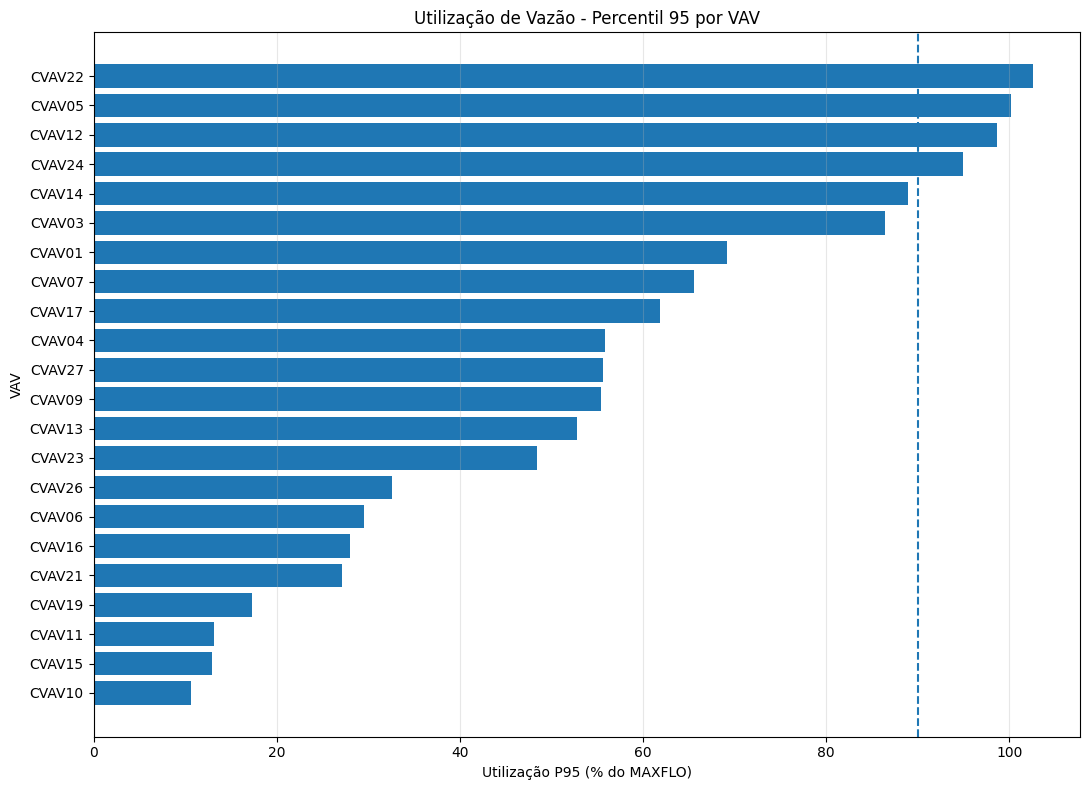

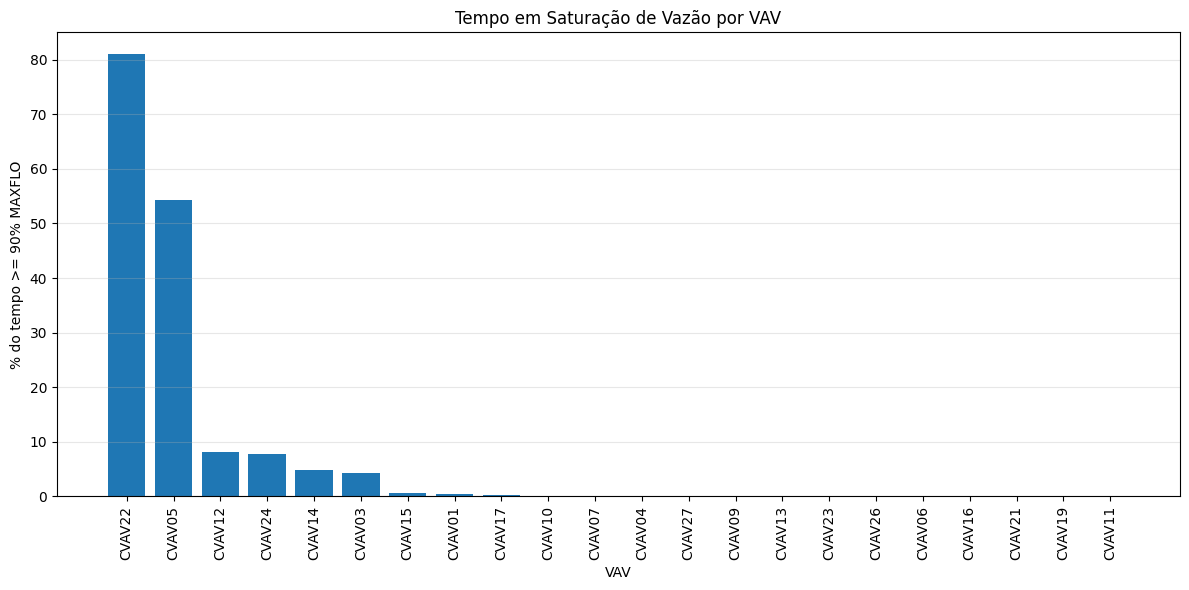

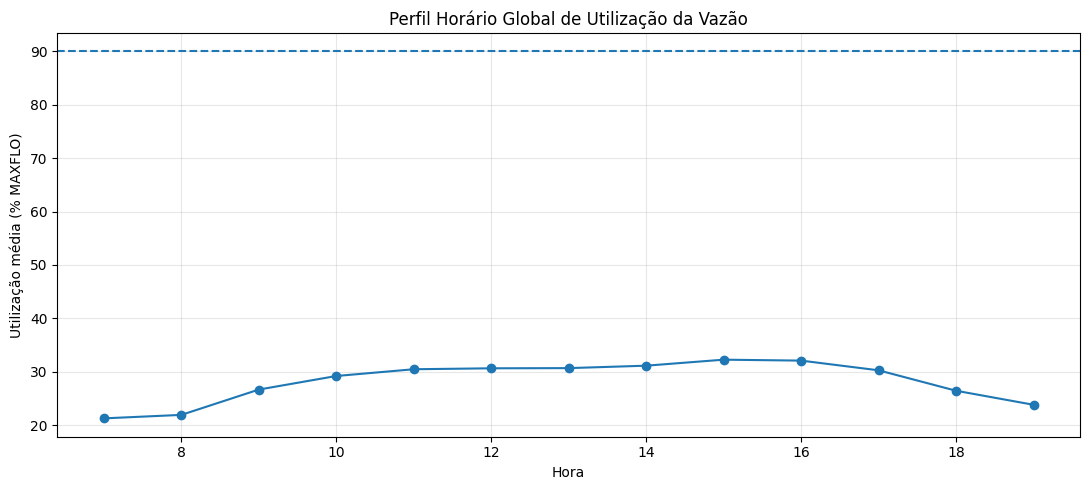


RANKING DE UTILIZAÇÃO / SATURAÇÃO


,Posicao_Saturacao,Equipamento,FAC,MAXFLO,Cobertura_Vazao_Pct,SUPFLO_Medio,Utilizacao_Media_Pct,Utilizacao_P95,Utilizacao_Maxima_Pct,Pct_Alta_Utilizacao,Pct_Saturacao,Pct_Acima_MAXFLO,Pct_Sem_Vazao,Perfil_Capacidade
0,1.00,CVAV22,FANC01,"1,200.00",100.00,"1,032.99",86.08,102.59,108.49,83.09,80.94,0.12,4.35,ALTA DEMANDA RECORRENTE
1,2.00,CVAV05,FANC01,"2,940.00",100.00,"1,755.10",59.70,100.15,102.33,58.49,54.20,0.00,4.35,ALTA DEMANDA RECORRENTE
2,3.00,CVAV12,FANC02,"4,200.00",100.00,"2,199.47",52.37,98.62,108.07,20.19,8.16,0.06,4.41,PICOS PRÓXIMOS AO LIMITE
3,4.00,CVAV24,FANC01,"1,034.00",100.00,453.84,43.89,94.91,105.72,13.16,7.86,0.18,7.56,PICOS PRÓXIMOS AO LIMITE
4,5.00,CVAV14,FANC02,"2,840.00",100.00,"1,408.21",49.58,88.98,103.07,14.00,4.82,0.00,4.35,UTILIZAÇÃO MODERADA/ALTA
5,6.00,CVAV03,FANC01,"2,739.00",100.00,758.03,27.68,86.38,101.57,8.16,4.23,0.00,4.41,UTILIZAÇÃO MODERADA/ALTA
6,7.00,CVAV15,FANC02,"1,662.00",100.00,211.67,12.74,12.98,101.93,0.95,0.71,0.00,4.17,CAPACIDADE COM FOLGA
7,8.00,CVAV01,FANC01,600.00,100.00,118.90,19.82,69.20,102.31,2.74,0.54,0.00,3.22,CAPACIDADE COM FOLGA
8,9.00,CVAV17,FANC02,"2,375.00",100.00,752.18,31.67,61.87,99.05,1.25,0.18,0.00,4.35,CAPACIDADE COM FOLGA
9,10.00,CVAV10,FANC02,"1,140.00",100.00,113.06,9.92,10.65,96.72,0.77,0.06,0.00,2.50,CAPACIDADE COM FOLGA



RESUMO POR FANCOIL


,FAC,Quantidade_VAVs,Registros,Utilizacao_Media_Pct,Utilizacao_Mediana_Pct,Saturacao,Acima_MAXFLO,Sem_Vazao,Pct_Saturacao,Pct_Acima_MAXFLO,Pct_Sem_Vazao
0,FANC01,12,20148,32.66,21.15,2481,5,859,12.31,0.02,4.26
1,FANC02,10,16790,23.59,11.85,234,1,776,1.39,0.01,4.62



PERFIL HORÁRIO GLOBAL


...


MAIORES EXTRAPOLAÇÕES DO MAXFLO


,DataHora,Equipamento,FAC,SUPFLO,MAXFLO,Utilizacao_Vazao_Pct
0,2026-07-30 14:10:00,CVAV22,FANC01,"1,301.87",1200,108.49
1,2026-07-28 18:20:00,CVAV12,FANC02,"4,538.74",4200,108.07
2,2026-07-27 08:20:00,CVAV24,FANC01,"1,093.12",1034,105.72
3,2026-07-08 07:20:00,CVAV24,FANC01,"1,091.07",1034,105.52
4,2026-07-01 17:40:00,CVAV22,FANC01,"1,265.31",1200,105.44
5,2026-07-27 07:50:00,CVAV24,FANC01,"1,087.79",1034,105.20



EXPORTANDO MÓDULO 5

✅ Arquivo criado: 05_Performance_Vazao_Capacidade_VAV.xlsx


RESUMO EXECUTIVO - MÓDULO 5

COBERTURA
------------------------------------------------------------------------------------------------------------------------
VAVs analisadas.................. 23
VAVs com dados de vazão.......... 22
VAVs sem dados de vazão.......... 1

UTILIZAÇÃO
------------------------------------------------------------------------------------------------------------------------
Utilização média global........... 28.54%
Tempo global em saturação......... 7.35%
Tempo acima de 105% MAXFLO...... 0.02%

INTERPRETAÇÃO
------------------------------------------------------------------------------------------------------------------------
Alta utilização isoladamente não significa falha.
O resultado será cruzado posteriormente com temperatura e posição do damper.

✅ MÓDULO 5 CONCLUÍDO

PRÓXIMO PASSO:
MÓDULO 6 - DPRPOS + TEMPERATURA + VAZÃO / MAXFLO


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 5 - PERFORMANCE DE VAZÃO E UTILIZAÇÃO DE CAPACIDADE
#
# VERSÃO CORRIGIDA
#
# OBJETIVOS:
#
# 1. Trabalhar sobre a Base Analítica consolidada
# 2. Avaliar SUPFLO em relação ao MAXFLO individual de cada VAV
# 3. Calcular:
#       - utilização percentual da vazão máxima
#       - margem disponível (headroom)
#       - percentis de utilização
#       - tempo em alta utilização
#       - tempo em saturação
#       - ocorrências acima do MAXFLO
#       - ocorrências de vazão zero
#       - distribuição por faixas de utilização
#       - perfil horário
#       - ranking de utilização/capacidade
#
# IMPORTANTE:
#
# Vazão baixa NÃO será considerada automaticamente falha.
# A interpretação térmica + vazão + damper será realizada nos módulos posteriores.
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 120)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 5 - PERFORMANCE DE VAZÃO E UTILIZAÇÃO DE CAPACIDADE")
print("=" * 120)


# ==================================================================================================
# 2. PARÂMETROS
# ==================================================================================================

INTERVALO_MINUTOS = 10

LIMITE_ALTA_UTILIZACAO = 75.0
LIMITE_SATURACAO = 90.0

# Acima de 105% do MAXFLO será tratado como extrapolação relevante.
LIMITE_ACIMA_MAXFLO = 105.0

# Até 1% do MAXFLO = praticamente sem vazão.
LIMITE_VAZAO_ZERO_PCT = 1.0

COBERTURA_MINIMA_KPI = 80.0


print()
print("PARÂMETROS")
print("-" * 120)

print(
    f"Alta utilização................... >= {LIMITE_ALTA_UTILIZACAO:.0f}% MAXFLO"
)

print(
    f"Saturação......................... >= {LIMITE_SATURACAO:.0f}% MAXFLO"
)

print(
    f"Acima do MAXFLO................... > {LIMITE_ACIMA_MAXFLO:.0f}%"
)

print(
    f"Praticamente sem vazão............ <= {LIMITE_VAZAO_ZERO_PCT:.0f}% MAXFLO"
)

print(
    f"Cobertura mínima ranking.......... {COBERTURA_MINIMA_KPI:.0f}%"
)


# ==================================================================================================
# 3. CARREGAMENTO DA BASE
# ==================================================================================================

try:

    base_mod5 = base_analitica.copy()

    print()
    print("✅ base_analitica encontrada na sessão.")

    print(
        f"Registros carregados: "
        f"{len(base_mod5):,}"
    )


except NameError:

    print()
    print(
        "A variável base_analitica não está disponível."
    )

    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos_excel = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos_excel) == 0:

        raise FileNotFoundError(
            "Nenhum arquivo Excel foi carregado."
        )

    ARQUIVO_BASE = arquivos_excel[0]

    base_mod5 = pd.read_excel(
        ARQUIVO_BASE,
        sheet_name="Base Analitica"
    )

    print()
    print(
        f"✅ Arquivo carregado: "
        f"{ARQUIVO_BASE}"
    )

    print(
        f"Registros carregados: "
        f"{len(base_mod5):,}"
    )


# ==================================================================================================
# 4. VALIDAÇÃO DAS COLUNAS
# ==================================================================================================

COLUNAS_OBRIGATORIAS = [
    "DataHora",
    "Equipamento",
    "FAC",
    "SUPFLO",
    "MAXFLO"
]


faltantes = [
    coluna
    for coluna in COLUNAS_OBRIGATORIAS
    if coluna not in base_mod5.columns
]


if faltantes:

    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes}"
    )


base_mod5["DataHora"] = pd.to_datetime(
    base_mod5["DataHora"],
    errors="coerce"
)


# ==================================================================================================
# 5. INVENTÁRIO
# ==================================================================================================

TODAS_VAVS = sorted(
    base_mod5[
        "Equipamento"
    ]
    .dropna()
    .unique()
)


print()
print("=" * 120)
print("INVENTÁRIO")
print("=" * 120)

print(
    f"VAVs encontradas................. "
    f"{len(TODAS_VAVS)}"
)


# ==================================================================================================
# 6. VALIDAÇÃO DOS DADOS DE VAZÃO
# ==================================================================================================

base_mod5[
    "Valido_KPI_Vazao"
] = (
    base_mod5[
        "SUPFLO"
    ].notna()
    &
    base_mod5[
        "MAXFLO"
    ].notna()
    &
    (
        base_mod5[
            "MAXFLO"
        ]
        >
        0
    )
    &
    (
        base_mod5[
            "SUPFLO"
        ]
        >=
        0
    )
)


def motivo_invalidade_vazao(row):

    if pd.isna(
        row["SUPFLO"]
    ):
        return "SEM SUPFLO"

    if pd.isna(
        row["MAXFLO"]
    ):
        return "SEM MAXFLO"

    if row["MAXFLO"] <= 0:
        return "MAXFLO INVÁLIDO"

    if row["SUPFLO"] < 0:
        return "SUPFLO NEGATIVO"

    return "VALIDO"


base_mod5[
    "Motivo_Validade_Vazao"
] = base_mod5.apply(
    motivo_invalidade_vazao,
    axis=1
)


# ==================================================================================================
# 7. UTILIZAÇÃO DA CAPACIDADE
# ==================================================================================================

base_mod5[
    "Utilizacao_Vazao_Pct"
] = np.where(

    base_mod5[
        "Valido_KPI_Vazao"
    ],

    (
        base_mod5[
            "SUPFLO"
        ]
        /
        base_mod5[
            "MAXFLO"
        ]
        *
        100
    ),

    np.nan
)


# ==================================================================================================
# 8. HEADROOM / MARGEM DISPONÍVEL
# ==================================================================================================

base_mod5[
    "Headroom_Vazao"
] = np.where(

    base_mod5[
        "Valido_KPI_Vazao"
    ],

    (
        base_mod5[
            "MAXFLO"
        ]
        -
        base_mod5[
            "SUPFLO"
        ]
    ),

    np.nan
)


base_mod5[
    "Headroom_Pct"
] = np.where(

    base_mod5[
        "Valido_KPI_Vazao"
    ],

    (
        100
        -
        base_mod5[
            "Utilizacao_Vazao_Pct"
        ]
    ),

    np.nan
)


# ==================================================================================================
# 9. CLASSIFICAÇÃO POR FAIXA
# ==================================================================================================

def classificar_utilizacao(valor):

    if pd.isna(valor):
        return "SEM DADO"

    if valor <= LIMITE_VAZAO_ZERO_PCT:
        return "SEM/QUASE SEM VAZÃO"

    elif valor < 25:
        return "0-25%"

    elif valor < 50:
        return "25-50%"

    elif valor < 75:
        return "50-75%"

    elif valor < 90:
        return "75-90%"

    elif valor <= 100:
        return "90-100%"

    elif valor <= LIMITE_ACIMA_MAXFLO:
        return "100-105%"

    else:
        return ">105%"


base_mod5[
    "Faixa_Utilizacao"
] = (
    base_mod5[
        "Utilizacao_Vazao_Pct"
    ]
    .apply(
        classificar_utilizacao
    )
)


# ==================================================================================================
# 10. FLAGS OPERACIONAIS
# ==================================================================================================

base_mod5[
    "Flag_Sem_Vazao"
] = (
    base_mod5[
        "Utilizacao_Vazao_Pct"
    ]
    <=
    LIMITE_VAZAO_ZERO_PCT
).fillna(False).astype(int)


base_mod5[
    "Flag_Alta_Utilizacao"
] = (
    base_mod5[
        "Utilizacao_Vazao_Pct"
    ]
    >=
    LIMITE_ALTA_UTILIZACAO
).fillna(False).astype(int)


base_mod5[
    "Flag_Saturacao_Vazao"
] = (
    base_mod5[
        "Utilizacao_Vazao_Pct"
    ]
    >=
    LIMITE_SATURACAO
).fillna(False).astype(int)


base_mod5[
    "Flag_Acima_MAXFLO"
] = (
    base_mod5[
        "Utilizacao_Vazao_Pct"
    ]
    >
    LIMITE_ACIMA_MAXFLO
).fillna(False).astype(int)


# ==================================================================================================
# 11. COBERTURA POR VAV
# ==================================================================================================

cobertura_vazao = (
    base_mod5
    .groupby(
        "Equipamento",
        observed=True
    )
    .agg(

        Registros_Esperados=(
            "DataHora",
            "size"
        ),

        Registros_Validos_Vazao=(
            "Valido_KPI_Vazao",
            "sum"
        )

    )
    .reset_index()
)


cobertura_vazao[
    "Cobertura_Vazao_Pct"
] = (
    cobertura_vazao[
        "Registros_Validos_Vazao"
    ]
    /
    cobertura_vazao[
        "Registros_Esperados"
    ]
    *
    100
)


# ==================================================================================================
# 12. BASE VÁLIDA
# ==================================================================================================

dados_validos = base_mod5[
    base_mod5[
        "Valido_KPI_Vazao"
    ]
].copy()


# ==================================================================================================
# 13. RESUMO POR VAV
# ==================================================================================================

resumo_vazao = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros_Validos=(
            "DataHora",
            "size"
        ),

        MAXFLO=(
            "MAXFLO",
            "first"
        ),

        SUPFLO_Medio=(
            "SUPFLO",
            "mean"
        ),

        SUPFLO_Minimo=(
            "SUPFLO",
            "min"
        ),

        SUPFLO_Maximo=(
            "SUPFLO",
            "max"
        ),

        Utilizacao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Utilizacao_Mediana_Pct=(
            "Utilizacao_Vazao_Pct",
            "median"
        ),

        Utilizacao_Maxima_Pct=(
            "Utilizacao_Vazao_Pct",
            "max"
        ),

        Headroom_Medio=(
            "Headroom_Vazao",
            "mean"
        ),

        Registros_Sem_Vazao=(
            "Flag_Sem_Vazao",
            "sum"
        ),

        Registros_Alta_Utilizacao=(
            "Flag_Alta_Utilizacao",
            "sum"
        ),

        Registros_Saturacao=(
            "Flag_Saturacao_Vazao",
            "sum"
        ),

        Registros_Acima_MAXFLO=(
            "Flag_Acima_MAXFLO",
            "sum"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 14. PERCENTIS P90 / P95 / P99
# ==================================================================================================

percentis = (
    dados_validos
    .groupby(
        "Equipamento",
        observed=True
    )[
        "Utilizacao_Vazao_Pct"
    ]
    .agg(

        Utilizacao_P90=lambda x:
            x.quantile(0.90),

        Utilizacao_P95=lambda x:
            x.quantile(0.95),

        Utilizacao_P99=lambda x:
            x.quantile(0.99)

    )
    .reset_index()
)


resumo_vazao = resumo_vazao.merge(
    percentis,
    on="Equipamento",
    how="left"
)


# ==================================================================================================
# 15. ADICIONAR COBERTURA
# ==================================================================================================

resumo_vazao = resumo_vazao.merge(
    cobertura_vazao,
    on="Equipamento",
    how="right"
)


# ==================================================================================================
# 16. PERCENTUAIS OPERACIONAIS
# ==================================================================================================

for origem, destino in [

    (
        "Registros_Sem_Vazao",
        "Pct_Sem_Vazao"
    ),

    (
        "Registros_Alta_Utilizacao",
        "Pct_Alta_Utilizacao"
    ),

    (
        "Registros_Saturacao",
        "Pct_Saturacao"
    ),

    (
        "Registros_Acima_MAXFLO",
        "Pct_Acima_MAXFLO"
    )

]:

    resumo_vazao[
        destino
    ] = np.where(

        resumo_vazao[
            "Registros_Validos_Vazao"
        ]
        >
        0,

        (
            resumo_vazao[
                origem
            ]
            /
            resumo_vazao[
                "Registros_Validos_Vazao"
            ]
            *
            100
        ),

        np.nan
    )


# ==================================================================================================
# 17. TEMPOS
# ==================================================================================================

resumo_vazao[
    "Tempo_Sem_Vazao_h"
] = (
    resumo_vazao[
        "Registros_Sem_Vazao"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_vazao[
    "Tempo_Alta_Utilizacao_h"
] = (
    resumo_vazao[
        "Registros_Alta_Utilizacao"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


resumo_vazao[
    "Tempo_Saturacao_h"
] = (
    resumo_vazao[
        "Registros_Saturacao"
    ]
    *
    INTERVALO_MINUTOS
    /
    60
)


# ==================================================================================================
# 18. CLASSIFICAÇÃO DO PERFIL DE CAPACIDADE
# ==================================================================================================

def classificar_perfil_capacidade(row):

    cobertura = row[
        "Cobertura_Vazao_Pct"
    ]

    saturacao = row[
        "Pct_Saturacao"
    ]

    p95 = row[
        "Utilizacao_P95"
    ]


    if pd.isna(cobertura) or cobertura == 0:

        return "SEM DADOS"


    if cobertura < COBERTURA_MINIMA_KPI:

        return "BAIXA CONFIABILIDADE"


    if pd.isna(saturacao):

        return "SEM RESULTADO"


    if saturacao >= 30:

        return "ALTA DEMANDA RECORRENTE"


    elif p95 >= 90:

        return "PICOS PRÓXIMOS AO LIMITE"


    elif p95 >= 75:

        return "UTILIZAÇÃO MODERADA/ALTA"


    else:

        return "CAPACIDADE COM FOLGA"


resumo_vazao[
    "Perfil_Capacidade"
] = resumo_vazao.apply(
    classificar_perfil_capacidade,
    axis=1
)


# ==================================================================================================
# 19. DISTRIBUIÇÃO DAS FAIXAS
# ==================================================================================================

distribuicao_faixas = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "Faixa_Utilizacao"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


totais_eq = (
    distribuicao_faixas
    .groupby(
        "Equipamento"
    )[
        "Registros"
    ]
    .transform(
        "sum"
    )
)


distribuicao_faixas[
    "Pct"
] = (
    distribuicao_faixas[
        "Registros"
    ]
    /
    totais_eq
    *
    100
)


# ==================================================================================================
# 20. PERFIL HORÁRIO POR VAV
# ==================================================================================================

dados_validos[
    "Hora"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.hour
)


perfil_horario_vav = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC",
            "Hora"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        SUPFLO_Medio=(
            "SUPFLO",
            "mean"
        ),

        Utilizacao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Utilizacao_Maxima_Pct=(
            "Utilizacao_Vazao_Pct",
            "max"
        ),

        Saturacao=(
            "Flag_Saturacao_Vazao",
            "sum"
        )

    )
    .reset_index()
)


perfil_horario_vav[
    "Pct_Saturacao"
] = (
    perfil_horario_vav[
        "Saturacao"
    ]
    /
    perfil_horario_vav[
        "Registros"
    ]
    *
    100
)


# ==================================================================================================
# 21. PERFIL HORÁRIO GLOBAL
# ==================================================================================================

perfil_horario_global = (
    dados_validos
    .groupby(
        "Hora",
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Utilizacao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Utilizacao_Mediana_Pct=(
            "Utilizacao_Vazao_Pct",
            "median"
        ),

        Saturacao=(
            "Flag_Saturacao_Vazao",
            "sum"
        ),

        Acima_MAXFLO=(
            "Flag_Acima_MAXFLO",
            "sum"
        )

    )
    .reset_index()
)


perfil_horario_global[
    "Pct_Saturacao"
] = (
    perfil_horario_global[
        "Saturacao"
    ]
    /
    perfil_horario_global[
        "Registros"
    ]
    *
    100
)


perfil_horario_global[
    "Pct_Acima_MAXFLO"
] = (
    perfil_horario_global[
        "Acima_MAXFLO"
    ]
    /
    perfil_horario_global[
        "Registros"
    ]
    *
    100
)


# ==================================================================================================
# 22. INDICADORES DIÁRIOS
# ==================================================================================================

dados_validos[
    "Data"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.date
)


indicadores_diarios = (
    dados_validos
    .groupby(
        [
            "Data",
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        SUPFLO_Medio=(
            "SUPFLO",
            "mean"
        ),

        SUPFLO_Maximo=(
            "SUPFLO",
            "max"
        ),

        Utilizacao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Utilizacao_Maxima_Pct=(
            "Utilizacao_Vazao_Pct",
            "max"
        ),

        Saturacao=(
            "Flag_Saturacao_Vazao",
            "sum"
        ),

        Acima_MAXFLO=(
            "Flag_Acima_MAXFLO",
            "sum"
        ),

        Sem_Vazao=(
            "Flag_Sem_Vazao",
            "sum"
        )

    )
    .reset_index()
)


indicadores_diarios[
    "Pct_Saturacao"
] = (
    indicadores_diarios[
        "Saturacao"
    ]
    /
    indicadores_diarios[
        "Registros"
    ]
    *
    100
)


indicadores_diarios[
    "Pct_Acima_MAXFLO"
] = (
    indicadores_diarios[
        "Acima_MAXFLO"
    ]
    /
    indicadores_diarios[
        "Registros"
    ]
    *
    100
)


indicadores_diarios[
    "Pct_Sem_Vazao"
] = (
    indicadores_diarios[
        "Sem_Vazao"
    ]
    /
    indicadores_diarios[
        "Registros"
    ]
    *
    100
)


# ==================================================================================================
# 23. RESUMO POR FANCOIL
# ==================================================================================================

resumo_fac_vazao = (
    dados_validos
    .dropna(
        subset=["FAC"]
    )
    .groupby(
        "FAC",
        observed=True
    )
    .agg(

        Quantidade_VAVs=(
            "Equipamento",
            "nunique"
        ),

        Registros=(
            "DataHora",
            "size"
        ),

        Utilizacao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Utilizacao_Mediana_Pct=(
            "Utilizacao_Vazao_Pct",
            "median"
        ),

        Saturacao=(
            "Flag_Saturacao_Vazao",
            "sum"
        ),

        Acima_MAXFLO=(
            "Flag_Acima_MAXFLO",
            "sum"
        ),

        Sem_Vazao=(
            "Flag_Sem_Vazao",
            "sum"
        )

    )
    .reset_index()
)


for origem, destino in [

    (
        "Saturacao",
        "Pct_Saturacao"
    ),

    (
        "Acima_MAXFLO",
        "Pct_Acima_MAXFLO"
    ),

    (
        "Sem_Vazao",
        "Pct_Sem_Vazao"
    )

]:

    resumo_fac_vazao[
        destino
    ] = (
        resumo_fac_vazao[
            origem
        ]
        /
        resumo_fac_vazao[
            "Registros"
        ]
        *
        100
    )


# ==================================================================================================
# 24. RANKING DE SATURAÇÃO
# ==================================================================================================

ranking_capacidade = resumo_vazao.copy()


ranking_capacidade[
    "Elegivel_Ranking"
] = (
    ranking_capacidade[
        "Cobertura_Vazao_Pct"
    ]
    >=
    COBERTURA_MINIMA_KPI
)


ranking_capacidade = (
    ranking_capacidade
    .sort_values(
        [
            "Elegivel_Ranking",
            "Pct_Saturacao",
            "Utilizacao_P95"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


ranking_capacidade[
    "Posicao_Saturacao"
] = np.nan


mask = (
    ranking_capacidade[
        "Elegivel_Ranking"
    ]
)


ranking_capacidade.loc[
    mask,
    "Posicao_Saturacao"
] = np.arange(
    1,
    mask.sum() + 1
)


# ==================================================================================================
# 25. EVENTOS ACIMA DO MAXFLO
# ==================================================================================================

eventos_acima_maxflo = (
    dados_validos[
        dados_validos[
            "Flag_Acima_MAXFLO"
        ]
        ==
        1
    ][
        [
            "DataHora",
            "Equipamento",
            "FAC",
            "SUPFLO",
            "MAXFLO",
            "Utilizacao_Vazao_Pct"
        ]
    ]
    .copy()
)


eventos_acima_maxflo = (
    eventos_acima_maxflo
    .sort_values(
        "Utilizacao_Vazao_Pct",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ==================================================================================================
# 26. GRÁFICO - UTILIZAÇÃO P95
# ==================================================================================================

grafico_p95 = ranking_capacidade[
    ranking_capacidade[
        "Elegivel_Ranking"
    ]
].copy()


if len(
    grafico_p95
) > 0:

    grafico_p95 = (
        grafico_p95
        .sort_values(
            "Utilizacao_P95",
            ascending=True
        )
    )

    plt.figure(
        figsize=(11, 8)
    )

    plt.barh(
        grafico_p95[
            "Equipamento"
        ],
        grafico_p95[
            "Utilizacao_P95"
        ]
    )

    plt.axvline(
        LIMITE_SATURACAO,
        linestyle="--"
    )

    plt.xlabel(
        "Utilização P95 (% do MAXFLO)"
    )

    plt.ylabel(
        "VAV"
    )

    plt.title(
        "Utilização de Vazão - Percentil 95 por VAV"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 27. GRÁFICO - TEMPO EM SATURAÇÃO
# ==================================================================================================

grafico_sat = ranking_capacidade[
    ranking_capacidade[
        "Elegivel_Ranking"
    ]
].copy()


if len(
    grafico_sat
) > 0:

    grafico_sat = (
        grafico_sat
        .sort_values(
            "Pct_Saturacao",
            ascending=False
        )
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        grafico_sat[
            "Equipamento"
        ],
        grafico_sat[
            "Pct_Saturacao"
        ]
    )

    plt.xlabel(
        "VAV"
    )

    plt.ylabel(
        "% do tempo >= 90% MAXFLO"
    )

    plt.title(
        "Tempo em Saturação de Vazão por VAV"
    )

    plt.xticks(
        rotation=90
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 28. GRÁFICO - PERFIL HORÁRIO GLOBAL
# ==================================================================================================

if len(
    perfil_horario_global
) > 0:

    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        perfil_horario_global[
            "Hora"
        ],
        perfil_horario_global[
            "Utilizacao_Media_Pct"
        ],
        marker="o"
    )

    plt.axhline(
        LIMITE_SATURACAO,
        linestyle="--"
    )

    plt.xlabel(
        "Hora"
    )

    plt.ylabel(
        "Utilização média (% MAXFLO)"
    )

    plt.title(
        "Perfil Horário Global de Utilização da Vazão"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 29. RELATÓRIOS
# ==================================================================================================

print()
print("=" * 120)
print("RANKING DE UTILIZAÇÃO / SATURAÇÃO")
print("=" * 120)

display(
    ranking_capacidade[
        [
            "Posicao_Saturacao",
            "Equipamento",
            "FAC",
            "MAXFLO",
            "Cobertura_Vazao_Pct",
            "SUPFLO_Medio",
            "Utilizacao_Media_Pct",
            "Utilizacao_P95",
            "Utilizacao_Maxima_Pct",
            "Pct_Alta_Utilizacao",
            "Pct_Saturacao",
            "Pct_Acima_MAXFLO",
            "Pct_Sem_Vazao",
            "Perfil_Capacidade"
        ]
    ]
)


print()
print("=" * 120)
print("RESUMO POR FANCOIL")
print("=" * 120)

display(
    resumo_fac_vazao
)


print()
print("=" * 120)
print("PERFIL HORÁRIO GLOBAL")
print("=" * 120)

display(
    perfil_horario_global
)


print()
print("=" * 120)
print("MAIORES EXTRAPOLAÇÕES DO MAXFLO")
print("=" * 120)

if len(
    eventos_acima_maxflo
) > 0:

    display(
        eventos_acima_maxflo.head(
            50
        )
    )

else:

    print(
        "✅ Nenhuma ocorrência acima de "
        f"{LIMITE_ACIMA_MAXFLO:.0f}% do MAXFLO."
    )


# ==================================================================================================
# 30. BASE DETALHADA
# ==================================================================================================

colunas_vazao = [

    "DataHora",
    "Data",
    "Ano",
    "Mes",
    "AnoMes",
    "DiaSemana",
    "Hora",
    "Minuto",

    "Equipamento",
    "FAC",

    "SUPFLO",
    "MAXFLO",

    "Valido_KPI_Vazao",
    "Motivo_Validade_Vazao",

    "Utilizacao_Vazao_Pct",
    "Headroom_Vazao",
    "Headroom_Pct",

    "Faixa_Utilizacao",

    "Flag_Sem_Vazao",
    "Flag_Alta_Utilizacao",
    "Flag_Saturacao_Vazao",
    "Flag_Acima_MAXFLO"

]


colunas_vazao = [
    coluna
    for coluna in colunas_vazao
    if coluna in base_mod5.columns
]


base_vazao_detalhada = (
    base_mod5[
        colunas_vazao
    ]
    .copy()
)


# ==================================================================================================
# 31. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "05_Performance_Vazao_Capacidade_VAV.xlsx"
)


print()
print("=" * 120)
print("EXPORTANDO MÓDULO 5")
print("=" * 120)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    ranking_capacidade.to_excel(
        writer,
        sheet_name="Ranking Capacidade",
        index=False
    )


    resumo_vazao.to_excel(
        writer,
        sheet_name="Resumo VAV",
        index=False
    )


    resumo_fac_vazao.to_excel(
        writer,
        sheet_name="Resumo FAC",
        index=False
    )


    indicadores_diarios.to_excel(
        writer,
        sheet_name="Indicadores Diarios",
        index=False
    )


    perfil_horario_vav.to_excel(
        writer,
        sheet_name="Perfil Horario VAV",
        index=False
    )


    perfil_horario_global.to_excel(
        writer,
        sheet_name="Perfil Horario Global",
        index=False
    )


    distribuicao_faixas.to_excel(
        writer,
        sheet_name="Distribuicao Faixas",
        index=False
    )


    cobertura_vazao.to_excel(
        writer,
        sheet_name="Cobertura Vazao",
        index=False
    )


    eventos_acima_maxflo.to_excel(
        writer,
        sheet_name="Acima MAXFLO",
        index=False
    )


    base_vazao_detalhada.to_excel(
        writer,
        sheet_name="Base Vazao",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: "
    f"{ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 32. RESUMO EXECUTIVO
# ==================================================================================================

vavs_com_dados = (
    resumo_vazao[
        "Registros_Validos_Vazao"
    ]
    .fillna(0)
    >
    0
).sum()


vavs_sem_dados = (
    resumo_vazao[
        "Registros_Validos_Vazao"
    ]
    .fillna(0)
    ==
    0
).sum()


utilizacao_media_global = (
    dados_validos[
        "Utilizacao_Vazao_Pct"
    ]
    .mean()
)


saturacao_global = (
    dados_validos[
        "Flag_Saturacao_Vazao"
    ]
    .mean()
    *
    100
)


acima_max_global = (
    dados_validos[
        "Flag_Acima_MAXFLO"
    ]
    .mean()
    *
    100
)


print()
print()
print("=" * 120)
print("RESUMO EXECUTIVO - MÓDULO 5")
print("=" * 120)


print()
print("COBERTURA")
print("-" * 120)

print(
    f"VAVs analisadas.................. "
    f"{len(TODAS_VAVS)}"
)

print(
    f"VAVs com dados de vazão.......... "
    f"{vavs_com_dados}"
)

print(
    f"VAVs sem dados de vazão.......... "
    f"{vavs_sem_dados}"
)


print()
print("UTILIZAÇÃO")
print("-" * 120)

print(
    f"Utilização média global........... "
    f"{utilizacao_media_global:.2f}%"
)

print(
    f"Tempo global em saturação......... "
    f"{saturacao_global:.2f}%"
)

print(
    f"Tempo acima de {LIMITE_ACIMA_MAXFLO:.0f}% MAXFLO...... "
    f"{acima_max_global:.2f}%"
)


print()
print("INTERPRETAÇÃO")
print("-" * 120)

print(
    "Alta utilização isoladamente não significa falha."
)

print(
    "O resultado será cruzado posteriormente com temperatura "
    "e posição do damper."
)


print()
print("=" * 120)
print("✅ MÓDULO 5 CONCLUÍDO")
print("=" * 120)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "MÓDULO 6 - DPRPOS + TEMPERATURA + VAZÃO / MAXFLO"
)


# ==================================================================================================
# 33. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 6 - RESPOSTA DE CONTROLE E DIAGNÓSTICO OPERACIONAL

PARÂMETROS DE CONTROLE
-----------------------------------------------------------------------------------------------------------------------------
Conforto térmico..................... |Delta T| <= 0.50 °C
Damper baixo......................... < 25%
Damper alto.......................... >= 75%
Damper saturado...................... >= 90%
Vazão baixa.......................... < 25% MAXFLO
Vazão alta........................... >= 75% MAXFLO
Vazão saturada....................... >= 90% MAXFLO
Persistência mínima.................. 30 minutos

✅ base_analitica encontrada na sessão.
Registros carregados: 38,617

INVENTÁRIO
VAVs encontradas..................... 23


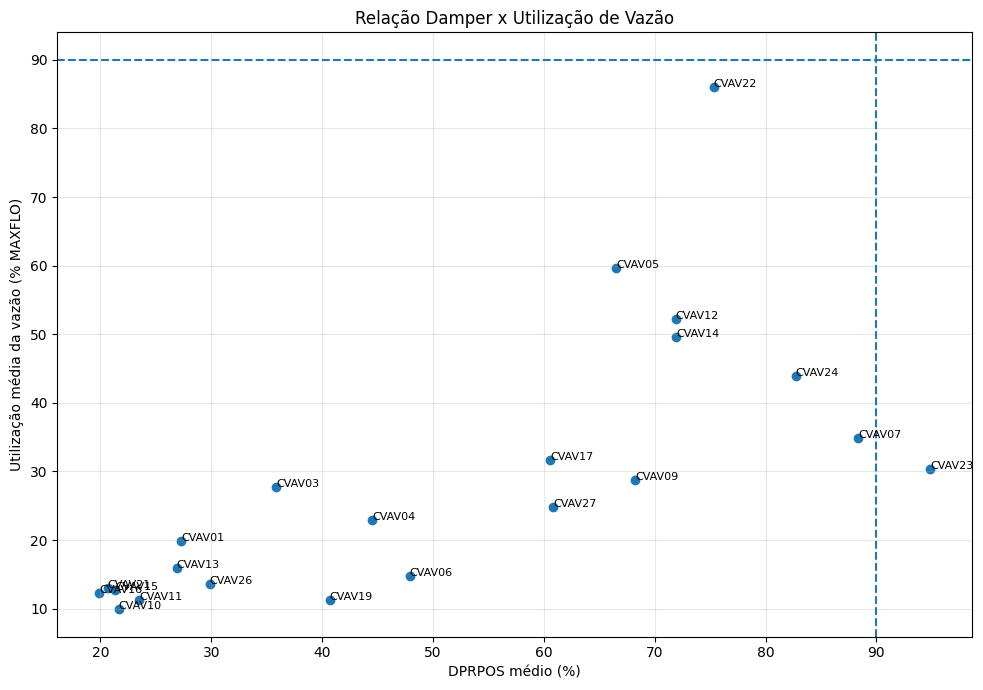

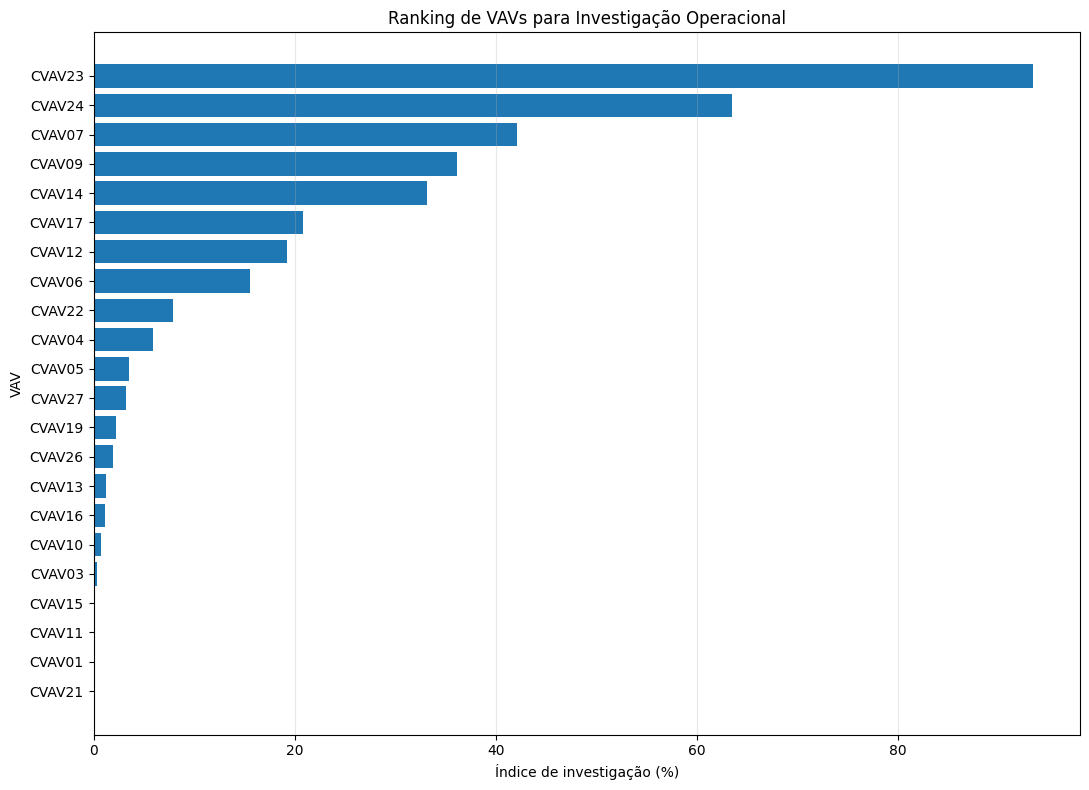


RANKING DE INVESTIGAÇÃO OPERACIONAL


,Posicao_Investigacao,Equipamento,FAC,Cobertura_Controle_Pct,DeltaT_Medio,Erro_Absoluto_Medio,DPRPOS_Medio,DPRPOS_P95,Vazao_Media_Pct,Vazao_P95,Correlacao_Damper_Vazao,Pct_Quente_Capacidade_Limite,Pct_Quente_Damper_Alto_Vazao_Baixa,Pct_Quente_Baixa_Resposta,Pct_Frio_Excesso_Insuflamento,Pct_Damper_Baixo_Vazao_Alta,Score_Coerencia_Damper_Vazao,Assinatura_Dominante,Nivel_Atencao
0,1.00,CVAV23,FANC01,100.00,1.49,1.49,94.88,100.00,30.33,48.47,0.46,0.00,91.96,1.49,0.00,0.00,84.75,QUENTE - DAMPER ALTO / VAZÃO INSUFICIENTE,CRÍTICO - ENTREGA DE AR
1,2.00,CVAV24,FANC01,100.00,1.09,1.09,82.71,100.00,43.89,94.91,0.51,6.31,55.69,1.49,0.00,0.00,91.78,QUENTE - DAMPER ALTO / VAZÃO INSUFICIENTE,CRÍTICO - ENTREGA DE AR
2,3.00,CVAV07,FANC01,100.00,0.19,1.11,88.39,100.00,34.88,65.59,0.46,0.00,41.57,0.00,0.54,0.00,92.38,QUENTE - DAMPER ALTO / VAZÃO INSUFICIENTE,CRÍTICO - ENTREGA DE AR
3,4.00,CVAV09,FANC02,99.70,-0.09,1.20,68.27,100.00,28.75,55.39,0.73,0.00,36.14,0.00,0.06,0.00,95.64,FRIO - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA,CRÍTICO - ENTREGA DE AR
4,5.00,CVAV14,FANC02,99.76,0.58,0.70,71.92,100.00,49.61,88.99,0.46,0.00,33.13,0.06,0.00,0.00,95.70,CONTROLE TÉRMICO SATISFATÓRIO,CRÍTICO - ENTREGA DE AR
5,6.00,CVAV17,FANC02,99.82,0.07,0.50,60.55,100.00,31.66,61.87,0.59,0.00,20.17,0.72,0.00,0.00,95.58,CONTROLE TÉRMICO SATISFATÓRIO,CRÍTICO - ENTREGA DE AR
6,7.00,CVAV12,FANC02,99.64,0.21,0.46,71.90,100.00,52.29,98.57,0.62,0.06,19.07,0.06,0.06,0.00,95.64,CONTROLE TÉRMICO SATISFATÓRIO,CRÍTICO - ENTREGA DE AR
7,8.00,CVAV06,FANC01,95.41,0.04,0.54,47.88,100.00,14.70,29.61,0.68,0.00,15.48,0.06,0.00,0.00,80.40,CONTROLE TÉRMICO SATISFATÓRIO,CRÍTICO - ENTREGA DE AR
8,9.00,CVAV22,FANC01,100.00,1.21,1.21,75.32,99.11,86.08,102.59,0.46,2.14,4.41,1.31,0.00,0.00,95.59,QUENTE - INVESTIGAR CONTROLE,SEM EVIDÊNCIA FORTE
9,10.00,CVAV04,FANC01,99.64,-0.33,0.63,44.50,100.00,22.88,55.71,0.32,0.00,5.92,0.00,0.00,0.00,95.76,CONTROLE TÉRMICO SATISFATÓRIO,SEM EVIDÊNCIA FORTE



DISTRIBUIÇÃO DAS ASSINATURAS


,Equipamento,FAC,Assinatura_Operacional,Registros,Pct
0,CVAV01,FANC01,CONTROLE TÉRMICO SATISFATÓRIO,993,59.14
1,CVAV01,FANC01,FRIO - CONTROLE JÁ REDUZINDO VAZÃO,632,37.64
2,CVAV01,FANC01,FRIO - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA,54,3.22
4,CVAV03,FANC01,FRIO - CONTROLE JÁ REDUZINDO VAZÃO,740,44.07
3,CVAV03,FANC01,CONTROLE TÉRMICO SATISFATÓRIO,585,34.84
6,CVAV03,FANC01,FRIO - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA,337,20.07
5,CVAV03,FANC01,FRIO - INVESTIGAR CONTROLE,12,0.71
7,CVAV03,FANC01,FRIO - POSSÍVEL EXCESSO DE INSUFLAMENTO,5,0.30
8,CVAV04,FANC01,CONTROLE TÉRMICO SATISFATÓRIO,1034,61.81
11,CVAV04,FANC01,FRIO - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA,406,24.27



EVENTOS PERSISTENTES


...


DPRPOS FORA DO RANGE 0-100%


,DataHora,Equipamento,FAC,DPRPOS,Qualidade_DPRPOS
3509,2026-07-03 07:50:00,CVAV04,FANC01,-6.37,ABAIXO DE 0%
3551,2026-07-03 14:50:00,CVAV04,FANC01,-9.40,ABAIXO DE 0%
3647,2026-07-06 18:40:00,CVAV04,FANC01,-0.78,ABAIXO DE 0%
3725,2026-07-08 07:20:00,CVAV04,FANC01,-5.69,ABAIXO DE 0%
3737,2026-07-08 09:20:00,CVAV04,FANC01,-9.73,ABAIXO DE 0%
3782,2026-07-08 16:50:00,CVAV04,FANC01,100.14,ACIMA DE 100%
5127,2026-07-02 09:50:00,CVAV05,FANC01,118.13,ACIMA DE 100%
5658,2026-07-13 13:10:00,CVAV05,FANC01,102.08,ACIMA DE 100%
5688,2026-07-13 18:10:00,CVAV05,FANC01,100.28,ACIMA DE 100%
5800,2026-07-15 12:30:00,CVAV05,FANC01,101.97,ACIMA DE 100%



EXPORTANDO MÓDULO 6

✅ Arquivo criado: 06_Diagnostico_Controle_VAV.xlsx


RESUMO EXECUTIVO - MÓDULO 6

COBERTURA
-----------------------------------------------------------------------------------------------------------------------------
VAVs analisadas...................... 23
VAVs com diagnóstico válido.......... 22
VAVs sem diagnóstico válido.......... 1

EVENTOS
-----------------------------------------------------------------------------------------------------------------------------
Eventos persistentes identificados... 916
DPRPOS fora do range 0-100%........... 112

INTERPRETAÇÃO
-----------------------------------------------------------------------------------------------------------------------------
As classificações representam assinaturas operacionais.
Ainda não representam diagnóstico definitivo de falha.
O próximo módulo utilizará também os dados do FANCOIL e a simultaneidade das VAVs.

✅ MÓDULO 6 CONCLUÍDO

PRÓXIMO PASSO:
MÓDULO 7 - DIAGNÓSTICO SISTÊMICO VAV x FANCOI

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 6 - RESPOSTA DE CONTROLE E DIAGNÓSTICO OPERACIONAL DA VAV
#
# CRUZAMENTO:
#
#       TEMPERATURA
#           +
#       SETPOINT
#           +
#       DPRPOS
#           +
#       SUPFLO / MAXFLO
#
#
# OBJETIVOS:
#
# 1. Avaliar a resposta de controle de cada VAV.
# 2. Cruzar:
#       - Delta T
#       - posição do damper
#       - utilização da vazão
# 3. Identificar assinaturas operacionais.
# 4. Identificar inconsistências Damper x Vazão.
# 5. Identificar VAVs:
#       - quentes com capacidade saturada
#       - quentes com damper alto e vazão baixa
#       - frias com vazão elevada
#       - frias com damper elevado
#       - com possível incoerência entre damper e vazão
# 6. Calcular correlação Damper x Vazão.
# 7. Criar ranking de ocorrências por VAV.
# 8. Criar análise diária e horária.
# 9. Exportar resultado completo para Excel.
#
#
# IMPORTANTE:
#
# As classificações geradas neste módulo são ASSINATURAS OPERACIONAIS.
#
# Elas não significam diagnóstico definitivo de falha.
#
# A confirmação será realizada posteriormente utilizando também:
#
#       - pressão
#       - comportamento do fancoil
#       - temperatura de insuflamento
#       - simultaneidade entre VAVs
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 350)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 125)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 6 - RESPOSTA DE CONTROLE E DIAGNÓSTICO OPERACIONAL")
print("=" * 125)


# ==================================================================================================
# 2. PARÂMETROS DO MÓDULO
# ==================================================================================================

INTERVALO_MINUTOS = 10


# --------------------------------------------------------------------------------------------------
# TEMPERATURA
# --------------------------------------------------------------------------------------------------

LIMITE_CONFORTO = 0.50

LIMITE_TERMICO_CRITICO = 1.00


# --------------------------------------------------------------------------------------------------
# DAMPER
# --------------------------------------------------------------------------------------------------

DAMPER_BAIXO = 25.0

DAMPER_ALTO = 75.0

DAMPER_SATURADO = 90.0


# --------------------------------------------------------------------------------------------------
# VAZÃO / MAXFLO
# --------------------------------------------------------------------------------------------------

VAZAO_BAIXA = 25.0

VAZAO_ALTA = 75.0

VAZAO_SATURADA = 90.0


# --------------------------------------------------------------------------------------------------
# Validação do DPRPOS
# --------------------------------------------------------------------------------------------------

DPRPOS_MIN_VALIDO = 0.0

DPRPOS_MAX_VALIDO = 100.0


# --------------------------------------------------------------------------------------------------
# Persistência
# --------------------------------------------------------------------------------------------------

MINUTOS_PERSISTENCIA = 30

REGISTROS_MIN_PERSISTENCIA = int(
    MINUTOS_PERSISTENCIA
    /
    INTERVALO_MINUTOS
)


# --------------------------------------------------------------------------------------------------
# Cobertura mínima para ranking
# --------------------------------------------------------------------------------------------------

COBERTURA_MINIMA_KPI = 80.0


print()
print("PARÂMETROS DE CONTROLE")
print("-" * 125)

print(
    f"Conforto térmico..................... "
    f"|Delta T| <= {LIMITE_CONFORTO:.2f} °C"
)

print(
    f"Damper baixo......................... "
    f"< {DAMPER_BAIXO:.0f}%"
)

print(
    f"Damper alto.......................... "
    f">= {DAMPER_ALTO:.0f}%"
)

print(
    f"Damper saturado...................... "
    f">= {DAMPER_SATURADO:.0f}%"
)

print(
    f"Vazão baixa.......................... "
    f"< {VAZAO_BAIXA:.0f}% MAXFLO"
)

print(
    f"Vazão alta........................... "
    f">= {VAZAO_ALTA:.0f}% MAXFLO"
)

print(
    f"Vazão saturada....................... "
    f">= {VAZAO_SATURADA:.0f}% MAXFLO"
)

print(
    f"Persistência mínima.................. "
    f"{MINUTOS_PERSISTENCIA} minutos"
)


# ==================================================================================================
# 3. CARREGAMENTO DA BASE
# ==================================================================================================

try:

    base_mod6 = base_analitica.copy()

    print()
    print(
        "✅ base_analitica encontrada na sessão."
    )

    print(
        f"Registros carregados: "
        f"{len(base_mod6):,}"
    )


except NameError:

    print()
    print(
        "A variável base_analitica não está disponível."
    )

    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos_excel = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos_excel) == 0:

        raise FileNotFoundError(
            "Nenhum arquivo Excel foi carregado."
        )

    ARQUIVO_BASE = arquivos_excel[0]

    base_mod6 = pd.read_excel(
        ARQUIVO_BASE,
        sheet_name="Base Analitica"
    )

    print()
    print(
        f"✅ Arquivo carregado: "
        f"{ARQUIVO_BASE}"
    )

    print(
        f"Registros carregados: "
        f"{len(base_mod6):,}"
    )


# ==================================================================================================
# 4. VALIDAÇÃO DAS COLUNAS
# ==================================================================================================

COLUNAS_OBRIGATORIAS = [

    "DataHora",

    "Equipamento",

    "FAC",

    "ZN-TEM",

    "ZNT-SP",

    "ZNT-SP_Origem",

    "DPRPOS",

    "SUPFLO",

    "MAXFLO"

]


faltantes = [
    coluna
    for coluna in COLUNAS_OBRIGATORIAS
    if coluna not in base_mod6.columns
]


if faltantes:

    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes}"
    )


base_mod6[
    "DataHora"
] = pd.to_datetime(
    base_mod6[
        "DataHora"
    ],
    errors="coerce"
)


# ==================================================================================================
# 5. INVENTÁRIO
# ==================================================================================================

TODAS_VAVS = sorted(
    base_mod6[
        "Equipamento"
    ]
    .dropna()
    .unique()
)


print()
print("=" * 125)
print("INVENTÁRIO")
print("=" * 125)

print(
    f"VAVs encontradas..................... "
    f"{len(TODAS_VAVS)}"
)


# ==================================================================================================
# 6. VALIDAÇÃO DO DPRPOS
# ==================================================================================================

base_mod6[
    "DPRPOS_Valido"
] = (
    base_mod6[
        "DPRPOS"
    ].notna()
    &
    (
        base_mod6[
            "DPRPOS"
        ]
        >=
        DPRPOS_MIN_VALIDO
    )
    &
    (
        base_mod6[
            "DPRPOS"
        ]
        <=
        DPRPOS_MAX_VALIDO
    )
)


# --------------------------------------------------------------------------------------------------
# Classificação de qualidade DPRPOS
# --------------------------------------------------------------------------------------------------

def classificar_dprpos(valor):

    if pd.isna(valor):

        return "SEM DADO"

    if valor < DPRPOS_MIN_VALIDO:

        return "ABAIXO DE 0%"

    if valor > DPRPOS_MAX_VALIDO:

        return "ACIMA DE 100%"

    return "VALIDO"


base_mod6[
    "Qualidade_DPRPOS"
] = (
    base_mod6[
        "DPRPOS"
    ]
    .apply(
        classificar_dprpos
    )
)


# ==================================================================================================
# 7. VALIDAÇÃO TÉRMICA
# ==================================================================================================

base_mod6[
    "Valido_Termico"
] = (

    base_mod6[
        "ZN-TEM"
    ].notna()

    &

    base_mod6[
        "ZNT-SP"
    ].notna()

    &

    (
        base_mod6[
            "ZNT-SP_Origem"
        ]
        !=
        "BACKFILL_INICIAL"
    )

)


# ==================================================================================================
# 8. DELTA T
# ==================================================================================================

base_mod6[
    "DeltaT"
] = np.where(

    base_mod6[
        "Valido_Termico"
    ],

    (
        base_mod6[
            "ZN-TEM"
        ]
        -
        base_mod6[
            "ZNT-SP"
        ]
    ),

    np.nan

)


base_mod6[
    "Erro_Absoluto_T"
] = (
    base_mod6[
        "DeltaT"
    ]
    .abs()
)


# ==================================================================================================
# 9. UTILIZAÇÃO DA VAZÃO
# ==================================================================================================

base_mod6[
    "Valido_Vazao"
] = (

    base_mod6[
        "SUPFLO"
    ].notna()

    &

    base_mod6[
        "MAXFLO"
    ].notna()

    &

    (
        base_mod6[
            "MAXFLO"
        ]
        >
        0
    )

    &

    (
        base_mod6[
            "SUPFLO"
        ]
        >=
        0
    )

)


base_mod6[
    "Utilizacao_Vazao_Pct"
] = np.where(

    base_mod6[
        "Valido_Vazao"
    ],

    (
        base_mod6[
            "SUPFLO"
        ]
        /
        base_mod6[
            "MAXFLO"
        ]
        *
        100
    ),

    np.nan

)


# ==================================================================================================
# 10. REGISTRO VÁLIDO PARA O DIAGNÓSTICO
# ==================================================================================================

base_mod6[
    "Valido_Diagnostico_Controle"
] = (

    base_mod6[
        "Valido_Termico"
    ]

    &

    base_mod6[
        "Valido_Vazao"
    ]

    &

    base_mod6[
        "DPRPOS_Valido"
    ]

)


# ==================================================================================================
# 11. CLASSIFICAÇÃO DA CONDIÇÃO TÉRMICA
# ==================================================================================================

def classificar_termico(delta):

    if pd.isna(delta):

        return "SEM DADO"

    if delta > LIMITE_CONFORTO:

        return "QUENTE"

    elif delta < -LIMITE_CONFORTO:

        return "FRIO"

    else:

        return "CONFORTO"


base_mod6[
    "Condicao_Termica"
] = (
    base_mod6[
        "DeltaT"
    ]
    .apply(
        classificar_termico
    )
)


# ==================================================================================================
# 12. CLASSIFICAÇÃO DO DAMPER
# ==================================================================================================

def classificar_damper(valor):

    if pd.isna(valor):

        return "SEM DADO"

    if valor < DPRPOS_MIN_VALIDO or valor > DPRPOS_MAX_VALIDO:

        return "INVÁLIDO"

    if valor < DAMPER_BAIXO:

        return "BAIXO"

    elif valor < DAMPER_ALTO:

        return "MODERADO"

    elif valor < DAMPER_SATURADO:

        return "ALTO"

    else:

        return "SATURADO"


base_mod6[
    "Faixa_Damper"
] = (
    base_mod6[
        "DPRPOS"
    ]
    .apply(
        classificar_damper
    )
)


# ==================================================================================================
# 13. CLASSIFICAÇÃO DA VAZÃO
# ==================================================================================================

def classificar_vazao(valor):

    if pd.isna(valor):

        return "SEM DADO"

    if valor < VAZAO_BAIXA:

        return "BAIXA"

    elif valor < VAZAO_ALTA:

        return "MODERADA"

    elif valor < VAZAO_SATURADA:

        return "ALTA"

    else:

        return "SATURADA"


base_mod6[
    "Faixa_Vazao"
] = (
    base_mod6[
        "Utilizacao_Vazao_Pct"
    ]
    .apply(
        classificar_vazao
    )
)


# ==================================================================================================
# 14. ASSINATURAS OPERACIONAIS
# ==================================================================================================

def diagnosticar_linha(row):

    if not row[
        "Valido_Diagnostico_Controle"
    ]:

        return "SEM DADO VÁLIDO"


    temp = row[
        "Condicao_Termica"
    ]

    damper = row[
        "DPRPOS"
    ]

    vazao = row[
        "Utilizacao_Vazao_Pct"
    ]


    # ==============================================================================================
    # CONFORTO
    # ==============================================================================================

    if temp == "CONFORTO":

        if (
            damper >= DAMPER_SATURADO
            and
            vazao >= VAZAO_SATURADA
        ):

            return "CONFORTO COM ALTA DEMANDA"


        return "CONTROLE TÉRMICO SATISFATÓRIO"


    # ==============================================================================================
    # AMBIENTE QUENTE
    # ==============================================================================================

    if temp == "QUENTE":

        # Damper e vazão no limite
        if (
            damper >= DAMPER_SATURADO
            and
            vazao >= VAZAO_SATURADA
        ):

            return "QUENTE - CAPACIDADE PRÓXIMA DO LIMITE"


        # Damper quer abrir, mas vazão não acompanha
        if (
            damper >= DAMPER_SATURADO
            and
            vazao < VAZAO_ALTA
        ):

            return "QUENTE - DAMPER ALTO / VAZÃO INSUFICIENTE"


        # Controle aparentemente não reage
        if (
            damper < DAMPER_BAIXO
            and
            vazao < VAZAO_BAIXA
        ):

            return "QUENTE - BAIXA RESPOSTA DE CONTROLE"


        # Damper intermediário
        if (
            damper < DAMPER_ALTO
            and
            vazao < VAZAO_ALTA
        ):

            return "QUENTE - DEMANDA NÃO SATISFEITA"


        return "QUENTE - INVESTIGAR CONTROLE"


    # ==============================================================================================
    # AMBIENTE FRIO
    # ==============================================================================================

    if temp == "FRIO":

        # Muito ar apesar do ambiente frio
        if (
            damper >= DAMPER_ALTO
            and
            vazao >= VAZAO_ALTA
        ):

            return "FRIO - POSSÍVEL EXCESSO DE INSUFLAMENTO"


        # Damper baixo mas fluxo ainda alto
        if (
            damper < DAMPER_BAIXO
            and
            vazao >= VAZAO_ALTA
        ):

            return "FRIO - DAMPER BAIXO / VAZÃO ALTA"


        # Controle reduziu damper e vazão
        if (
            damper < DAMPER_BAIXO
            and
            vazao < VAZAO_BAIXA
        ):

            return "FRIO - CONTROLE JÁ REDUZINDO VAZÃO"


        # Damper intermediário, ainda frio
        if (
            damper >= DAMPER_BAIXO
            and
            vazao < VAZAO_ALTA
        ):

            return "FRIO - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA"


        return "FRIO - INVESTIGAR CONTROLE"


    return "NÃO CLASSIFICADO"


base_mod6[
    "Assinatura_Operacional"
] = base_mod6.apply(
    diagnosticar_linha,
    axis=1
)


# ==================================================================================================
# 15. FLAGS DE DIAGNÓSTICO
# ==================================================================================================

base_mod6[
    "Flag_Quente_Capacidade_Limite"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "QUENTE - CAPACIDADE PRÓXIMA DO LIMITE"
).astype(int)


base_mod6[
    "Flag_Quente_Damper_Alto_Vazao_Baixa"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "QUENTE - DAMPER ALTO / VAZÃO INSUFICIENTE"
).astype(int)


base_mod6[
    "Flag_Quente_Baixa_Resposta"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "QUENTE - BAIXA RESPOSTA DE CONTROLE"
).astype(int)


base_mod6[
    "Flag_Frio_Excesso_Insuflamento"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "FRIO - POSSÍVEL EXCESSO DE INSUFLAMENTO"
).astype(int)


base_mod6[
    "Flag_Frio_Damper_Baixo_Vazao_Alta"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "FRIO - DAMPER BAIXO / VAZÃO ALTA"
).astype(int)


base_mod6[
    "Flag_Frio_Controle_Reduzindo"
] = (
    base_mod6[
        "Assinatura_Operacional"
    ]
    ==
    "FRIO - CONTROLE JÁ REDUZINDO VAZÃO"
).astype(int)


# ==================================================================================================
# 16. INCONSISTÊNCIA DAMPER x VAZÃO
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# Damper muito aberto e vazão muito baixa
# --------------------------------------------------------------------------------------------------

base_mod6[
    "Flag_Damper_Alto_Vazao_Baixa"
] = (

    (
        base_mod6[
            "DPRPOS"
        ]
        >=
        DAMPER_SATURADO
    )

    &

    (
        base_mod6[
            "Utilizacao_Vazao_Pct"
        ]
        <
        VAZAO_BAIXA
    )

    &

    base_mod6[
        "Valido_Diagnostico_Controle"
    ]

).astype(int)


# --------------------------------------------------------------------------------------------------
# Damper muito baixo e vazão muito alta
# --------------------------------------------------------------------------------------------------

base_mod6[
    "Flag_Damper_Baixo_Vazao_Alta"
] = (

    (
        base_mod6[
            "DPRPOS"
        ]
        <
        DAMPER_BAIXO
    )

    &

    (
        base_mod6[
            "Utilizacao_Vazao_Pct"
        ]
        >=
        VAZAO_ALTA
    )

    &

    base_mod6[
        "Valido_Diagnostico_Controle"
    ]

).astype(int)


# ==================================================================================================
# 17. COBERTURA DO DIAGNÓSTICO
# ==================================================================================================

cobertura_controle = (
    base_mod6
    .groupby(
        "Equipamento",
        observed=True
    )
    .agg(

        Registros_Esperados=(
            "DataHora",
            "size"
        ),

        Registros_Validos_Controle=(
            "Valido_Diagnostico_Controle",
            "sum"
        ),

        DPRPOS_Invalidos=(
            "DPRPOS_Valido",
            lambda x:
                (~x).sum()
        )

    )
    .reset_index()
)


cobertura_controle[
    "Cobertura_Controle_Pct"
] = (

    cobertura_controle[
        "Registros_Validos_Controle"
    ]

    /

    cobertura_controle[
        "Registros_Esperados"
    ]

    *

    100

)


# ==================================================================================================
# 18. BASE VÁLIDA PARA DIAGNÓSTICO
# ==================================================================================================

dados_validos = base_mod6[
    base_mod6[
        "Valido_Diagnostico_Controle"
    ]
].copy()


# ==================================================================================================
# 19. CORRELAÇÃO DAMPER x VAZÃO
# ==================================================================================================

correlacoes = []


for equipamento in TODAS_VAVS:

    temp = dados_validos[
        dados_validos[
            "Equipamento"
        ]
        ==
        equipamento
    ].copy()


    if len(temp) >= 10:

        correlacao = temp[
            [
                "DPRPOS",
                "Utilizacao_Vazao_Pct"
            ]
        ].corr().iloc[0, 1]

    else:

        correlacao = np.nan


    correlacoes.append({

        "Equipamento":
            equipamento,

        "Correlacao_Damper_Vazao":
            correlacao

    })


df_correlacao = pd.DataFrame(
    correlacoes
)


# ==================================================================================================
# 20. RESUMO POR VAV
# ==================================================================================================

resumo_controle = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros_Validos=(
            "DataHora",
            "size"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        DPRPOS_Medio=(
            "DPRPOS",
            "mean"
        ),

        DPRPOS_P95=(
            "DPRPOS",
            lambda x:
                x.quantile(0.95)
        ),

        Vazao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Vazao_P95=(
            "Utilizacao_Vazao_Pct",
            lambda x:
                x.quantile(0.95)
        ),

        Quente_Capacidade_Limite=(
            "Flag_Quente_Capacidade_Limite",
            "sum"
        ),

        Quente_Damper_Alto_Vazao_Baixa=(
            "Flag_Quente_Damper_Alto_Vazao_Baixa",
            "sum"
        ),

        Quente_Baixa_Resposta=(
            "Flag_Quente_Baixa_Resposta",
            "sum"
        ),

        Frio_Excesso_Insuflamento=(
            "Flag_Frio_Excesso_Insuflamento",
            "sum"
        ),

        Frio_Damper_Baixo_Vazao_Alta=(
            "Flag_Frio_Damper_Baixo_Vazao_Alta",
            "sum"
        ),

        Frio_Controle_Reduzindo=(
            "Flag_Frio_Controle_Reduzindo",
            "sum"
        ),

        Inconsistencia_Damper_Alto_Vazao_Baixa=(
            "Flag_Damper_Alto_Vazao_Baixa",
            "sum"
        ),

        Inconsistencia_Damper_Baixo_Vazao_Alta=(
            "Flag_Damper_Baixo_Vazao_Alta",
            "sum"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 21. ADICIONAR COBERTURA E CORRELAÇÃO
# ==================================================================================================

resumo_controle = resumo_controle.merge(
    cobertura_controle,
    on="Equipamento",
    how="right"
)


resumo_controle = resumo_controle.merge(
    df_correlacao,
    on="Equipamento",
    how="left"
)


# ==================================================================================================
# 22. PERCENTUAIS DOS PRINCIPAIS EVENTOS
# ==================================================================================================

colunas_percentuais = [

    (
        "Quente_Capacidade_Limite",
        "Pct_Quente_Capacidade_Limite"
    ),

    (
        "Quente_Damper_Alto_Vazao_Baixa",
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ),

    (
        "Quente_Baixa_Resposta",
        "Pct_Quente_Baixa_Resposta"
    ),

    (
        "Frio_Excesso_Insuflamento",
        "Pct_Frio_Excesso_Insuflamento"
    ),

    (
        "Frio_Damper_Baixo_Vazao_Alta",
        "Pct_Frio_Damper_Baixo_Vazao_Alta"
    ),

    (
        "Frio_Controle_Reduzindo",
        "Pct_Frio_Controle_Reduzindo"
    ),

    (
        "Inconsistencia_Damper_Alto_Vazao_Baixa",
        "Pct_Damper_Alto_Vazao_Baixa"
    ),

    (
        "Inconsistencia_Damper_Baixo_Vazao_Alta",
        "Pct_Damper_Baixo_Vazao_Alta"
    )

]


for origem, destino in colunas_percentuais:

    resumo_controle[
        destino
    ] = np.where(

        resumo_controle[
            "Registros_Validos_Controle"
        ]
        >
        0,

        (
            resumo_controle[
                origem
            ]
            /
            resumo_controle[
                "Registros_Validos_Controle"
            ]
            *
            100
        ),

        np.nan

    )


# ==================================================================================================
# 23. DISTRIBUIÇÃO DAS ASSINATURAS
# ==================================================================================================

distribuicao_assinaturas = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC",
            "Assinatura_Operacional"
        ],
        dropna=False,
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


totais_assinaturas = (
    distribuicao_assinaturas
    .groupby(
        "Equipamento"
    )[
        "Registros"
    ]
    .transform(
        "sum"
    )
)


distribuicao_assinaturas[
    "Pct"
] = (

    distribuicao_assinaturas[
        "Registros"
    ]

    /

    totais_assinaturas

    *

    100

)


# ==================================================================================================
# 24. ASSINATURA DOMINANTE POR VAV
# ==================================================================================================

assinatura_dominante = (
    distribuicao_assinaturas
    .sort_values(
        [
            "Equipamento",
            "Registros"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        subset=[
            "Equipamento"
        ]
    )
    [
        [
            "Equipamento",
            "Assinatura_Operacional",
            "Pct"
        ]
    ]
    .rename(
        columns={
            "Assinatura_Operacional":
                "Assinatura_Dominante",

            "Pct":
                "Pct_Assinatura_Dominante"
        }
    )
)


resumo_controle = resumo_controle.merge(
    assinatura_dominante,
    on="Equipamento",
    how="left"
)


# ==================================================================================================
# 25. CLASSIFICAÇÃO DO NÍVEL DE ATENÇÃO
# ==================================================================================================

def classificar_atencao(row):

    cobertura = row[
        "Cobertura_Controle_Pct"
    ]


    if pd.isna(cobertura) or cobertura == 0:

        return "SEM DADOS"


    if cobertura < COBERTURA_MINIMA_KPI:

        return "BAIXA CONFIABILIDADE"


    # ----------------------------------------------------------------------------------------------
    # Evidências fortes
    # ----------------------------------------------------------------------------------------------

    if (
        row[
            "Pct_Quente_Capacidade_Limite"
        ]
        >=
        20
    ):

        return "CRÍTICO - CAPACIDADE"


    if (
        row[
            "Pct_Quente_Damper_Alto_Vazao_Baixa"
        ]
        >=
        10
    ):

        return "CRÍTICO - ENTREGA DE AR"


    if (
        row[
            "Pct_Frio_Excesso_Insuflamento"
        ]
        >=
        10
    ):

        return "CRÍTICO - EXCESSO DE AR"


    if (
        row[
            "Pct_Damper_Baixo_Vazao_Alta"
        ]
        >=
        5
    ):

        return "CRÍTICO - INCONSISTÊNCIA"


    # ----------------------------------------------------------------------------------------------
    # Atenção
    # ----------------------------------------------------------------------------------------------

    if (
        row[
            "Pct_Quente_Capacidade_Limite"
        ]
        >=
        5
    ):

        return "ATENÇÃO - CAPACIDADE"


    if (
        row[
            "Pct_Quente_Baixa_Resposta"
        ]
        >=
        5
    ):

        return "ATENÇÃO - CONTROLE"


    if (
        row[
            "Pct_Damper_Alto_Vazao_Baixa"
        ]
        >=
        5
    ):

        return "ATENÇÃO - DAMPER/VAZÃO"


    return "SEM EVIDÊNCIA FORTE"


resumo_controle[
    "Nivel_Atencao"
] = resumo_controle.apply(
    classificar_atencao,
    axis=1
)


# ==================================================================================================
# 26. SCORE DE COERÊNCIA DAMPER x VAZÃO
#
# Este ainda NÃO é o Score de Controle definitivo.
#
# Ele mede apenas o percentual de registros sem inconsistências extremas:
#
# Damper >= 90% + vazão < 25%
# Damper < 25%  + vazão >= 75%
# ==================================================================================================

resumo_controle[
    "Pct_Inconsistencia_Damper_Vazao"
] = (

    resumo_controle[
        "Pct_Damper_Alto_Vazao_Baixa"
    ].fillna(0)

    +

    resumo_controle[
        "Pct_Damper_Baixo_Vazao_Alta"
    ].fillna(0)

)


resumo_controle[
    "Score_Coerencia_Damper_Vazao"
] = (

    100

    -

    resumo_controle[
        "Pct_Inconsistencia_Damper_Vazao"
    ]

).clip(
    lower=0,
    upper=100
)


# ==================================================================================================
# 27. EVENTOS PERSISTENTES DE ASSINATURA
# ==================================================================================================

def detectar_eventos_assinatura(df):

    eventos = []


    for equipamento in (
        df[
            "Equipamento"
        ]
        .dropna()
        .unique()
    ):

        temp = (
            df[
                df[
                    "Equipamento"
                ]
                ==
                equipamento
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        # Nova sequência se:
        #
        # - assinatura mudou
        # - diferença temporal > 10 minutos
        # ------------------------------------------------------------------------------------------

        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_sequencia = (

            (
                temp[
                    "Assinatura_Operacional"
                ]
                !=
                temp[
                    "Assinatura_Operacional"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo"
        ] = (
            nova_sequencia
            .cumsum()
        )


        for _, grupo in temp.groupby(
            "_Grupo"
        ):

            assinatura = grupo[
                "Assinatura_Operacional"
            ].iloc[0]


            # Não contabilizar estados normais/sem dados
            # --------------------------------------------------------------------------------------

            if assinatura in [

                "SEM DADO VÁLIDO",

                "CONTROLE TÉRMICO SATISFATÓRIO",

                "CONFORTO COM ALTA DEMANDA"

            ]:

                continue


            qtd = len(
                grupo
            )


            if qtd < REGISTROS_MIN_PERSISTENCIA:

                continue


            inicio = grupo[
                "DataHora"
            ].min()


            fim = grupo[
                "DataHora"
            ].max()


            # --------------------------------------------------------------------------------------
            # Duração cronológica real
            #
            # Exemplo:
            # 07:00 até 19:00 = 720 minutos
            #
            # Isso corrige o detalhe observado no Módulo 4.
            # --------------------------------------------------------------------------------------

            duracao_cronologica = (

                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60

            )


            # Para sequência de apenas um registro seria 0.
            # Como só usamos >= 3 registros, não há problema.
            # --------------------------------------------------------------------------------------

            eventos.append({

                "Equipamento":
                    equipamento,

                "FAC":
                    grupo[
                        "FAC"
                    ].iloc[0]
                    if "FAC" in grupo.columns
                    else np.nan,

                "Assinatura":
                    assinatura,

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Registros":
                    qtd,

                "Duracao_Cronologica_Min":
                    duracao_cronologica,

                "DeltaT_Medio":
                    grupo[
                        "DeltaT"
                    ]
                    .mean(),

                "DPRPOS_Medio":
                    grupo[
                        "DPRPOS"
                    ]
                    .mean(),

                "Vazao_Media_Pct":
                    grupo[
                        "Utilizacao_Vazao_Pct"
                    ]
                    .mean(),

                "Erro_Maximo_T":
                    grupo[
                        "Erro_Absoluto_T"
                    ]
                    .max()

            })


    return pd.DataFrame(
        eventos
    )


eventos_persistentes = detectar_eventos_assinatura(
    dados_validos
)


# ==================================================================================================
# 28. INDICADORES DIÁRIOS
# ==================================================================================================

dados_validos[
    "Data"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.date
)


indicadores_diarios = (
    dados_validos
    .groupby(
        [
            "Data",
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        DPRPOS_Medio=(
            "DPRPOS",
            "mean"
        ),

        Vazao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Quente_Capacidade_Limite=(
            "Flag_Quente_Capacidade_Limite",
            "sum"
        ),

        Quente_Damper_Alto_Vazao_Baixa=(
            "Flag_Quente_Damper_Alto_Vazao_Baixa",
            "sum"
        ),

        Frio_Excesso_Insuflamento=(
            "Flag_Frio_Excesso_Insuflamento",
            "sum"
        ),

        Inconsistencia_Damper_Vazao=(
            "Flag_Damper_Alto_Vazao_Baixa",
            "sum"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 29. PERFIL HORÁRIO
# ==================================================================================================

dados_validos[
    "Hora"
] = (
    dados_validos[
        "DataHora"
    ]
    .dt.hour
)


perfil_horario = (
    dados_validos
    .groupby(
        [
            "Equipamento",
            "FAC",
            "Hora"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        DPRPOS_Medio=(
            "DPRPOS",
            "mean"
        ),

        Vazao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        Quente_Capacidade_Limite=(
            "Flag_Quente_Capacidade_Limite",
            "sum"
        ),

        Frio_Excesso_Insuflamento=(
            "Flag_Frio_Excesso_Insuflamento",
            "sum"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 30. RANKING DE ATENÇÃO
# ==================================================================================================

# Peso meramente analítico:
#
# Soma das principais condições que justificam investigação.
# ==================================================================================================

resumo_controle[
    "Indice_Investigacao"
] = (

    resumo_controle[
        "Pct_Quente_Capacidade_Limite"
    ].fillna(0)

    +

    resumo_controle[
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ].fillna(0)

    +

    resumo_controle[
        "Pct_Quente_Baixa_Resposta"
    ].fillna(0)

    +

    resumo_controle[
        "Pct_Frio_Excesso_Insuflamento"
    ].fillna(0)

    +

    resumo_controle[
        "Pct_Damper_Baixo_Vazao_Alta"
    ].fillna(0)

)


ranking_controle = (
    resumo_controle
    .sort_values(
        [
            "Indice_Investigacao",
            "Erro_Absoluto_Medio"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


ranking_controle[
    "Posicao_Investigacao"
] = np.nan


mask_ranking = (
    ranking_controle[
        "Cobertura_Controle_Pct"
    ]
    >=
    COBERTURA_MINIMA_KPI
)


ranking_controle.loc[
    mask_ranking,
    "Posicao_Investigacao"
] = np.arange(
    1,
    mask_ranking.sum() + 1
)


# ==================================================================================================
# 31. GRÁFICO - DAMPER x VAZÃO MÉDIA
# ==================================================================================================

grafico = resumo_controle[
    resumo_controle[
        "Cobertura_Controle_Pct"
    ]
    >=
    COBERTURA_MINIMA_KPI
].copy()


if len(
    grafico
) > 0:

    plt.figure(
        figsize=(10, 7)
    )

    plt.scatter(
        grafico[
            "DPRPOS_Medio"
        ],
        grafico[
            "Vazao_Media_Pct"
        ]
    )


    for _, row in grafico.iterrows():

        plt.annotate(

            row[
                "Equipamento"
            ],

            (
                row[
                    "DPRPOS_Medio"
                ],

                row[
                    "Vazao_Media_Pct"
                ]
            ),

            fontsize=8

        )


    plt.axvline(
        DAMPER_SATURADO,
        linestyle="--"
    )


    plt.axhline(
        VAZAO_SATURADA,
        linestyle="--"
    )


    plt.xlabel(
        "DPRPOS médio (%)"
    )

    plt.ylabel(
        "Utilização média da vazão (% MAXFLO)"
    )

    plt.title(
        "Relação Damper x Utilização de Vazão"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 32. GRÁFICO - ÍNDICE DE INVESTIGAÇÃO
# ==================================================================================================

grafico_ranking = ranking_controle[
    ranking_controle[
        "Cobertura_Controle_Pct"
    ]
    >=
    COBERTURA_MINIMA_KPI
].copy()


if len(
    grafico_ranking
) > 0:

    grafico_ranking = (
        grafico_ranking
        .sort_values(
            "Indice_Investigacao",
            ascending=True
        )
    )


    plt.figure(
        figsize=(11, 8)
    )


    plt.barh(
        grafico_ranking[
            "Equipamento"
        ],
        grafico_ranking[
            "Indice_Investigacao"
        ]
    )


    plt.xlabel(
        "Índice de investigação (%)"
    )

    plt.ylabel(
        "VAV"
    )

    plt.title(
        "Ranking de VAVs para Investigação Operacional"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 33. DPRPOS FORA DE RANGE
# ==================================================================================================

dprpos_invalidos = (
    base_mod6[
        ~base_mod6[
            "DPRPOS_Valido"
        ]
        &
        base_mod6[
            "DPRPOS"
        ].notna()
    ][
        [
            "DataHora",
            "Equipamento",
            "FAC",
            "DPRPOS",
            "Qualidade_DPRPOS"
        ]
    ]
    .copy()
)


# ==================================================================================================
# 34. RELATÓRIOS NA TELA
# ==================================================================================================

print()
print("=" * 125)
print("RANKING DE INVESTIGAÇÃO OPERACIONAL")
print("=" * 125)


display(

    ranking_controle[
        [
            "Posicao_Investigacao",

            "Equipamento",

            "FAC",

            "Cobertura_Controle_Pct",

            "DeltaT_Medio",

            "Erro_Absoluto_Medio",

            "DPRPOS_Medio",

            "DPRPOS_P95",

            "Vazao_Media_Pct",

            "Vazao_P95",

            "Correlacao_Damper_Vazao",

            "Pct_Quente_Capacidade_Limite",

            "Pct_Quente_Damper_Alto_Vazao_Baixa",

            "Pct_Quente_Baixa_Resposta",

            "Pct_Frio_Excesso_Insuflamento",

            "Pct_Damper_Baixo_Vazao_Alta",

            "Score_Coerencia_Damper_Vazao",

            "Assinatura_Dominante",

            "Nivel_Atencao"

        ]
    ]

)


print()
print("=" * 125)
print("DISTRIBUIÇÃO DAS ASSINATURAS")
print("=" * 125)


display(
    distribuicao_assinaturas
    .sort_values(
        [
            "Equipamento",
            "Pct"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print()
print("=" * 125)
print("EVENTOS PERSISTENTES")
print("=" * 125)


if len(
    eventos_persistentes
) > 0:

    display(

        eventos_persistentes
        .sort_values(
            [
                "Duracao_Cronologica_Min",
                "Erro_Maximo_T"
            ],
            ascending=[
                False,
                False
            ]
        )
        .head(50)

    )

else:

    print(
        "Nenhum evento persistente identificado."
    )


print()
print("=" * 125)
print("DPRPOS FORA DO RANGE 0-100%")
print("=" * 125)


if len(
    dprpos_invalidos
) > 0:

    display(
        dprpos_invalidos.head(
            50
        )
    )

else:

    print(
        "✅ Nenhum DPRPOS fora do range."
    )


# ==================================================================================================
# 35. BASE DETALHADA DO MÓDULO
# ==================================================================================================

colunas_detalhadas = [

    "DataHora",
    "Data",
    "Ano",
    "Mes",
    "AnoMes",
    "DiaSemana",
    "Hora",
    "Minuto",

    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",

    "DeltaT",
    "Erro_Absoluto_T",

    "DPRPOS",
    "DPRPOS_Valido",
    "Qualidade_DPRPOS",

    "SUPFLO",
    "MAXFLO",
    "Utilizacao_Vazao_Pct",

    "Condicao_Termica",

    "Faixa_Damper",

    "Faixa_Vazao",

    "Valido_Diagnostico_Controle",

    "Assinatura_Operacional",

    "Flag_Quente_Capacidade_Limite",

    "Flag_Quente_Damper_Alto_Vazao_Baixa",

    "Flag_Quente_Baixa_Resposta",

    "Flag_Frio_Excesso_Insuflamento",

    "Flag_Frio_Damper_Baixo_Vazao_Alta",

    "Flag_Frio_Controle_Reduzindo",

    "Flag_Damper_Alto_Vazao_Baixa",

    "Flag_Damper_Baixo_Vazao_Alta"

]


colunas_detalhadas = [
    coluna
    for coluna in colunas_detalhadas
    if coluna in base_mod6.columns
]


base_controle_detalhada = (
    base_mod6[
        colunas_detalhadas
    ]
    .copy()
)


# ==================================================================================================
# 36. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "06_Diagnostico_Controle_VAV.xlsx"
)


print()
print("=" * 125)
print("EXPORTANDO MÓDULO 6")
print("=" * 125)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    ranking_controle.to_excel(
        writer,
        sheet_name="Ranking Controle",
        index=False
    )


    resumo_controle.to_excel(
        writer,
        sheet_name="Resumo VAV",
        index=False
    )


    distribuicao_assinaturas.to_excel(
        writer,
        sheet_name="Assinaturas",
        index=False
    )


    eventos_persistentes.to_excel(
        writer,
        sheet_name="Eventos Persistentes",
        index=False
    )


    indicadores_diarios.to_excel(
        writer,
        sheet_name="Indicadores Diarios",
        index=False
    )


    perfil_horario.to_excel(
        writer,
        sheet_name="Perfil Horario",
        index=False
    )


    cobertura_controle.to_excel(
        writer,
        sheet_name="Cobertura Controle",
        index=False
    )


    df_correlacao.to_excel(
        writer,
        sheet_name="Correlacao Damper Vazao",
        index=False
    )


    dprpos_invalidos.to_excel(
        writer,
        sheet_name="DPRPOS Invalidos",
        index=False
    )


    base_controle_detalhada.to_excel(
        writer,
        sheet_name="Base Controle",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: "
    f"{ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 37. RESUMO EXECUTIVO
# ==================================================================================================

vavs_com_dados = (
    resumo_controle[
        "Registros_Validos_Controle"
    ]
    .fillna(0)
    >
    0
).sum()


vavs_sem_dados = (
    resumo_controle[
        "Registros_Validos_Controle"
    ]
    .fillna(0)
    ==
    0
).sum()


eventos_persistentes_total = (
    len(
        eventos_persistentes
    )
)


dprpos_invalidos_total = (
    len(
        dprpos_invalidos
    )
)


print()
print()
print("=" * 125)
print("RESUMO EXECUTIVO - MÓDULO 6")
print("=" * 125)


print()
print("COBERTURA")
print("-" * 125)

print(
    f"VAVs analisadas...................... "
    f"{len(TODAS_VAVS)}"
)

print(
    f"VAVs com diagnóstico válido.......... "
    f"{vavs_com_dados}"
)

print(
    f"VAVs sem diagnóstico válido.......... "
    f"{vavs_sem_dados}"
)


print()
print("EVENTOS")
print("-" * 125)

print(
    f"Eventos persistentes identificados... "
    f"{eventos_persistentes_total}"
)

print(
    f"DPRPOS fora do range 0-100%........... "
    f"{dprpos_invalidos_total}"
)


print()
print("INTERPRETAÇÃO")
print("-" * 125)

print(
    "As classificações representam assinaturas operacionais."
)

print(
    "Ainda não representam diagnóstico definitivo de falha."
)

print(
    "O próximo módulo utilizará também os dados do FANCOIL "
    "e a simultaneidade das VAVs."
)


print()
print("=" * 125)
print("✅ MÓDULO 6 CONCLUÍDO")
print("=" * 125)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "MÓDULO 7 - DIAGNÓSTICO SISTÊMICO VAV x FANCOIL"
)

print(
    "Simultaneidade das VAVs + temperatura de insuflamento + "
    "válvula de água gelada + vazão AG + VFD."
)


# ==================================================================================================
# 38. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 7 - DIAGNÓSTICO SISTÊMICO VAV x FANCOIL

PARÂMETROS
----------------------------------------------------------------------------------------------------------------------------------
Simultaneidade atenção............ >= 30% das VAVs
Simultaneidade sistêmica.......... >= 50% das VAVs
Simultaneidade crítica............ >= 70% das VAVs
VFD FAC alto...................... >= 80%
Válvula AG alta................... >= 80%

✅ base_analitica encontrada na sessão.
Registros carregados: 38,617

PONTOS DO FANCOIL DISPONÍVEIS
FAC_DA-TEM.................... SIM
FAC_RL-FLO.................... SIM
FAC_RL-POS.................... SIM
FAC_SF-OUT.................... SIM
FAC_DAT-SP.................... SIM
FAC_DAP-SP.................... SIM

FANCOILS ANALISADOS
['FANC01', 'FANC02']

VAVs POR FANCOIL


,FAC,VAVs_Cadastradas
0,FANC01,12
1,FANC02,11


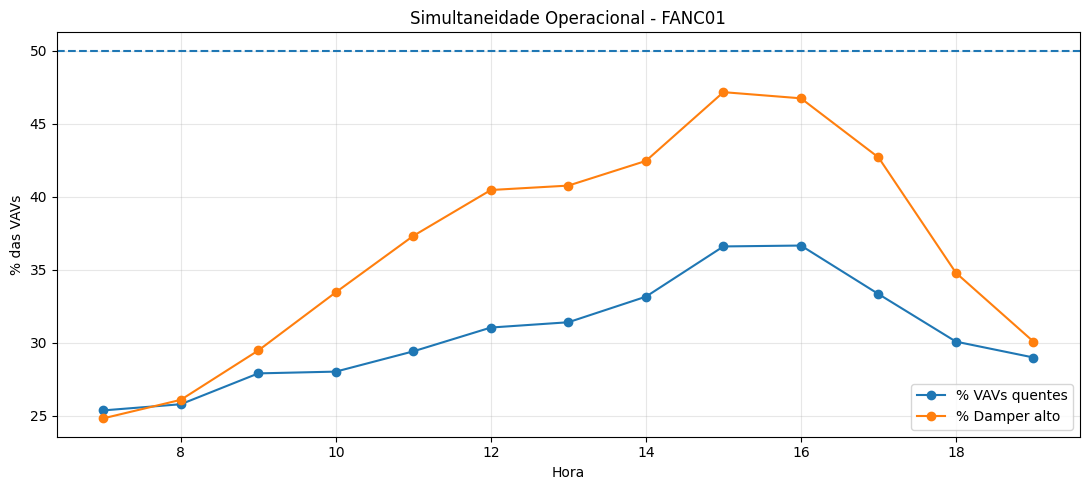

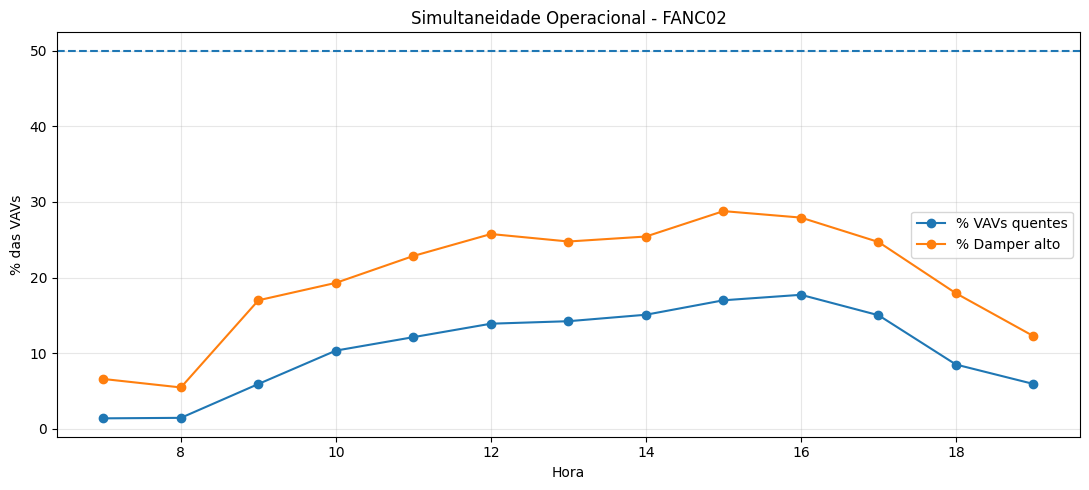

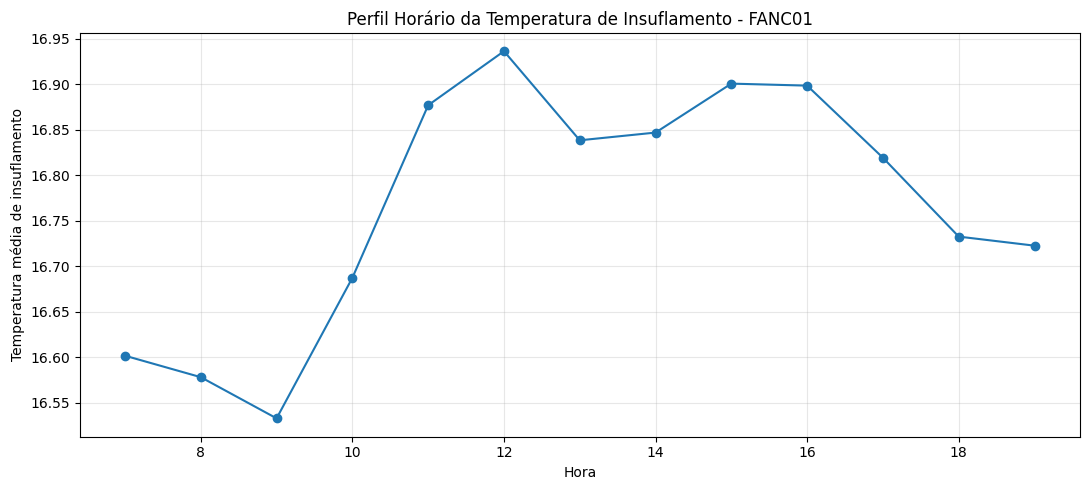

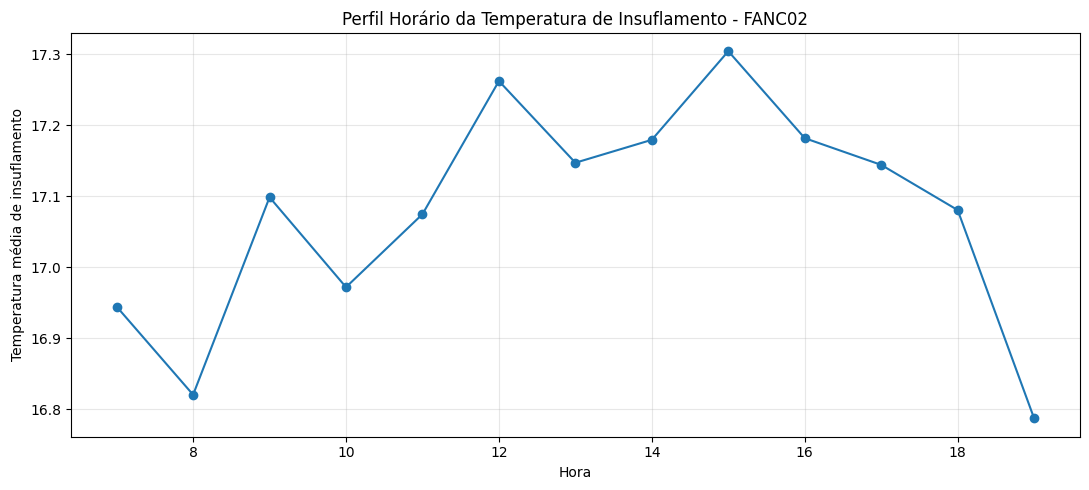


RESUMO SISTÊMICO POR FANCOIL


,FAC,Registros,VAVs_Cadastradas,Pct_Quentes_Medio,Pct_Frias_Medio,Pct_Damper_Alto_Medio,Pct_Damper_Saturado_Medio,Pct_Quente_Damper_Alto_Medio,Pct_Quente_Damper_Alto_Vazao_Baixa_Medio,FAC_DA_TEM_Media,FAC_RL_POS_Media,FAC_RL_FLO_Media,FAC_SF_OUT_Media,Pct_VFD_Alto,Pct_Valvula_Alta,ALTO,ATENÇÃO,CRÍTICO,LOCALIZADO
0,FANC01,1679,12,30.70,37.59,37.09,30.70,24.10,18.46,16.77,14.96,6.81,25.70,0.60,0.60,637,896,46,100
1,FANC02,1679,11,10.99,51.17,20.43,19.82,10.71,10.27,17.10,20.12,9.47,60.20,23.11,0.60,749,581,227,122



DISTRIBUIÇÃO DOS DIAGNÓSTICOS


,FAC,Diagnostico_Sistemico,Registros,Pct
1,FANC01,MULTIVAV QUENTE - INVESTIGAR COMPORTAMENTO DO FAC,601,35.80
4,FANC01,SISTÊMICO FRIO - VAVs REDUZINDO VAZÃO,375,22.33
0,FANC01,MULTIVAV FRIO - INVESTIGAR CONTROLE TÉRMICO,295,17.57
3,FANC01,SISTÊMICO FRIO - POSSÍVEL EXCESSO DE CAPACIDADE,189,11.26
6,FANC01,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,117,6.97
2,FANC01,OCORRÊNCIA QUENTE PREDOMINANTEMENTE LOCALIZADA,100,5.96
5,FANC01,SISTÊMICO QUENTE - INVESTIGAR FANCOIL,2,0.12
12,FANC02,SISTÊMICO FRIO - VAVs REDUZINDO VAZÃO,922,54.91
7,FANC02,MULTIVAV FRIO - INVESTIGAR CONTROLE TÉRMICO,370,22.04
8,FANC02,MULTIVAV QUENTE - INVESTIGAR COMPORTAMENTO DO FAC,211,12.57



EVENTOS SISTÊMICOS PERSISTENTES


...


TOP 50 TIMESTAMPS COM MAIOR SIMULTANEIDADE QUENTE


,DataHora,FAC,VAVs_Cadastradas,Qtd_VAV_Quentes,Pct_VAV_Quentes,Qtd_VAV_Frias,Pct_VAV_Frias,Qtd_Damper_Alto,Pct_Damper_Alto,Qtd_Damper_Saturado,Pct_Damper_Saturado,Qtd_Quente_Damper_Alto,Pct_Quente_Damper_Alto,Qtd_Quente_Damper_Alto_Vazao_Baixa,Pct_Quente_Damper_Alto_Vazao_Baixa,FAC_DA-TEM,FAC_RL-POS,FAC_RL-FLO,FAC_SF-OUT,Diagnostico_Sistemico,Severidade_Sistemica
0,2026-07-09 13:50:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.42,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
1,2026-07-09 14:00:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.47,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
2,2026-07-09 14:10:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.42,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
3,2026-07-09 14:20:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.34,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
4,2026-07-09 14:30:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.30,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
5,2026-07-09 14:40:00,FANC01,12,8,66.67,2,16.67,12,100.00,12,100.00,8,66.67,8,66.67,20.34,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
6,2026-07-09 14:50:00,FANC01,12,8,66.67,1,8.33,12,100.00,12,100.00,8,66.67,8,66.67,20.30,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
7,2026-07-09 15:00:00,FANC01,12,8,66.67,1,8.33,12,100.00,12,100.00,8,66.67,8,66.67,20.22,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
8,2026-07-09 15:10:00,FANC01,12,8,66.67,1,8.33,12,100.00,12,100.00,8,66.67,8,66.67,20.22,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO
9,2026-07-09 15:20:00,FANC01,12,8,66.67,0,0.00,12,100.00,12,100.00,8,66.67,8,66.67,20.19,0.00,0.00,0.00,SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO DE DISTR...,ALTO



EXPORTANDO MÓDULO 7

✅ Arquivo criado: 07_Diagnostico_Sistemico_VAV_FANCOIL.xlsx


RESUMO EXECUTIVO - MÓDULO 7

ESTRUTURA
----------------------------------------------------------------------------------------------------------------------------------
Fancoils analisados.................. 2
Registros sistêmicos................. 3,358

SIMULTANEIDADE
----------------------------------------------------------------------------------------------------------------------------------
Timestamps com >=50% VAVs quentes... 133
Timestamps com >=50% VAVs frias..... 1,526
Eventos sistêmicos persistentes...... 178

OBJETIVO
----------------------------------------------------------------------------------------------------------------------------------
Separar ocorrências predominantemente localizadas de condições coletivas associadas ao FANCOIL.

✅ MÓDULO 7 CONCLUÍDO

PRÓXIMO PASSO SUGERIDO:
Validar os diagnósticos sistêmicos encontrados.
Depois avançar ao MÓDULO 8 - MOTOR DE DIAGNÓSTICO / FDD, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 7 - DIAGNÓSTICO SISTÊMICO VAV x FANCOIL
#
# OBJETIVOS:
#
# 1. Avaliar simultaneidade operacional entre as VAVs atendidas pelo mesmo FAC.
#
# 2. Cruzar o comportamento coletivo das VAVs com:
#
#       FAC_DA-TEM     -> Temperatura de insuflamento
#       FAC_DAT-SP     -> Setpoint da temperatura de insuflamento
#       FAC_RL-POS     -> Posição da válvula de água gelada
#       FAC_RL-FLO     -> Vazão relativa de água gelada
#       FAC_SF-OUT     -> Sinal / velocidade do ventilador
#       FAC_DAP-SP     -> Setpoint de pressão
#
# 3. Criar indicadores de simultaneidade:
#
#       - VAVs quentes
#       - VAVs frias
#       - VAVs com damper alto
#       - VAVs com damper saturado
#       - VAVs com alta utilização de vazão
#       - VAVs com vazão saturada
#       - VAVs com quente + damper alto
#       - VAVs com quente + damper alto + vazão insuficiente
#       - VAVs frias com controle reduzindo
#
# 4. Identificar condições potencialmente:
#
#       - LOCALIZADAS
#       - MULTIVAV
#       - SISTÊMICAS
#
# 5. Avaliar resposta do FANCOIL durante esses eventos.
#
# 6. Gerar diagnóstico temporal, diário, ranking e eventos persistentes.
#
#
# IMPORTANTE:
#
# Este módulo gera HIPÓTESES DIAGNÓSTICAS SISTÊMICAS.
#
# Elas não substituem verificação física em campo.
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 350)
pd.set_option("display.max_rows", 350)
pd.set_option("display.width", 400)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 130)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 7 - DIAGNÓSTICO SISTÊMICO VAV x FANCOIL")
print("=" * 130)


# ==================================================================================================
# 2. PARÂMETROS DO MÓDULO
# ==================================================================================================

INTERVALO_MINUTOS = 10


# --------------------------------------------------------------------------------------------------
# TEMPERATURA
# --------------------------------------------------------------------------------------------------

LIMITE_CONFORTO = 0.50


# --------------------------------------------------------------------------------------------------
# DAMPER
# --------------------------------------------------------------------------------------------------

DAMPER_ALTO = 75.0
DAMPER_SATURADO = 90.0


# --------------------------------------------------------------------------------------------------
# VAZÃO VAV / MAXFLO
# --------------------------------------------------------------------------------------------------

VAZAO_BAIXA = 25.0
VAZAO_ALTA = 75.0
VAZAO_SATURADA = 90.0


# --------------------------------------------------------------------------------------------------
# SIMULTANEIDADE
#
# Percentual das VAVs válidas atendidas pelo FAC.
# --------------------------------------------------------------------------------------------------

LIMITE_SIMULTANEIDADE_ATENCAO = 30.0
LIMITE_SIMULTANEIDADE_SISTEMICA = 50.0
LIMITE_SIMULTANEIDADE_CRITICA = 70.0


# --------------------------------------------------------------------------------------------------
# FANCOIL
#
# Estes valores serão usados como indicadores de esforço,
# não como prova definitiva de saturação.
# --------------------------------------------------------------------------------------------------

FAC_VFD_ALTO = 80.0
FAC_VALVULA_ALTA = 80.0


# --------------------------------------------------------------------------------------------------
# Temperatura de insuflamento
# --------------------------------------------------------------------------------------------------

LIMITE_DESVIO_DAT = 1.0


# --------------------------------------------------------------------------------------------------
# Persistência
# --------------------------------------------------------------------------------------------------

MINUTOS_PERSISTENCIA = 30

REGISTROS_MIN_PERSISTENCIA = int(
    MINUTOS_PERSISTENCIA / INTERVALO_MINUTOS
)


print()
print("PARÂMETROS")
print("-" * 130)

print(
    f"Simultaneidade atenção............ >= "
    f"{LIMITE_SIMULTANEIDADE_ATENCAO:.0f}% das VAVs"
)

print(
    f"Simultaneidade sistêmica.......... >= "
    f"{LIMITE_SIMULTANEIDADE_SISTEMICA:.0f}% das VAVs"
)

print(
    f"Simultaneidade crítica............ >= "
    f"{LIMITE_SIMULTANEIDADE_CRITICA:.0f}% das VAVs"
)

print(
    f"VFD FAC alto...................... >= "
    f"{FAC_VFD_ALTO:.0f}%"
)

print(
    f"Válvula AG alta................... >= "
    f"{FAC_VALVULA_ALTA:.0f}%"
)


# ==================================================================================================
# 3. CARREGAMENTO DA BASE
# ==================================================================================================

try:

    base_mod7 = base_analitica.copy()

    print()
    print("✅ base_analitica encontrada na sessão.")

    print(
        f"Registros carregados: "
        f"{len(base_mod7):,}"
    )


except NameError:

    print()
    print(
        "A variável base_analitica não está disponível."
    )

    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos_excel = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos_excel) == 0:

        raise FileNotFoundError(
            "Nenhum arquivo Excel foi carregado."
        )

    ARQUIVO_BASE = arquivos_excel[0]

    base_mod7 = pd.read_excel(
        ARQUIVO_BASE,
        sheet_name="Base Analitica"
    )

    print()
    print(
        f"✅ Arquivo carregado: {ARQUIVO_BASE}"
    )


# ==================================================================================================
# 4. VALIDAÇÃO DAS COLUNAS
# ==================================================================================================

COLUNAS_OBRIGATORIAS = [

    "DataHora",
    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",
    "ZNT-SP_Origem",

    "DPRPOS",

    "SUPFLO",
    "MAXFLO",

    "FAC_DA-TEM",
    "FAC_RL-FLO",
    "FAC_RL-POS",
    "FAC_SF-OUT"

]


faltantes = [
    coluna
    for coluna in COLUNAS_OBRIGATORIAS
    if coluna not in base_mod7.columns
]


if faltantes:

    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes}"
    )


base_mod7[
    "DataHora"
] = pd.to_datetime(
    base_mod7[
        "DataHora"
    ],
    errors="coerce"
)


# ==================================================================================================
# 5. VARIÁVEIS OPCIONAIS DO FANCOIL
# ==================================================================================================

TEM_DAT_SP = (
    "FAC_DAT-SP"
    in base_mod7.columns
)

TEM_DAP_SP = (
    "FAC_DAP-SP"
    in base_mod7.columns
)


print()
print("=" * 130)
print("PONTOS DO FANCOIL DISPONÍVEIS")
print("=" * 130)

print("FAC_DA-TEM.................... SIM")
print("FAC_RL-FLO.................... SIM")
print("FAC_RL-POS.................... SIM")
print("FAC_SF-OUT.................... SIM")

print(
    f"FAC_DAT-SP.................... "
    f"{'SIM' if TEM_DAT_SP else 'NÃO'}"
)

print(
    f"FAC_DAP-SP.................... "
    f"{'SIM' if TEM_DAP_SP else 'NÃO'}"
)


# ==================================================================================================
# 6. REMOVER EQUIPAMENTOS SEM FAC PARA ANÁLISE SISTÊMICA
# ==================================================================================================

base_sistema = base_mod7[
    base_mod7[
        "FAC"
    ].notna()
].copy()


FACS = sorted(
    base_sistema[
        "FAC"
    ]
    .dropna()
    .unique()
)


print()
print("=" * 130)
print("FANCOILS ANALISADOS")
print("=" * 130)

print(FACS)


# ==================================================================================================
# 7. CÁLCULO TÉRMICO
# ==================================================================================================

base_sistema[
    "Valido_Termico"
] = (

    base_sistema[
        "ZN-TEM"
    ].notna()

    &

    base_sistema[
        "ZNT-SP"
    ].notna()

    &

    (
        base_sistema[
            "ZNT-SP_Origem"
        ]
        !=
        "BACKFILL_INICIAL"
    )

)


base_sistema[
    "DeltaT"
] = np.where(

    base_sistema[
        "Valido_Termico"
    ],

    (
        base_sistema[
            "ZN-TEM"
        ]
        -
        base_sistema[
            "ZNT-SP"
        ]
    ),

    np.nan
)


base_sistema[
    "Flag_Quente"
] = (

    base_sistema[
        "DeltaT"
    ]
    >
    LIMITE_CONFORTO

).fillna(False).astype(int)


base_sistema[
    "Flag_Frio"
] = (

    base_sistema[
        "DeltaT"
    ]
    <
    -LIMITE_CONFORTO

).fillna(False).astype(int)


base_sistema[
    "Flag_Conforto"
] = (

    base_sistema[
        "DeltaT"
    ].abs()
    <=
    LIMITE_CONFORTO

).fillna(False).astype(int)


# ==================================================================================================
# 8. VALIDAÇÃO DO DAMPER
# ==================================================================================================

base_sistema[
    "DPRPOS_Valido"
] = (

    base_sistema[
        "DPRPOS"
    ].notna()

    &

    (
        base_sistema[
            "DPRPOS"
        ]
        >=
        0
    )

    &

    (
        base_sistema[
            "DPRPOS"
        ]
        <=
        100
    )

)


base_sistema[
    "Flag_Damper_Alto"
] = (

    base_sistema[
        "DPRPOS"
    ]
    >=
    DAMPER_ALTO

).fillna(False).astype(int)


base_sistema[
    "Flag_Damper_Saturado"
] = (

    base_sistema[
        "DPRPOS"
    ]
    >=
    DAMPER_SATURADO

).fillna(False).astype(int)


# ==================================================================================================
# 9. UTILIZAÇÃO DE VAZÃO
# ==================================================================================================

base_sistema[
    "Valido_Vazao"
] = (

    base_sistema[
        "SUPFLO"
    ].notna()

    &

    base_sistema[
        "MAXFLO"
    ].notna()

    &

    (
        base_sistema[
            "MAXFLO"
        ]
        >
        0
    )

    &

    (
        base_sistema[
            "SUPFLO"
        ]
        >=
        0
    )

)


base_sistema[
    "Utilizacao_Vazao_Pct"
] = np.where(

    base_sistema[
        "Valido_Vazao"
    ],

    (
        base_sistema[
            "SUPFLO"
        ]
        /
        base_sistema[
            "MAXFLO"
        ]
        *
        100
    ),

    np.nan
)


base_sistema[
    "Flag_Vazao_Alta"
] = (

    base_sistema[
        "Utilizacao_Vazao_Pct"
    ]
    >=
    VAZAO_ALTA

).fillna(False).astype(int)


base_sistema[
    "Flag_Vazao_Saturada"
] = (

    base_sistema[
        "Utilizacao_Vazao_Pct"
    ]
    >=
    VAZAO_SATURADA

).fillna(False).astype(int)


# ==================================================================================================
# 10. ASSINATURAS INDIVIDUAIS IMPORTANTES
# ==================================================================================================

base_sistema[
    "Flag_Quente_Damper_Alto"
] = (

    (
        base_sistema[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_sistema[
            "Flag_Damper_Alto"
        ]
        ==
        1
    )

).astype(int)


base_sistema[
    "Flag_Quente_Damper_Saturado"
] = (

    (
        base_sistema[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_sistema[
            "Flag_Damper_Saturado"
        ]
        ==
        1
    )

).astype(int)


base_sistema[
    "Flag_Quente_Damper_Alto_Vazao_Baixa"
] = (

    (
        base_sistema[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_sistema[
            "DPRPOS"
        ]
        >=
        DAMPER_ALTO
    )

    &

    (
        base_sistema[
            "Utilizacao_Vazao_Pct"
        ]
        <
        VAZAO_ALTA
    )

).astype(int)


base_sistema[
    "Flag_Quente_Capacidade_Limite"
] = (

    (
        base_sistema[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_sistema[
            "DPRPOS"
        ]
        >=
        DAMPER_SATURADO
    )

    &

    (
        base_sistema[
            "Utilizacao_Vazao_Pct"
        ]
        >=
        VAZAO_SATURADA
    )

).astype(int)


base_sistema[
    "Flag_Frio_Controle_Reduzido"
] = (

    (
        base_sistema[
            "Flag_Frio"
        ]
        ==
        1
    )

    &

    (
        base_sistema[
            "DPRPOS"
        ]
        <
        25
    )

    &

    (
        base_sistema[
            "Utilizacao_Vazao_Pct"
        ]
        <
        VAZAO_BAIXA
    )

).astype(int)


# ==================================================================================================
# 11. CONTAGEM DE VAVs POR FANCOIL
# ==================================================================================================

vavs_por_fac = (
    base_sistema[
        [
            "FAC",
            "Equipamento"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "FAC"
    )
    [
        "Equipamento"
    ]
    .nunique()
    .reset_index(
        name="VAVs_Cadastradas"
    )
)


print()
print("=" * 130)
print("VAVs POR FANCOIL")
print("=" * 130)

display(
    vavs_por_fac
)


# ==================================================================================================
# 12. AGREGAÇÃO SISTÊMICA POR TIMESTAMP
# ==================================================================================================

agregacoes = {

    "Equipamento":
        pd.NamedAgg(
            column="Equipamento",
            aggfunc="nunique"
        ),

    "Flag_Quente":
        pd.NamedAgg(
            column="Flag_Quente",
            aggfunc="sum"
        ),

    "Flag_Frio":
        pd.NamedAgg(
            column="Flag_Frio",
            aggfunc="sum"
        ),

    "Flag_Conforto":
        pd.NamedAgg(
            column="Flag_Conforto",
            aggfunc="sum"
        ),

    "Flag_Damper_Alto":
        pd.NamedAgg(
            column="Flag_Damper_Alto",
            aggfunc="sum"
        ),

    "Flag_Damper_Saturado":
        pd.NamedAgg(
            column="Flag_Damper_Saturado",
            aggfunc="sum"
        ),

    "Flag_Vazao_Alta":
        pd.NamedAgg(
            column="Flag_Vazao_Alta",
            aggfunc="sum"
        ),

    "Flag_Vazao_Saturada":
        pd.NamedAgg(
            column="Flag_Vazao_Saturada",
            aggfunc="sum"
        ),

    "Flag_Quente_Damper_Alto":
        pd.NamedAgg(
            column="Flag_Quente_Damper_Alto",
            aggfunc="sum"
        ),

    "Flag_Quente_Damper_Saturado":
        pd.NamedAgg(
            column="Flag_Quente_Damper_Saturado",
            aggfunc="sum"
        ),

    "Flag_Quente_Damper_Alto_Vazao_Baixa":
        pd.NamedAgg(
            column="Flag_Quente_Damper_Alto_Vazao_Baixa",
            aggfunc="sum"
        ),

    "Flag_Quente_Capacidade_Limite":
        pd.NamedAgg(
            column="Flag_Quente_Capacidade_Limite",
            aggfunc="sum"
        ),

    "Flag_Frio_Controle_Reduzido":
        pd.NamedAgg(
            column="Flag_Frio_Controle_Reduzido",
            aggfunc="sum"
        ),

    "DeltaT":
        pd.NamedAgg(
            column="DeltaT",
            aggfunc="mean"
        ),

    "DPRPOS":
        pd.NamedAgg(
            column="DPRPOS",
            aggfunc="mean"
        ),

    "Utilizacao_Vazao_Pct":
        pd.NamedAgg(
            column="Utilizacao_Vazao_Pct",
            aggfunc="mean"
        ),

    "FAC_DA-TEM":
        pd.NamedAgg(
            column="FAC_DA-TEM",
            aggfunc="first"
        ),

    "FAC_RL-FLO":
        pd.NamedAgg(
            column="FAC_RL-FLO",
            aggfunc="first"
        ),

    "FAC_RL-POS":
        pd.NamedAgg(
            column="FAC_RL-POS",
            aggfunc="first"
        ),

    "FAC_SF-OUT":
        pd.NamedAgg(
            column="FAC_SF-OUT",
            aggfunc="first"
        )

}


if TEM_DAT_SP:

    agregacoes[
        "FAC_DAT-SP"
    ] = pd.NamedAgg(
        column="FAC_DAT-SP",
        aggfunc="first"
    )


if TEM_DAP_SP:

    agregacoes[
        "FAC_DAP-SP"
    ] = pd.NamedAgg(
        column="FAC_DAP-SP",
        aggfunc="first"
    )


sistema_timestamp = (
    base_sistema
    .groupby(
        [
            "DataHora",
            "FAC"
        ],
        observed=True
    )
    .agg(
        **agregacoes
    )
    .reset_index()
)


# --------------------------------------------------------------------------------------------------
# Renomear
# --------------------------------------------------------------------------------------------------

sistema_timestamp = sistema_timestamp.rename(
    columns={

        "Equipamento":
            "VAVs_Com_Registro",

        "Flag_Quente":
            "Qtd_VAV_Quentes",

        "Flag_Frio":
            "Qtd_VAV_Frias",

        "Flag_Conforto":
            "Qtd_VAV_Conforto",

        "Flag_Damper_Alto":
            "Qtd_Damper_Alto",

        "Flag_Damper_Saturado":
            "Qtd_Damper_Saturado",

        "Flag_Vazao_Alta":
            "Qtd_Vazao_Alta",

        "Flag_Vazao_Saturada":
            "Qtd_Vazao_Saturada",

        "Flag_Quente_Damper_Alto":
            "Qtd_Quente_Damper_Alto",

        "Flag_Quente_Damper_Saturado":
            "Qtd_Quente_Damper_Saturado",

        "Flag_Quente_Damper_Alto_Vazao_Baixa":
            "Qtd_Quente_Damper_Alto_Vazao_Baixa",

        "Flag_Quente_Capacidade_Limite":
            "Qtd_Quente_Capacidade_Limite",

        "Flag_Frio_Controle_Reduzido":
            "Qtd_Frio_Controle_Reduzido",

        "DeltaT":
            "DeltaT_Medio_VAVs",

        "DPRPOS":
            "DPRPOS_Medio_VAVs",

        "Utilizacao_Vazao_Pct":
            "Vazao_Media_VAVs_Pct"

    }
)


# ==================================================================================================
# 13. ADICIONAR QUANTIDADE CADASTRADA
# ==================================================================================================

sistema_timestamp = sistema_timestamp.merge(
    vavs_por_fac,
    on="FAC",
    how="left"
)


# ==================================================================================================
# 14. PERCENTUAIS DE SIMULTANEIDADE
# ==================================================================================================

variaveis_simultaneidade = [

    (
        "Qtd_VAV_Quentes",
        "Pct_VAV_Quentes"
    ),

    (
        "Qtd_VAV_Frias",
        "Pct_VAV_Frias"
    ),

    (
        "Qtd_Damper_Alto",
        "Pct_Damper_Alto"
    ),

    (
        "Qtd_Damper_Saturado",
        "Pct_Damper_Saturado"
    ),

    (
        "Qtd_Vazao_Alta",
        "Pct_Vazao_Alta"
    ),

    (
        "Qtd_Vazao_Saturada",
        "Pct_Vazao_Saturada"
    ),

    (
        "Qtd_Quente_Damper_Alto",
        "Pct_Quente_Damper_Alto"
    ),

    (
        "Qtd_Quente_Damper_Saturado",
        "Pct_Quente_Damper_Saturado"
    ),

    (
        "Qtd_Quente_Damper_Alto_Vazao_Baixa",
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ),

    (
        "Qtd_Quente_Capacidade_Limite",
        "Pct_Quente_Capacidade_Limite"
    ),

    (
        "Qtd_Frio_Controle_Reduzido",
        "Pct_Frio_Controle_Reduzido"
    )

]


for origem, destino in variaveis_simultaneidade:

    sistema_timestamp[
        destino
    ] = (

        sistema_timestamp[
            origem
        ]

        /

        sistema_timestamp[
            "VAVs_Cadastradas"
        ]

        *

        100

    )


# ==================================================================================================
# 15. DELTA DA TEMPERATURA DE INSUFLAMENTO DO FANCOIL
# ==================================================================================================

if TEM_DAT_SP:

    sistema_timestamp[
        "FAC_DeltaT_Insuf"
    ] = (

        sistema_timestamp[
            "FAC_DA-TEM"
        ]

        -

        sistema_timestamp[
            "FAC_DAT-SP"
        ]

    )

else:

    sistema_timestamp[
        "FAC_DeltaT_Insuf"
    ] = np.nan


# ==================================================================================================
# 16. FLAGS DE ESFORÇO DO FANCOIL
# ==================================================================================================

sistema_timestamp[
    "FAC_Flag_VFD_Alto"
] = (

    sistema_timestamp[
        "FAC_SF-OUT"
    ]
    >=
    FAC_VFD_ALTO

).fillna(False).astype(int)


sistema_timestamp[
    "FAC_Flag_Valvula_Alta"
] = (

    sistema_timestamp[
        "FAC_RL-POS"
    ]
    >=
    FAC_VALVULA_ALTA

).fillna(False).astype(int)


if TEM_DAT_SP:

    sistema_timestamp[
        "FAC_Flag_Temp_Insuf_Acima_SP"
    ] = (

        sistema_timestamp[
            "FAC_DeltaT_Insuf"
        ]
        >
        LIMITE_DESVIO_DAT

    ).fillna(False).astype(int)

else:

    sistema_timestamp[
        "FAC_Flag_Temp_Insuf_Acima_SP"
    ] = 0


# ==================================================================================================
# 17. CLASSIFICAÇÃO DA SIMULTANEIDADE
# ==================================================================================================

def classificar_simultaneidade(valor):

    if pd.isna(valor):

        return "SEM DADOS"

    if valor >= LIMITE_SIMULTANEIDADE_CRITICA:

        return "CRÍTICA"

    elif valor >= LIMITE_SIMULTANEIDADE_SISTEMICA:

        return "SISTÊMICA"

    elif valor >= LIMITE_SIMULTANEIDADE_ATENCAO:

        return "MULTIVAV"

    elif valor > 0:

        return "LOCALIZADA"

    else:

        return "SEM OCORRÊNCIA"


sistema_timestamp[
    "Nivel_Simultaneidade_Quente"
] = (
    sistema_timestamp[
        "Pct_VAV_Quentes"
    ]
    .apply(
        classificar_simultaneidade
    )
)


sistema_timestamp[
    "Nivel_Simultaneidade_Fria"
] = (
    sistema_timestamp[
        "Pct_VAV_Frias"
    ]
    .apply(
        classificar_simultaneidade
    )
)


# ==================================================================================================
# 18. DIAGNÓSTICO SISTÊMICO
# ==================================================================================================

def diagnostico_sistemico(row):

    quente = row[
        "Pct_VAV_Quentes"
    ]

    frio = row[
        "Pct_VAV_Frias"
    ]

    quente_damper = row[
        "Pct_Quente_Damper_Alto"
    ]

    quente_vazao_baixa = row[
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ]

    quente_limite = row[
        "Pct_Quente_Capacidade_Limite"
    ]

    frias_reduzindo = row[
        "Pct_Frio_Controle_Reduzido"
    ]

    vfd_alto = row[
        "FAC_Flag_VFD_Alto"
    ]

    valvula_alta = row[
        "FAC_Flag_Valvula_Alta"
    ]

    insuf_acima = row[
        "FAC_Flag_Temp_Insuf_Acima_SP"
    ]


    # ==============================================================================================
    # SISTEMA QUENTE
    # ==============================================================================================

    if quente >= LIMITE_SIMULTANEIDADE_SISTEMICA:

        # ------------------------------------------------------------------------------------------
        # Muitas VAVs quentes + fancoil em alto esforço
        # ------------------------------------------------------------------------------------------

        if (
            vfd_alto == 1
            and
            valvula_alta == 1
        ):

            if insuf_acima == 1:

                return (
                    "SISTÊMICO QUENTE - FAC EM ALTO ESFORÇO "
                    "/ INSUFLAMENTO ACIMA DO SP"
                )

            return (
                "SISTÊMICO QUENTE - FAC EM ALTO ESFORÇO"
            )


        # ------------------------------------------------------------------------------------------
        # Muitas VAVs quentes e damper alto mas sem vazão correspondente
        # ------------------------------------------------------------------------------------------

        if (
            quente_vazao_baixa
            >=
            LIMITE_SIMULTANEIDADE_ATENCAO
        ):

            return (
                "SISTÊMICO QUENTE - POSSÍVEL LIMITAÇÃO "
                "DE DISTRIBUIÇÃO DE AR"
            )


        if (
            quente_damper
            >=
            LIMITE_SIMULTANEIDADE_SISTEMICA
        ):

            return (
                "SISTÊMICO QUENTE - DEMANDA COLETIVA ELEVADA"
            )


        return (
            "SISTÊMICO QUENTE - INVESTIGAR FANCOIL"
        )


    # ==============================================================================================
    # MUITAS VAVs EM CAPACIDADE PRÓXIMA DO LIMITE
    # ==============================================================================================

    if (
        quente_limite
        >=
        LIMITE_SIMULTANEIDADE_ATENCAO
    ):

        return (
            "MULTIVAV - CAPACIDADE DE VAZÃO PRÓXIMA DO LIMITE"
        )


    # ==============================================================================================
    # SISTEMA FRIO
    # ==============================================================================================

    if frio >= LIMITE_SIMULTANEIDADE_SISTEMICA:

        if (
            frias_reduzindo
            >=
            LIMITE_SIMULTANEIDADE_ATENCAO
        ):

            return (
                "SISTÊMICO FRIO - VAVs REDUZINDO VAZÃO"
            )

        return (
            "SISTÊMICO FRIO - POSSÍVEL EXCESSO DE CAPACIDADE"
        )


    # ==============================================================================================
    # MULTIVAV QUENTE
    # ==============================================================================================

    if (
        quente
        >=
        LIMITE_SIMULTANEIDADE_ATENCAO
    ):

        return (
            "MULTIVAV QUENTE - INVESTIGAR COMPORTAMENTO DO FAC"
        )


    # ==============================================================================================
    # MULTIVAV FRIO
    # ==============================================================================================

    if (
        frio
        >=
        LIMITE_SIMULTANEIDADE_ATENCAO
    ):

        return (
            "MULTIVAV FRIO - INVESTIGAR CONTROLE TÉRMICO"
        )


    # ==============================================================================================
    # LOCALIZADO
    # ==============================================================================================

    if quente > 0:

        return (
            "OCORRÊNCIA QUENTE PREDOMINANTEMENTE LOCALIZADA"
        )


    if frio > 0:

        return (
            "OCORRÊNCIA FRIA PREDOMINANTEMENTE LOCALIZADA"
        )


    return "OPERAÇÃO SEM DESVIO COLETIVO RELEVANTE"


sistema_timestamp[
    "Diagnostico_Sistemico"
] = sistema_timestamp.apply(
    diagnostico_sistemico,
    axis=1
)


# ==================================================================================================
# 19. NÍVEL DE SEVERIDADE SISTÊMICA
# ==================================================================================================

def classificar_severidade_sistema(row):

    max_simult = max(
        row[
            "Pct_VAV_Quentes"
        ],
        row[
            "Pct_VAV_Frias"
        ]
    )


    if max_simult >= LIMITE_SIMULTANEIDADE_CRITICA:

        return "CRÍTICO"


    elif max_simult >= LIMITE_SIMULTANEIDADE_SISTEMICA:

        return "ALTO"


    elif max_simult >= LIMITE_SIMULTANEIDADE_ATENCAO:

        return "ATENÇÃO"


    elif max_simult > 0:

        return "LOCALIZADO"


    return "NORMAL"


sistema_timestamp[
    "Severidade_Sistemica"
] = sistema_timestamp.apply(
    classificar_severidade_sistema,
    axis=1
)


# ==================================================================================================
# 20. DISTRIBUIÇÃO DOS DIAGNÓSTICOS
# ==================================================================================================

distribuicao_diagnosticos = (
    sistema_timestamp
    .groupby(
        [
            "FAC",
            "Diagnostico_Sistemico"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


totais_fac = (
    distribuicao_diagnosticos
    .groupby(
        "FAC"
    )[
        "Registros"
    ]
    .transform(
        "sum"
    )
)


distribuicao_diagnosticos[
    "Pct"
] = (

    distribuicao_diagnosticos[
        "Registros"
    ]

    /

    totais_fac

    *

    100

)


# ==================================================================================================
# 21. RESUMO POR FANCOIL
# ==================================================================================================

resumo_fac = (
    sistema_timestamp
    .groupby(
        "FAC",
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        VAVs_Cadastradas=(
            "VAVs_Cadastradas",
            "first"
        ),

        Pct_Quentes_Medio=(
            "Pct_VAV_Quentes",
            "mean"
        ),

        Pct_Frias_Medio=(
            "Pct_VAV_Frias",
            "mean"
        ),

        Pct_Damper_Alto_Medio=(
            "Pct_Damper_Alto",
            "mean"
        ),

        Pct_Damper_Saturado_Medio=(
            "Pct_Damper_Saturado",
            "mean"
        ),

        Pct_Quente_Damper_Alto_Medio=(
            "Pct_Quente_Damper_Alto",
            "mean"
        ),

        Pct_Quente_Damper_Alto_Vazao_Baixa_Medio=(
            "Pct_Quente_Damper_Alto_Vazao_Baixa",
            "mean"
        ),

        FAC_DA_TEM_Media=(
            "FAC_DA-TEM",
            "mean"
        ),

        FAC_RL_POS_Media=(
            "FAC_RL-POS",
            "mean"
        ),

        FAC_RL_FLO_Media=(
            "FAC_RL-FLO",
            "mean"
        ),

        FAC_SF_OUT_Media=(
            "FAC_SF-OUT",
            "mean"
        ),

        Pct_VFD_Alto=(
            "FAC_Flag_VFD_Alto",
            "mean"
        ),

        Pct_Valvula_Alta=(
            "FAC_Flag_Valvula_Alta",
            "mean"
        )

    )
    .reset_index()
)


resumo_fac[
    "Pct_VFD_Alto"
] = (
    resumo_fac[
        "Pct_VFD_Alto"
    ]
    *
    100
)


resumo_fac[
    "Pct_Valvula_Alta"
] = (
    resumo_fac[
        "Pct_Valvula_Alta"
    ]
    *
    100
)


# ==================================================================================================
# 22. CONTAGEM DE SEVERIDADES
# ==================================================================================================

severidades_fac = (
    sistema_timestamp
    .pivot_table(

        index="FAC",

        columns="Severidade_Sistemica",

        values="DataHora",

        aggfunc="count",

        fill_value=0

    )
    .reset_index()
)


severidades_fac.columns.name = None


resumo_fac = resumo_fac.merge(
    severidades_fac,
    on="FAC",
    how="left"
)


# ==================================================================================================
# 23. EVENTOS SISTÊMICOS PERSISTENTES
# ==================================================================================================

def detectar_eventos_sistemicos(df):

    eventos = []


    for fac in (
        df[
            "FAC"
        ]
        .dropna()
        .unique()
    ):

        temp = (
            df[
                df[
                    "FAC"
                ]
                ==
                fac
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_sequencia = (

            (
                temp[
                    "Diagnostico_Sistemico"
                ]
                !=
                temp[
                    "Diagnostico_Sistemico"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo"
        ] = (
            nova_sequencia
            .cumsum()
        )


        for _, grupo in temp.groupby(
            "_Grupo"
        ):

            diagnostico = grupo[
                "Diagnostico_Sistemico"
            ].iloc[0]


            if diagnostico in [

                "OPERAÇÃO SEM DESVIO COLETIVO RELEVANTE",

                "OCORRÊNCIA QUENTE PREDOMINANTEMENTE LOCALIZADA",

                "OCORRÊNCIA FRIA PREDOMINANTEMENTE LOCALIZADA"

            ]:

                continue


            if len(grupo) < REGISTROS_MIN_PERSISTENCIA:

                continue


            inicio = grupo[
                "DataHora"
            ].min()


            fim = grupo[
                "DataHora"
            ].max()


            duracao = (

                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60

            )


            eventos.append({

                "FAC":
                    fac,

                "Diagnostico":
                    diagnostico,

                "Severidade":
                    grupo[
                        "Severidade_Sistemica"
                    ].mode().iloc[0],

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Registros":
                    len(grupo),

                "Duracao_Cronologica_Min":
                    duracao,

                "Pct_Quentes_Medio":
                    grupo[
                        "Pct_VAV_Quentes"
                    ].mean(),

                "Pct_Frias_Medio":
                    grupo[
                        "Pct_VAV_Frias"
                    ].mean(),

                "Pct_Damper_Alto_Medio":
                    grupo[
                        "Pct_Damper_Alto"
                    ].mean(),

                "Pct_Quente_Damper_Alto_Vazao_Baixa":
                    grupo[
                        "Pct_Quente_Damper_Alto_Vazao_Baixa"
                    ].mean(),

                "FAC_DA_TEM_Media":
                    grupo[
                        "FAC_DA-TEM"
                    ].mean(),

                "FAC_RL_POS_Media":
                    grupo[
                        "FAC_RL-POS"
                    ].mean(),

                "FAC_SF_OUT_Media":
                    grupo[
                        "FAC_SF-OUT"
                    ].mean()

            })


    return pd.DataFrame(
        eventos
    )


eventos_sistemicos = detectar_eventos_sistemicos(
    sistema_timestamp
)


# ==================================================================================================
# 24. INDICADORES DIÁRIOS
# ==================================================================================================

sistema_timestamp[
    "Data"
] = (
    sistema_timestamp[
        "DataHora"
    ]
    .dt.date
)


indicadores_diarios = (
    sistema_timestamp
    .groupby(
        [
            "Data",
            "FAC"
        ],
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Pct_Quentes_Medio=(
            "Pct_VAV_Quentes",
            "mean"
        ),

        Pct_Frias_Medio=(
            "Pct_VAV_Frias",
            "mean"
        ),

        Pct_Damper_Alto_Medio=(
            "Pct_Damper_Alto",
            "mean"
        ),

        Pct_Quente_Damper_Alto_Medio=(
            "Pct_Quente_Damper_Alto",
            "mean"
        ),

        FAC_DA_TEM_Media=(
            "FAC_DA-TEM",
            "mean"
        ),

        FAC_RL_POS_Media=(
            "FAC_RL-POS",
            "mean"
        ),

        FAC_SF_OUT_Media=(
            "FAC_SF-OUT",
            "mean"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 25. PERFIL HORÁRIO
# ==================================================================================================

sistema_timestamp[
    "Hora"
] = (
    sistema_timestamp[
        "DataHora"
    ]
    .dt.hour
)


perfil_horario = (
    sistema_timestamp
    .groupby(
        [
            "FAC",
            "Hora"
        ],
        observed=True
    )
    .agg(

        Registros=(
            "DataHora",
            "size"
        ),

        Pct_Quentes_Medio=(
            "Pct_VAV_Quentes",
            "mean"
        ),

        Pct_Frias_Medio=(
            "Pct_VAV_Frias",
            "mean"
        ),

        Pct_Damper_Alto_Medio=(
            "Pct_Damper_Alto",
            "mean"
        ),

        FAC_DA_TEM_Media=(
            "FAC_DA-TEM",
            "mean"
        ),

        FAC_RL_POS_Media=(
            "FAC_RL-POS",
            "mean"
        ),

        FAC_SF_OUT_Media=(
            "FAC_SF-OUT",
            "mean"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 26. RANKING DE TIMESTAMPS CRÍTICOS
# ==================================================================================================

ranking_timestamps = (
    sistema_timestamp
    .sort_values(

        [
            "Pct_VAV_Quentes",
            "Pct_Quente_Damper_Alto",
            "Pct_Damper_Saturado"
        ],

        ascending=[
            False,
            False,
            False
        ]

    )
    .reset_index(
        drop=True
    )
)


# ==================================================================================================
# 27. GRÁFICO - SIMULTANEIDADE QUENTE POR FANCOIL
# ==================================================================================================

for fac in FACS:

    temp = perfil_horario[
        perfil_horario[
            "FAC"
        ]
        ==
        fac
    ]


    if len(temp) == 0:

        continue


    plt.figure(
        figsize=(11, 5)
    )


    plt.plot(
        temp[
            "Hora"
        ],
        temp[
            "Pct_Quentes_Medio"
        ],
        marker="o",
        label="% VAVs quentes"
    )


    plt.plot(
        temp[
            "Hora"
        ],
        temp[
            "Pct_Damper_Alto_Medio"
        ],
        marker="o",
        label="% Damper alto"
    )


    plt.axhline(
        LIMITE_SIMULTANEIDADE_SISTEMICA,
        linestyle="--"
    )


    plt.xlabel(
        "Hora"
    )

    plt.ylabel(
        "% das VAVs"
    )

    plt.title(
        f"Simultaneidade Operacional - {fac}"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 28. GRÁFICO - TEMPERATURA DE INSUFLAMENTO E VÁLVULA
# ==================================================================================================

for fac in FACS:

    temp = perfil_horario[
        perfil_horario[
            "FAC"
        ]
        ==
        fac
    ]


    if len(temp) == 0:

        continue


    plt.figure(
        figsize=(11, 5)
    )


    plt.plot(
        temp[
            "Hora"
        ],
        temp[
            "FAC_DA_TEM_Media"
        ],
        marker="o"
    )


    plt.xlabel(
        "Hora"
    )

    plt.ylabel(
        "Temperatura média de insuflamento"
    )

    plt.title(
        f"Perfil Horário da Temperatura de Insuflamento - {fac}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 29. RELATÓRIOS NA TELA
# ==================================================================================================

print()
print("=" * 130)
print("RESUMO SISTÊMICO POR FANCOIL")
print("=" * 130)

display(
    resumo_fac
)


print()
print("=" * 130)
print("DISTRIBUIÇÃO DOS DIAGNÓSTICOS")
print("=" * 130)

display(
    distribuicao_diagnosticos
    .sort_values(
        [
            "FAC",
            "Pct"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print()
print("=" * 130)
print("EVENTOS SISTÊMICOS PERSISTENTES")
print("=" * 130)

if len(
    eventos_sistemicos
) > 0:

    display(
        eventos_sistemicos
        .sort_values(
            "Duracao_Cronologica_Min",
            ascending=False
        )
        .head(100)
    )

else:

    print(
        "Nenhum evento sistêmico persistente encontrado."
    )


print()
print("=" * 130)
print("TOP 50 TIMESTAMPS COM MAIOR SIMULTANEIDADE QUENTE")
print("=" * 130)

display(
    ranking_timestamps[
        [
            "DataHora",
            "FAC",

            "VAVs_Cadastradas",

            "Qtd_VAV_Quentes",
            "Pct_VAV_Quentes",

            "Qtd_VAV_Frias",
            "Pct_VAV_Frias",

            "Qtd_Damper_Alto",
            "Pct_Damper_Alto",

            "Qtd_Damper_Saturado",
            "Pct_Damper_Saturado",

            "Qtd_Quente_Damper_Alto",
            "Pct_Quente_Damper_Alto",

            "Qtd_Quente_Damper_Alto_Vazao_Baixa",
            "Pct_Quente_Damper_Alto_Vazao_Baixa",

            "FAC_DA-TEM",
            "FAC_RL-POS",
            "FAC_RL-FLO",
            "FAC_SF-OUT",

            "Diagnostico_Sistemico",
            "Severidade_Sistemica"

        ]
    ]
    .head(50)
)


# ==================================================================================================
# 30. BASE SISTÊMICA DETALHADA
# ==================================================================================================

colunas_sistema = [

    "DataHora",
    "FAC",

    "VAVs_Cadastradas",
    "VAVs_Com_Registro",

    "Qtd_VAV_Quentes",
    "Pct_VAV_Quentes",

    "Qtd_VAV_Frias",
    "Pct_VAV_Frias",

    "Qtd_VAV_Conforto",

    "Qtd_Damper_Alto",
    "Pct_Damper_Alto",

    "Qtd_Damper_Saturado",
    "Pct_Damper_Saturado",

    "Qtd_Vazao_Alta",
    "Pct_Vazao_Alta",

    "Qtd_Vazao_Saturada",
    "Pct_Vazao_Saturada",

    "Qtd_Quente_Damper_Alto",
    "Pct_Quente_Damper_Alto",

    "Qtd_Quente_Damper_Saturado",
    "Pct_Quente_Damper_Saturado",

    "Qtd_Quente_Damper_Alto_Vazao_Baixa",
    "Pct_Quente_Damper_Alto_Vazao_Baixa",

    "Qtd_Quente_Capacidade_Limite",
    "Pct_Quente_Capacidade_Limite",

    "Qtd_Frio_Controle_Reduzido",
    "Pct_Frio_Controle_Reduzido",

    "DeltaT_Medio_VAVs",
    "DPRPOS_Medio_VAVs",
    "Vazao_Media_VAVs_Pct",

    "FAC_DA-TEM",
    "FAC_DAT-SP",
    "FAC_DeltaT_Insuf",

    "FAC_RL-POS",
    "FAC_RL-FLO",

    "FAC_SF-OUT",

    "FAC_DAP-SP",

    "FAC_Flag_VFD_Alto",
    "FAC_Flag_Valvula_Alta",
    "FAC_Flag_Temp_Insuf_Acima_SP",

    "Nivel_Simultaneidade_Quente",
    "Nivel_Simultaneidade_Fria",

    "Diagnostico_Sistemico",
    "Severidade_Sistemica"

]


colunas_sistema = [
    coluna
    for coluna in colunas_sistema
    if coluna in sistema_timestamp.columns
]


base_sistemica_detalhada = (
    sistema_timestamp[
        colunas_sistema
    ]
    .copy()
)


# ==================================================================================================
# 31. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "07_Diagnostico_Sistemico_VAV_FANCOIL.xlsx"
)


print()
print("=" * 130)
print("EXPORTANDO MÓDULO 7")
print("=" * 130)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    resumo_fac.to_excel(
        writer,
        sheet_name="Resumo FANCOIL",
        index=False
    )


    distribuicao_diagnosticos.to_excel(
        writer,
        sheet_name="Diagnosticos",
        index=False
    )


    eventos_sistemicos.to_excel(
        writer,
        sheet_name="Eventos Sistemicos",
        index=False
    )


    indicadores_diarios.to_excel(
        writer,
        sheet_name="Indicadores Diarios",
        index=False
    )


    perfil_horario.to_excel(
        writer,
        sheet_name="Perfil Horario",
        index=False
    )


    ranking_timestamps.to_excel(
        writer,
        sheet_name="Ranking Timestamps",
        index=False
    )


    vavs_por_fac.to_excel(
        writer,
        sheet_name="VAVs por FANCOIL",
        index=False
    )


    base_sistemica_detalhada.to_excel(
        writer,
        sheet_name="Base Sistemica",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 32. RESUMO EXECUTIVO
# ==================================================================================================

total_registros = len(
    sistema_timestamp
)


sistemicos_quentes = (
    sistema_timestamp[
        "Pct_VAV_Quentes"
    ]
    >=
    LIMITE_SIMULTANEIDADE_SISTEMICA
).sum()


sistemicos_frios = (
    sistema_timestamp[
        "Pct_VAV_Frias"
    ]
    >=
    LIMITE_SIMULTANEIDADE_SISTEMICA
).sum()


eventos_persistentes_total = len(
    eventos_sistemicos
)


print()
print()
print("=" * 130)
print("RESUMO EXECUTIVO - MÓDULO 7")
print("=" * 130)


print()
print("ESTRUTURA")
print("-" * 130)

print(
    f"Fancoils analisados.................. "
    f"{len(FACS)}"
)

print(
    f"Registros sistêmicos................. "
    f"{total_registros:,}"
)


print()
print("SIMULTANEIDADE")
print("-" * 130)

print(
    f"Timestamps com >=50% VAVs quentes... "
    f"{sistemicos_quentes:,}"
)

print(
    f"Timestamps com >=50% VAVs frias..... "
    f"{sistemicos_frios:,}"
)

print(
    f"Eventos sistêmicos persistentes...... "
    f"{eventos_persistentes_total:,}"
)


print()
print("OBJETIVO")
print("-" * 130)

print(
    "Separar ocorrências predominantemente localizadas "
    "de condições coletivas associadas ao FANCOIL."
)


print()
print("=" * 130)
print("✅ MÓDULO 7 CONCLUÍDO")
print("=" * 130)

print()
print(
    "PRÓXIMO PASSO SUGERIDO:"
)

print(
    "Validar os diagnósticos sistêmicos encontrados."
)

print(
    "Depois avançar ao MÓDULO 8 - MOTOR DE DIAGNÓSTICO / FDD, "
    "consolidando as regras dos Módulos 4, 5, 6 e 7."
)


# ==================================================================================================
# 33. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

In [10]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 7.1 - REFINAMENTO DO DIAGNÓSTICO SISTÊMICO
#
# CORREÇÕES PRINCIPAIS:
#
# 1. Simultaneidade calculada somente sobre VAVs VÁLIDAS no timestamp.
# 2. DPRPOS fora de 0-100% não participa dos indicadores de damper.
# 3. Estado operacional do FANCOIL passa a ter prioridade diagnóstica.
# 4. FANCOIL parado/sem insuflamento não será confundido com
#    limitação da rede de distribuição.
# 5. Mantém rastreabilidade entre:
#       - VAVs cadastradas
#       - VAVs com dados
#       - VAVs válidas para análise
# 6. Gera nova base sistêmica preparada para o Módulo 8 / FDD.
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 350)
pd.set_option("display.max_rows", 350)
pd.set_option("display.width", 400)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 130)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 7.1 - REFINAMENTO DO DIAGNÓSTICO SISTÊMICO")
print("=" * 130)


# ==================================================================================================
# 2. PARÂMETROS
# ==================================================================================================

INTERVALO_MINUTOS = 10

LIMITE_CONFORTO = 0.50

DAMPER_ALTO = 75.0
DAMPER_SATURADO = 90.0

VAZAO_BAIXA = 25.0
VAZAO_ALTA = 75.0
VAZAO_SATURADA = 90.0


# --------------------------------------------------------------------------------------------------
# SIMULTANEIDADE
# --------------------------------------------------------------------------------------------------

SIMULT_ATENCAO = 30.0
SIMULT_SISTEMICA = 50.0
SIMULT_CRITICA = 70.0


# --------------------------------------------------------------------------------------------------
# FANCOIL
#
# SF-OUT:
# Será utilizado principalmente como indicação operacional.
#
# Como ainda não queremos assumir que a escala é necessariamente
# idêntica em todos os futuros prédios, os limites são parametrizados.
# --------------------------------------------------------------------------------------------------

FAC_SF_OFF = 1.0

FAC_SF_BAIXO = 20.0

FAC_SF_ALTO = 80.0


# --------------------------------------------------------------------------------------------------
# Válvula de água gelada
# --------------------------------------------------------------------------------------------------

FAC_VALVULA_ALTA = 80.0


# --------------------------------------------------------------------------------------------------
# Persistência
# --------------------------------------------------------------------------------------------------

MINUTOS_PERSISTENCIA = 30

REGISTROS_MIN_PERSISTENCIA = int(
    MINUTOS_PERSISTENCIA
    /
    INTERVALO_MINUTOS
)


# ==================================================================================================
# 3. CARREGAMENTO DA BASE
# ==================================================================================================

try:

    base_71 = base_analitica.copy()

    print()
    print("✅ base_analitica encontrada na sessão.")

except NameError:

    print()
    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos) == 0:

        raise FileNotFoundError(
            "Nenhum Excel carregado."
        )

    base_71 = pd.read_excel(
        arquivos[0],
        sheet_name="Base Analitica"
    )


base_71["DataHora"] = pd.to_datetime(
    base_71["DataHora"],
    errors="coerce"
)


# ==================================================================================================
# 4. VALIDAÇÃO
# ==================================================================================================

colunas_obrigatorias = [

    "DataHora",
    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",
    "ZNT-SP_Origem",

    "DPRPOS",

    "SUPFLO",
    "MAXFLO",

    "FAC_DA-TEM",
    "FAC_RL-FLO",
    "FAC_RL-POS",
    "FAC_SF-OUT"

]


faltantes = [
    c
    for c in colunas_obrigatorias
    if c not in base_71.columns
]


if faltantes:

    raise ValueError(
        f"Colunas ausentes: {faltantes}"
    )


# ==================================================================================================
# 5. MANTER SOMENTE VAVs ASSOCIADAS A FAC
# ==================================================================================================

base_71 = base_71[
    base_71[
        "FAC"
    ].notna()
].copy()


FACS = sorted(
    base_71[
        "FAC"
    ]
    .dropna()
    .unique()
)


# ==================================================================================================
# 6. VALIDADE TÉRMICA
# ==================================================================================================

base_71[
    "Valido_Termico"
] = (

    base_71[
        "ZN-TEM"
    ].notna()

    &

    base_71[
        "ZNT-SP"
    ].notna()

    &

    (
        base_71[
            "ZNT-SP_Origem"
        ]
        !=
        "BACKFILL_INICIAL"
    )

)


base_71[
    "DeltaT"
] = np.where(

    base_71[
        "Valido_Termico"
    ],

    (
        base_71[
            "ZN-TEM"
        ]
        -
        base_71[
            "ZNT-SP"
        ]
    ),

    np.nan

)


# ==================================================================================================
# 7. VALIDADE DPRPOS
# ==================================================================================================

base_71[
    "DPRPOS_Valido"
] = (

    base_71[
        "DPRPOS"
    ].notna()

    &

    (
        base_71[
            "DPRPOS"
        ]
        >=
        0
    )

    &

    (
        base_71[
            "DPRPOS"
        ]
        <=
        100
    )

)


# ==================================================================================================
# 8. VALIDADE VAZÃO
# ==================================================================================================

base_71[
    "Vazao_Valida"
] = (

    base_71[
        "SUPFLO"
    ].notna()

    &

    base_71[
        "MAXFLO"
    ].notna()

    &

    (
        base_71[
            "MAXFLO"
        ]
        >
        0
    )

    &

    (
        base_71[
            "SUPFLO"
        ]
        >=
        0
    )

)


base_71[
    "Utilizacao_Vazao_Pct"
] = np.where(

    base_71[
        "Vazao_Valida"
    ],

    (
        base_71[
            "SUPFLO"
        ]
        /
        base_71[
            "MAXFLO"
        ]
        *
        100
    ),

    np.nan

)


# ==================================================================================================
# 9. VALIDADE SISTÊMICA DA VAV
#
# Para simultaneidade:
#
# precisamos ao menos de informação térmica válida.
#
# Para diagnósticos Damper/Vazão exigimos os três.
# ==================================================================================================

base_71[
    "Valido_Simultaneidade"
] = base_71[
    "Valido_Termico"
]


base_71[
    "Valido_Controle"
] = (

    base_71[
        "Valido_Termico"
    ]

    &

    base_71[
        "DPRPOS_Valido"
    ]

    &

    base_71[
        "Vazao_Valida"
    ]

)


# ==================================================================================================
# 10. FLAGS TÉRMICOS
# ==================================================================================================

base_71[
    "Flag_Quente"
] = (

    base_71[
        "Valido_Termico"
    ]

    &

    (
        base_71[
            "DeltaT"
        ]
        >
        LIMITE_CONFORTO
    )

).astype(int)


base_71[
    "Flag_Frio"
] = (

    base_71[
        "Valido_Termico"
    ]

    &

    (
        base_71[
            "DeltaT"
        ]
        <
        -LIMITE_CONFORTO
    )

).astype(int)


base_71[
    "Flag_Conforto"
] = (

    base_71[
        "Valido_Termico"
    ]

    &

    (
        base_71[
            "DeltaT"
        ].abs()
        <=
        LIMITE_CONFORTO
    )

).astype(int)


# ==================================================================================================
# 11. FLAGS DAMPER - SOMENTE DPRPOS VÁLIDO
# ==================================================================================================

base_71[
    "Flag_Damper_Alto"
] = (

    base_71[
        "DPRPOS_Valido"
    ]

    &

    (
        base_71[
            "DPRPOS"
        ]
        >=
        DAMPER_ALTO
    )

).astype(int)


base_71[
    "Flag_Damper_Saturado"
] = (

    base_71[
        "DPRPOS_Valido"
    ]

    &

    (
        base_71[
            "DPRPOS"
        ]
        >=
        DAMPER_SATURADO
    )

).astype(int)


# ==================================================================================================
# 12. FLAGS DE VAZÃO
# ==================================================================================================

base_71[
    "Flag_Vazao_Alta"
] = (

    base_71[
        "Vazao_Valida"
    ]

    &

    (
        base_71[
            "Utilizacao_Vazao_Pct"
        ]
        >=
        VAZAO_ALTA
    )

).astype(int)


base_71[
    "Flag_Vazao_Saturada"
] = (

    base_71[
        "Vazao_Valida"
    ]

    &

    (
        base_71[
            "Utilizacao_Vazao_Pct"
        ]
        >=
        VAZAO_SATURADA
    )

).astype(int)


# ==================================================================================================
# 13. ASSINATURAS INDIVIDUAIS
# ==================================================================================================

base_71[
    "Flag_Quente_Damper_Alto"
] = (

    base_71[
        "Valido_Controle"
    ]

    &

    (
        base_71[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_71[
            "Flag_Damper_Alto"
        ]
        ==
        1
    )

).astype(int)


base_71[
    "Flag_Quente_Damper_Alto_Vazao_Baixa"
] = (

    base_71[
        "Valido_Controle"
    ]

    &

    (
        base_71[
            "Flag_Quente"
        ]
        ==
        1
    )

    &

    (
        base_71[
            "DPRPOS"
        ]
        >=
        DAMPER_ALTO
    )

    &

    (
        base_71[
            "Utilizacao_Vazao_Pct"
        ]
        <
        VAZAO_ALTA
    )

).astype(int)


base_71[
    "Flag_Frio_Controle_Reduzido"
] = (

    base_71[
        "Valido_Controle"
    ]

    &

    (
        base_71[
            "Flag_Frio"
        ]
        ==
        1
    )

    &

    (
        base_71[
            "DPRPOS"
        ]
        <
        25
    )

    &

    (
        base_71[
            "Utilizacao_Vazao_Pct"
        ]
        <
        VAZAO_BAIXA
    )

).astype(int)


# ==================================================================================================
# 14. AGREGAÇÃO POR FAC x TIMESTAMP
# ==================================================================================================

sistema_71 = (
    base_71
    .groupby(
        [
            "DataHora",
            "FAC"
        ],
        observed=True
    )
    .agg(

        VAVs_Cadastradas=(
            "Equipamento",
            "nunique"
        ),

        VAVs_Validas_Termico=(
            "Valido_Simultaneidade",
            "sum"
        ),

        VAVs_Validas_Controle=(
            "Valido_Controle",
            "sum"
        ),

        Qtd_Quentes=(
            "Flag_Quente",
            "sum"
        ),

        Qtd_Frias=(
            "Flag_Frio",
            "sum"
        ),

        Qtd_Conforto=(
            "Flag_Conforto",
            "sum"
        ),

        Qtd_Damper_Alto=(
            "Flag_Damper_Alto",
            "sum"
        ),

        Qtd_Damper_Saturado=(
            "Flag_Damper_Saturado",
            "sum"
        ),

        Qtd_Vazao_Alta=(
            "Flag_Vazao_Alta",
            "sum"
        ),

        Qtd_Vazao_Saturada=(
            "Flag_Vazao_Saturada",
            "sum"
        ),

        Qtd_Quente_Damper_Alto=(
            "Flag_Quente_Damper_Alto",
            "sum"
        ),

        Qtd_Quente_Damper_Alto_Vazao_Baixa=(
            "Flag_Quente_Damper_Alto_Vazao_Baixa",
            "sum"
        ),

        Qtd_Frio_Controle_Reduzido=(
            "Flag_Frio_Controle_Reduzido",
            "sum"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        DPRPOS_Medio=(
            "DPRPOS",
            lambda x:
                x[
                    (x >= 0)
                    &
                    (x <= 100)
                ].mean()
        ),

        Vazao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        ),

        FAC_DA_TEM=(
            "FAC_DA-TEM",
            "first"
        ),

        FAC_RL_FLO=(
            "FAC_RL-FLO",
            "first"
        ),

        FAC_RL_POS=(
            "FAC_RL-POS",
            "first"
        ),

        FAC_SF_OUT=(
            "FAC_SF-OUT",
            "first"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 15. ADICIONAR SETPOINTS FAC SE EXISTIREM
# ==================================================================================================

if "FAC_DAT-SP" in base_71.columns:

    temp = (
        base_71
        .groupby(
            [
                "DataHora",
                "FAC"
            ]
        )[
            "FAC_DAT-SP"
        ]
        .first()
        .reset_index()
    )

    sistema_71 = sistema_71.merge(
        temp,
        on=[
            "DataHora",
            "FAC"
        ],
        how="left"
    )


if "FAC_DAP-SP" in base_71.columns:

    temp = (
        base_71
        .groupby(
            [
                "DataHora",
                "FAC"
            ]
        )[
            "FAC_DAP-SP"
        ]
        .first()
        .reset_index()
    )

    sistema_71 = sistema_71.merge(
        temp,
        on=[
            "DataHora",
            "FAC"
        ],
        how="left"
    )


# ==================================================================================================
# 16. PERCENTUAIS - DENOMINADOR DINÂMICO
# ==================================================================================================

def pct_seguro(
    numerador,
    denominador
):

    return np.where(

        denominador > 0,

        (
            numerador
            /
            denominador
            *
            100
        ),

        np.nan

    )


# Térmicos
# --------------------------------------------------------------------------------------------------

sistema_71[
    "Pct_Quentes"
] = pct_seguro(
    sistema_71[
        "Qtd_Quentes"
    ],
    sistema_71[
        "VAVs_Validas_Termico"
    ]
)


sistema_71[
    "Pct_Frias"
] = pct_seguro(
    sistema_71[
        "Qtd_Frias"
    ],
    sistema_71[
        "VAVs_Validas_Termico"
    ]
)


sistema_71[
    "Pct_Conforto"
] = pct_seguro(
    sistema_71[
        "Qtd_Conforto"
    ],
    sistema_71[
        "VAVs_Validas_Termico"
    ]
)


# Controle
# --------------------------------------------------------------------------------------------------

for origem, destino in [

    (
        "Qtd_Damper_Alto",
        "Pct_Damper_Alto"
    ),

    (
        "Qtd_Damper_Saturado",
        "Pct_Damper_Saturado"
    ),

    (
        "Qtd_Vazao_Alta",
        "Pct_Vazao_Alta"
    ),

    (
        "Qtd_Vazao_Saturada",
        "Pct_Vazao_Saturada"
    ),

    (
        "Qtd_Quente_Damper_Alto",
        "Pct_Quente_Damper_Alto"
    ),

    (
        "Qtd_Quente_Damper_Alto_Vazao_Baixa",
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ),

    (
        "Qtd_Frio_Controle_Reduzido",
        "Pct_Frio_Controle_Reduzido"
    )

]:

    sistema_71[
        destino
    ] = pct_seguro(

        sistema_71[
            origem
        ],

        sistema_71[
            "VAVs_Validas_Controle"
        ]

    )


# ==================================================================================================
# 17. DISPONIBILIDADE DE DADOS NO TIMESTAMP
# ==================================================================================================

sistema_71[
    "Cobertura_Termica_Timestamp_Pct"
] = pct_seguro(

    sistema_71[
        "VAVs_Validas_Termico"
    ],

    sistema_71[
        "VAVs_Cadastradas"
    ]

)


sistema_71[
    "Cobertura_Controle_Timestamp_Pct"
] = pct_seguro(

    sistema_71[
        "VAVs_Validas_Controle"
    ],

    sistema_71[
        "VAVs_Cadastradas"
    ]

)


# ==================================================================================================
# 18. ESTADO DO FANCOIL
# ==================================================================================================

def classificar_estado_fac(row):

    sf = row[
        "FAC_SF_OUT"
    ]

    if pd.isna(sf):

        return "FAC - ESTADO INDETERMINADO"


    if sf <= FAC_SF_OFF:

        return "FAC - SEM INSUFLAMENTO"


    if sf < FAC_SF_BAIXO:

        return "FAC - BAIXA INSUFLAÇÃO"


    if sf >= FAC_SF_ALTO:

        return "FAC - ALTO ESFORÇO DE VENTILAÇÃO"


    return "FAC - OPERANDO"


sistema_71[
    "Estado_FAC"
] = sistema_71.apply(
    classificar_estado_fac,
    axis=1
)


# ==================================================================================================
# 19. DELTA DA TEMPERATURA DE INSUFLAMENTO
# ==================================================================================================

if "FAC_DAT-SP" in sistema_71.columns:

    sistema_71[
        "FAC_DeltaT_Insuf"
    ] = (

        sistema_71[
            "FAC_DA_TEM"
        ]

        -

        sistema_71[
            "FAC_DAT-SP"
        ]

    )

else:

    sistema_71[
        "FAC_DeltaT_Insuf"
    ] = np.nan


# ==================================================================================================
# 20. DIAGNÓSTICO REFINADO
# ==================================================================================================

def diagnostico_refinado(row):

    quente = row[
        "Pct_Quentes"
    ]

    frio = row[
        "Pct_Frias"
    ]

    quente_damper = row[
        "Pct_Quente_Damper_Alto"
    ]

    quente_vazao_baixa = row[
        "Pct_Quente_Damper_Alto_Vazao_Baixa"
    ]

    frias_reduzindo = row[
        "Pct_Frio_Controle_Reduzido"
    ]

    estado_fac = row[
        "Estado_FAC"
    ]


    # ==============================================================================================
    # PRIMEIRA PRIORIDADE: FANCOIL SEM VENTILAÇÃO
    # ==============================================================================================

    if (
        estado_fac
        ==
        "FAC - SEM INSUFLAMENTO"
    ):

        if (
            pd.notna(quente)
            and
            quente >= SIMULT_ATENCAO
        ):

            return (
                "FDD01 - FAC SEM INSUFLAMENTO "
                "+ MULTIVAV QUENTE"
            )


        if (
            pd.notna(frio)
            and
            frio >= SIMULT_SISTEMICA
        ):

            return (
                "FDD02 - FAC SEM INSUFLAMENTO "
                "+ ZONAS AINDA FRIAS"
            )


        return (
            "FDD03 - FAC SEM INSUFLAMENTO"
        )


    # ==============================================================================================
    # BAIXA INSUFLAÇÃO
    # ==============================================================================================

    if (
        estado_fac
        ==
        "FAC - BAIXA INSUFLAÇÃO"
    ):

        if (
            pd.notna(quente)
            and
            quente >= SIMULT_SISTEMICA
        ):

            return (
                "FDD04 - BAIXA INSUFLAÇÃO "
                "+ DEMANDA TÉRMICA COLETIVA"
            )


        if (
            pd.notna(quente_damper)
            and
            quente_damper >= SIMULT_ATENCAO
        ):

            return (
                "FDD05 - BAIXA INSUFLAÇÃO "
                "+ DAMPERS ABERTOS"
            )


    # ==============================================================================================
    # SISTEMA QUENTE
    # ==============================================================================================

    if (
        pd.notna(quente)
        and
        quente >= SIMULT_SISTEMICA
    ):

        if (
            pd.notna(quente_vazao_baixa)
            and
            quente_vazao_baixa
            >=
            SIMULT_ATENCAO
        ):

            return (
                "FDD06 - POSSÍVEL LIMITAÇÃO "
                "DE DISTRIBUIÇÃO / PRESSÃO"
            )


        if (
            pd.notna(quente_damper)
            and
            quente_damper
            >=
            SIMULT_SISTEMICA
        ):

            return (
                "FDD07 - DEMANDA COLETIVA ELEVADA "
                "/ DAMPERS ABERTOS"
            )


        return (
            "FDD08 - MULTIVAV QUENTE "
            "/ INVESTIGAR CAPACIDADE DO FAC"
        )


    # ==============================================================================================
    # SISTEMA FRIO
    # ==============================================================================================

    if (
        pd.notna(frio)
        and
        frio >= SIMULT_SISTEMICA
    ):

        if (
            pd.notna(frias_reduzindo)
            and
            frias_reduzindo
            >=
            SIMULT_ATENCAO
        ):

            return (
                "FDD09 - SISTEMA FRIO "
                "/ VAVs REDUZINDO VAZÃO"
            )


        return (
            "FDD10 - POSSÍVEL EXCESSO "
            "DE CAPACIDADE TÉRMICA"
        )


    # ==============================================================================================
    # MULTIVAV
    # ==============================================================================================

    if (
        pd.notna(quente)
        and
        quente >= SIMULT_ATENCAO
    ):

        return (
            "FDD11 - MULTIVAV QUENTE"
        )


    if (
        pd.notna(frio)
        and
        frio >= SIMULT_ATENCAO
    ):

        return (
            "FDD12 - MULTIVAV FRIO"
        )


    # ==============================================================================================
    # LOCALIZADO
    # ==============================================================================================

    if (
        pd.notna(quente)
        and
        quente > 0
    ):

        return (
            "FDD13 - DESVIO QUENTE LOCALIZADO"
        )


    if (
        pd.notna(frio)
        and
        frio > 0
    ):

        return (
            "FDD14 - DESVIO FRIO LOCALIZADO"
        )


    return (
        "FDD00 - SEM DESVIO COLETIVO RELEVANTE"
    )


sistema_71[
    "Diagnostico_Refinado"
] = sistema_71.apply(
    diagnostico_refinado,
    axis=1
)


# ==================================================================================================
# 21. SEVERIDADE
# ==================================================================================================

def classificar_severidade(row):

    diagnostico = row[
        "Diagnostico_Refinado"
    ]

    max_simult = np.nanmax(
        [
            row[
                "Pct_Quentes"
            ],

            row[
                "Pct_Frias"
            ]
        ]
    )


    if diagnostico.startswith(
        "FDD01"
    ):

        return "CRÍTICO"


    if max_simult >= SIMULT_CRITICA:

        return "CRÍTICO"


    if max_simult >= SIMULT_SISTEMICA:

        return "ALTO"


    if max_simult >= SIMULT_ATENCAO:

        return "ATENÇÃO"


    if max_simult > 0:

        return "LOCALIZADO"


    return "NORMAL"


sistema_71[
    "Severidade"
] = sistema_71.apply(
    classificar_severidade,
    axis=1
)


# ==================================================================================================
# 22. DISTRIBUIÇÃO DOS DIAGNÓSTICOS
# ==================================================================================================

distribuicao = (
    sistema_71
    .groupby(
        [
            "FAC",
            "Diagnostico_Refinado",
            "Severidade"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Registros"
    )
)


totais = (
    distribuicao
    .groupby(
        "FAC"
    )[
        "Registros"
    ]
    .transform(
        "sum"
    )
)


distribuicao[
    "Pct"
] = (
    distribuicao[
        "Registros"
    ]
    /
    totais
    *
    100
)


# ==================================================================================================
# 23. EVENTOS PERSISTENTES
# ==================================================================================================

def detectar_eventos(df):

    eventos = []


    for fac in (
        df[
            "FAC"
        ]
        .dropna()
        .unique()
    ):

        temp = (
            df[
                df[
                    "FAC"
                ]
                ==
                fac
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_seq = (

            (
                temp[
                    "Diagnostico_Refinado"
                ]
                !=
                temp[
                    "Diagnostico_Refinado"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo"
        ] = nova_seq.cumsum()


        for _, grupo in temp.groupby(
            "_Grupo"
        ):

            if (
                len(grupo)
                <
                REGISTROS_MIN_PERSISTENCIA
            ):

                continue


            diag = grupo[
                "Diagnostico_Refinado"
            ].iloc[0]


            if diag.startswith(
                "FDD00"
            ):

                continue


            inicio = grupo[
                "DataHora"
            ].min()

            fim = grupo[
                "DataHora"
            ].max()


            duracao = (
                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60
            )


            eventos.append({

                "FAC":
                    fac,

                "Diagnostico":
                    diag,

                "Severidade":
                    grupo[
                        "Severidade"
                    ].mode().iloc[0],

                "Estado_FAC":
                    grupo[
                        "Estado_FAC"
                    ].mode().iloc[0],

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Duracao_Min":
                    duracao,

                "Registros":
                    len(grupo),

                "Pct_Quentes_Medio":
                    grupo[
                        "Pct_Quentes"
                    ].mean(),

                "Pct_Frias_Medio":
                    grupo[
                        "Pct_Frias"
                    ].mean(),

                "Pct_Damper_Alto_Medio":
                    grupo[
                        "Pct_Damper_Alto"
                    ].mean(),

                "FAC_DA_TEM_Media":
                    grupo[
                        "FAC_DA_TEM"
                    ].mean(),

                "FAC_RL_POS_Media":
                    grupo[
                        "FAC_RL_POS"
                    ].mean(),

                "FAC_RL_FLO_Media":
                    grupo[
                        "FAC_RL_FLO"
                    ].mean(),

                "FAC_SF_OUT_Media":
                    grupo[
                        "FAC_SF_OUT"
                    ].mean()

            })


    return pd.DataFrame(
        eventos
    )


eventos_71 = detectar_eventos(
    sistema_71
)


# ==================================================================================================
# 24. RESUMO POR FANCOIL
# ==================================================================================================

resumo_fac_71 = (
    sistema_71
    .groupby(
        "FAC"
    )
    .agg(

        Timestamps=(
            "DataHora",
            "size"
        ),

        Cobertura_Termica_Media_Pct=(
            "Cobertura_Termica_Timestamp_Pct",
            "mean"
        ),

        Cobertura_Controle_Media_Pct=(
            "Cobertura_Controle_Timestamp_Pct",
            "mean"
        ),

        Pct_Quentes_Medio=(
            "Pct_Quentes",
            "mean"
        ),

        Pct_Frias_Medio=(
            "Pct_Frias",
            "mean"
        ),

        Pct_Damper_Alto_Medio=(
            "Pct_Damper_Alto",
            "mean"
        ),

        FAC_DA_TEM_Media=(
            "FAC_DA_TEM",
            "mean"
        ),

        FAC_RL_POS_Media=(
            "FAC_RL_POS",
            "mean"
        ),

        FAC_RL_FLO_Media=(
            "FAC_RL_FLO",
            "mean"
        ),

        FAC_SF_OUT_Media=(
            "FAC_SF_OUT",
            "mean"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 25. RANKING DE EVENTOS
# ==================================================================================================

if len(
    eventos_71
) > 0:

    ranking_eventos = (
        eventos_71
        .sort_values(
            [
                "Duracao_Min",
                "Pct_Quentes_Medio",
                "Pct_Frias_Medio"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

else:

    ranking_eventos = pd.DataFrame()


# ==================================================================================================
# 26. RELATÓRIOS
# ==================================================================================================

print()
print("=" * 130)
print("RESUMO POR FANCOIL")
print("=" * 130)

display(
    resumo_fac_71
)


print()
print("=" * 130)
print("DISTRIBUIÇÃO DOS DIAGNÓSTICOS REFINADOS")
print("=" * 130)

display(
    distribuicao.sort_values(
        [
            "FAC",
            "Pct"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print()
print("=" * 130)
print("MAIORES EVENTOS PERSISTENTES")
print("=" * 130)

if len(
    ranking_eventos
) > 0:

    display(
        ranking_eventos.head(
            100
        )
    )

else:

    print(
        "Nenhum evento persistente."
    )


# ==================================================================================================
# 27. VALIDAR ESPECIFICAMENTE FANCOIL SEM INSUFLAMENTO
# ==================================================================================================

fac_sem_insuflamento = (
    sistema_71[
        sistema_71[
            "Estado_FAC"
        ]
        ==
        "FAC - SEM INSUFLAMENTO"
    ]
    .copy()
)


print()
print("=" * 130)
print("TIMESTAMPS COM FAC SEM INSUFLAMENTO")
print("=" * 130)


if len(
    fac_sem_insuflamento
) > 0:

    display(
        fac_sem_insuflamento[
            [
                "DataHora",
                "FAC",

                "VAVs_Validas_Termico",

                "Qtd_Quentes",
                "Pct_Quentes",

                "Qtd_Frias",
                "Pct_Frias",

                "Pct_Damper_Alto",

                "FAC_DA_TEM",
                "FAC_RL_POS",
                "FAC_RL_FLO",
                "FAC_SF_OUT",

                "Diagnostico_Refinado",
                "Severidade"
            ]
        ]
        .head(100)
    )

else:

    print(
        "Nenhum timestamp identificado."
    )


# ==================================================================================================
# 28. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "07_1_Diagnostico_Sistemico_Refinado.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    sistema_71.to_excel(
        writer,
        sheet_name="Base Sistemica Refinada",
        index=False
    )


    resumo_fac_71.to_excel(
        writer,
        sheet_name="Resumo FANCOIL",
        index=False
    )


    distribuicao.to_excel(
        writer,
        sheet_name="Diagnosticos",
        index=False
    )


    eventos_71.to_excel(
        writer,
        sheet_name="Eventos Persistentes",
        index=False
    )


    fac_sem_insuflamento.to_excel(
        writer,
        sheet_name="FAC Sem Insuflamento",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 29. RESUMO EXECUTIVO
# ==================================================================================================

print()
print()
print("=" * 130)
print("RESUMO EXECUTIVO - MÓDULO 7.1")
print("=" * 130)

print()
print(
    f"Fancoils analisados.................. "
    f"{len(FACS)}"
)

print(
    f"Timestamps sistêmicos................ "
    f"{len(sistema_71):,}"
)

print(
    f"Timestamps FAC sem insuflamento...... "
    f"{len(fac_sem_insuflamento):,}"
)

print(
    f"Eventos persistentes................. "
    f"{len(eventos_71):,}"
)

print()
print(
    "Simultaneidade agora calculada com "
    "denominador dinâmico de VAVs válidas."
)

print(
    "DPRPOS fora de 0-100% não participa "
    "dos indicadores de damper."
)

print(
    "Estado do FANCOIL possui prioridade "
    "sobre hipóteses de distribuição."
)

print()
print("=" * 130)
print("✅ MÓDULO 7.1 CONCLUÍDO")
print("=" * 130)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "MÓDULO 8 - MOTOR FDD CONSOLIDADO"
)

print(
    "Consolidar M4 + M5 + M6 + M7.1 em "
    "diagnósticos, evidências, prioridade e recomendações."
)


files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 7.1 - REFINAMENTO DO DIAGNÓSTICO SISTÊMICO

✅ base_analitica encontrada na sessão.

RESUMO POR FANCOIL


,FAC,Timestamps,Cobertura_Termica_Media_Pct,Cobertura_Controle_Media_Pct,Pct_Quentes_Medio,Pct_Frias_Medio,Pct_Damper_Alto_Medio,FAC_DA_TEM_Media,FAC_RL_POS_Media,FAC_RL_FLO_Media,FAC_SF_OUT_Media
0,FANC01,1679,99.68,99.25,30.83,37.65,37.00,16.77,14.96,6.81,25.70
1,FANC02,1679,90.91,90.78,12.08,56.29,22.40,17.10,20.12,9.47,60.20



DISTRIBUIÇÃO DOS DIAGNÓSTICOS REFINADOS


,FAC,Diagnostico_Refinado,Severidade,Registros,Pct
12,FANC01,FDD11 - MULTIVAV QUENTE,ATENÇÃO,375,22.33
9,FANC01,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,ALTO,309,18.40
13,FANC01,FDD12 - MULTIVAV FRIO,ATENÇÃO,278,16.56
7,FANC01,FDD05 - BAIXA INSUFLAÇÃO + DAMPERS ABERTOS,ATENÇÃO,199,11.85
11,FANC01,FDD10 - POSSÍVEL EXCESSO DE CAPACIDADE TÉRMICA,ALTO,156,9.29
14,FANC01,FDD13 - DESVIO QUENTE LOCALIZADO,LOCALIZADO,94,5.60
0,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,CRÍTICO,80,4.76
8,FANC01,FDD06 - POSSÍVEL LIMITAÇÃO DE DISTRIBUIÇÃO / P...,ALTO,43,2.56
1,FANC01,FDD02 - FAC SEM INSUFLAMENTO + ZONAS AINDA FRIAS,ALTO,41,2.44
10,FANC01,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,CRÍTICO,39,2.32



MAIORES EVENTOS PERSISTENTES


...


TIMESTAMPS COM FAC SEM INSUFLAMENTO


,DataHora,FAC,VAVs_Validas_Termico,Qtd_Quentes,Pct_Quentes,Qtd_Frias,Pct_Frias,Pct_Damper_Alto,FAC_DA_TEM,FAC_RL_POS,FAC_RL_FLO,FAC_SF_OUT,Diagnostico_Refinado,Severidade
780,2026-07-08 11:10:00,FANC01,12,0,0.00,4,33.33,8.33,16.47,2.84,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
782,2026-07-08 11:20:00,FANC01,12,0,0.00,4,33.33,8.33,18.73,29.10,9.98,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
784,2026-07-08 11:30:00,FANC01,12,1,8.33,4,33.33,8.33,17.59,1.19,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
786,2026-07-08 11:40:00,FANC01,12,1,8.33,4,33.33,8.33,16.22,3.73,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
788,2026-07-08 11:50:00,FANC01,12,1,8.33,4,33.33,8.33,16.47,0.90,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
790,2026-07-08 12:00:00,FANC01,12,3,25.00,4,33.33,16.67,17.75,33.58,15.14,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
792,2026-07-08 12:10:00,FANC01,12,2,16.67,4,33.33,16.67,18.08,1.19,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
794,2026-07-08 12:20:00,FANC01,12,3,25.00,4,33.33,16.67,16.58,0.00,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,ATENÇÃO
796,2026-07-08 12:30:00,FANC01,12,2,16.67,3,25.00,16.67,20.30,99.25,0.00,0.00,FDD03 - FAC SEM INSUFLAMENTO,LOCALIZADO
798,2026-07-08 12:40:00,FANC01,12,4,33.33,3,25.00,16.67,21.31,99.25,0.00,0.00,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,CRÍTICO



✅ Arquivo criado: 07_1_Diagnostico_Sistemico_Refinado.xlsx


RESUMO EXECUTIVO - MÓDULO 7.1

Fancoils analisados.................. 2
Timestamps sistêmicos................ 3,358
Timestamps FAC sem insuflamento...... 390
Eventos persistentes................. 247

Simultaneidade agora calculada com denominador dinâmico de VAVs válidas.
DPRPOS fora de 0-100% não participa dos indicadores de damper.
Estado do FANCOIL possui prioridade sobre hipóteses de distribuição.

✅ MÓDULO 7.1 CONCLUÍDO

PRÓXIMO PASSO:
MÓDULO 8 - MOTOR FDD CONSOLIDADO
Consolidar M4 + M5 + M6 + M7.1 em diagnósticos, evidências, prioridade e recomendações.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 8 - MOTOR FDD CONSOLIDADO
#
# FAULT DETECTION AND DIAGNOSTICS
#
# INTEGRA:
#
# M4   -> Performance térmica
# M5   -> Vazão / MAXFLO
# M6   -> Damper + Vazão + Temperatura
# M7.1 -> Simultaneidade + Estado do FANCOIL
#
#
# RESULTADOS:
#
# 1. Diagnóstico FDD por timestamp / VAV
# 2. Família da ocorrência
# 3. Severidade
# 4. Confiança
# 5. Evidências
# 6. Recomendações
# 7. Eventos persistentes
# 8. Ranking de prioridade
# 9. Resumo por VAV
# 10. Resumo por FANCOIL
# 11. Estrutura preparada para Power BI
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 400)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 450)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)


print("=" * 135)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 8 - MOTOR FDD CONSOLIDADO")
print("=" * 135)


# ==================================================================================================
# 2. PARÂMETROS
# ==================================================================================================

INTERVALO_MINUTOS = 10

LIMITE_CONFORTO = 0.50

DAMPER_BAIXO = 25.0
DAMPER_ALTO = 75.0
DAMPER_SATURADO = 90.0

VAZAO_BAIXA = 25.0
VAZAO_ALTA = 75.0
VAZAO_SATURADA = 90.0

MINUTOS_PERSISTENCIA = 30

COBERTURA_MINIMA_CONFIAVEL = 80.0


# ==================================================================================================
# 3. CARREGAR BASE ANALÍTICA
# ==================================================================================================

try:

    base_fdd = base_analitica.copy()

    print()
    print("✅ base_analitica encontrada.")


except NameError:

    print()
    print(
        "Selecione o arquivo "
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    uploaded = files.upload()

    arquivos = [
        nome
        for nome in uploaded.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos) == 0:

        raise FileNotFoundError(
            "Arquivo não localizado."
        )

    base_fdd = pd.read_excel(
        arquivos[0],
        sheet_name="Base Analitica"
    )


base_fdd[
    "DataHora"
] = pd.to_datetime(
    base_fdd[
        "DataHora"
    ],
    errors="coerce"
)


# ==================================================================================================
# 4. CARREGAR BASE SISTÊMICA DO MÓDULO 7.1
# ==================================================================================================

try:

    sistema_fdd = sistema_71.copy()

    print(
        "✅ sistema_71 encontrado."
    )


except NameError:

    print()
    print(
        "Selecione o arquivo "
        "07_1_Diagnostico_Sistemico_Refinado.xlsx"
    )

    uploaded_71 = files.upload()

    arquivos_71 = [
        nome
        for nome in uploaded_71.keys()
        if nome.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if len(arquivos_71) == 0:

        raise FileNotFoundError(
            "Arquivo do Módulo 7.1 não localizado."
        )

    sistema_fdd = pd.read_excel(
        arquivos_71[0],
        sheet_name="Base Sistemica Refinada"
    )


sistema_fdd[
    "DataHora"
] = pd.to_datetime(
    sistema_fdd[
        "DataHora"
    ],
    errors="coerce"
)


# ==================================================================================================
# 5. VALIDAÇÃO
# ==================================================================================================

COLUNAS_BASE = [

    "DataHora",
    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",
    "ZNT-SP_Origem",

    "DPRPOS",

    "SUPFLO",
    "MAXFLO"

]


faltantes = [
    c
    for c in COLUNAS_BASE
    if c not in base_fdd.columns
]


if faltantes:

    raise ValueError(
        f"Colunas ausentes na Base Analítica: {faltantes}"
    )


COLUNAS_SISTEMA = [

    "DataHora",
    "FAC",

    "Estado_FAC",

    "Pct_Quentes",
    "Pct_Frias",

    "Pct_Damper_Alto",

    "Diagnostico_Refinado",
    "Severidade"

]


faltantes_sistema = [
    c
    for c in COLUNAS_SISTEMA
    if c not in sistema_fdd.columns
]


if faltantes_sistema:

    raise ValueError(
        f"Colunas ausentes no Módulo 7.1: "
        f"{faltantes_sistema}"
    )


# ==================================================================================================
# 6. VARIÁVEIS INDIVIDUAIS
# ==================================================================================================

base_fdd[
    "Valido_Termico"
] = (

    base_fdd[
        "ZN-TEM"
    ].notna()

    &

    base_fdd[
        "ZNT-SP"
    ].notna()

    &

    (
        base_fdd[
            "ZNT-SP_Origem"
        ]
        !=
        "BACKFILL_INICIAL"
    )

)


base_fdd[
    "DeltaT"
] = np.where(

    base_fdd[
        "Valido_Termico"
    ],

    (
        base_fdd[
            "ZN-TEM"
        ]
        -
        base_fdd[
            "ZNT-SP"
        ]
    ),

    np.nan

)


base_fdd[
    "Erro_Absoluto_T"
] = (
    base_fdd[
        "DeltaT"
    ]
    .abs()
)


# ==================================================================================================
# 7. VALIDAÇÃO DO DAMPER
# ==================================================================================================

base_fdd[
    "DPRPOS_Valido"
] = (

    base_fdd[
        "DPRPOS"
    ].notna()

    &

    (
        base_fdd[
            "DPRPOS"
        ]
        >=
        0
    )

    &

    (
        base_fdd[
            "DPRPOS"
        ]
        <=
        100
    )

)


# ==================================================================================================
# 8. UTILIZAÇÃO DA VAZÃO
# ==================================================================================================

base_fdd[
    "Vazao_Valida"
] = (

    base_fdd[
        "SUPFLO"
    ].notna()

    &

    base_fdd[
        "MAXFLO"
    ].notna()

    &

    (
        base_fdd[
            "MAXFLO"
        ]
        >
        0
    )

    &

    (
        base_fdd[
            "SUPFLO"
        ]
        >=
        0
    )

)


base_fdd[
    "Utilizacao_Vazao_Pct"
] = np.where(

    base_fdd[
        "Vazao_Valida"
    ],

    (
        base_fdd[
            "SUPFLO"
        ]
        /
        base_fdd[
            "MAXFLO"
        ]
        *
        100
    ),

    np.nan

)


# ==================================================================================================
# 9. CONDIÇÃO TÉRMICA
# ==================================================================================================

def classificar_condicao_termica(delta):

    if pd.isna(delta):

        return "SEM DADO"

    if delta > LIMITE_CONFORTO:

        return "QUENTE"

    if delta < -LIMITE_CONFORTO:

        return "FRIO"

    return "CONFORTO"


base_fdd[
    "Condicao_Termica"
] = (
    base_fdd[
        "DeltaT"
    ]
    .apply(
        classificar_condicao_termica
    )
)


# ==================================================================================================
# 10. INTEGRAR RESULTADO SISTÊMICO
# ==================================================================================================

colunas_integracao = [

    "DataHora",
    "FAC",

    "Estado_FAC",

    "VAVs_Validas_Termico",
    "VAVs_Validas_Controle",

    "Pct_Quentes",
    "Pct_Frias",
    "Pct_Conforto",

    "Pct_Damper_Alto",
    "Pct_Damper_Saturado",

    "Pct_Vazao_Alta",
    "Pct_Vazao_Saturada",

    "Pct_Quente_Damper_Alto",
    "Pct_Quente_Damper_Alto_Vazao_Baixa",

    "Pct_Frio_Controle_Reduzido",

    "FAC_DA_TEM",
    "FAC_RL_POS",
    "FAC_RL_FLO",
    "FAC_SF_OUT",

    "FAC_DAT-SP",
    "FAC_DAP-SP",

    "FAC_DeltaT_Insuf",

    "Cobertura_Termica_Timestamp_Pct",
    "Cobertura_Controle_Timestamp_Pct",

    "Diagnostico_Refinado",
    "Severidade"

]


colunas_integracao = [
    c
    for c in colunas_integracao
    if c in sistema_fdd.columns
]


base_fdd = base_fdd.merge(

    sistema_fdd[
        colunas_integracao
    ],

    on=[
        "DataHora",
        "FAC"
    ],

    how="left"

)


# ==================================================================================================
# 11. MOTOR DE DIAGNÓSTICO INDIVIDUAL
# ==================================================================================================

def diagnostico_vav(row):

    # ----------------------------------------------------------------------------------------------
    # Sem dados
    # ----------------------------------------------------------------------------------------------

    if not row[
        "Valido_Termico"
    ]:

        return (
            "V00",
            "SEM DIAGNÓSTICO TÉRMICO",
            "DADOS"
        )


    condicao = row[
        "Condicao_Termica"
    ]


    dpr = row[
        "DPRPOS"
    ]


    vazao = row[
        "Utilizacao_Vazao_Pct"
    ]


    dpr_valido = row[
        "DPRPOS_Valido"
    ]


    vazao_valida = row[
        "Vazao_Valida"
    ]


    estado_fac = row.get(
        "Estado_FAC",
        np.nan
    )


    # ==============================================================================================
    # PRIORIDADE 1 - FANCOIL SEM INSUFLAMENTO
    # ==============================================================================================

    if (
        estado_fac
        ==
        "FAC - SEM INSUFLAMENTO"
    ):

        if condicao == "QUENTE":

            return (
                "V01",
                "ZONA QUENTE COM FAC SEM INSUFLAMENTO",
                "FANCOIL"
            )


        if condicao == "FRIO":

            return (
                "V02",
                "ZONA FRIA COM FAC SEM INSUFLAMENTO",
                "FANCOIL"
            )


        return (
            "V03",
            "ZONA EM CONFORTO COM FAC SEM INSUFLAMENTO",
            "FANCOIL"
        )


    # ==============================================================================================
    # SEM DAMPER / VAZÃO
    # ==============================================================================================

    if (
        not dpr_valido
        or
        not vazao_valida
    ):

        return (
            "V04",
            "DADOS DE CONTROLE INSUFICIENTES",
            "DADOS"
        )


    # ==============================================================================================
    # QUENTE
    # ==============================================================================================

    if condicao == "QUENTE":

        if (
            dpr >= DAMPER_SATURADO
            and
            vazao >= VAZAO_SATURADA
        ):

            return (
                "V10",
                "QUENTE COM VAV EM CAPACIDADE MÁXIMA",
                "CAPACIDADE"
            )


        if (
            dpr >= DAMPER_ALTO
            and
            vazao < VAZAO_ALTA
        ):

            return (
                "V11",
                "QUENTE - DAMPER ABERTO / VAZÃO NÃO RESPONDE",
                "DISTRIBUIÇÃO"
            )


        if (
            dpr < DAMPER_BAIXO
            and
            vazao < VAZAO_BAIXA
        ):

            return (
                "V12",
                "QUENTE - BAIXA RESPOSTA DE CONTROLE",
                "CONTROLE VAV"
            )


        return (
            "V13",
            "QUENTE - DEMANDA NÃO SATISFEITA",
            "TÉRMICO"
        )


    # ==============================================================================================
    # FRIO
    # ==============================================================================================

    if condicao == "FRIO":

        if (
            dpr >= DAMPER_ALTO
            and
            vazao >= VAZAO_ALTA
        ):

            return (
                "V20",
                "FRIO COM ALTO INSUFLAMENTO",
                "CONTROLE VAV"
            )


        if (
            dpr < DAMPER_BAIXO
            and
            vazao >= VAZAO_ALTA
        ):

            return (
                "V21",
                "FRIO - DAMPER BAIXO / VAZÃO ALTA",
                "DISTRIBUIÇÃO"
            )


        if (
            dpr < DAMPER_BAIXO
            and
            vazao < VAZAO_BAIXA
        ):

            return (
                "V22",
                "FRIO - VAV JÁ REDUZINDO VAZÃO",
                "SISTEMA TÉRMICO"
            )


        return (
            "V23",
            "FRIO - POSSÍVEL EXCESSO DE CAPACIDADE",
            "SISTEMA TÉRMICO"
        )


    # ==============================================================================================
    # CONFORTO
    # ==============================================================================================

    return (
        "V30",
        "CONTROLE TÉRMICO SATISFATÓRIO",
        "NORMAL"
    )


resultado_diag = base_fdd.apply(
    diagnostico_vav,
    axis=1,
    result_type="expand"
)


resultado_diag.columns = [

    "Codigo_VAV_FDD",
    "Diagnostico_VAV",
    "Familia_VAV"

]


base_fdd = pd.concat(
    [
        base_fdd,
        resultado_diag
    ],
    axis=1
)


# ==================================================================================================
# 12. FAMÍLIA SISTÊMICA
# ==================================================================================================

def familia_sistemica(diag):

    if pd.isna(diag):

        return "SEM SISTEMA"


    if diag.startswith(
        "FDD01"
    ):

        return "FANCOIL / VENTILAÇÃO"


    if diag.startswith(
        "FDD02"
    ):

        return "FANCOIL / VENTILAÇÃO"


    if diag.startswith(
        "FDD03"
    ):

        return "FANCOIL / VENTILAÇÃO"


    if diag.startswith(
        "FDD04"
    ):

        return "FANCOIL / BAIXA INSUFLAÇÃO"


    if diag.startswith(
        "FDD05"
    ):

        return "FANCOIL / BAIXA INSUFLAÇÃO"


    if diag.startswith(
        "FDD06"
    ):

        return "DISTRIBUIÇÃO / PRESSÃO"


    if diag.startswith(
        "FDD07"
    ):

        return "CAPACIDADE"


    if diag.startswith(
        "FDD08"
    ):

        return "CAPACIDADE FANCOIL"


    if diag.startswith(
        "FDD09"
    ):

        return "EXCESSO DE RESFRIAMENTO"


    if diag.startswith(
        "FDD10"
    ):

        return "EXCESSO DE CAPACIDADE"


    if diag.startswith(
        "FDD11"
    ):

        return "MULTIVAV QUENTE"


    if diag.startswith(
        "FDD12"
    ):

        return "MULTIVAV FRIO"


    if diag.startswith(
        "FDD13"
    ):

        return "LOCALIZADO QUENTE"


    if diag.startswith(
        "FDD14"
    ):

        return "LOCALIZADO FRIO"


    return "NORMAL"


base_fdd[
    "Familia_Sistemica"
] = (
    base_fdd[
        "Diagnostico_Refinado"
    ]
    .apply(
        familia_sistemica
    )
)


# ==================================================================================================
# 13. DIAGNÓSTICO CONSOLIDADO
#
# O diagnóstico sistêmico prevalece quando representa uma
# condição coletiva relevante.
# ==================================================================================================

def consolidar_diagnostico(row):

    sist = row[
        "Diagnostico_Refinado"
    ]

    indiv = row[
        "Diagnostico_VAV"
    ]


    if pd.isna(sist):

        return indiv


    if sist.startswith(
        "FDD00"
    ):

        return indiv


    # Situação localizada mantém informação individual
    if (
        sist.startswith(
            "FDD13"
        )
        or
        sist.startswith(
            "FDD14"
        )
    ):

        return indiv


    return sist


base_fdd[
    "Diagnostico_Consolidado"
] = base_fdd.apply(
    consolidar_diagnostico,
    axis=1
)


# ==================================================================================================
# 14. FAMÍLIA CONSOLIDADA
# ==================================================================================================

def consolidar_familia(row):

    sist = row[
        "Diagnostico_Refinado"
    ]


    if pd.notna(sist):

        if not (
            sist.startswith("FDD00")
            or
            sist.startswith("FDD13")
            or
            sist.startswith("FDD14")
        ):

            return row[
                "Familia_Sistemica"
            ]


    return row[
        "Familia_VAV"
    ]


base_fdd[
    "Familia_FDD"
] = base_fdd.apply(
    consolidar_familia,
    axis=1
)


# ==================================================================================================
# 15. SEVERIDADE INDIVIDUAL
# ==================================================================================================

def severidade_individual(row):

    codigo = row[
        "Codigo_VAV_FDD"
    ]

    erro = row[
        "Erro_Absoluto_T"
    ]


    if codigo in [
        "V01",
        "V10"
    ]:

        return "CRÍTICO"


    if codigo in [
        "V11",
        "V20",
        "V21"
    ]:

        return "ALTO"


    if codigo in [
        "V12",
        "V13",
        "V22",
        "V23"
    ]:

        if (
            pd.notna(erro)
            and
            erro > 1.0
        ):

            return "ALTO"

        return "ATENÇÃO"


    if codigo == "V30":

        return "NORMAL"


    return "INDETERMINADO"


base_fdd[
    "Severidade_VAV"
] = base_fdd.apply(
    severidade_individual,
    axis=1
)


# ==================================================================================================
# 16. SEVERIDADE CONSOLIDADA
# ==================================================================================================

ORDEM_SEVERIDADE = {

    "NORMAL": 0,

    "LOCALIZADO": 1,

    "ATENÇÃO": 2,

    "ALTO": 3,

    "CRÍTICO": 4,

    "INDETERMINADO": -1

}


def severidade_consolidada(row):

    sist = row[
        "Severidade"
    ]

    indiv = row[
        "Severidade_VAV"
    ]


    if pd.isna(sist):

        return indiv


    peso_sist = ORDEM_SEVERIDADE.get(
        sist,
        -1
    )

    peso_indiv = ORDEM_SEVERIDADE.get(
        indiv,
        -1
    )


    if peso_sist >= peso_indiv:

        return sist

    return indiv


base_fdd[
    "Severidade_FDD"
] = base_fdd.apply(
    severidade_consolidada,
    axis=1
)


# ==================================================================================================
# 17. SCORE DE CONFIANÇA
#
# 0-100
# ==================================================================================================

def score_confianca(row):

    score = 0


    # Dados térmicos
    if row[
        "Valido_Termico"
    ]:

        score += 30


    # Damper válido
    if row[
        "DPRPOS_Valido"
    ]:

        score += 20


    # Vazão válida
    if row[
        "Vazao_Valida"
    ]:

        score += 20


    # Cobertura sistêmica
    cobertura = row.get(
        "Cobertura_Controle_Timestamp_Pct",
        np.nan
    )


    if pd.notna(cobertura):

        if cobertura >= 90:

            score += 20

        elif cobertura >= 80:

            score += 15

        elif cobertura >= 60:

            score += 10


    # FAC disponível
    if pd.notna(
        row.get(
            "Estado_FAC",
            np.nan
        )
    ):

        score += 10


    return min(
        score,
        100
    )


base_fdd[
    "Score_Confianca"
] = base_fdd.apply(
    score_confianca,
    axis=1
)


# ==================================================================================================
# 18. CLASSIFICAÇÃO DA CONFIANÇA
# ==================================================================================================

def classificar_confianca(score):

    if score >= 90:

        return "ALTA"

    if score >= 75:

        return "MÉDIA-ALTA"

    if score >= 60:

        return "MÉDIA"

    if score >= 40:

        return "BAIXA"

    return "MUITO BAIXA"


base_fdd[
    "Confianca"
] = (
    base_fdd[
        "Score_Confianca"
    ]
    .apply(
        classificar_confianca
    )
)


# ==================================================================================================
# 19. RECOMENDAÇÕES
# ==================================================================================================

RECOMENDACOES = {

    "FANCOIL / VENTILAÇÃO":
        (
            "Verificar status do ventilador, permissivos, comando do VFD, "
            "intertravamentos, alarmes, disponibilidade elétrica e condição "
            "operacional do fancoil."
        ),

    "FANCOIL / BAIXA INSUFLAÇÃO":
        (
            "Verificar velocidade do ventilador, controle de pressão, "
            "filtros, correias, dampers gerais e restrições no sistema de dutos."
        ),

    "DISTRIBUIÇÃO / PRESSÃO":
        (
            "Verificar pressão disponível na rede, balanceamento, "
            "restrições de dutos, dampers, caixas VAV e condição do ventilador."
        ),

    "CAPACIDADE":
        (
            "Avaliar se a vazão máxima cadastrada é adequada à carga térmica "
            "e verificar capacidade disponível do sistema."
        ),

    "CAPACIDADE FANCOIL":
        (
            "Verificar capacidade térmica do fancoil, temperatura de insuflamento, "
            "vazão de água gelada, válvula e capacidade do ventilador."
        ),

    "EXCESSO DE RESFRIAMENTO":
        (
            "Verificar temperatura de insuflamento, DAT-SP, sequência de reset, "
            "controle de válvula de água gelada e estratégia de pressão/vazão."
        ),

    "EXCESSO DE CAPACIDADE":
        (
            "Verificar setpoint de insuflamento e estratégia de controle do fancoil. "
            "Avaliar reset de temperatura e redução da capacidade em baixa demanda."
        ),

    "MULTIVAV QUENTE":
        (
            "Avaliar simultaneidade das VAVs e resposta do fancoil; verificar "
            "pressão, ventilador, temperatura de insuflamento e carga térmica."
        ),

    "MULTIVAV FRIO":
        (
            "Avaliar temperatura de insuflamento, controle de vazão mínima, "
            "setpoints e estratégia de redução de capacidade."
        ),

    "CONTROLE VAV":
        (
            "Verificar atuador, sensor de vazão, calibração da caixa VAV, "
            "sequência de controle e vazão mínima configurada."
        ),

    "SISTEMA TÉRMICO":
        (
            "Investigar temperatura de insuflamento e estratégia de controle "
            "da capacidade térmica do sistema."
        ),

    "DISTRIBUIÇÃO":
        (
            "Comparar comando de damper e vazão real; verificar sensor de vazão, "
            "pressão disponível, obstruções e balanceamento."
        ),

    "TÉRMICO":
        (
            "Avaliar carga térmica local, setpoint, vazão disponível e resposta "
            "da VAV."
        ),

    "NORMAL":
        (
            "Nenhuma ação corretiva sugerida para este registro."
        ),

    "DADOS":
        (
            "Verificar comunicação, integridade dos sensores e disponibilidade "
            "dos registros necessários ao diagnóstico."
        )

}


base_fdd[
    "Acao_Recomendada"
] = (
    base_fdd[
        "Familia_FDD"
    ]
    .map(
        RECOMENDACOES
    )
    .fillna(
        "Realizar avaliação técnica complementar."
    )
)


# ==================================================================================================
# 20. EVIDÊNCIAS
# ==================================================================================================

def criar_evidencia(row):

    evidencias = []


    if pd.notna(
        row[
            "DeltaT"
        ]
    ):

        evidencias.append(
            f"DeltaT={row['DeltaT']:.2f}°C"
        )


    if (
        row[
            "DPRPOS_Valido"
        ]
    ):

        evidencias.append(
            f"DPRPOS={row['DPRPOS']:.1f}%"
        )


    if pd.notna(
        row[
            "Utilizacao_Vazao_Pct"
        ]
    ):

        evidencias.append(
            f"Vazão={row['Utilizacao_Vazao_Pct']:.1f}% MAXFLO"
        )


    if pd.notna(
        row.get(
            "Pct_Quentes",
            np.nan
        )
    ):

        evidencias.append(
            f"VAVs quentes={row['Pct_Quentes']:.1f}%"
        )


    if pd.notna(
        row.get(
            "Pct_Frias",
            np.nan
        )
    ):

        evidencias.append(
            f"VAVs frias={row['Pct_Frias']:.1f}%"
        )


    if pd.notna(
        row.get(
            "FAC_SF_OUT",
            np.nan
        )
    ):

        evidencias.append(
            f"SF-OUT={row['FAC_SF_OUT']:.1f}%"
        )


    if pd.notna(
        row.get(
            "FAC_RL_POS",
            np.nan
        )
    ):

        evidencias.append(
            f"RL-POS={row['FAC_RL_POS']:.1f}%"
        )


    if pd.notna(
        row.get(
            "FAC_DA_TEM",
            np.nan
        )
    ):

        evidencias.append(
            f"DA-TEM={row['FAC_DA_TEM']:.2f}°C"
        )


    return " | ".join(
        evidencias
    )


base_fdd[
    "Evidencias"
] = base_fdd.apply(
    criar_evidencia,
    axis=1
)


# ==================================================================================================
# 21. EVENTOS FDD PERSISTENTES
# ==================================================================================================

def criar_eventos_fdd(df):

    eventos = []


    for (
        equipamento,
        fac
    ), temp in df.groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False
    ):

        temp = (
            temp
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_seq = (

            (
                temp[
                    "Diagnostico_Consolidado"
                ]
                !=
                temp[
                    "Diagnostico_Consolidado"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo_FDD"
        ] = (
            nova_seq
            .cumsum()
        )


        for _, grupo in temp.groupby(
            "_Grupo_FDD"
        ):

            diag = grupo[
                "Diagnostico_Consolidado"
            ].iloc[0]


            familia = grupo[
                "Familia_FDD"
            ].iloc[0]


            if familia == "NORMAL":

                continue


            if diag in [
                "CONTROLE TÉRMICO SATISFATÓRIO",
                "SEM DIAGNÓSTICO TÉRMICO"
            ]:

                continue


            inicio = grupo[
                "DataHora"
            ].min()


            fim = grupo[
                "DataHora"
            ].max()


            duracao = (
                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60
            )


            # Evento precisa de persistência mínima
            if duracao < MINUTOS_PERSISTENCIA:

                continue


            severidade = (
                grupo[
                    "Severidade_FDD"
                ]
                .mode()
                .iloc[0]
            )


            eventos.append({

                "Equipamento":
                    equipamento,

                "FAC":
                    fac,

                "Diagnostico":
                    diag,

                "Familia_FDD":
                    familia,

                "Severidade":
                    severidade,

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Duracao_Min":
                    duracao,

                "Duracao_h":
                    duracao / 60,

                "Registros":
                    len(grupo),

                "Confianca_Media":
                    grupo[
                        "Score_Confianca"
                    ].mean(),

                "DeltaT_Medio":
                    grupo[
                        "DeltaT"
                    ].mean(),

                "Erro_Maximo_T":
                    grupo[
                        "Erro_Absoluto_T"
                    ].max(),

                "DPRPOS_Medio":
                    grupo[
                        "DPRPOS"
                    ].where(
                        grupo[
                            "DPRPOS_Valido"
                        ]
                    )
                    .mean(),

                "Vazao_Media_Pct":
                    grupo[
                        "Utilizacao_Vazao_Pct"
                    ].mean(),

                "Pct_Quentes_Medio":
                    grupo[
                        "Pct_Quentes"
                    ].mean(),

                "Pct_Frias_Medio":
                    grupo[
                        "Pct_Frias"
                    ].mean(),

                "FAC_SF_OUT_Medio":
                    grupo[
                        "FAC_SF_OUT"
                    ].mean(),

                "FAC_RL_POS_Medio":
                    grupo[
                        "FAC_RL_POS"
                    ].mean(),

                "FAC_DA_TEM_Media":
                    grupo[
                        "FAC_DA_TEM"
                    ].mean(),

                "Acao_Recomendada":
                    grupo[
                        "Acao_Recomendada"
                    ].iloc[0]

            })


    return pd.DataFrame(
        eventos
    )


eventos_fdd = criar_eventos_fdd(
    base_fdd
)


# ==================================================================================================
# 22. SCORE DE PRIORIDADE
#
# Combina:
#
# Severidade
# Duração
# Confiança
# Erro térmico
# ==================================================================================================

PESO_SEVERIDADE = {

    "NORMAL": 0,

    "LOCALIZADO": 20,

    "ATENÇÃO": 40,

    "ALTO": 70,

    "CRÍTICO": 100,

    "INDETERMINADO": 10

}


if len(
    eventos_fdd
) > 0:

    eventos_fdd[
        "Score_Severidade"
    ] = (

        eventos_fdd[
            "Severidade"
        ]
        .map(
            PESO_SEVERIDADE
        )
        .fillna(10)

    )


    # Duração:
    # >= 8h recebe 100
    eventos_fdd[
        "Score_Duracao"
    ] = (

        (
            eventos_fdd[
                "Duracao_h"
            ]
            /
            8
        )
        *
        100

    ).clip(
        upper=100
    )


    # Erro térmico:
    # >= 2°C recebe 100
    eventos_fdd[
        "Score_Impacto_Termico"
    ] = (

        (
            eventos_fdd[
                "Erro_Maximo_T"
            ]
            /
            2
        )
        *
        100

    ).clip(
        upper=100
    )


    eventos_fdd[
        "Score_Prioridade"
    ] = (

        eventos_fdd[
            "Score_Severidade"
        ]
        *
        0.40

        +

        eventos_fdd[
            "Score_Duracao"
        ]
        *
        0.25

        +

        eventos_fdd[
            "Confianca_Media"
        ]
        *
        0.20

        +

        eventos_fdd[
            "Score_Impacto_Termico"
        ]
        *
        0.15

    )


# ==================================================================================================
# 23. CLASSIFICAÇÃO DE PRIORIDADE
# ==================================================================================================

def classificar_prioridade(score):

    if pd.isna(score):

        return "SEM CLASSIFICAÇÃO"

    if score >= 80:

        return "P1 - IMEDIATA"

    if score >= 60:

        return "P2 - ALTA"

    if score >= 40:

        return "P3 - MÉDIA"

    return "P4 - BAIXA"


if len(
    eventos_fdd
) > 0:

    eventos_fdd[
        "Prioridade"
    ] = (

        eventos_fdd[
            "Score_Prioridade"
        ]
        .apply(
            classificar_prioridade
        )

    )


# ==================================================================================================
# 24. RANKING DE EVENTOS
# ==================================================================================================

if len(
    eventos_fdd
) > 0:

    ranking_eventos = (
        eventos_fdd
        .sort_values(
            [
                "Score_Prioridade",
                "Duracao_Min"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )


    ranking_eventos[
        "Ranking"
    ] = np.arange(
        1,
        len(
            ranking_eventos
        ) + 1
    )

else:

    ranking_eventos = pd.DataFrame()


# ==================================================================================================
# 25. RESUMO POR VAV
# ==================================================================================================

if len(
    eventos_fdd
) > 0:

    resumo_vav_fdd = (
        eventos_fdd
        .groupby(
            [
                "Equipamento",
                "FAC"
            ],
            dropna=False
        )
        .agg(

            Eventos_FDD=(
                "Diagnostico",
                "size"
            ),

            Horas_Eventos=(
                "Duracao_h",
                "sum"
            ),

            Maior_Evento_h=(
                "Duracao_h",
                "max"
            ),

            Prioridade_Maxima_Score=(
                "Score_Prioridade",
                "max"
            ),

            Confianca_Media=(
                "Confianca_Media",
                "mean"
            ),

            Erro_Maximo_T=(
                "Erro_Maximo_T",
                "max"
            )

        )
        .reset_index()
    )


    # Diagnóstico mais frequente
    diag_dominante = (
        eventos_fdd
        .groupby(
            [
                "Equipamento",
                "FAC"
            ]
        )[
            "Diagnostico"
        ]
        .agg(
            lambda x:
                x.value_counts().index[0]
        )
        .reset_index(
            name="Diagnostico_Dominante"
        )
    )


    resumo_vav_fdd = resumo_vav_fdd.merge(
        diag_dominante,
        on=[
            "Equipamento",
            "FAC"
        ],
        how="left"
    )


    resumo_vav_fdd[
        "Prioridade"
    ] = (

        resumo_vav_fdd[
            "Prioridade_Maxima_Score"
        ]
        .apply(
            classificar_prioridade
        )

    )

else:

    resumo_vav_fdd = pd.DataFrame()


# ==================================================================================================
# 26. RESUMO POR FANCOIL
# ==================================================================================================

if len(
    eventos_fdd
) > 0:

    resumo_fac_fdd = (
        eventos_fdd
        .groupby(
            "FAC",
            dropna=False
        )
        .agg(

            Eventos_FDD=(
                "Diagnostico",
                "size"
            ),

            Horas_Eventos=(
                "Duracao_h",
                "sum"
            ),

            Eventos_Criticos=(
                "Severidade",
                lambda x:
                    (
                        x
                        ==
                        "CRÍTICO"
                    ).sum()
            ),

            Eventos_Altos=(
                "Severidade",
                lambda x:
                    (
                        x
                        ==
                        "ALTO"
                    ).sum()
            ),

            Score_Prioridade_Maximo=(
                "Score_Prioridade",
                "max"
            ),

            Confianca_Media=(
                "Confianca_Media",
                "mean"
            )

        )
        .reset_index()
    )


    resumo_fac_fdd[
        "Prioridade"
    ] = (

        resumo_fac_fdd[
            "Score_Prioridade_Maximo"
        ]
        .apply(
            classificar_prioridade
        )

    )

else:

    resumo_fac_fdd = pd.DataFrame()


# ==================================================================================================
# 27. CATÁLOGO FDD
# ==================================================================================================

catalogo_fdd = pd.DataFrame([

    [
        "FDD01",
        "FAC sem insuflamento + múltiplas zonas quentes",
        "FANCOIL / VENTILAÇÃO",
        "CRÍTICO"
    ],

    [
        "FDD02",
        "FAC sem insuflamento + zonas ainda frias",
        "FANCOIL / VENTILAÇÃO",
        "ALTO/CRÍTICO"
    ],

    [
        "FDD03",
        "FAC sem insuflamento",
        "FANCOIL / VENTILAÇÃO",
        "ATENÇÃO"
    ],

    [
        "FDD04",
        "Baixa insuflação + demanda térmica coletiva",
        "FANCOIL / BAIXA INSUFLAÇÃO",
        "ALTO"
    ],

    [
        "FDD05",
        "Baixa insuflação + dampers abertos",
        "FANCOIL / BAIXA INSUFLAÇÃO",
        "ATENÇÃO/ALTO"
    ],

    [
        "FDD06",
        "Possível limitação de distribuição / pressão",
        "DISTRIBUIÇÃO / PRESSÃO",
        "ALTO"
    ],

    [
        "FDD07",
        "Demanda coletiva elevada / dampers abertos",
        "CAPACIDADE",
        "ALTO"
    ],

    [
        "FDD08",
        "Multivav quente / investigar capacidade do FAC",
        "CAPACIDADE FANCOIL",
        "ALTO"
    ],

    [
        "FDD09",
        "Sistema frio / VAVs reduzindo vazão",
        "EXCESSO DE RESFRIAMENTO",
        "ALTO/CRÍTICO"
    ],

    [
        "FDD10",
        "Possível excesso de capacidade térmica",
        "EXCESSO DE CAPACIDADE",
        "ALTO"
    ],

    [
        "FDD11",
        "Multivav quente",
        "MULTIVAV QUENTE",
        "ATENÇÃO"
    ],

    [
        "FDD12",
        "Multivav frio",
        "MULTIVAV FRIO",
        "ATENÇÃO"
    ],

    [
        "FDD13",
        "Desvio quente localizado",
        "LOCALIZADO QUENTE",
        "LOCALIZADO"
    ],

    [
        "FDD14",
        "Desvio frio localizado",
        "LOCALIZADO FRIO",
        "LOCALIZADO"
    ]

],
columns=[
    "Codigo",
    "Diagnostico",
    "Familia",
    "Severidade_Tipica"
])


# ==================================================================================================
# 28. RELATÓRIOS
# ==================================================================================================

print()
print("=" * 135)
print("TOP 50 EVENTOS FDD")
print("=" * 135)


if len(
    ranking_eventos
) > 0:

    display(

        ranking_eventos[
            [
                "Ranking",

                "Equipamento",
                "FAC",

                "Diagnostico",
                "Familia_FDD",

                "Severidade",
                "Prioridade",

                "Score_Prioridade",

                "Inicio",
                "Fim",

                "Duracao_h",

                "Confianca_Media",

                "DeltaT_Medio",
                "Erro_Maximo_T",

                "DPRPOS_Medio",
                "Vazao_Media_Pct",

                "Pct_Quentes_Medio",
                "Pct_Frias_Medio",

                "FAC_SF_OUT_Medio",
                "FAC_RL_POS_Medio",
                "FAC_DA_TEM_Media",

                "Acao_Recomendada"

            ]
        ]
        .head(50)

    )

else:

    print(
        "Nenhum evento FDD persistente encontrado."
    )


print()
print("=" * 135)
print("RESUMO FDD POR VAV")
print("=" * 135)

display(
    resumo_vav_fdd
)


print()
print("=" * 135)
print("RESUMO FDD POR FANCOIL")
print("=" * 135)

display(
    resumo_fac_fdd
)


# ==================================================================================================
# 29. BASE PARA POWER BI
# ==================================================================================================

colunas_powerbi = [

    "DataHora",

    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",

    "DeltaT",
    "Erro_Absoluto_T",

    "DPRPOS",

    "SUPFLO",
    "MAXFLO",
    "Utilizacao_Vazao_Pct",

    "Estado_FAC",

    "FAC_DA_TEM",
    "FAC_RL_POS",
    "FAC_RL_FLO",
    "FAC_SF_OUT",

    "Pct_Quentes",
    "Pct_Frias",
    "Pct_Damper_Alto",

    "Codigo_VAV_FDD",

    "Diagnostico_VAV",

    "Diagnostico_Refinado",

    "Diagnostico_Consolidado",

    "Familia_FDD",

    "Severidade_FDD",

    "Score_Confianca",

    "Confianca",

    "Evidencias",

    "Acao_Recomendada"

]


colunas_powerbi = [
    c
    for c in colunas_powerbi
    if c in base_fdd.columns
]


base_powerbi = (
    base_fdd[
        colunas_powerbi
    ]
    .copy()
)


# ==================================================================================================
# 30. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "08_Motor_FDD_Consolidado_VAV_FANCOIL.xlsx"
)


print()
print("=" * 135)
print("EXPORTANDO MÓDULO 8")
print("=" * 135)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    ranking_eventos.to_excel(
        writer,
        sheet_name="Ranking FDD",
        index=False
    )


    eventos_fdd.to_excel(
        writer,
        sheet_name="Eventos FDD",
        index=False
    )


    resumo_vav_fdd.to_excel(
        writer,
        sheet_name="Resumo VAV",
        index=False
    )


    resumo_fac_fdd.to_excel(
        writer,
        sheet_name="Resumo FANCOIL",
        index=False
    )


    catalogo_fdd.to_excel(
        writer,
        sheet_name="Catalogo FDD",
        index=False
    )


    base_powerbi.to_excel(
        writer,
        sheet_name="Base Power BI",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 31. RESUMO EXECUTIVO
# ==================================================================================================

print()
print()
print("=" * 135)
print("RESUMO EXECUTIVO - MÓDULO 8")
print("=" * 135)


print()
print(
    f"Registros analisados................ "
    f"{len(base_fdd):,}"
)


print(
    f"Eventos FDD persistentes............ "
    f"{len(eventos_fdd):,}"
)


if len(
    eventos_fdd
) > 0:

    print(
        f"Eventos críticos.................... "
        f"{(eventos_fdd['Severidade'] == 'CRÍTICO').sum():,}"
    )

    print(
        f"Eventos prioridade P1............... "
        f"{(eventos_fdd['Prioridade'] == 'P1 - IMEDIATA').sum():,}"
    )

    print(
        f"Eventos prioridade P2............... "
        f"{(eventos_fdd['Prioridade'] == 'P2 - ALTA').sum():,}"
    )


print()
print(
    "Cada evento possui diagnóstico, família, severidade, "
    "confiança, evidências e ação recomendada."
)


print()
print("=" * 135)
print("✅ MÓDULO 8 CONCLUÍDO")
print("=" * 135)


print()
print("PRÓXIMO PASSO:")

print(
    "Validar os eventos FDD e as prioridades."
)

print(
    "Depois avançar para Score de Saúde / Health Score "
    "e arquitetura definitiva do Power BI."
)


# ==================================================================================================
# 32. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 8 - MOTOR FDD CONSOLIDADO

✅ base_analitica encontrada.
✅ sistema_71 encontrado.

TOP 50 EVENTOS FDD


,Ranking,Equipamento,FAC,Diagnostico,Familia_FDD,Severidade,Prioridade,Score_Prioridade,Inicio,Fim,Duracao_h,Confianca_Media,DeltaT_Medio,Erro_Maximo_T,DPRPOS_Medio,Vazao_Media_Pct,Pct_Quentes_Medio,Pct_Frias_Medio,FAC_SF_OUT_Medio,FAC_RL_POS_Medio,FAC_DA_TEM_Media,Acao_Recomendada
0,1,CVAV04,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,FANCOIL / VENTILAÇÃO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-09 10:50:00,2026-07-09 19:00:00,8.17,100.00,3.16,6.46,100.00,6.45,62.33,14.00,0.00,0.00,20.33,"Verificar status do ventilador, permissivos, c..."
1,2,CVAV06,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,FANCOIL / VENTILAÇÃO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-09 10:50:00,2026-07-09 19:00:00,8.17,100.00,3.21,5.37,100.00,0.00,62.33,14.00,0.00,0.00,20.33,"Verificar status do ventilador, permissivos, c..."
2,3,CVAV07,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,FANCOIL / VENTILAÇÃO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-09 10:50:00,2026-07-09 19:00:00,8.17,100.00,1.64,2.06,100.00,0.00,62.33,14.00,0.00,0.00,20.33,"Verificar status do ventilador, permissivos, c..."
3,4,CVAV10,FANC02,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,EXCESSO DE RESFRIAMENTO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-24 10:50:00,2026-07-24 19:00:00,8.17,100.00,-2.41,2.91,14.02,9.83,0.00,70.00,75.76,14.78,17.61,"Verificar temperatura de insuflamento, DAT-SP,..."
4,5,CVAV13,FANC02,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,EXCESSO DE RESFRIAMENTO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-24 10:50:00,2026-07-24 19:00:00,8.17,100.00,-1.54,2.13,16.22,9.51,0.00,70.00,75.76,14.78,17.61,"Verificar temperatura de insuflamento, DAT-SP,..."
5,6,CVAV16,FANC02,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,EXCESSO DE RESFRIAMENTO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-24 10:50:00,2026-07-24 19:00:00,8.17,100.00,-2.69,2.69,13.15,11.12,0.00,70.00,75.76,14.78,17.61,"Verificar temperatura de insuflamento, DAT-SP,..."
6,7,CVAV19,FANC02,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,EXCESSO DE RESFRIAMENTO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-24 10:50:00,2026-07-24 19:00:00,8.17,100.00,-3.24,4.45,41.91,10.84,0.00,70.00,75.76,14.78,17.61,"Verificar temperatura de insuflamento, DAT-SP,..."
7,8,CVAV26,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,FANCOIL / VENTILAÇÃO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-09 10:50:00,2026-07-09 19:00:00,8.17,100.00,1.73,4.57,100.00,0.00,62.33,14.00,0.00,0.00,20.33,"Verificar status do ventilador, permissivos, c..."
8,9,CVAV27,FANC01,FDD01 - FAC SEM INSUFLAMENTO + MULTIVAV QUENTE,FANCOIL / VENTILAÇÃO,CRÍTICO,P1 - IMEDIATA,100.00,2026-07-09 10:50:00,2026-07-09 19:00:00,8.17,100.00,3.91,5.92,100.00,2.51,62.33,14.00,0.00,0.00,20.33,"Verificar status do ventilador, permissivos, c..."
9,10,CVAV15,FANC02,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,EXCESSO DE RESFRIAMENTO,CRÍTICO,P1 - IMEDIATA,99.29,2026-07-24 10:50:00,2026-07-24 19:00:00,8.17,100.00,-1.38,1.91,17.36,11.85,0.00,70.00,75.76,14.78,17.61,"Verificar temperatura de insuflamento, DAT-SP,..."



RESUMO FDD POR VAV


,Equipamento,FAC,Eventos_FDD,Horas_Eventos,Maior_Evento_h,Prioridade_Maxima_Score,Confianca_Media,Erro_Maximo_T,Diagnostico_Dominante,Prioridade
0,CVAV01,FANC01,117,203.83,9.00,92.62,100.00,4.32,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
1,CVAV03,FANC01,121,207.33,9.00,93.32,100.00,2.82,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
2,CVAV04,FANC01,117,203.83,9.00,100.00,99.94,6.46,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
3,CVAV05,FANC01,122,208.17,9.00,89.06,99.98,18.49,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
4,CVAV06,FANC01,117,203.83,9.00,100.00,99.09,5.37,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
5,CVAV07,FANC01,117,203.83,9.00,100.00,100.00,2.97,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
6,CVAV08,FANC02,79,248.67,12.00,NaN,29.93,NaN,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,SEM CLASSIFICAÇÃO
7,CVAV09,FANC02,81,254.50,12.00,93.42,99.86,4.12,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
8,CVAV10,FANC02,83,253.17,12.00,100.00,99.93,3.95,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA
9,CVAV11,FANC02,79,248.67,12.00,98.10,99.92,3.72,FDD09 - SISTEMA FRIO / VAVs REDUZINDO VAZÃO,P1 - IMEDIATA



RESUMO FDD POR FANCOIL


,FAC,Eventos_FDD,Horas_Eventos,Eventos_Criticos,Eventos_Altos,Score_Prioridade_Maximo,Confianca_Media,Prioridade
0,FANC01,1463,"2,508.33",83,949,100.00,99.86,P1 - IMEDIATA
1,FANC02,878,"2,752.00",310,405,100.00,93.61,P1 - IMEDIATA



EXPORTANDO MÓDULO 8

✅ Arquivo criado: 08_Motor_FDD_Consolidado_VAV_FANCOIL.xlsx


RESUMO EXECUTIVO - MÓDULO 8

Registros analisados................ 38,617
Eventos FDD persistentes............ 2,341
Eventos críticos.................... 393
Eventos prioridade P1............... 273
Eventos prioridade P2............... 1,043

Cada evento possui diagnóstico, família, severidade, confiança, evidências e ação recomendada.

✅ MÓDULO 8 CONCLUÍDO

PRÓXIMO PASSO:
Validar os eventos FDD e as prioridades.
Depois avançar para Score de Saúde / Health Score e arquitetura definitiva do Power BI.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 8.1 - NORMALIZAÇÃO E DESDUPLICAÇÃO DOS EVENTOS FDD
#
# OBJETIVO:
#
# Separar corretamente:
#
#   1. EVENTOS SISTÊMICOS DO FANCOIL
#   2. EVENTOS INDIVIDUAIS DA VAV
#   3. RELAÇÃO VAV IMPACTADA x EVENTO SISTÊMICO
#
# Evita:
#
#   - multiplicação de um evento FAC por todas as VAVs
#   - soma artificial de horas
#   - atribuição de performance individual a VAV sem dados
#
# RESULTADO:
#
#   Fato_Eventos_FAC
#   Fato_Eventos_VAV
#   Ponte_EventoFAC_VAV
#   Resumo_FAC
#   Resumo_VAV
#
# ==================================================================================================


import pandas as pd
import numpy as np
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 400)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 450)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


print("=" * 140)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 8.1 - NORMALIZAÇÃO DOS EVENTOS FDD")
print("=" * 140)


# ==================================================================================================
# 1. PARÂMETROS
# ==================================================================================================

INTERVALO_MINUTOS = 10
MINUTOS_PERSISTENCIA = 30


# ==================================================================================================
# 2. RECUPERAR BASE DO MÓDULO 8
# ==================================================================================================

try:

    base_81 = base_fdd.copy()

    print()
    print("✅ base_fdd encontrada na sessão.")

except NameError:

    raise NameError(
        "A variável base_fdd não está disponível. "
        "Execute primeiro o Módulo 8 na mesma sessão."
    )


base_81["DataHora"] = pd.to_datetime(
    base_81["DataHora"],
    errors="coerce"
)


# ==================================================================================================
# 3. DEFINIR DIAGNÓSTICOS SISTÊMICOS
# ==================================================================================================

CODIGOS_SISTEMICOS = [

    "FDD01",
    "FDD02",
    "FDD03",
    "FDD04",
    "FDD05",
    "FDD06",
    "FDD07",
    "FDD08",
    "FDD09",
    "FDD10",
    "FDD11",
    "FDD12"

]


CODIGOS_LOCALIZADOS = [

    "FDD13",
    "FDD14"

]


def extrair_codigo(diag):

    if pd.isna(diag):
        return None

    texto = str(diag).strip()

    if texto.startswith("FDD"):
        return texto.split(" ")[0]

    return None


base_81[
    "Codigo_Sistemico"
] = (
    base_81[
        "Diagnostico_Refinado"
    ]
    .apply(
        extrair_codigo
    )
)


base_81[
    "Eh_Diagnostico_Sistemico"
] = (
    base_81[
        "Codigo_Sistemico"
    ]
    .isin(
        CODIGOS_SISTEMICOS
    )
)


# ==================================================================================================
# 4. VALIDADE INDIVIDUAL DA VAV
# ==================================================================================================

base_81[
    "VAV_Valida_Individual"
] = (

    base_81[
        "Valido_Termico"
    ]

    &

    base_81[
        "DPRPOS_Valido"
    ]

    &

    base_81[
        "Vazao_Valida"
    ]

)


# ==================================================================================================
# 5. BASE ÚNICA DO FANCOIL POR TIMESTAMP
#
# Como cada timestamp do FAC aparece repetido em todas as VAVs,
# utilizamos apenas uma linha por DataHora + FAC.
# ==================================================================================================

colunas_fac = [

    "DataHora",
    "FAC",

    "Estado_FAC",

    "Diagnostico_Refinado",
    "Codigo_Sistemico",

    "Familia_Sistemica",

    "Severidade",

    "Pct_Quentes",
    "Pct_Frias",
    "Pct_Conforto",

    "Pct_Damper_Alto",
    "Pct_Damper_Saturado",

    "Pct_Vazao_Alta",
    "Pct_Vazao_Saturada",

    "Pct_Quente_Damper_Alto",
    "Pct_Quente_Damper_Alto_Vazao_Baixa",

    "Pct_Frio_Controle_Reduzido",

    "VAVs_Validas_Termico",
    "VAVs_Validas_Controle",

    "FAC_DA_TEM",
    "FAC_RL_POS",
    "FAC_RL_FLO",
    "FAC_SF_OUT",

    "FAC_DAT-SP",
    "FAC_DAP-SP",
    "FAC_DeltaT_Insuf",

    "Cobertura_Termica_Timestamp_Pct",
    "Cobertura_Controle_Timestamp_Pct"

]


colunas_fac = [
    c
    for c in colunas_fac
    if c in base_81.columns
]


base_fac_timestamp = (
    base_81[
        colunas_fac
    ]
    .drop_duplicates(
        subset=[
            "DataHora",
            "FAC"
        ]
    )
    .sort_values(
        [
            "FAC",
            "DataHora"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ==================================================================================================
# 6. CRIAR EVENTOS SISTÊMICOS ÚNICOS
# ==================================================================================================

def criar_eventos_fac(df):

    eventos = []

    contador = 1


    for fac in (
        df[
            "FAC"
        ]
        .dropna()
        .unique()
    ):

        temp = (
            df[
                df["FAC"] == fac
            ]
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_seq = (

            (
                temp[
                    "Diagnostico_Refinado"
                ]
                !=
                temp[
                    "Diagnostico_Refinado"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo"
        ] = (
            nova_seq
            .cumsum()
        )


        for _, grupo in temp.groupby(
            "_Grupo"
        ):

            diag = grupo[
                "Diagnostico_Refinado"
            ].iloc[0]

            codigo = grupo[
                "Codigo_Sistemico"
            ].iloc[0]


            if codigo not in CODIGOS_SISTEMICOS:

                continue


            inicio = grupo[
                "DataHora"
            ].min()

            fim = grupo[
                "DataHora"
            ].max()


            duracao = (
                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60
            )


            if duracao < MINUTOS_PERSISTENCIA:

                continue


            evento_id = (
                f"FAC-{fac}-"
                f"{inicio.strftime('%Y%m%d%H%M')}-"
                f"{contador:04d}"
            )


            eventos.append({

                "Evento_FAC_ID":
                    evento_id,

                "FAC":
                    fac,

                "Codigo_FDD":
                    codigo,

                "Diagnostico":
                    diag,

                "Familia_FDD":
                    grupo[
                        "Familia_Sistemica"
                    ].iloc[0]
                    if "Familia_Sistemica" in grupo.columns
                    else np.nan,

                "Severidade":
                    grupo[
                        "Severidade"
                    ].mode().iloc[0],

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Duracao_Min":
                    duracao,

                "Duracao_h":
                    duracao / 60,

                "Registros":
                    len(grupo),

                "Pct_Quentes_Medio":
                    grupo[
                        "Pct_Quentes"
                    ].mean(),

                "Pct_Frias_Medio":
                    grupo[
                        "Pct_Frias"
                    ].mean(),

                "Pct_Damper_Alto_Medio":
                    grupo[
                        "Pct_Damper_Alto"
                    ].mean(),

                "Pct_Vazao_Alta_Medio":
                    grupo[
                        "Pct_Vazao_Alta"
                    ].mean()
                    if "Pct_Vazao_Alta" in grupo.columns
                    else np.nan,

                "FAC_DA_TEM_Media":
                    grupo[
                        "FAC_DA_TEM"
                    ].mean(),

                "FAC_RL_POS_Media":
                    grupo[
                        "FAC_RL_POS"
                    ].mean(),

                "FAC_RL_FLO_Media":
                    grupo[
                        "FAC_RL_FLO"
                    ].mean(),

                "FAC_SF_OUT_Media":
                    grupo[
                        "FAC_SF_OUT"
                    ].mean(),

                "Cobertura_Controle_Media_Pct":
                    grupo[
                        "Cobertura_Controle_Timestamp_Pct"
                    ].mean()
                    if "Cobertura_Controle_Timestamp_Pct" in grupo.columns
                    else np.nan

            })


            contador += 1


    return pd.DataFrame(
        eventos
    )


eventos_fac = criar_eventos_fac(
    base_fac_timestamp
)


# ==================================================================================================
# 7. PRIORIDADE DOS EVENTOS FAC
# ==================================================================================================

PESO_SEVERIDADE = {

    "NORMAL": 0,
    "LOCALIZADO": 20,
    "ATENÇÃO": 40,
    "ALTO": 70,
    "CRÍTICO": 100

}


if len(
    eventos_fac
) > 0:

    eventos_fac[
        "Score_Severidade"
    ] = (
        eventos_fac[
            "Severidade"
        ]
        .map(
            PESO_SEVERIDADE
        )
        .fillna(20)
    )


    eventos_fac[
        "Score_Duracao"
    ] = (
        (
            eventos_fac[
                "Duracao_h"
            ]
            /
            8
        )
        *
        100
    ).clip(
        upper=100
    )


    eventos_fac[
        "Score_Simultaneidade"
    ] = (
        eventos_fac[
            [
                "Pct_Quentes_Medio",
                "Pct_Frias_Medio"
            ]
        ]
        .max(
            axis=1
        )
        .clip(
            upper=100
        )
    )


    eventos_fac[
        "Score_Confianca"
    ] = (
        eventos_fac[
            "Cobertura_Controle_Media_Pct"
        ]
        .fillna(0)
        .clip(
            upper=100
        )
    )


    eventos_fac[
        "Score_Prioridade"
    ] = (

        eventos_fac[
            "Score_Severidade"
        ]
        *
        0.40

        +

        eventos_fac[
            "Score_Duracao"
        ]
        *
        0.25

        +

        eventos_fac[
            "Score_Simultaneidade"
        ]
        *
        0.20

        +

        eventos_fac[
            "Score_Confianca"
        ]
        *
        0.15

    )


def classificar_prioridade(score):

    if pd.isna(score):
        return "SEM CLASSIFICAÇÃO"

    if score >= 80:
        return "P1 - IMEDIATA"

    if score >= 60:
        return "P2 - ALTA"

    if score >= 40:
        return "P3 - MÉDIA"

    return "P4 - BAIXA"


if len(
    eventos_fac
) > 0:

    eventos_fac[
        "Prioridade"
    ] = (
        eventos_fac[
            "Score_Prioridade"
        ]
        .apply(
            classificar_prioridade
        )
    )


# ==================================================================================================
# 8. MAPEAR VAVs IMPACTADAS PELOS EVENTOS FAC
#
# IMPORTANTE:
#
# Isto NÃO cria um novo evento individual.
#
# Cria apenas a relação:
#
# Evento FAC -> VAV impactada
# ==================================================================================================

ponte_evento_fac_vav = []


for _, evento in eventos_fac.iterrows():

    fac = evento[
        "FAC"
    ]

    inicio = evento[
        "Inicio"
    ]

    fim = evento[
        "Fim"
    ]


    temp = base_81[

        (
            base_81[
                "FAC"
            ]
            ==
            fac
        )

        &

        (
            base_81[
                "DataHora"
            ]
            >=
            inicio
        )

        &

        (
            base_81[
                "DataHora"
            ]
            <=
            fim
        )

    ].copy()


    for equipamento, grupo in temp.groupby(
        "Equipamento"
    ):

        registros_validos = (
            grupo[
                "VAV_Valida_Individual"
            ]
            .sum()
        )


        # VAV sem dados não será classificada como impactada
        # operacionalmente pelo evento.
        # ------------------------------------------------------------------------------------------

        if registros_validos == 0:

            continue


        registros_quente = (
            grupo[
                "Condicao_Termica"
            ]
            ==
            "QUENTE"
        ).sum()


        registros_frio = (
            grupo[
                "Condicao_Termica"
            ]
            ==
            "FRIO"
        ).sum()


        pct_quente = (
            registros_quente
            /
            registros_validos
            *
            100
        )


        pct_frio = (
            registros_frio
            /
            registros_validos
            *
            100
        )


        # Só considera impactada se houve evidência térmica no período.
        # ------------------------------------------------------------------------------------------

        if (
            pct_quente < 20
            and
            pct_frio < 20
        ):

            continue


        if pct_quente >= pct_frio:

            impacto = "IMPACTO QUENTE"

        else:

            impacto = "IMPACTO FRIO"


        ponte_evento_fac_vav.append({

            "Evento_FAC_ID":
                evento[
                    "Evento_FAC_ID"
                ],

            "FAC":
                fac,

            "Equipamento":
                equipamento,

            "Tipo_Impacto":
                impacto,

            "Registros_Validos":
                registros_validos,

            "Pct_Quente":
                pct_quente,

            "Pct_Frio":
                pct_frio,

            "DeltaT_Medio":
                grupo[
                    "DeltaT"
                ].mean(),

            "Erro_Absoluto_Maximo":
                grupo[
                    "Erro_Absoluto_T"
                ].max(),

            "DPRPOS_Medio":
                grupo[
                    "DPRPOS"
                ]
                .where(
                    grupo[
                        "DPRPOS_Valido"
                    ]
                )
                .mean(),

            "Vazao_Media_Pct":
                grupo[
                    "Utilizacao_Vazao_Pct"
                ]
                .mean()

        })


ponte_evento_fac_vav = pd.DataFrame(
    ponte_evento_fac_vav
)


# ==================================================================================================
# 9. EVENTOS INDIVIDUAIS DA VAV
#
# Somente V-codes.
#
# Eventos sistêmicos FDD01-FDD12 NÃO entram aqui.
# ==================================================================================================

base_individual = base_81[
    base_81[
        "VAV_Valida_Individual"
    ]
].copy()


def criar_eventos_vav(df):

    eventos = []

    contador = 1


    for (
        equipamento,
        fac
    ), temp in df.groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False
    ):

        temp = (
            temp
            .sort_values(
                "DataHora"
            )
            .copy()
        )


        # Diagnóstico verdadeiramente individual
        # ------------------------------------------------------------------------------------------

        temp[
            "Diag_Individual"
        ] = temp[
            "Diagnostico_VAV"
        ]


        temp[
            "Dif_Min"
        ] = (
            temp[
                "DataHora"
            ]
            .diff()
            .dt.total_seconds()
            /
            60
        )


        nova_seq = (

            (
                temp[
                    "Diag_Individual"
                ]
                !=
                temp[
                    "Diag_Individual"
                ]
                .shift()
            )

            |

            (
                temp[
                    "Dif_Min"
                ]
                >
                INTERVALO_MINUTOS
            )

        )


        temp[
            "_Grupo"
        ] = nova_seq.cumsum()


        for _, grupo in temp.groupby(
            "_Grupo"
        ):

            diag = grupo[
                "Diag_Individual"
            ].iloc[0]


            codigo = grupo[
                "Codigo_VAV_FDD"
            ].iloc[0]


            familia = grupo[
                "Familia_VAV"
            ].iloc[0]


            # Ignorar condição normal
            # --------------------------------------------------------------------------------------

            if codigo in [
                "V00",
                "V30"
            ]:

                continue


            inicio = grupo[
                "DataHora"
            ].min()

            fim = grupo[
                "DataHora"
            ].max()


            duracao = (
                (
                    fim
                    -
                    inicio
                )
                .total_seconds()
                /
                60
            )


            if duracao < MINUTOS_PERSISTENCIA:

                continue


            evento_id = (
                f"VAV-{equipamento}-"
                f"{inicio.strftime('%Y%m%d%H%M')}-"
                f"{contador:05d}"
            )


            eventos.append({

                "Evento_VAV_ID":
                    evento_id,

                "Equipamento":
                    equipamento,

                "FAC":
                    fac,

                "Codigo_VAV_FDD":
                    codigo,

                "Diagnostico":
                    diag,

                "Familia_VAV":
                    familia,

                "Severidade":
                    grupo[
                        "Severidade_VAV"
                    ].mode().iloc[0],

                "Inicio":
                    inicio,

                "Fim":
                    fim,

                "Duracao_Min":
                    duracao,

                "Duracao_h":
                    duracao / 60,

                "Registros":
                    len(grupo),

                "Score_Confianca_Medio":
                    grupo[
                        "Score_Confianca"
                    ].mean(),

                "DeltaT_Medio":
                    grupo[
                        "DeltaT"
                    ].mean(),

                "Erro_Maximo_T":
                    grupo[
                        "Erro_Absoluto_T"
                    ].max(),

                "DPRPOS_Medio":
                    grupo[
                        "DPRPOS"
                    ].mean(),

                "Vazao_Media_Pct":
                    grupo[
                        "Utilizacao_Vazao_Pct"
                    ].mean()

            })


            contador += 1


    return pd.DataFrame(
        eventos
    )


eventos_vav = criar_eventos_vav(
    base_individual
)


# ==================================================================================================
# 10. PRIORIDADE INDIVIDUAL
# ==================================================================================================

if len(
    eventos_vav
) > 0:

    eventos_vav[
        "Score_Severidade"
    ] = (
        eventos_vav[
            "Severidade"
        ]
        .map(
            PESO_SEVERIDADE
        )
        .fillna(20)
    )


    eventos_vav[
        "Score_Duracao"
    ] = (
        (
            eventos_vav[
                "Duracao_h"
            ]
            /
            8
        )
        *
        100
    ).clip(
        upper=100
    )


    eventos_vav[
        "Score_Impacto_Termico"
    ] = (
        (
            eventos_vav[
                "Erro_Maximo_T"
            ]
            /
            2
        )
        *
        100
    ).clip(
        upper=100
    )


    eventos_vav[
        "Score_Prioridade"
    ] = (

        eventos_vav[
            "Score_Severidade"
        ]
        *
        0.40

        +

        eventos_vav[
            "Score_Duracao"
        ]
        *
        0.25

        +

        eventos_vav[
            "Score_Confianca_Medio"
        ]
        *
        0.20

        +

        eventos_vav[
            "Score_Impacto_Termico"
        ]
        *
        0.15

    )


    eventos_vav[
        "Prioridade"
    ] = (
        eventos_vav[
            "Score_Prioridade"
        ]
        .apply(
            classificar_prioridade
        )
    )


# ==================================================================================================
# 11. RESUMO FANCOIL NORMALIZADO
# ==================================================================================================

if len(
    eventos_fac
) > 0:

    resumo_fac_normalizado = (
        eventos_fac
        .groupby(
            "FAC"
        )
        .agg(

            Eventos_Sistemicos=(
                "Evento_FAC_ID",
                "nunique"
            ),

            Horas_Eventos_Sistemicos=(
                "Duracao_h",
                "sum"
            ),

            Maior_Evento_h=(
                "Duracao_h",
                "max"
            ),

            Eventos_Criticos=(
                "Severidade",
                lambda x:
                    (
                        x == "CRÍTICO"
                    ).sum()
            ),

            Eventos_Altos=(
                "Severidade",
                lambda x:
                    (
                        x == "ALTO"
                    ).sum()
            ),

            Score_Prioridade_Maximo=(
                "Score_Prioridade",
                "max"
            )

        )
        .reset_index()
    )

else:

    resumo_fac_normalizado = pd.DataFrame()


# ==================================================================================================
# 12. RESUMO VAV NORMALIZADO
# ==================================================================================================

inventario_vav = (
    base_81
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False
    )
    .agg(

        Registros_Totais=(
            "DataHora",
            "size"
        ),

        Registros_Validos_Individuais=(
            "VAV_Valida_Individual",
            "sum"
        )

    )
    .reset_index()
)


inventario_vav[
    "Cobertura_Individual_Pct"
] = (
    inventario_vav[
        "Registros_Validos_Individuais"
    ]
    /
    inventario_vav[
        "Registros_Totais"
    ]
    *
    100
)


if len(
    eventos_vav
) > 0:

    resumo_eventos_vav = (
        eventos_vav
        .groupby(
            [
                "Equipamento",
                "FAC"
            ]
        )
        .agg(

            Eventos_Individuais=(
                "Evento_VAV_ID",
                "nunique"
            ),

            Horas_Eventos_Individuais=(
                "Duracao_h",
                "sum"
            ),

            Maior_Evento_Individual_h=(
                "Duracao_h",
                "max"
            ),

            Score_Prioridade_Maximo=(
                "Score_Prioridade",
                "max"
            )

        )
        .reset_index()
    )

else:

    resumo_eventos_vav = pd.DataFrame(
        columns=[
            "Equipamento",
            "FAC"
        ]
    )


if len(
    ponte_evento_fac_vav
) > 0:

    resumo_impacto_fac = (
        ponte_evento_fac_vav
        .groupby(
            [
                "Equipamento",
                "FAC"
            ]
        )
        .agg(

            Eventos_FAC_Impactaram_VAV=(
                "Evento_FAC_ID",
                "nunique"
            ),

            Erro_Maximo_Em_Evento_FAC=(
                "Erro_Absoluto_Maximo",
                "max"
            )

        )
        .reset_index()
    )

else:

    resumo_impacto_fac = pd.DataFrame(
        columns=[
            "Equipamento",
            "FAC"
        ]
    )


resumo_vav_normalizado = (
    inventario_vav
    .merge(
        resumo_eventos_vav,
        on=[
            "Equipamento",
            "FAC"
        ],
        how="left"
    )
    .merge(
        resumo_impacto_fac,
        on=[
            "Equipamento",
            "FAC"
        ],
        how="left"
    )
)


for coluna in [

    "Eventos_Individuais",
    "Horas_Eventos_Individuais",
    "Maior_Evento_Individual_h",
    "Eventos_FAC_Impactaram_VAV"

]:

    if coluna in resumo_vav_normalizado.columns:

        resumo_vav_normalizado[
            coluna
        ] = (
            resumo_vav_normalizado[
                coluna
            ]
            .fillna(0)
        )


# ==================================================================================================
# 13. STATUS DE ELEGIBILIDADE PARA HEALTH SCORE
# ==================================================================================================

def elegibilidade_health_score(row):

    cobertura = row[
        "Cobertura_Individual_Pct"
    ]


    if cobertura == 0:

        return "SEM DADOS"


    if cobertura < 80:

        return "NÃO ELEGÍVEL - BAIXA COBERTURA"


    return "ELEGÍVEL"


resumo_vav_normalizado[
    "Elegibilidade_Health_Score"
] = (
    resumo_vav_normalizado
    .apply(
        elegibilidade_health_score,
        axis=1
    )
)


# ==================================================================================================
# 14. RANKINGS
# ==================================================================================================

if len(
    eventos_fac
) > 0:

    ranking_fac = (
        eventos_fac
        .sort_values(
            [
                "Score_Prioridade",
                "Duracao_h"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

    ranking_fac[
        "Ranking"
    ] = (
        np.arange(
            1,
            len(ranking_fac) + 1
        )
    )

else:

    ranking_fac = pd.DataFrame()


if len(
    eventos_vav
) > 0:

    ranking_vav = (
        eventos_vav
        .sort_values(
            [
                "Score_Prioridade",
                "Duracao_h"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

    ranking_vav[
        "Ranking"
    ] = (
        np.arange(
            1,
            len(ranking_vav) + 1
        )
    )

else:

    ranking_vav = pd.DataFrame()


# ==================================================================================================
# 15. RELATÓRIOS
# ==================================================================================================

print()
print("=" * 140)
print("RESUMO NORMALIZADO POR FANCOIL")
print("=" * 140)

display(
    resumo_fac_normalizado
)


print()
print("=" * 140)
print("RESUMO NORMALIZADO POR VAV")
print("=" * 140)

display(
    resumo_vav_normalizado
)


print()
print("=" * 140)
print("TOP EVENTOS SISTÊMICOS FAC")
print("=" * 140)

if len(
    ranking_fac
) > 0:

    display(
        ranking_fac.head(50)
    )


print()
print("=" * 140)
print("TOP EVENTOS INDIVIDUAIS VAV")
print("=" * 140)

if len(
    ranking_vav
) > 0:

    display(
        ranking_vav.head(50)
    )


# ==================================================================================================
# 16. VALIDAÇÃO ESPECÍFICA CVAV08
# ==================================================================================================

print()
print("=" * 140)
print("VALIDAÇÃO CVAV08")
print("=" * 140)


validacao_cvav08 = resumo_vav_normalizado[
    resumo_vav_normalizado[
        "Equipamento"
    ]
    ==
    "CVAV08"
]


if len(
    validacao_cvav08
) > 0:

    display(
        validacao_cvav08
    )


# ==================================================================================================
# 17. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "08_1_FDD_Normalizado_VAV_FANCOIL.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    eventos_fac.to_excel(
        writer,
        sheet_name="Fato Eventos FAC",
        index=False
    )


    eventos_vav.to_excel(
        writer,
        sheet_name="Fato Eventos VAV",
        index=False
    )


    ponte_evento_fac_vav.to_excel(
        writer,
        sheet_name="Ponte FAC VAV",
        index=False
    )


    resumo_fac_normalizado.to_excel(
        writer,
        sheet_name="Resumo FANCOIL",
        index=False
    )


    resumo_vav_normalizado.to_excel(
        writer,
        sheet_name="Resumo VAV",
        index=False
    )


    ranking_fac.to_excel(
        writer,
        sheet_name="Ranking FAC",
        index=False
    )


    ranking_vav.to_excel(
        writer,
        sheet_name="Ranking VAV",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 18. RESUMO EXECUTIVO
# ==================================================================================================

print()
print()
print("=" * 140)
print("RESUMO EXECUTIVO - MÓDULO 8.1")
print("=" * 140)


print()
print(
    f"Eventos sistêmicos únicos FAC........ "
    f"{len(eventos_fac):,}"
)


print(
    f"Eventos individuais únicos VAV....... "
    f"{len(eventos_vav):,}"
)


print(
    f"Relações Evento FAC x VAV impactada.. "
    f"{len(ponte_evento_fac_vav):,}"
)


if len(
    eventos_fac
) > 0:

    print(
        f"Horas sistêmicas FANC01.............. "
        f"{eventos_fac.loc[eventos_fac['FAC']=='FANC01','Duracao_h'].sum():,.2f}"
    )

    print(
        f"Horas sistêmicas FANC02.............. "
        f"{eventos_fac.loc[eventos_fac['FAC']=='FANC02','Duracao_h'].sum():,.2f}"
    )


print()
print(
    "Eventos sistêmicos agora são contados uma única vez por FANCOIL."
)

print(
    "VAVs apenas recebem vínculo de impacto, sem duplicar duração do evento."
)

print(
    "VAV sem dados não recebe evento individual nem Health Score válido."
)

print()
print("=" * 140)
print("✅ MÓDULO 8.1 CONCLUÍDO")
print("=" * 140)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "MÓDULO 9 - HEALTH SCORE MULTIDIMENSIONAL"
)

print(
    "Score Térmico + Controle + Vazão + Qualidade de Dados + "
    "Impacto Sistêmico."
)


files.download(
    ARQUIVO_SAIDA
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 8.1 - NORMALIZAÇÃO DOS EVENTOS FDD

✅ base_fdd encontrada na sessão.

RESUMO NORMALIZADO POR FANCOIL


,FAC,Eventos_Sistemicos,Horas_Eventos_Sistemicos,Maior_Evento_h,Eventos_Criticos,Eventos_Altos,Score_Prioridade_Maximo
0,FANC01,117,203.83,9.00,5,51,92.47
1,FANC02,79,248.67,12.00,28,27,92.64



RESUMO NORMALIZADO POR VAV


,Equipamento,FAC,Registros_Totais,Registros_Validos_Individuais,Cobertura_Individual_Pct,Eventos_Individuais,Horas_Eventos_Individuais,Maior_Evento_Individual_h,Score_Prioridade_Maximo,Eventos_FAC_Impactaram_VAV,Erro_Maximo_Em_Evento_FAC,Elegibilidade_Health_Score
0,CVAV01,FANC01,1679,1679,100.00,56.00,98.00,4.67,77.58,63.00,4.32,ELEGÍVEL
1,CVAV03,FANC01,1679,1679,100.00,76.00,151.67,8.17,78.62,84.00,2.82,ELEGÍVEL
2,CVAV04,FANC01,1679,1673,99.64,51.00,76.33,7.00,96.88,64.00,6.46,ELEGÍVEL
3,CVAV05,FANC01,1679,1674,99.70,23.00,104.83,12.00,90.62,42.00,18.49,ELEGÍVEL
4,CVAV06,FANC01,1679,1602,95.41,45.00,74.50,8.17,100.00,53.00,5.37,ELEGÍVEL
5,CVAV07,FANC01,1679,1679,100.00,69.00,190.17,10.17,100.00,99.00,2.97,ELEGÍVEL
6,CVAV08,FANC02,1679,0,0.00,0.00,0.00,0.00,NaN,0.00,NaN,SEM DADOS
7,CVAV09,FANC02,1679,1674,99.70,56.00,205.33,12.00,88.71,72.00,4.12,ELEGÍVEL
8,CVAV10,FANC02,1679,1679,100.00,62.00,266.00,12.00,88.00,79.00,3.95,ELEGÍVEL
9,CVAV11,FANC02,1679,1678,99.94,50.00,181.00,12.00,88.00,52.00,3.72,ELEGÍVEL



TOP EVENTOS SISTÊMICOS FAC


...


VALIDAÇÃO CVAV08


,Equipamento,FAC,Registros_Totais,Registros_Validos_Individuais,Cobertura_Individual_Pct,Eventos_Individuais,Horas_Eventos_Individuais,Maior_Evento_Individual_h,Score_Prioridade_Maximo,Eventos_FAC_Impactaram_VAV,Erro_Maximo_Em_Evento_FAC,Elegibilidade_Health_Score
6,CVAV08,FANC02,1679,0,0.00,0.00,0.00,0.00,NaN,0.00,NaN,SEM DADOS



✅ Arquivo criado: 08_1_FDD_Normalizado_VAV_FANCOIL.xlsx


RESUMO EXECUTIVO - MÓDULO 8.1

Eventos sistêmicos únicos FAC........ 196
Eventos individuais únicos VAV....... 1,165
Relações Evento FAC x VAV impactada.. 1,614
Horas sistêmicas FANC01.............. 203.83
Horas sistêmicas FANC02.............. 248.67

Eventos sistêmicos agora são contados uma única vez por FANCOIL.
VAVs apenas recebem vínculo de impacto, sem duplicar duração do evento.
VAV sem dados não recebe evento individual nem Health Score válido.

✅ MÓDULO 8.1 CONCLUÍDO

PRÓXIMO PASSO:
MÓDULO 9 - HEALTH SCORE MULTIDIMENSIONAL
Score Térmico + Controle + Vazão + Qualidade de Dados + Impacto Sistêmico.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 9 - HEALTH SCORE MULTIDIMENSIONAL

PESOS
--------------------------------------------------------------------------------------------------------------------------------------------
Térmico............................ 30%
Controle........................... 25%
Capacidade......................... 15%
Qualidade dos dados................ 15%
Impacto sistêmico.................. 15%

✅ Variáveis do Módulo 8.1 encontradas na sessão.

INVENTÁRIO
VAVs encontradas..................... 23


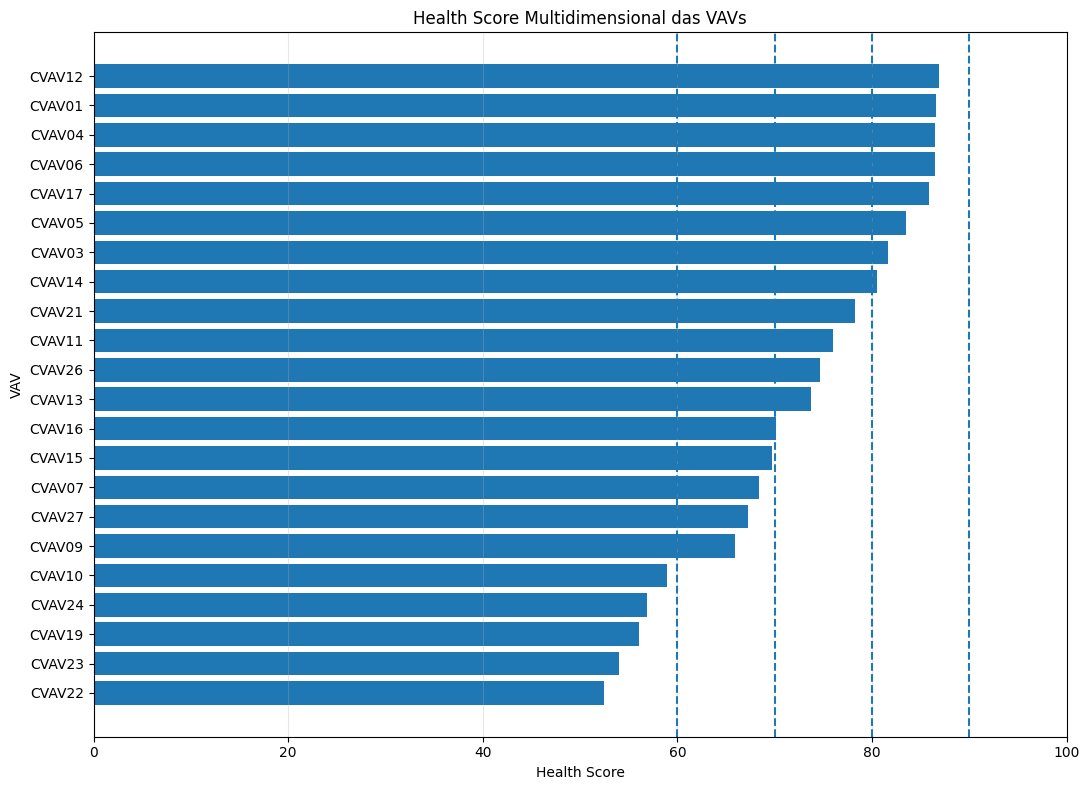

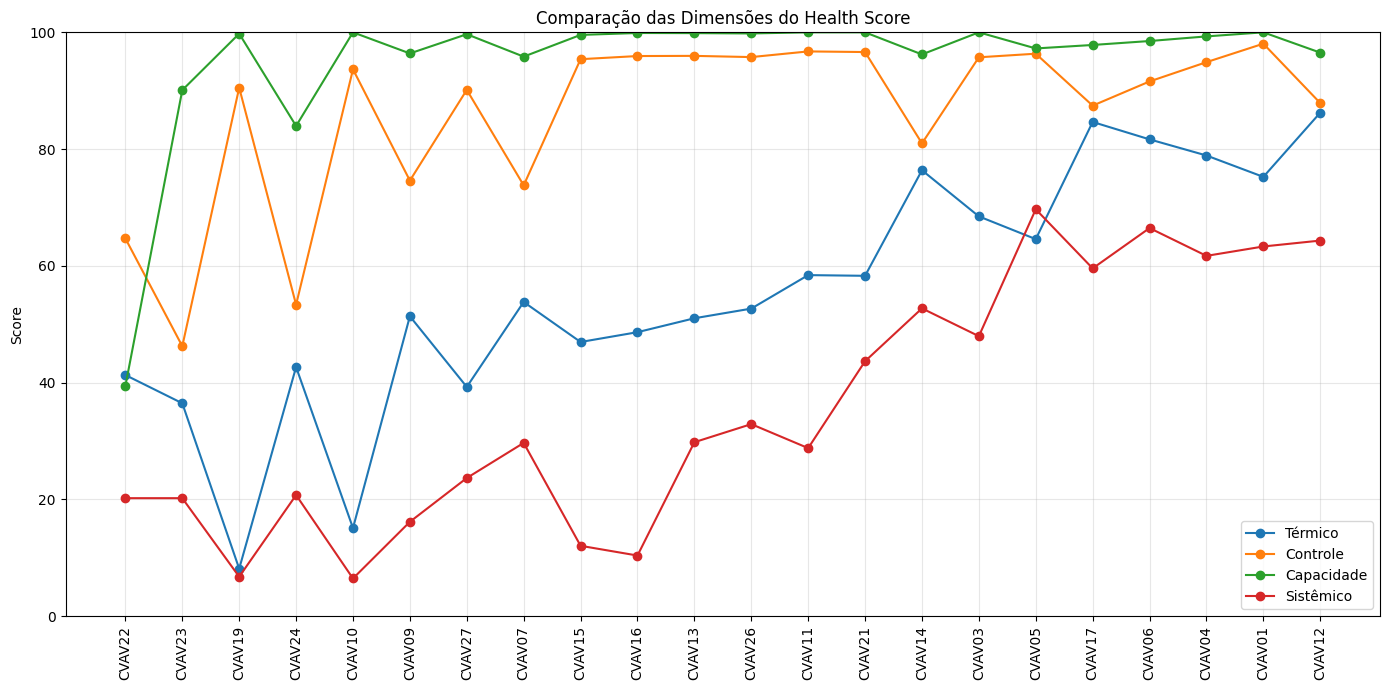


RANKING HEALTH SCORE


,Ranking_Health,Equipamento,FAC,Health_Score,Classificacao_Health,Prioridade_Health,Score_Termico,Score_Controle,Score_Capacidade,Score_Qualidade,Score_Sistemico,Cobertura_Individual_Pct,Exposicao_Sistemica_Pct,Eventos_Individuais,Horas_Eventos_Individuais,Eventos_FAC_Impactaram_VAV,Erro_Absoluto_Medio,Erro_Maximo,DPRPOS_Medio,Vazao_Media_Pct,Dimensao_Mais_Fraca,Recomendacao_Principal
0,1.00,CVAV22,FANC01,52.50,CRÍTICA,P1 - IMEDIATA,41.29,64.69,39.41,100.00,20.19,100.00,79.81,63.00,246.33,117.00,1.21,1.48,75.32,86.08,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
1,2.00,CVAV23,FANC01,54.04,CRÍTICA,P1 - IMEDIATA,36.45,46.23,90.10,100.00,20.19,100.00,79.81,59.00,247.67,117.00,1.49,2.23,94.88,30.33,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
2,3.00,CVAV19,FANC02,56.04,CRÍTICA,P1 - IMEDIATA,8.11,90.51,99.77,100.00,6.73,100.00,93.27,49.00,268.50,78.00,2.88,5.95,40.68,11.25,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
3,4.00,CVAV24,FANC01,56.83,CRÍTICA,P1 - IMEDIATA,42.65,53.34,83.96,100.00,20.73,100.00,79.27,84.00,229.50,116.00,1.09,1.67,82.71,43.89,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
4,5.00,CVAV10,FANC02,58.90,CRÍTICA,P1 - IMEDIATA,15.07,93.66,100.00,100.00,6.43,100.00,93.57,62.00,266.00,79.00,2.17,3.95,21.64,9.92,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
5,6.00,CVAV09,FANC02,65.89,RUIM,P2 - ALTA,51.35,74.60,96.38,99.70,16.14,99.70,83.86,56.00,205.33,72.00,1.20,4.12,68.27,28.79,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
6,7.00,CVAV27,FANC01,67.24,RUIM,P2 - ALTA,39.25,90.14,99.68,96.19,23.65,96.19,76.35,54.00,239.67,114.00,1.57,5.92,61.67,25.59,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
7,8.00,CVAV07,FANC01,68.41,RUIM,P2 - ALTA,53.81,73.79,95.84,100.00,29.66,100.00,70.34,69.00,190.17,99.00,1.11,2.97,88.39,34.88,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
8,9.00,CVAV15,FANC02,69.67,RUIM,P2 - ALTA,46.95,95.40,99.56,100.00,12.03,100.00,87.97,58.00,228.17,73.00,1.29,3.03,21.31,12.74,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."
9,10.00,CVAV16,FANC02,70.10,ATENÇÃO,P3 - MÉDIA,48.63,95.94,99.89,99.94,10.36,99.94,89.64,51.00,221.50,69.00,1.41,3.73,19.86,12.32,SISTÊMICO,"Investigar o FANCOIL associado, pois a VAV apr..."



HEALTH SCORE POR FANCOIL


,FAC,VAVs_Avaliadas,Health_Score_Medio,Health_Score_Minimo,Score_Termico_Medio,Score_Controle_Medio,Score_Capacidade_Medio,Score_Qualidade_Medio,Score_Sistemico_Medio,Exposicao_Sistemica_Media_Pct,Classificacao
0,FANC01,12,73.04,52.50,57.77,83.10,91.99,99.25,41.67,58.33,ATENÇÃO
1,FANC02,10,72.35,56.04,52.68,89.91,98.60,99.86,28.68,71.32,ATENÇÃO



DISTRIBUIÇÃO DAS CLASSIFICAÇÕES


,Classificacao_Health,Quantidade_VAVs
0,ATENÇÃO,5
1,BOA,8
2,CRÍTICA,5
3,RUIM,4
4,SEM SCORE,1



✅ Arquivo criado: 09_Health_Score_Multidimensional_VAV.xlsx


RESUMO EXECUTIVO - MÓDULO 9

VAVs avaliadas....................... 23
VAVs com Health Score................ 22
VAVs sem Health Score................ 1
Health Score médio................... 72.73
Menor Health Score................... 52.50

PESOS
--------------------------------------------------------------------------------------------------------------------------------------------
Térmico............................... 30%
Controle.............................. 25%
Capacidade............................ 15%
Qualidade............................. 15%
Sistêmico............................. 15%

✅ MÓDULO 9 CONCLUÍDO

PRÓXIMO PASSO:
Validar a distribuição do Health Score e os sub-scores.
Após a validação, avançar ao MÓDULO 10 - ARQUITETURA DEFINITIVA PARA POWER BI.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 9 - HEALTH SCORE MULTIDIMENSIONAL
#
# DIMENSÕES:
#
# T = SCORE TÉRMICO
# C = SCORE DE CONTROLE
# K = SCORE DE CAPACIDADE
# Q = SCORE DE QUALIDADE DOS DADOS
# S = SCORE DE EXPOSIÇÃO SISTÊMICA
#
#
# HEALTH SCORE:
#
#     30% Térmico
#     25% Controle
#     15% Capacidade
#     15% Qualidade dos Dados
#     15% Sistêmico
#
#
# IMPORTANTE:
#
# - Eventos sistêmicos não são contabilizados novamente como falhas próprias da VAV.
# - VAV sem cobertura mínima não recebe Health Score oficial.
# - Todos os sub-scores permanecem disponíveis para Power BI.
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 400)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 450)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)


print("=" * 140)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 9 - HEALTH SCORE MULTIDIMENSIONAL")
print("=" * 140)


# ==================================================================================================
# 2. PESOS DO HEALTH SCORE
# ==================================================================================================

PESO_TERMICO = 0.30
PESO_CONTROLE = 0.25
PESO_CAPACIDADE = 0.15
PESO_QUALIDADE = 0.15
PESO_SISTEMICO = 0.15


# --------------------------------------------------------------------------------------------------
# Parâmetros operacionais
# --------------------------------------------------------------------------------------------------

LIMITE_CONFORTO = 0.50
LIMITE_ATENCAO_TERMICA = 1.00
LIMITE_CRITICO_TERMICO = 2.00

DAMPER_BAIXO = 25.0
DAMPER_ALTO = 75.0
DAMPER_SATURADO = 90.0

VAZAO_BAIXA = 25.0
VAZAO_ALTA = 75.0
VAZAO_SATURADA = 90.0

COBERTURA_MINIMA_HEALTH = 80.0

INTERVALO_MINUTOS = 10


print()
print("PESOS")
print("-" * 140)

print(f"Térmico............................ {PESO_TERMICO * 100:.0f}%")
print(f"Controle........................... {PESO_CONTROLE * 100:.0f}%")
print(f"Capacidade......................... {PESO_CAPACIDADE * 100:.0f}%")
print(f"Qualidade dos dados................ {PESO_QUALIDADE * 100:.0f}%")
print(f"Impacto sistêmico.................. {PESO_SISTEMICO * 100:.0f}%")


# ==================================================================================================
# 3. RECUPERAR BASE DO MÓDULO 8.1
# ==================================================================================================

try:

    base_hs = base_81.copy()

    eventos_fac_hs = eventos_fac.copy()

    ponte_hs = ponte_evento_fac_vav.copy()

    print()
    print("✅ Variáveis do Módulo 8.1 encontradas na sessão.")


except NameError:

    print()
    print(
        "As variáveis do Módulo 8.1 não estão disponíveis."
    )

    print(
        "Para este módulo, execute novamente os Módulos 8 e 8.1 "
        "na mesma sessão do Colab."
    )

    raise NameError(
        "Variáveis base_81 / eventos_fac / ponte_evento_fac_vav não encontradas."
    )


base_hs["DataHora"] = pd.to_datetime(
    base_hs["DataHora"],
    errors="coerce"
)


# ==================================================================================================
# 4. INVENTÁRIO
# ==================================================================================================

TODAS_VAVS = sorted(
    base_hs[
        "Equipamento"
    ]
    .dropna()
    .unique()
)


print()
print("=" * 140)
print("INVENTÁRIO")
print("=" * 140)

print(
    f"VAVs encontradas..................... "
    f"{len(TODAS_VAVS)}"
)


# ==================================================================================================
# 5. SCORE TÉRMICO POR REGISTRO
#
# |DeltaT| <= 0.50      -> 100
# 0.50 < erro <= 1.00   -> 70
# 1.00 < erro <= 2.00   -> 35
# erro > 2.00           -> 0
#
# ==================================================================================================

def score_termico_registro(row):

    if not row[
        "Valido_Termico"
    ]:

        return np.nan


    erro = row[
        "Erro_Absoluto_T"
    ]


    if erro <= LIMITE_CONFORTO:

        return 100


    if erro <= LIMITE_ATENCAO_TERMICA:

        return 70


    if erro <= LIMITE_CRITICO_TERMICO:

        return 35


    return 0


base_hs[
    "Score_Termico_Registro"
] = base_hs.apply(
    score_termico_registro,
    axis=1
)


# ==================================================================================================
# 6. SCORE DE CONTROLE POR REGISTRO
#
# IMPORTANTE:
#
# V01/V02/V03 -> problema do FAC.
# Não penalizam diretamente o Score de Controle próprio da VAV.
#
# V22/V23 -> VAV está reduzindo a vazão ou problema térmico sistêmico.
# Penalização pequena no controle individual.
#
# ==================================================================================================

SCORE_CODIGO_VAV = {

    "V10": 60,      # quente em capacidade máxima

    "V11": 45,      # damper aberto / vazão não responde

    "V12": 30,      # baixa resposta de controle

    "V13": 65,      # demanda térmica não satisfeita

    "V20": 40,      # frio com alto insuflamento

    "V21": 25,      # damper baixo / vazão alta

    "V22": 95,      # controle está reduzindo corretamente

    "V23": 90,      # provável problema sistêmico térmico

    "V30": 100      # controle satisfatório

}


def score_controle_registro(row):

    codigo = row[
        "Codigo_VAV_FDD"
    ]


    # Problemas diretamente causados pelo FAC
    # não penalizam controle próprio da caixa.
    # ----------------------------------------------------------------------------------------------

    if codigo in [
        "V01",
        "V02",
        "V03"
    ]:

        return np.nan


    if codigo in [
        "V00",
        "V04"
    ]:

        return np.nan


    return SCORE_CODIGO_VAV.get(
        codigo,
        70
    )


base_hs[
    "Score_Controle_Registro"
] = base_hs.apply(
    score_controle_registro,
    axis=1
)


# ==================================================================================================
# 7. SCORE DE CAPACIDADE
#
# Princípio:
#
# Utilização alta NÃO é ruim isoladamente.
#
# Penalizamos quando:
#
#       Zona QUENTE
#               +
#       VAV próxima do MAXFLO
#
# ==================================================================================================

def score_capacidade_registro(row):

    if not row[
        "Valido_Termico"
    ]:

        return np.nan


    if not row[
        "Vazao_Valida"
    ]:

        return np.nan


    condicao = row[
        "Condicao_Termica"
    ]


    vazao = row[
        "Utilizacao_Vazao_Pct"
    ]


    # ----------------------------------------------------------------------------------------------
    # Zona em conforto ou fria:
    #
    # utilização elevada não significa insuficiência de capacidade.
    # ----------------------------------------------------------------------------------------------

    if condicao in [
        "CONFORTO",
        "FRIO"
    ]:

        return 100


    # ----------------------------------------------------------------------------------------------
    # Zona quente
    # ----------------------------------------------------------------------------------------------

    if vazao >= 100:

        return 20


    if vazao >= VAZAO_SATURADA:

        return 35


    if vazao >= VAZAO_ALTA:

        return 60


    return 90


base_hs[
    "Score_Capacidade_Registro"
] = base_hs.apply(
    score_capacidade_registro,
    axis=1
)


# ==================================================================================================
# 8. RESUMO BÁSICO POR VAV
# ==================================================================================================

resumo_health = (
    base_hs
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False,
        observed=True
    )
    .agg(

        Registros_Totais=(
            "DataHora",
            "size"
        ),

        Registros_Validos_Termicos=(
            "Valido_Termico",
            "sum"
        ),

        Registros_Validos_Controle=(
            "VAV_Valida_Individual",
            "sum"
        ),

        Score_Termico=(
            "Score_Termico_Registro",
            "mean"
        ),

        Score_Controle=(
            "Score_Controle_Registro",
            "mean"
        ),

        Score_Capacidade=(
            "Score_Capacidade_Registro",
            "mean"
        ),

        DeltaT_Medio=(
            "DeltaT",
            "mean"
        ),

        Erro_Absoluto_Medio=(
            "Erro_Absoluto_T",
            "mean"
        ),

        Erro_Maximo=(
            "Erro_Absoluto_T",
            "max"
        ),

        DPRPOS_Medio=(
            "DPRPOS",
            lambda x:
                x[
                    (x >= 0)
                    &
                    (x <= 100)
                ].mean()
        ),

        Vazao_Media_Pct=(
            "Utilizacao_Vazao_Pct",
            "mean"
        )

    )
    .reset_index()
)


# ==================================================================================================
# 9. SCORE DE QUALIDADE DOS DADOS
# ==================================================================================================

resumo_health[
    "Cobertura_Individual_Pct"
] = (

    resumo_health[
        "Registros_Validos_Controle"
    ]

    /

    resumo_health[
        "Registros_Totais"
    ]

    *

    100

)


# O próprio percentual de cobertura será utilizado como score.
# ----------------------------------------------------------------------------------------------

resumo_health[
    "Score_Qualidade"
] = (
    resumo_health[
        "Cobertura_Individual_Pct"
    ]
    .clip(
        lower=0,
        upper=100
    )
)


# ==================================================================================================
# 10. MARCAR TIMESTAMPS IMPACTADOS POR EVENTOS SISTÊMICOS
#
# Esta abordagem evita somar duas vezes eventos.
#
# Cada timestamp será:
#
#   1 = impactado por algum evento FAC
#   0 = não impactado
#
# ==================================================================================================

base_hs[
    "Flag_Impacto_Sistemico"
] = 0


if (
    len(eventos_fac_hs) > 0
    and
    len(ponte_hs) > 0
):

    eventos_lookup = (
        eventos_fac_hs[
            [
                "Evento_FAC_ID",
                "FAC",
                "Inicio",
                "Fim"
            ]
        ]
        .drop_duplicates()
        .set_index(
            "Evento_FAC_ID"
        )
    )


    for _, impacto in ponte_hs.iterrows():

        evento_id = impacto[
            "Evento_FAC_ID"
        ]

        equipamento = impacto[
            "Equipamento"
        ]


        if evento_id not in eventos_lookup.index:

            continue


        evento = eventos_lookup.loc[
            evento_id
        ]


        inicio = evento[
            "Inicio"
        ]

        fim = evento[
            "Fim"
        ]


        mascara = (

            (
                base_hs[
                    "Equipamento"
                ]
                ==
                equipamento
            )

            &

            (
                base_hs[
                    "DataHora"
                ]
                >=
                inicio
            )

            &

            (
                base_hs[
                    "DataHora"
                ]
                <=
                fim
            )

        )


        base_hs.loc[
            mascara,
            "Flag_Impacto_Sistemico"
        ] = 1


# ==================================================================================================
# 11. EXPOSIÇÃO SISTÊMICA POR VAV
# ==================================================================================================

impacto_sistemico = (
    base_hs
    .groupby(
        [
            "Equipamento",
            "FAC"
        ],
        dropna=False
    )
    .agg(

        Timestamps_Impactados_Sistema=(
            "Flag_Impacto_Sistemico",
            "sum"
        ),

        Timestamps_Totais=(
            "DataHora",
            "size"
        )

    )
    .reset_index()
)


impacto_sistemico[
    "Exposicao_Sistemica_Pct"
] = (

    impacto_sistemico[
        "Timestamps_Impactados_Sistema"
    ]

    /

    impacto_sistemico[
        "Timestamps_Totais"
    ]

    *

    100

)


# Quanto menor a exposição, melhor o score.
# ----------------------------------------------------------------------------------------------

impacto_sistemico[
    "Score_Sistemico"
] = (

    100

    -

    impacto_sistemico[
        "Exposicao_Sistemica_Pct"
    ]

).clip(
    lower=0,
    upper=100
)


# ==================================================================================================
# 12. INTEGRAR SCORE SISTÊMICO
# ==================================================================================================

resumo_health = resumo_health.merge(

    impacto_sistemico[
        [
            "Equipamento",
            "FAC",
            "Timestamps_Impactados_Sistema",
            "Exposicao_Sistemica_Pct",
            "Score_Sistemico"
        ]
    ],

    on=[
        "Equipamento",
        "FAC"
    ],

    how="left"

)


# ==================================================================================================
# 13. INTEGRAR EVENTOS NORMALIZADOS
# ==================================================================================================

try:

    resumo_normalizado = (
        resumo_vav_normalizado[
            [
                "Equipamento",
                "FAC",

                "Eventos_Individuais",
                "Horas_Eventos_Individuais",

                "Maior_Evento_Individual_h",

                "Eventos_FAC_Impactaram_VAV",

                "Elegibilidade_Health_Score"
            ]
        ]
        .copy()
    )


    resumo_health = resumo_health.merge(

        resumo_normalizado,

        on=[
            "Equipamento",
            "FAC"
        ],

        how="left"

    )

except NameError:

    resumo_health[
        "Elegibilidade_Health_Score"
    ] = np.where(

        resumo_health[
            "Cobertura_Individual_Pct"
        ]
        >=
        COBERTURA_MINIMA_HEALTH,

        "ELEGÍVEL",

        "NÃO ELEGÍVEL"

    )


# ==================================================================================================
# 14. HEALTH SCORE BRUTO
# ==================================================================================================

resumo_health[
    "Health_Score_Bruto"
] = (

    resumo_health[
        "Score_Termico"
    ]
    *
    PESO_TERMICO

    +

    resumo_health[
        "Score_Controle"
    ]
    *
    PESO_CONTROLE

    +

    resumo_health[
        "Score_Capacidade"
    ]
    *
    PESO_CAPACIDADE

    +

    resumo_health[
        "Score_Qualidade"
    ]
    *
    PESO_QUALIDADE

    +

    resumo_health[
        "Score_Sistemico"
    ]
    *
    PESO_SISTEMICO

)


# ==================================================================================================
# 15. HEALTH SCORE OFICIAL
#
# VAV com cobertura <80%:
#
# não recebe score oficial.
# ==================================================================================================

resumo_health[
    "Health_Score"
] = np.where(

    resumo_health[
        "Cobertura_Individual_Pct"
    ]
    >=
    COBERTURA_MINIMA_HEALTH,

    resumo_health[
        "Health_Score_Bruto"
    ],

    np.nan

)


# ==================================================================================================
# 16. CLASSIFICAÇÃO
# ==================================================================================================

def classificar_health(score):

    if pd.isna(score):

        return "SEM SCORE"


    if score >= 90:

        return "EXCELENTE"


    if score >= 80:

        return "BOA"


    if score >= 70:

        return "ATENÇÃO"


    if score >= 60:

        return "RUIM"


    return "CRÍTICA"


resumo_health[
    "Classificacao_Health"
] = (
    resumo_health[
        "Health_Score"
    ]
    .apply(
        classificar_health
    )
)


# ==================================================================================================
# 17. IDENTIFICAR DIMENSÃO MAIS FRACA
# ==================================================================================================

DIMENSOES = {

    "TÉRMICO":
        "Score_Termico",

    "CONTROLE":
        "Score_Controle",

    "CAPACIDADE":
        "Score_Capacidade",

    "QUALIDADE":
        "Score_Qualidade",

    "SISTÊMICO":
        "Score_Sistemico"

}


def encontrar_dimensao_critica(row):

    valores = {}


    for nome, coluna in DIMENSOES.items():

        valor = row[
            coluna
        ]


        if pd.notna(valor):

            valores[
                nome
            ] = valor


    if len(valores) == 0:

        return "SEM DADOS"


    return min(
        valores,
        key=valores.get
    )


resumo_health[
    "Dimensao_Mais_Fraca"
] = resumo_health.apply(
    encontrar_dimensao_critica,
    axis=1
)


# ==================================================================================================
# 18. GAP PARA 100
# ==================================================================================================

for nome, coluna in DIMENSOES.items():

    resumo_health[
        f"Gap_{nome}"
    ] = (
        100
        -
        resumo_health[
            coluna
        ]
    )


# ==================================================================================================
# 19. PRIORIDADE DE INVESTIGAÇÃO HEALTH
#
# Quanto menor Health Score, maior a prioridade.
# ==================================================================================================

def prioridade_health(row):

    score = row[
        "Health_Score"
    ]


    if pd.isna(score):

        return "SEM CLASSIFICAÇÃO"


    if score < 60:

        return "P1 - IMEDIATA"


    if score < 70:

        return "P2 - ALTA"


    if score < 80:

        return "P3 - MÉDIA"


    return "P4 - BAIXA"


resumo_health[
    "Prioridade_Health"
] = resumo_health.apply(
    prioridade_health,
    axis=1
)


# ==================================================================================================
# 20. RECOMENDAÇÃO POR DIMENSÃO
# ==================================================================================================

RECOMENDACOES_DIMENSAO = {

    "TÉRMICO":
        (
            "Investigar estabilidade da temperatura da zona, "
            "setpoint, carga térmica e capacidade de atendimento."
        ),

    "CONTROLE":
        (
            "Investigar atuador, sensor de vazão, sequência de controle "
            "e coerência entre DPRPOS e SUPFLO."
        ),

    "CAPACIDADE":
        (
            "Verificar MAXFLO, capacidade da caixa, balanceamento e "
            "capacidade disponível em períodos de alta demanda."
        ),

    "QUALIDADE":
        (
            "Priorizar comunicação, integridade dos sensores e "
            "continuidade dos dados antes de concluir diagnóstico."
        ),

    "SISTÊMICO":
        (
            "Investigar o FANCOIL associado, pois a VAV apresenta "
            "elevada exposição a ocorrências coletivas."
        ),

    "SEM DADOS":
        (
            "Restabelecer coleta de dados antes da avaliação de performance."
        )

}


resumo_health[
    "Recomendacao_Principal"
] = (
    resumo_health[
        "Dimensao_Mais_Fraca"
    ]
    .map(
        RECOMENDACOES_DIMENSAO
    )
)


# ==================================================================================================
# 21. RANKING HEALTH SCORE
# ==================================================================================================

ranking_health = (
    resumo_health
    .sort_values(

        [
            "Health_Score",
            "Score_Termico"
        ],

        ascending=[
            True,
            True
        ],

        na_position="last"

    )
    .reset_index(
        drop=True
    )
)


ranking_health[
    "Ranking_Health"
] = np.nan


elegiveis = ranking_health[
    "Health_Score"
].notna()


ranking_health.loc[
    elegiveis,
    "Ranking_Health"
] = np.arange(
    1,
    elegiveis.sum() + 1
)


# ==================================================================================================
# 22. HEALTH SCORE POR FANCOIL
#
# Média das VAVs elegíveis.
# ==================================================================================================

health_fac = (
    resumo_health[
        resumo_health[
            "Health_Score"
        ].notna()
    ]
    .groupby(
        "FAC"
    )
    .agg(

        VAVs_Avaliadas=(
            "Equipamento",
            "nunique"
        ),

        Health_Score_Medio=(
            "Health_Score",
            "mean"
        ),

        Health_Score_Minimo=(
            "Health_Score",
            "min"
        ),

        Score_Termico_Medio=(
            "Score_Termico",
            "mean"
        ),

        Score_Controle_Medio=(
            "Score_Controle",
            "mean"
        ),

        Score_Capacidade_Medio=(
            "Score_Capacidade",
            "mean"
        ),

        Score_Qualidade_Medio=(
            "Score_Qualidade",
            "mean"
        ),

        Score_Sistemico_Medio=(
            "Score_Sistemico",
            "mean"
        ),

        Exposicao_Sistemica_Media_Pct=(
            "Exposicao_Sistemica_Pct",
            "mean"
        )

    )
    .reset_index()
)


health_fac[
    "Classificacao"
] = (
    health_fac[
        "Health_Score_Medio"
    ]
    .apply(
        classificar_health
    )
)


# ==================================================================================================
# 23. DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
# ==================================================================================================

distribuicao_health = (
    resumo_health
    .groupby(
        "Classificacao_Health",
        dropna=False
    )
    .size()
    .reset_index(
        name="Quantidade_VAVs"
    )
)


# ==================================================================================================
# 24. GRÁFICO - HEALTH SCORE
# ==================================================================================================

grafico_health = ranking_health[
    ranking_health[
        "Health_Score"
    ].notna()
].copy()


if len(
    grafico_health
) > 0:

    grafico_health = (
        grafico_health
        .sort_values(
            "Health_Score",
            ascending=True
        )
    )


    plt.figure(
        figsize=(11, 8)
    )


    plt.barh(
        grafico_health[
            "Equipamento"
        ],
        grafico_health[
            "Health_Score"
        ]
    )


    plt.axvline(
        60,
        linestyle="--"
    )

    plt.axvline(
        70,
        linestyle="--"
    )

    plt.axvline(
        80,
        linestyle="--"
    )

    plt.axvline(
        90,
        linestyle="--"
    )


    plt.xlabel(
        "Health Score"
    )

    plt.ylabel(
        "VAV"
    )

    plt.title(
        "Health Score Multidimensional das VAVs"
    )

    plt.xlim(
        0,
        100
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 25. GRÁFICO - SUBSCORES
# ==================================================================================================

grafico_dim = ranking_health[
    ranking_health[
        "Health_Score"
    ].notna()
].copy()


if len(
    grafico_dim
) > 0:

    grafico_dim = (
        grafico_dim
        .sort_values(
            "Health_Score",
            ascending=True
        )
    )


    x = np.arange(
        len(
            grafico_dim
        )
    )


    plt.figure(
        figsize=(14, 7)
    )


    plt.plot(
        x,
        grafico_dim[
            "Score_Termico"
        ],
        marker="o",
        label="Térmico"
    )


    plt.plot(
        x,
        grafico_dim[
            "Score_Controle"
        ],
        marker="o",
        label="Controle"
    )


    plt.plot(
        x,
        grafico_dim[
            "Score_Capacidade"
        ],
        marker="o",
        label="Capacidade"
    )


    plt.plot(
        x,
        grafico_dim[
            "Score_Sistemico"
        ],
        marker="o",
        label="Sistêmico"
    )


    plt.xticks(
        x,
        grafico_dim[
            "Equipamento"
        ],
        rotation=90
    )


    plt.ylabel(
        "Score"
    )

    plt.title(
        "Comparação das Dimensões do Health Score"
    )

    plt.ylim(
        0,
        100
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ==================================================================================================
# 26. RELATÓRIOS
# ==================================================================================================

print()
print("=" * 140)
print("RANKING HEALTH SCORE")
print("=" * 140)


display(

    ranking_health[
        [
            "Ranking_Health",

            "Equipamento",
            "FAC",

            "Health_Score",
            "Classificacao_Health",
            "Prioridade_Health",

            "Score_Termico",
            "Score_Controle",
            "Score_Capacidade",
            "Score_Qualidade",
            "Score_Sistemico",

            "Cobertura_Individual_Pct",

            "Exposicao_Sistemica_Pct",

            "Eventos_Individuais",
            "Horas_Eventos_Individuais",

            "Eventos_FAC_Impactaram_VAV",

            "Erro_Absoluto_Medio",
            "Erro_Maximo",

            "DPRPOS_Medio",
            "Vazao_Media_Pct",

            "Dimensao_Mais_Fraca",

            "Recomendacao_Principal"

        ]
    ]

)


print()
print("=" * 140)
print("HEALTH SCORE POR FANCOIL")
print("=" * 140)

display(
    health_fac
)


print()
print("=" * 140)
print("DISTRIBUIÇÃO DAS CLASSIFICAÇÕES")
print("=" * 140)

display(
    distribuicao_health
)


# ==================================================================================================
# 27. BASE DETALHADA PARA POWER BI
# ==================================================================================================

colunas_powerbi = [

    "Equipamento",
    "FAC",

    "Health_Score",
    "Classificacao_Health",
    "Prioridade_Health",

    "Score_Termico",
    "Score_Controle",
    "Score_Capacidade",
    "Score_Qualidade",
    "Score_Sistemico",

    "Cobertura_Individual_Pct",

    "Exposicao_Sistemica_Pct",

    "Eventos_Individuais",
    "Horas_Eventos_Individuais",

    "Eventos_FAC_Impactaram_VAV",

    "DeltaT_Medio",

    "Erro_Absoluto_Medio",
    "Erro_Maximo",

    "DPRPOS_Medio",

    "Vazao_Media_Pct",

    "Dimensao_Mais_Fraca",

    "Recomendacao_Principal"

]


colunas_powerbi = [
    coluna
    for coluna in colunas_powerbi
    if coluna in ranking_health.columns
]


base_health_powerbi = (
    ranking_health[
        colunas_powerbi
    ]
    .copy()
)


# ==================================================================================================
# 28. METODOLOGIA DO SCORE
# ==================================================================================================

metodologia = pd.DataFrame([

    [
        "Térmico",
        30,
        "Avalia proximidade entre ZN-TEM e ZNT-SP."
    ],

    [
        "Controle",
        25,
        "Avalia coerência entre temperatura, DPRPOS e vazão."
    ],

    [
        "Capacidade",
        15,
        "Penaliza principalmente zona quente com utilização elevada do MAXFLO."
    ],

    [
        "Qualidade",
        15,
        "Avalia cobertura dos dados necessários ao diagnóstico."
    ],

    [
        "Sistêmico",
        15,
        "Avalia exposição da VAV a eventos persistentes do FANCOIL."
    ]

],
columns=[
    "Dimensao",
    "Peso_Pct",
    "Descricao"
])


# ==================================================================================================
# 29. EXPORTAÇÃO
# ==================================================================================================

ARQUIVO_SAIDA = (
    "09_Health_Score_Multidimensional_VAV.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    ranking_health.to_excel(
        writer,
        sheet_name="Ranking Health Score",
        index=False
    )


    health_fac.to_excel(
        writer,
        sheet_name="Health FANCOIL",
        index=False
    )


    distribuicao_health.to_excel(
        writer,
        sheet_name="Distribuicao",
        index=False
    )


    impacto_sistemico.to_excel(
        writer,
        sheet_name="Impacto Sistemico",
        index=False
    )


    metodologia.to_excel(
        writer,
        sheet_name="Metodologia",
        index=False
    )


    base_health_powerbi.to_excel(
        writer,
        sheet_name="Base Health Power BI",
        index=False
    )


print()
print(
    f"✅ Arquivo criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 30. RESUMO EXECUTIVO
# ==================================================================================================

vavs_com_score = (
    resumo_health[
        "Health_Score"
    ].notna()
).sum()


vavs_sem_score = (
    resumo_health[
        "Health_Score"
    ].isna()
).sum()


health_medio = (
    resumo_health[
        "Health_Score"
    ]
    .mean()
)


health_minimo = (
    resumo_health[
        "Health_Score"
    ]
    .min()
)


print()
print()
print("=" * 140)
print("RESUMO EXECUTIVO - MÓDULO 9")
print("=" * 140)


print()
print(
    f"VAVs avaliadas....................... "
    f"{len(TODAS_VAVS)}"
)


print(
    f"VAVs com Health Score................ "
    f"{vavs_com_score}"
)


print(
    f"VAVs sem Health Score................ "
    f"{vavs_sem_score}"
)


print(
    f"Health Score médio................... "
    f"{health_medio:.2f}"
    if pd.notna(health_medio)
    else
    "Health Score médio................... N/D"
)


print(
    f"Menor Health Score................... "
    f"{health_minimo:.2f}"
    if pd.notna(health_minimo)
    else
    "Menor Health Score................... N/D"
)


print()
print("PESOS")
print("-" * 140)

print("Térmico............................... 30%")
print("Controle.............................. 25%")
print("Capacidade............................ 15%")
print("Qualidade............................. 15%")
print("Sistêmico............................. 15%")


print()
print("=" * 140)
print("✅ MÓDULO 9 CONCLUÍDO")
print("=" * 140)

print()
print(
    "PRÓXIMO PASSO:"
)

print(
    "Validar a distribuição do Health Score e os sub-scores."
)

print(
    "Após a validação, avançar ao MÓDULO 10 - "
    "ARQUITETURA DEFINITIVA PARA POWER BI."
)


# ==================================================================================================
# 31. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

In [14]:
# ==================================================================================================
# PROJETO PERFORMANCE VAV x FANCOIL
# MÓDULO 10 - ARQUITETURA DEFINITIVA PARA POWER BI
#
# OBJETIVO:
#
# Transformar os resultados dos módulos anteriores em um MODELO ESTRELA.
#
# TABELAS PRINCIPAIS:
#
# DIMENSÕES
#   - Dim_Data
#   - Dim_Hora
#   - Dim_VAV
#   - Dim_FANCOIL
#   - Dim_FDD
#
# FATOS
#   - Fato_VAV_10min
#   - Fato_FAC_10min
#   - Fato_Health_Score
#   - Fato_Eventos_VAV
#   - Fato_Eventos_FAC
#
# PONTE
#   - Ponte_EventoFAC_VAV
#
# DOCUMENTAÇÃO
#   - Relacionamentos
#   - DAX_Sugerido
#   - Dicionario_Dados
#
# ==================================================================================================


# ==================================================================================================
# 1. BIBLIOTECAS
# ==================================================================================================

import pandas as pd
import numpy as np
from google.colab import files
from IPython.display import display
from pathlib import Path
import zipfile
import os
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 500)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)


print("=" * 145)
print("PROJETO PERFORMANCE VAV x FANCOIL")
print("MÓDULO 10 - ARQUITETURA DEFINITIVA PARA POWER BI")
print("=" * 145)


# ==================================================================================================
# 2. PARÂMETROS GERAIS
# ==================================================================================================

NOME_PROJETO = "Performance_VAV_FANCOIL"

ARQUIVO_SAIDA = (
    "10_Modelo_Dados_PowerBI_VAV_FANCOIL.xlsx"
)

PASTA_CSV = "PowerBI_CSV"

ARQUIVO_ZIP = (
    "10_Tabelas_PowerBI_CSV.zip"
)


# ==================================================================================================
# 3. FUNÇÃO AUXILIAR PARA BUSCAR TABELA EM ARQUIVOS
# ==================================================================================================

def buscar_tabela_excel(
    arquivos,
    nome_aba
):

    for arquivo in arquivos:

        try:

            xls = pd.ExcelFile(
                arquivo
            )

            if nome_aba in xls.sheet_names:

                print(
                    f"✅ '{nome_aba}' encontrada em {arquivo}"
                )

                return pd.read_excel(
                    arquivo,
                    sheet_name=nome_aba
                )

        except Exception:
            pass

    return None


# ==================================================================================================
# 4. RECUPERAR BASE ANALÍTICA
# ==================================================================================================

arquivos_upload = []


try:

    df_base = base_analitica.copy()

    print()
    print(
        "✅ base_analitica encontrada na sessão."
    )


except NameError:

    print()
    print(
        "A base_analitica não foi encontrada na sessão."
    )

    print(
        "Selecione os arquivos gerados pelos módulos anteriores."
    )

    print()
    print(
        "Principalmente:"
    )

    print(
        "03_1_Base_Consolidada_VAV_FAC.xlsx"
    )

    print(
        "08_1_FDD_Normalizado_VAV_FANCOIL.xlsx"
    )

    print(
        "09_Health_Score_Multidimensional_VAV.xlsx"
    )

    print(
        "07_1_Diagnostico_Sistemico_Refinado.xlsx "
        "(opcional, porém recomendado)"
    )


    uploaded = files.upload()


    arquivos_upload = [

        nome

        for nome in uploaded.keys()

        if nome.lower().endswith(
            (".xlsx", ".xls")
        )

    ]


    df_base = buscar_tabela_excel(
        arquivos_upload,
        "Base Analitica"
    )


    if df_base is None:

        raise FileNotFoundError(
            "Não foi possível localizar a aba 'Base Analitica'."
        )


# ==================================================================================================
# 5. RECUPERAR EVENTOS NORMALIZADOS
# ==================================================================================================

try:

    df_eventos_fac = eventos_fac.copy()

    print(
        "✅ eventos_fac encontrada."
    )

except NameError:

    if not arquivos_upload:

        uploaded = files.upload()

        arquivos_upload += [

            nome
            for nome in uploaded.keys()
            if nome.lower().endswith(
                (".xlsx", ".xls")
            )

        ]


    df_eventos_fac = buscar_tabela_excel(
        arquivos_upload,
        "Fato Eventos FAC"
    )


    if df_eventos_fac is None:

        df_eventos_fac = pd.DataFrame()


try:

    df_eventos_vav = eventos_vav.copy()

    print(
        "✅ eventos_vav encontrada."
    )

except NameError:

    df_eventos_vav = buscar_tabela_excel(
        arquivos_upload,
        "Fato Eventos VAV"
    )


    if df_eventos_vav is None:

        df_eventos_vav = pd.DataFrame()


try:

    df_ponte = ponte_evento_fac_vav.copy()

    print(
        "✅ ponte_evento_fac_vav encontrada."
    )

except NameError:

    df_ponte = buscar_tabela_excel(
        arquivos_upload,
        "Ponte FAC VAV"
    )


    if df_ponte is None:

        df_ponte = pd.DataFrame()


# ==================================================================================================
# 6. RECUPERAR HEALTH SCORE
# ==================================================================================================

try:

    df_health = ranking_health.copy()

    print(
        "✅ ranking_health encontrada."
    )

except NameError:

    df_health = buscar_tabela_excel(
        arquivos_upload,
        "Ranking Health Score"
    )


    if df_health is None:

        df_health = buscar_tabela_excel(
            arquivos_upload,
            "Base Health Power BI"
        )


    if df_health is None:

        df_health = pd.DataFrame()


# ==================================================================================================
# 7. RECUPERAR BASE SISTÊMICA DO FANCOIL
# ==================================================================================================

try:

    df_fac_sistema = sistema_71.copy()

    print(
        "✅ sistema_71 encontrada."
    )

except NameError:

    df_fac_sistema = buscar_tabela_excel(
        arquivos_upload,
        "Base Sistemica Refinada"
    )


    if df_fac_sistema is None:

        df_fac_sistema = pd.DataFrame()


# ==================================================================================================
# 8. PADRONIZAÇÃO DE DATAS
# ==================================================================================================

df_base[
    "DataHora"
] = pd.to_datetime(
    df_base[
        "DataHora"
    ],
    errors="coerce"
)


for df in [

    df_eventos_fac,
    df_eventos_vav

]:

    if len(df) > 0:

        for coluna in [
            "Inicio",
            "Fim"
        ]:

            if coluna in df.columns:

                df[coluna] = pd.to_datetime(
                    df[coluna],
                    errors="coerce"
                )


if len(
    df_fac_sistema
) > 0:

    df_fac_sistema[
        "DataHora"
    ] = pd.to_datetime(
        df_fac_sistema[
            "DataHora"
        ],
        errors="coerce"
    )


# ==================================================================================================
# 9. CRIAÇÃO DAS CHAVES TEMPORAIS
# ==================================================================================================

def criar_data_key(serie):

    return pd.to_numeric(
        pd.to_datetime(
            serie,
            errors="coerce"
        )
        .dt.strftime(
            "%Y%m%d"
        ),
        errors="coerce"
    ).astype("Int64")


def criar_hora_key(serie):

    dt = pd.to_datetime(
        serie,
        errors="coerce"
    )

    return (
        dt.dt.hour * 100
        +
        dt.dt.minute
    ).astype("Int64")


df_base[
    "DataKey"
] = criar_data_key(
    df_base[
        "DataHora"
    ]
)


df_base[
    "HoraKey"
] = criar_hora_key(
    df_base[
        "DataHora"
    ]
)


# ==================================================================================================
# 10. DIM_DATA
# ==================================================================================================

data_min = (
    df_base[
        "DataHora"
    ]
    .min()
    .normalize()
)


data_max = (
    df_base[
        "DataHora"
    ]
    .max()
    .normalize()
)


datas = pd.date_range(
    data_min,
    data_max,
    freq="D"
)


dim_data = pd.DataFrame({
    "Data": datas
})


dim_data[
    "DataKey"
] = (
    dim_data[
        "Data"
    ]
    .dt.strftime(
        "%Y%m%d"
    )
    .astype(int)
)


dim_data[
    "Ano"
] = (
    dim_data[
        "Data"
    ]
    .dt.year
)


dim_data[
    "MesNumero"
] = (
    dim_data[
        "Data"
    ]
    .dt.month
)


mapa_mes = {

    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"

}


dim_data[
    "Mes"
] = (
    dim_data[
        "MesNumero"
    ]
    .map(
        mapa_mes
    )
)


dim_data[
    "AnoMes"
] = (
    dim_data[
        "Data"
    ]
    .dt.strftime(
        "%Y-%m"
    )
)


dim_data[
    "AnoMesKey"
] = (

    dim_data[
        "Ano"
    ]
    *
    100

    +

    dim_data[
        "MesNumero"
    ]

)


dim_data[
    "Dia"
] = (
    dim_data[
        "Data"
    ]
    .dt.day
)


dim_data[
    "DiaSemanaNumero"
] = (
    dim_data[
        "Data"
    ]
    .dt.dayofweek
    +
    1
)


mapa_dia = {

    1: "Segunda",
    2: "Terça",
    3: "Quarta",
    4: "Quinta",
    5: "Sexta",
    6: "Sábado",
    7: "Domingo"

}


dim_data[
    "DiaSemana"
] = (
    dim_data[
        "DiaSemanaNumero"
    ]
    .map(
        mapa_dia
    )
)


dim_data[
    "DiaUtil"
] = (
    dim_data[
        "DiaSemanaNumero"
    ]
    <=
    5
)


dim_data[
    "Trimestre"
] = (
    "T"
    +
    dim_data[
        "Data"
    ]
    .dt.quarter
    .astype(str)
)


dim_data[
    "SemanaAno"
] = (
    dim_data[
        "Data"
    ]
    .dt.isocalendar()
    .week
    .astype(int)
)


dim_data = dim_data[
    [

        "DataKey",
        "Data",

        "Ano",
        "MesNumero",
        "Mes",
        "AnoMes",
        "AnoMesKey",

        "Trimestre",
        "SemanaAno",

        "Dia",
        "DiaSemanaNumero",
        "DiaSemana",

        "DiaUtil"

    ]
]


# ==================================================================================================
# 11. DIM_HORA
# ==================================================================================================

horarios = pd.date_range(
    "2000-01-01 00:00",
    "2000-01-01 23:50",
    freq="10min"
)


dim_hora = pd.DataFrame({
    "Horario": horarios
})


dim_hora[
    "Hora"
] = (
    dim_hora[
        "Horario"
    ]
    .dt.hour
)


dim_hora[
    "Minuto"
] = (
    dim_hora[
        "Horario"
    ]
    .dt.minute
)


dim_hora[
    "HoraKey"
] = (

    dim_hora[
        "Hora"
    ]
    *
    100

    +

    dim_hora[
        "Minuto"
    ]

)


dim_hora[
    "HoraTexto"
] = (
    dim_hora[
        "Horario"
    ]
    .dt.strftime(
        "%H:%M"
    )
)


def periodo_dia(hora):

    if hora < 6:
        return "Madrugada"

    if hora < 12:
        return "Manhã"

    if hora < 18:
        return "Tarde"

    return "Noite"


dim_hora[
    "PeriodoDia"
] = (
    dim_hora[
        "Hora"
    ]
    .apply(
        periodo_dia
    )
)


dim_hora[
    "Janela_Operacional_07_19"
] = (
    (
        dim_hora[
            "Hora"
        ]
        >=
        7
    )
    &
    (
        dim_hora[
            "Hora"
        ]
        <=
        19
    )
)


dim_hora = dim_hora[
    [

        "HoraKey",
        "HoraTexto",
        "Hora",
        "Minuto",

        "PeriodoDia",

        "Janela_Operacional_07_19"

    ]
]


# ==================================================================================================
# 12. DIM_VAV
# ==================================================================================================

dim_vav = (
    df_base[
        [
            "Equipamento",
            "FAC",
            "MAXFLO"
        ]
    ]
    .drop_duplicates(
        subset=[
            "Equipamento"
        ]
    )
    .copy()
)


dim_vav = dim_vav.rename(
    columns={
        "Equipamento":
            "VAV"
    }
)


dim_vav[
    "VAVKey"
] = np.arange(
    1,
    len(
        dim_vav
    ) + 1
)


# --------------------------------------------------------------------------------------------------
# Estrutura preparada para informações futuras
# --------------------------------------------------------------------------------------------------

dim_vav[
    "Predio"
] = "A DEFINIR"


dim_vav[
    "Andar"
] = "A DEFINIR"


dim_vav[
    "Zona"
] = "A DEFINIR"


dim_vav[
    "Tipo_Ambiente"
] = "A DEFINIR"


dim_vav[
    "Ativa"
] = True


dim_vav = dim_vav[
    [

        "VAVKey",

        "VAV",
        "FAC",
        "MAXFLO",

        "Predio",
        "Andar",
        "Zona",
        "Tipo_Ambiente",

        "Ativa"

    ]
]


# ==================================================================================================
# 13. DIM_FANCOIL
# ==================================================================================================

facs = sorted(
    df_base[
        "FAC"
    ]
    .dropna()
    .unique()
)


dim_fancoil = pd.DataFrame({
    "FAC": facs
})


dim_fancoil[
    "FACKey"
] = np.arange(
    1,
    len(
        dim_fancoil
    ) + 1
)


dim_fancoil[
    "Predio"
] = "A DEFINIR"


dim_fancoil[
    "Andar"
] = "A DEFINIR"


dim_fancoil[
    "Descricao"
] = "Fancoil"


dim_fancoil[
    "Ativo"
] = True


dim_fancoil = dim_fancoil[
    [

        "FACKey",

        "FAC",

        "Predio",
        "Andar",

        "Descricao",

        "Ativo"

    ]
]


# ==================================================================================================
# 14. MAPAS DE CHAVES
# ==================================================================================================

mapa_vav_key = dict(
    zip(
        dim_vav[
            "VAV"
        ],
        dim_vav[
            "VAVKey"
        ]
    )
)


mapa_fac_key = dict(
    zip(
        dim_fancoil[
            "FAC"
        ],
        dim_fancoil[
            "FACKey"
        ]
    )
)


# ==================================================================================================
# 15. FATO_VAV_10MIN
# ==================================================================================================

fato_vav = df_base.copy()


fato_vav[
    "VAVKey"
] = (
    fato_vav[
        "Equipamento"
    ]
    .map(
        mapa_vav_key
    )
)


fato_vav[
    "FACKey"
] = (
    fato_vav[
        "FAC"
    ]
    .map(
        mapa_fac_key
    )
)


# --------------------------------------------------------------------------------------------------
# Variáveis derivadas fundamentais
# --------------------------------------------------------------------------------------------------

if (
    "DeltaT"
    not in fato_vav.columns
):

    fato_vav[
        "DeltaT"
    ] = (

        fato_vav[
            "ZN-TEM"
        ]

        -

        fato_vav[
            "ZNT-SP"
        ]

    )


fato_vav[
    "Erro_Absoluto_T"
] = (
    fato_vav[
        "DeltaT"
    ]
    .abs()
)


fato_vav[
    "Utilizacao_Vazao_Pct"
] = np.where(

    (
        fato_vav[
            "MAXFLO"
        ]
        >
        0
    )

    &

    fato_vav[
        "SUPFLO"
    ].notna(),

    (

        fato_vav[
            "SUPFLO"
        ]

        /

        fato_vav[
            "MAXFLO"
        ]

        *

        100

    ),

    np.nan

)


fato_vav[
    "Flag_Conforto"
] = (

    fato_vav[
        "Erro_Absoluto_T"
    ]
    <=
    0.50

).fillna(False).astype(int)


fato_vav[
    "Flag_Quente"
] = (

    fato_vav[
        "DeltaT"
    ]
    >
    0.50

).fillna(False).astype(int)


fato_vav[
    "Flag_Frio"
] = (

    fato_vav[
        "DeltaT"
    ]
    <
    -0.50

).fillna(False).astype(int)


# --------------------------------------------------------------------------------------------------
# Selecionar colunas centrais
# --------------------------------------------------------------------------------------------------

colunas_fato_vav = [

    "DataHora",

    "DataKey",
    "HoraKey",

    "VAVKey",
    "FACKey",

    "Equipamento",
    "FAC",

    "ZN-TEM",
    "ZNT-SP",

    "DeltaT",
    "Erro_Absoluto_T",

    "DPRPOS",

    "SUPFLO",
    "MAXFLO",

    "Utilizacao_Vazao_Pct",

    "SA-VPI",

    "Flag_Conforto",
    "Flag_Quente",
    "Flag_Frio",

    "Disponivel_ZN-TEM",
    "Disponivel_SUPFLO",
    "Disponivel_SA-VPI"

]


colunas_fato_vav = [
    c
    for c in colunas_fato_vav
    if c in fato_vav.columns
]


fato_vav = fato_vav[
    colunas_fato_vav
].copy()


# ==================================================================================================
# 16. FATO_FAC_10MIN
# ==================================================================================================

if len(
    df_fac_sistema
) > 0:

    fato_fac = (
        df_fac_sistema
        .drop_duplicates(
            subset=[
                "DataHora",
                "FAC"
            ]
        )
        .copy()
    )


else:

    colunas_fac_base = [

        "DataHora",
        "FAC",

        "FAC_DA-TEM",
        "FAC_DAT-SP",

        "FAC_RL-POS",
        "FAC_RL-FLO",

        "FAC_SF-OUT",

        "FAC_DAP-SP"

    ]


    colunas_fac_base = [
        c
        for c in colunas_fac_base
        if c in df_base.columns
    ]


    fato_fac = (
        df_base[
            colunas_fac_base
        ]
        .drop_duplicates(
            subset=[
                "DataHora",
                "FAC"
            ]
        )
        .copy()
    )


fato_fac[
    "DataKey"
] = criar_data_key(
    fato_fac[
        "DataHora"
    ]
)


fato_fac[
    "HoraKey"
] = criar_hora_key(
    fato_fac[
        "DataHora"
    ]
)


fato_fac[
    "FACKey"
] = (
    fato_fac[
        "FAC"
    ]
    .map(
        mapa_fac_key
    )
)


# ==================================================================================================
# 17. FATO_HEALTH_SCORE
# ==================================================================================================

fato_health = df_health.copy()


if len(
    fato_health
) > 0:

    fato_health[
        "VAVKey"
    ] = (
        fato_health[
            "Equipamento"
        ]
        .map(
            mapa_vav_key
        )
    )


    fato_health[
        "FACKey"
    ] = (
        fato_health[
            "FAC"
        ]
        .map(
            mapa_fac_key
        )
    )


    # Período do score atual
    # ----------------------------------------------------------------------------------------------

    fato_health[
        "Periodo_Inicio"
    ] = data_min


    fato_health[
        "Periodo_Fim"
    ] = data_max


    fato_health[
        "AnoMesKey"
    ] = (

        data_max.year
        *
        100

        +

        data_max.month

    )


# ==================================================================================================
# 18. FATO_EVENTOS_VAV
# ==================================================================================================

fato_eventos_vav = (
    df_eventos_vav.copy()
)


if len(
    fato_eventos_vav
) > 0:

    fato_eventos_vav[
        "VAVKey"
    ] = (
        fato_eventos_vav[
            "Equipamento"
        ]
        .map(
            mapa_vav_key
        )
    )


    fato_eventos_vav[
        "FACKey"
    ] = (
        fato_eventos_vav[
            "FAC"
        ]
        .map(
            mapa_fac_key
        )
    )


    fato_eventos_vav[
        "DataInicioKey"
    ] = criar_data_key(
        fato_eventos_vav[
            "Inicio"
        ]
    )


    fato_eventos_vav[
        "DataFimKey"
    ] = criar_data_key(
        fato_eventos_vav[
            "Fim"
        ]
    )


    fato_eventos_vav[
        "HoraInicioKey"
    ] = criar_hora_key(
        fato_eventos_vav[
            "Inicio"
        ]
    )


# ==================================================================================================
# 19. FATO_EVENTOS_FAC
# ==================================================================================================

fato_eventos_fac = (
    df_eventos_fac.copy()
)


if len(
    fato_eventos_fac
) > 0:

    fato_eventos_fac[
        "FACKey"
    ] = (
        fato_eventos_fac[
            "FAC"
        ]
        .map(
            mapa_fac_key
        )
    )


    fato_eventos_fac[
        "DataInicioKey"
    ] = criar_data_key(
        fato_eventos_fac[
            "Inicio"
        ]
    )


    fato_eventos_fac[
        "DataFimKey"
    ] = criar_data_key(
        fato_eventos_fac[
            "Fim"
        ]
    )


    fato_eventos_fac[
        "HoraInicioKey"
    ] = criar_hora_key(
        fato_eventos_fac[
            "Inicio"
        ]
    )


# ==================================================================================================
# 20. PONTE EVENTO FAC x VAV
# ==================================================================================================

ponte_fac_vav = (
    df_ponte.copy()
)


if len(
    ponte_fac_vav
) > 0:

    ponte_fac_vav[
        "VAVKey"
    ] = (
        ponte_fac_vav[
            "Equipamento"
        ]
        .map(
            mapa_vav_key
        )
    )


    ponte_fac_vav[
        "FACKey"
    ] = (
        ponte_fac_vav[
            "FAC"
        ]
        .map(
            mapa_fac_key
        )
    )


# ==================================================================================================
# 21. DIM_FDD
# ==================================================================================================

lista_fdd = []


if len(
    fato_eventos_fac
) > 0:

    if "Codigo_FDD" in fato_eventos_fac.columns:

        temp = fato_eventos_fac[
            [
                "Codigo_FDD",
                "Diagnostico",
                "Familia_FDD",
                "Severidade"
            ]
        ].copy()


        temp.columns = [
            "Codigo_FDD",
            "Diagnostico",
            "Familia_FDD",
            "Severidade_Tipica"
        ]


        lista_fdd.append(
            temp
        )


if len(
    fato_eventos_vav
) > 0:

    if "Codigo_VAV_FDD" in fato_eventos_vav.columns:

        temp = fato_eventos_vav[
            [
                "Codigo_VAV_FDD",
                "Diagnostico",
                "Familia_VAV",
                "Severidade"
            ]
        ].copy()


        temp.columns = [
            "Codigo_FDD",
            "Diagnostico",
            "Familia_FDD",
            "Severidade_Tipica"
        ]


        lista_fdd.append(
            temp
        )


if lista_fdd:

    dim_fdd = (
        pd.concat(
            lista_fdd,
            ignore_index=True
        )
        .drop_duplicates(
            subset=[
                "Codigo_FDD"
            ]
        )
        .sort_values(
            "Codigo_FDD"
        )
        .reset_index(
            drop=True
        )
    )


else:

    dim_fdd = pd.DataFrame(
        columns=[
            "Codigo_FDD",
            "Diagnostico",
            "Familia_FDD",
            "Severidade_Tipica"
        ]
    )


dim_fdd[
    "FDDKey"
] = np.arange(
    1,
    len(
        dim_fdd
    ) + 1
)


dim_fdd = dim_fdd[
    [

        "FDDKey",

        "Codigo_FDD",
        "Diagnostico",

        "Familia_FDD",

        "Severidade_Tipica"

    ]
]


# ==================================================================================================
# 22. ADICIONAR FDDKey NAS FATOS
# ==================================================================================================

mapa_fdd_key = dict(
    zip(
        dim_fdd[
            "Codigo_FDD"
        ],
        dim_fdd[
            "FDDKey"
        ]
    )
)


if len(
    fato_eventos_fac
) > 0:

    if "Codigo_FDD" in fato_eventos_fac.columns:

        fato_eventos_fac[
            "FDDKey"
        ] = (
            fato_eventos_fac[
                "Codigo_FDD"
            ]
            .map(
                mapa_fdd_key
            )
        )


if len(
    fato_eventos_vav
) > 0:

    if "Codigo_VAV_FDD" in fato_eventos_vav.columns:

        fato_eventos_vav[
            "FDDKey"
        ] = (
            fato_eventos_vav[
                "Codigo_VAV_FDD"
            ]
            .map(
                mapa_fdd_key
            )
        )


# ==================================================================================================
# 23. DOCUMENTAÇÃO DOS RELACIONAMENTOS
# ==================================================================================================

relacionamentos = pd.DataFrame([

    [
        "Dim_Data",
        "DataKey",
        "Fato_VAV_10min",
        "DataKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_Hora",
        "HoraKey",
        "Fato_VAV_10min",
        "HoraKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_VAV",
        "VAVKey",
        "Fato_VAV_10min",
        "VAVKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FANCOIL",
        "FACKey",
        "Fato_VAV_10min",
        "FACKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_Data",
        "DataKey",
        "Fato_FAC_10min",
        "DataKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_Hora",
        "HoraKey",
        "Fato_FAC_10min",
        "HoraKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FANCOIL",
        "FACKey",
        "Fato_FAC_10min",
        "FACKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_VAV",
        "VAVKey",
        "Fato_Health_Score",
        "VAVKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FANCOIL",
        "FACKey",
        "Fato_Health_Score",
        "FACKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_VAV",
        "VAVKey",
        "Fato_Eventos_VAV",
        "VAVKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FANCOIL",
        "FACKey",
        "Fato_Eventos_FAC",
        "FACKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FDD",
        "FDDKey",
        "Fato_Eventos_VAV",
        "FDDKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_FDD",
        "FDDKey",
        "Fato_Eventos_FAC",
        "FDDKey",
        "1:*",
        "Ativo",
        "Direção única"
    ],

    [
        "Dim_VAV",
        "VAVKey",
        "Ponte_EventoFAC_VAV",
        "VAVKey",
        "1:*",
        "Ativo",
        "Direção única"
    ]

],
columns=[

    "Tabela_1",
    "Coluna_1",

    "Tabela_2",
    "Coluna_2",

    "Cardinalidade",

    "Status",

    "Direcao_Filtro"

])


# ==================================================================================================
# 24. MEDIDAS DAX SUGERIDAS
# ==================================================================================================

medidas_dax = pd.DataFrame([


# --------------------------------------------------------------------------------------------------
# PERFORMANCE TÉRMICA
# --------------------------------------------------------------------------------------------------

[
    "Temperatura Média",

    """
Temperatura Média =
AVERAGE ( Fato_VAV_10min[ZN-TEM] )
""".strip(),

    "Térmico"
],


[
    "Setpoint Médio",

    """
Setpoint Médio =
AVERAGE ( Fato_VAV_10min[ZNT-SP] )
""".strip(),

    "Térmico"
],


[
    "Delta T Médio",

    """
Delta T Médio =
AVERAGE ( Fato_VAV_10min[DeltaT] )
""".strip(),

    "Térmico"
],


[
    "Erro Absoluto Médio",

    """
Erro Absoluto Médio =
AVERAGE ( Fato_VAV_10min[Erro_Absoluto_T] )
""".strip(),

    "Térmico"
],


[
    "% Conforto",

    """
% Conforto =
DIVIDE (
    SUM ( Fato_VAV_10min[Flag_Conforto] ),
    COUNTROWS ( Fato_VAV_10min ),
    0
)
""".strip(),

    "Térmico"
],


[
    "% Quente",

    """
% Quente =
DIVIDE (
    SUM ( Fato_VAV_10min[Flag_Quente] ),
    COUNTROWS ( Fato_VAV_10min ),
    0
)
""".strip(),

    "Térmico"
],


[
    "% Frio",

    """
% Frio =
DIVIDE (
    SUM ( Fato_VAV_10min[Flag_Frio] ),
    COUNTROWS ( Fato_VAV_10min ),
    0
)
""".strip(),

    "Térmico"
],


# --------------------------------------------------------------------------------------------------
# VAZÃO
# --------------------------------------------------------------------------------------------------

[
    "Utilização Vazão Média",

    """
Utilização Vazão Média =
AVERAGE ( Fato_VAV_10min[Utilizacao_Vazao_Pct] )
""".strip(),

    "Vazão"
],


[
    "Vazão Média",

    """
Vazão Média =
AVERAGE ( Fato_VAV_10min[SUPFLO] )
""".strip(),

    "Vazão"
],


[
    "Damper Médio",

    """
Damper Médio =
AVERAGE ( Fato_VAV_10min[DPRPOS] )
""".strip(),

    "Controle"
],


# --------------------------------------------------------------------------------------------------
# HEALTH SCORE
# --------------------------------------------------------------------------------------------------

[
    "Health Score",

    """
Health Score =
AVERAGE ( Fato_Health_Score[Health_Score] )
""".strip(),

    "Health Score"
],


[
    "Score Térmico",

    """
Score Térmico =
AVERAGE ( Fato_Health_Score[Score_Termico] )
""".strip(),

    "Health Score"
],


[
    "Score Controle",

    """
Score Controle =
AVERAGE ( Fato_Health_Score[Score_Controle] )
""".strip(),

    "Health Score"
],


[
    "Score Capacidade",

    """
Score Capacidade =
AVERAGE ( Fato_Health_Score[Score_Capacidade] )
""".strip(),

    "Health Score"
],


[
    "Score Qualidade",

    """
Score Qualidade =
AVERAGE ( Fato_Health_Score[Score_Qualidade] )
""".strip(),

    "Health Score"
],


[
    "Score Sistêmico",

    """
Score Sistêmico =
AVERAGE ( Fato_Health_Score[Score_Sistemico] )
""".strip(),

    "Health Score"
],


# --------------------------------------------------------------------------------------------------
# FDD
# --------------------------------------------------------------------------------------------------

[
    "Eventos VAV",

    """
Eventos VAV =
DISTINCTCOUNT ( Fato_Eventos_VAV[Evento_VAV_ID] )
""".strip(),

    "FDD"
],


[
    "Eventos FAC",

    """
Eventos FAC =
DISTINCTCOUNT ( Fato_Eventos_FAC[Evento_FAC_ID] )
""".strip(),

    "FDD"
],


[
    "Horas Eventos VAV",

    """
Horas Eventos VAV =
SUM ( Fato_Eventos_VAV[Duracao_h] )
""".strip(),

    "FDD"
],


[
    "Horas Eventos FAC",

    """
Horas Eventos FAC =
SUM ( Fato_Eventos_FAC[Duracao_h] )
""".strip(),

    "FDD"
],


[
    "Eventos Críticos FAC",

    """
Eventos Críticos FAC =
CALCULATE (
    DISTINCTCOUNT ( Fato_Eventos_FAC[Evento_FAC_ID] ),
    Fato_Eventos_FAC[Severidade] = "CRÍTICO"
)
""".strip(),

    "FDD"
],


[
    "VAVs Impactadas",

    """
VAVs Impactadas =
DISTINCTCOUNT ( Ponte_EventoFAC_VAV[VAVKey] )
""".strip(),

    "FDD"
],


[
    "Exposição Sistêmica Média",

    """
Exposição Sistêmica Média =
AVERAGE ( Fato_Health_Score[Exposicao_Sistemica_Pct] )
""".strip(),

    "FDD"
],


# --------------------------------------------------------------------------------------------------
# QUALIDADE
# --------------------------------------------------------------------------------------------------

[
    "Cobertura Média",

    """
Cobertura Média =
AVERAGE ( Fato_Health_Score[Cobertura_Individual_Pct] )
""".strip(),

    "Data Quality"
]


],
columns=[
    "Medida",
    "DAX",
    "Categoria"
])


# ==================================================================================================
# 25. DICIONÁRIO DE DADOS
# ==================================================================================================

dicionario = pd.DataFrame([

    [
        "Fato_VAV_10min",
        "DataHora",
        "Timestamp da observação da VAV em resolução de 10 minutos."
    ],

    [
        "Fato_VAV_10min",
        "ZN-TEM",
        "Temperatura medida na zona atendida pela VAV."
    ],

    [
        "Fato_VAV_10min",
        "ZNT-SP",
        "Setpoint de temperatura da zona."
    ],

    [
        "Fato_VAV_10min",
        "DeltaT",
        "ZN-TEM menos ZNT-SP."
    ],

    [
        "Fato_VAV_10min",
        "DPRPOS",
        "Posição do damper da VAV em percentual."
    ],

    [
        "Fato_VAV_10min",
        "SUPFLO",
        "Vazão medida da caixa VAV."
    ],

    [
        "Fato_VAV_10min",
        "MAXFLO",
        "Vazão máxima cadastrada individualmente para a VAV."
    ],

    [
        "Fato_VAV_10min",
        "Utilizacao_Vazao_Pct",
        "SUPFLO dividido por MAXFLO vezes 100."
    ],

    [
        "Fato_Health_Score",
        "Health_Score",
        "Indicador multidimensional V1.0 de saúde da VAV."
    ],

    [
        "Fato_Health_Score",
        "Score_Termico",
        "Dimensão térmica do Health Score."
    ],

    [
        "Fato_Health_Score",
        "Score_Controle",
        "Dimensão de resposta de controle."
    ],

    [
        "Fato_Health_Score",
        "Score_Capacidade",
        "Dimensão de capacidade disponível."
    ],

    [
        "Fato_Health_Score",
        "Score_Qualidade",
        "Dimensão de qualidade/cobertura dos dados."
    ],

    [
        "Fato_Health_Score",
        "Score_Sistemico",
        "Dimensão de exposição a eventos do fancoil."
    ],

    [
        "Fato_Eventos_VAV",
        "Evento_VAV_ID",
        "Identificador único de evento individual da VAV."
    ],

    [
        "Fato_Eventos_FAC",
        "Evento_FAC_ID",
        "Identificador único de evento sistêmico do fancoil."
    ],

    [
        "Ponte_EventoFAC_VAV",
        "Evento_FAC_ID",
        "Relaciona um evento sistêmico às VAVs efetivamente impactadas."
    ]

],
columns=[
    "Tabela",
    "Campo",
    "Descricao"
])


# ==================================================================================================
# 26. RESUMO DAS TABELAS
# ==================================================================================================

resumo_modelo = pd.DataFrame([

    [
        "Dim_Data",
        len(dim_data),
        "Dimensão calendário"
    ],

    [
        "Dim_Hora",
        len(dim_hora),
        "Dimensão de horário"
    ],

    [
        "Dim_VAV",
        len(dim_vav),
        "Cadastro técnico das VAVs"
    ],

    [
        "Dim_FANCOIL",
        len(dim_fancoil),
        "Cadastro dos fancoils"
    ],

    [
        "Dim_FDD",
        len(dim_fdd),
        "Catálogo de códigos FDD"
    ],

    [
        "Fato_VAV_10min",
        len(fato_vav),
        "Histórico temporal das VAVs"
    ],

    [
        "Fato_FAC_10min",
        len(fato_fac),
        "Histórico temporal sistêmico dos FACs"
    ],

    [
        "Fato_Health_Score",
        len(fato_health),
        "Health Score e sub-scores"
    ],

    [
        "Fato_Eventos_VAV",
        len(fato_eventos_vav),
        "Eventos individuais das VAVs"
    ],

    [
        "Fato_Eventos_FAC",
        len(fato_eventos_fac),
        "Eventos sistêmicos únicos dos FACs"
    ],

    [
        "Ponte_EventoFAC_VAV",
        len(ponte_fac_vav),
        "Relação evento sistêmico x VAV impactada"
    ]

],
columns=[
    "Tabela",
    "Linhas",
    "Finalidade"
])


# ==================================================================================================
# 27. EXIBIÇÃO NA TELA
# ==================================================================================================

print()
print("=" * 145)
print("ESTRUTURA DO MODELO")
print("=" * 145)

display(
    resumo_modelo
)


print()
print("=" * 145)
print("DIMENSÃO VAV")
print("=" * 145)

display(
    dim_vav
)


print()
print("=" * 145)
print("DIMENSÃO FANCOIL")
print("=" * 145)

display(
    dim_fancoil
)


print()
print("=" * 145)
print("RELACIONAMENTOS POWER BI")
print("=" * 145)

display(
    relacionamentos
)


# ==================================================================================================
# 28. EXPORTAÇÃO DO MODELO PARA EXCEL
# ==================================================================================================

print()
print("=" * 145)
print("EXPORTANDO MODELO POWER BI")
print("=" * 145)


with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:


    resumo_modelo.to_excel(
        writer,
        sheet_name="Resumo Modelo",
        index=False
    )


    dim_data.to_excel(
        writer,
        sheet_name="Dim_Data",
        index=False
    )


    dim_hora.to_excel(
        writer,
        sheet_name="Dim_Hora",
        index=False
    )


    dim_vav.to_excel(
        writer,
        sheet_name="Dim_VAV",
        index=False
    )


    dim_fancoil.to_excel(
        writer,
        sheet_name="Dim_FANCOIL",
        index=False
    )


    dim_fdd.to_excel(
        writer,
        sheet_name="Dim_FDD",
        index=False
    )


    fato_vav.to_excel(
        writer,
        sheet_name="Fato_VAV_10min",
        index=False
    )


    fato_fac.to_excel(
        writer,
        sheet_name="Fato_FAC_10min",
        index=False
    )


    fato_health.to_excel(
        writer,
        sheet_name="Fato_Health_Score",
        index=False
    )


    fato_eventos_vav.to_excel(
        writer,
        sheet_name="Fato_Eventos_VAV",
        index=False
    )


    fato_eventos_fac.to_excel(
        writer,
        sheet_name="Fato_Eventos_FAC",
        index=False
    )


    ponte_fac_vav.to_excel(
        writer,
        sheet_name="Ponte_EventoFAC_VAV",
        index=False
    )


    relacionamentos.to_excel(
        writer,
        sheet_name="Relacionamentos",
        index=False
    )


    medidas_dax.to_excel(
        writer,
        sheet_name="DAX Sugerido",
        index=False
    )


    dicionario.to_excel(
        writer,
        sheet_name="Dicionario Dados",
        index=False
    )


print()
print(
    f"✅ Excel criado: {ARQUIVO_SAIDA}"
)


# ==================================================================================================
# 29. EXPORTAÇÃO OPCIONAL PARA CSV
#
# CSV é útil caso futuramente você queira:
#
# Power BI
# Data Lake
# SQL
# SharePoint
# Azure
# processos automáticos
#
# ==================================================================================================

os.makedirs(
    PASTA_CSV,
    exist_ok=True
)


tabelas_exportacao = {

    "Dim_Data":
        dim_data,

    "Dim_Hora":
        dim_hora,

    "Dim_VAV":
        dim_vav,

    "Dim_FANCOIL":
        dim_fancoil,

    "Dim_FDD":
        dim_fdd,

    "Fato_VAV_10min":
        fato_vav,

    "Fato_FAC_10min":
        fato_fac,

    "Fato_Health_Score":
        fato_health,

    "Fato_Eventos_VAV":
        fato_eventos_vav,

    "Fato_Eventos_FAC":
        fato_eventos_fac,

    "Ponte_EventoFAC_VAV":
        ponte_fac_vav

}


for nome, tabela in tabelas_exportacao.items():

    caminho = os.path.join(
        PASTA_CSV,
        f"{nome}.csv"
    )

    tabela.to_csv(
        caminho,
        index=False,
        encoding="utf-8-sig"
    )


# ==================================================================================================
# 30. ZIP DOS CSVs
# ==================================================================================================

with zipfile.ZipFile(
    ARQUIVO_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for arquivo in os.listdir(
        PASTA_CSV
    ):

        caminho = os.path.join(
            PASTA_CSV,
            arquivo
        )

        zipf.write(
            caminho,
            arcname=arquivo
        )


print(
    f"✅ Pacote CSV criado: {ARQUIVO_ZIP}"
)


# ==================================================================================================
# 31. VALIDAÇÕES DE INTEGRIDADE
# ==================================================================================================

validacoes = []


# --------------------------------------------------------------------------------------------------
# VAVKey sem correspondência
# --------------------------------------------------------------------------------------------------

qtd_vav_sem_key = (
    fato_vav[
        "VAVKey"
    ]
    .isna()
    .sum()
)


validacoes.append({

    "Teste":
        "Fato VAV sem VAVKey",

    "Quantidade":
        qtd_vav_sem_key,

    "Status":
        "OK"
        if qtd_vav_sem_key == 0
        else "ATENÇÃO"

})


# --------------------------------------------------------------------------------------------------
# FACKey
# --------------------------------------------------------------------------------------------------

qtd_fac_sem_key = (
    fato_vav[
        "FACKey"
    ]
    .isna()
    .sum()
)


validacoes.append({

    "Teste":
        "Fato VAV sem FACKey",

    "Quantidade":
        qtd_fac_sem_key,

    "Status":
        "OK"
        if qtd_fac_sem_key == 0
        else "ATENÇÃO"

})


# --------------------------------------------------------------------------------------------------
# DataKey
# --------------------------------------------------------------------------------------------------

qtd_data_sem_key = (
    fato_vav[
        "DataKey"
    ]
    .isna()
    .sum()
)


validacoes.append({

    "Teste":
        "Fato VAV sem DataKey",

    "Quantidade":
        qtd_data_sem_key,

    "Status":
        "OK"
        if qtd_data_sem_key == 0
        else "ATENÇÃO"

})


# --------------------------------------------------------------------------------------------------
# Duplicidade Dim_VAV
# --------------------------------------------------------------------------------------------------

duplicidade_vav = (
    dim_vav[
        "VAV"
    ]
    .duplicated()
    .sum()
)


validacoes.append({

    "Teste":
        "Duplicidade Dim_VAV",

    "Quantidade":
        duplicidade_vav,

    "Status":
        "OK"
        if duplicidade_vav == 0
        else "ATENÇÃO"

})


# --------------------------------------------------------------------------------------------------
# Duplicidade Dim_FAC
# --------------------------------------------------------------------------------------------------

duplicidade_fac = (
    dim_fancoil[
        "FAC"
    ]
    .duplicated()
    .sum()
)


validacoes.append({

    "Teste":
        "Duplicidade Dim_FANCOIL",

    "Quantidade":
        duplicidade_fac,

    "Status":
        "OK"
        if duplicidade_fac == 0
        else "ATENÇÃO"

})


df_validacoes = pd.DataFrame(
    validacoes
)


print()
print("=" * 145)
print("VALIDAÇÃO DE INTEGRIDADE")
print("=" * 145)

display(
    df_validacoes
)


# ==================================================================================================
# 32. RESUMO EXECUTIVO
# ==================================================================================================

print()
print()
print("=" * 145)
print("RESUMO EXECUTIVO - MÓDULO 10")
print("=" * 145)


print()
print("DIMENSÕES")
print("-" * 145)

print(
    f"Dim_Data............................. "
    f"{len(dim_data):,}"
)

print(
    f"Dim_Hora............................. "
    f"{len(dim_hora):,}"
)

print(
    f"Dim_VAV.............................. "
    f"{len(dim_vav):,}"
)

print(
    f"Dim_FANCOIL.......................... "
    f"{len(dim_fancoil):,}"
)

print(
    f"Dim_FDD.............................. "
    f"{len(dim_fdd):,}"
)


print()
print("FATOS")
print("-" * 145)

print(
    f"Fato_VAV_10min....................... "
    f"{len(fato_vav):,}"
)

print(
    f"Fato_FAC_10min....................... "
    f"{len(fato_fac):,}"
)

print(
    f"Fato_Health_Score.................... "
    f"{len(fato_health):,}"
)

print(
    f"Fato_Eventos_VAV..................... "
    f"{len(fato_eventos_vav):,}"
)

print(
    f"Fato_Eventos_FAC..................... "
    f"{len(fato_eventos_fac):,}"
)

print(
    f"Ponte_EventoFAC_VAV.................. "
    f"{len(ponte_fac_vav):,}"
)


print()
print("ARQUIVOS")
print("-" * 145)

print(
    ARQUIVO_SAIDA
)

print(
    ARQUIVO_ZIP
)


print()
print("=" * 145)
print("✅ MÓDULO 10 CONCLUÍDO")
print("=" * 145)


print()
print(
    "PRÓXIMA ETAPA:"
)

print(
    "IMPORTAÇÃO E MODELAGEM NO POWER BI"
)

print()
print(
    "1. Importar as tabelas."
)

print(
    "2. Criar os relacionamentos conforme aba Relacionamentos."
)

print(
    "3. Marcar Dim_Data como tabela de datas."
)

print(
    "4. Criar hierarquias Data > Ano > Mês > Dia."
)

print(
    "5. Inserir as medidas da aba DAX Sugerido."
)

print(
    "6. Criar páginas executivas, técnicas, FDD e Health Score."
)


# ==================================================================================================
# 33. DOWNLOAD
# ==================================================================================================

files.download(
    ARQUIVO_SAIDA
)

files.download(
    ARQUIVO_ZIP
)

PROJETO PERFORMANCE VAV x FANCOIL
MÓDULO 10 - ARQUITETURA DEFINITIVA PARA POWER BI

✅ base_analitica encontrada na sessão.
✅ eventos_fac encontrada.
✅ eventos_vav encontrada.
✅ ponte_evento_fac_vav encontrada.
✅ ranking_health encontrada.
✅ sistema_71 encontrada.

ESTRUTURA DO MODELO


,Tabela,Linhas,Finalidade
0,Dim_Data,31,Dimensão calendário
1,Dim_Hora,144,Dimensão de horário
2,Dim_VAV,23,Cadastro técnico das VAVs
3,Dim_FANCOIL,2,Cadastro dos fancoils
4,Dim_FDD,20,Catálogo de códigos FDD
5,Fato_VAV_10min,38617,Histórico temporal das VAVs
6,Fato_FAC_10min,3358,Histórico temporal sistêmico dos FACs
7,Fato_Health_Score,23,Health Score e sub-scores
8,Fato_Eventos_VAV,1165,Eventos individuais das VAVs
9,Fato_Eventos_FAC,196,Eventos sistêmicos únicos dos FACs



DIMENSÃO VAV


,VAVKey,VAV,FAC,MAXFLO,Predio,Andar,Zona,Tipo_Ambiente,Ativa
0,1,CVAV01,FANC01,600,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
1679,2,CVAV03,FANC01,2739,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
3358,3,CVAV04,FANC01,3570,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
5037,4,CVAV05,FANC01,2940,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
6716,5,CVAV06,FANC01,3145,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
8395,6,CVAV07,FANC01,1260,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
10074,7,CVAV08,FANC02,860,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
11753,8,CVAV09,FANC02,870,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
13432,9,CVAV10,FANC02,1140,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True
15111,10,CVAV11,FANC02,2200,A DEFINIR,A DEFINIR,A DEFINIR,A DEFINIR,True



DIMENSÃO FANCOIL


...



RESUMO EXECUTIVO - MÓDULO 10

DIMENSÕES
-------------------------------------------------------------------------------------------------------------------------------------------------
Dim_Data............................. 31
Dim_Hora............................. 144
Dim_VAV.............................. 23
Dim_FANCOIL.......................... 2
Dim_FDD.............................. 20

FATOS
-------------------------------------------------------------------------------------------------------------------------------------------------
Fato_VAV_10min....................... 38,617
Fato_FAC_10min....................... 3,358
Fato_Health_Score.................... 23
Fato_Eventos_VAV..................... 1,165
Fato_Eventos_FAC..................... 196
Ponte_EventoFAC_VAV.................. 1,614

ARQUIVOS
-------------------------------------------------------------------------------------------------------------------------------------------------
10_Modelo_Dados_PowerBI_VAV_FANCOIL.xl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>